# ESS Battery Health

세 배치 통합 데이터의 탐색적 분석과 초기 100회 기반 총수명 회귀 설계

입력: `archive/`의 2017-05-12, 2018-02-20, 2018-04-12 파일 및 각 파일에서 추출한 셀·사이클 데이터.


In [49]:
# 현재 노트북 커널에 필요한 패키지를 설치합니다. 최초 1회 실행하세요.
%pip install numpy pandas mat73 h5py scipy matplotlib



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [50]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [51]:
# 데이터 경로 설정: 프로젝트 루트 또는 하위 폴더에서 실행 가능
from pathlib import Path
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / 'archive/2017-05-12_batchdata_updated_struct_errorcorrect.mat').exists()), None)
if project_root is None:
    raise FileNotFoundError('프로젝트 폴더에서 노트북을 열어주세요. archive 폴더를 찾지 못했습니다.')
DATA_DIR = str(project_root / 'archive')
print(f'데이터 경로: {DATA_DIR}')
for path in sorted(Path(DATA_DIR).glob('*.mat')):
    print(f'{path.name} ({path.stat().st_size / 1024**3:.1f} GB)')


데이터 경로: /Users/skala/Desktop/SKALA/SKALA-dev/24_데이터분석_미니프로젝트/archive
2017-05-12_batchdata_updated_struct_errorcorrect.mat (2.8 GB)
2018-02-20_batchdata_updated_struct_errorcorrect.mat (1.9 GB)
2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat (0.1 GB)
2018-04-12_batchdata_updated_struct_errorcorrect.mat (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [52]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [53]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [54]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [55]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [56]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [57]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [58]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [59]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [60]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

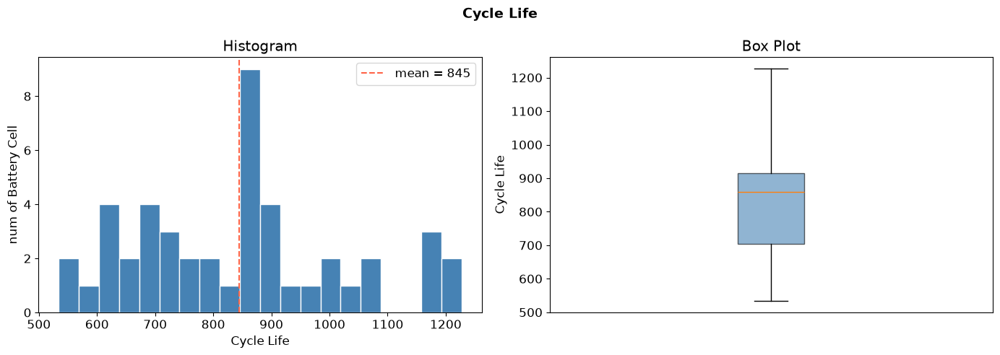

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [61]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

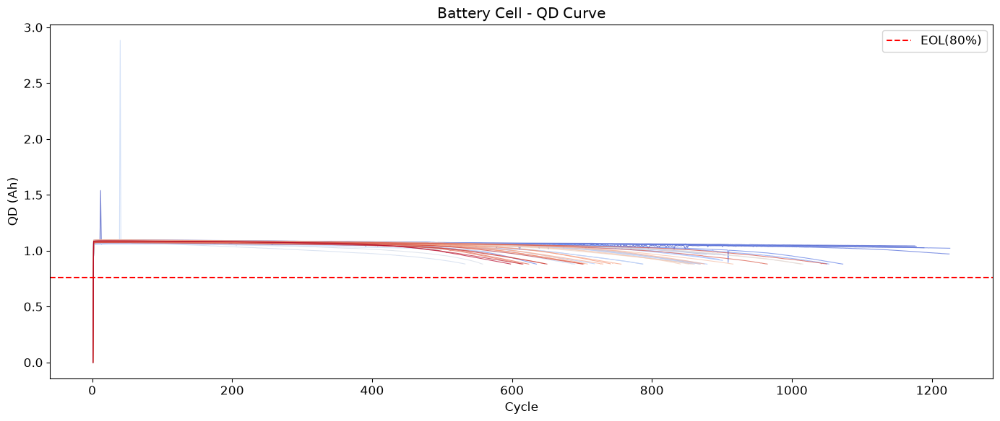

In [62]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[관측과 해석]
- 초기 구간에 주변 값보다 크게 벗어난 용량 기록이 있어 원본 값과 사이클 번호를 점검한다.
- 여러 셀에서 사이클이 증가할수록 방전 용량이 감소하는 형태가 관찰된다.
- 색상만으로 수명 그룹을 단정하지 않고 실제 수명 라벨과 대조한다. 세 배치 통합 결과에서는 수명 그룹 색상을 명시한다.


공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


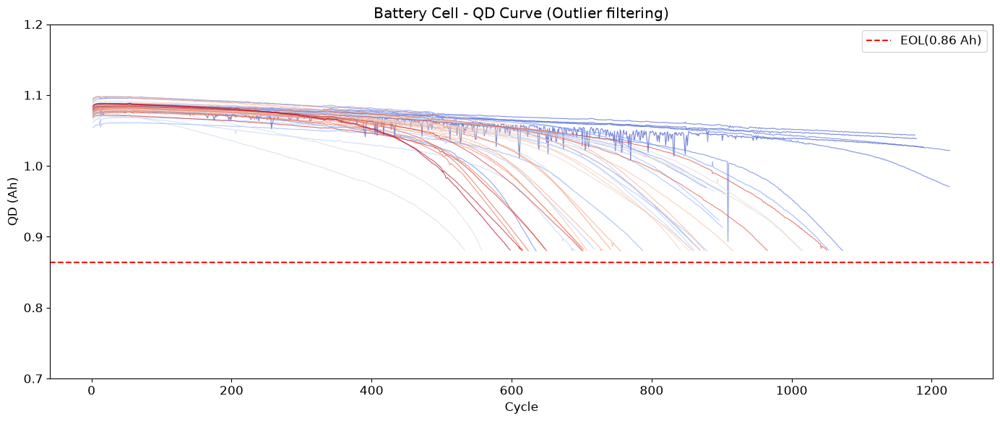

In [63]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 달느 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

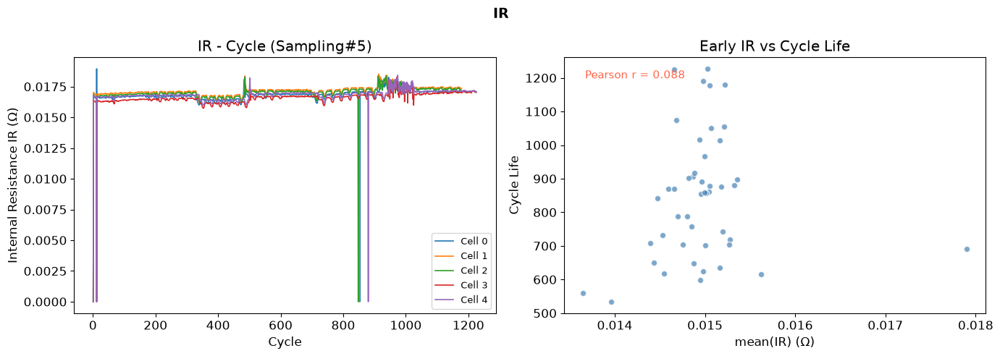

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[관측과 해석]
- 선택한 샘플의 내부저항 변화는 전체 셀의 경향을 대표하지 않을 수 있다.
- 급격한 변동은 해당 시점의 다른 측정값과 함께 확인하며, 측정 오류나 특정 반응으로 단정하지 않는다.
- 이 초기 요약의 상관계수 0.088은 약한 선형 관계를 뜻한다. 저항 변화량과 수명 구간별 추이는 뒤의 통합 분석에서 별도로 확인한다.


### 4. 충전 정책(C-rate)과 수명의 관계

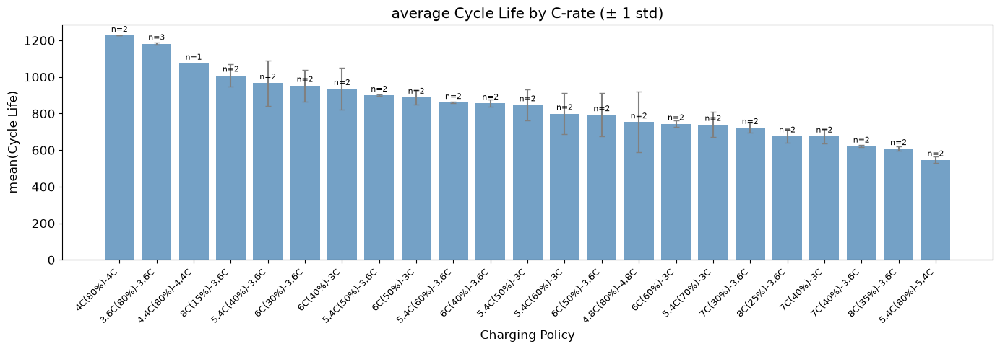

In [65]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[충전 정책을 비교하는 방법]
- 정책 문자열에서 첫 전류 C1, 전환 SOC Q1, 두 번째 전류 C2를 추출한다.
- 같은 첫 전류라도 전환 SOC와 두 번째 전류가 다르면 서로 다른 정책으로 비교한다.
- 문자열의 설정값과 실제 충전 시간은 구분한다. 실제 구간별 동작은 전류·전압·시간 기록에서 확인한다.
- 정책 접미사는 삭제하지 않는다. 숫자 설정이 같아도 측정 분포가 다를 수 있기 때문이다.


[관측과 해석]
- 정책별 수명 분포가 다르지만, 같은 정책 안에서도 셀별 편차가 있다.
- `8C(15%)-3.6C`와 `8C(25%)-3.6C`처럼 첫·두 번째 전류를 맞춘 비교에서는 전환 SOC에 따른 수명 차이를 살펴볼 수 있다.
- 조건당 셀이 적으므로 평균 차이를 원인 효과로 확정하지 않는다. 전체 통합 자료의 조건별 분포와 함께 검토한다.

[모델 설계 연결]
- 충전 조건과 셀에서 측정한 반응 신호를 함께 검토하고, 조건만으로 수명을 설명할 수 있는지 확인한다.


### 5. 상관관계 히트맵

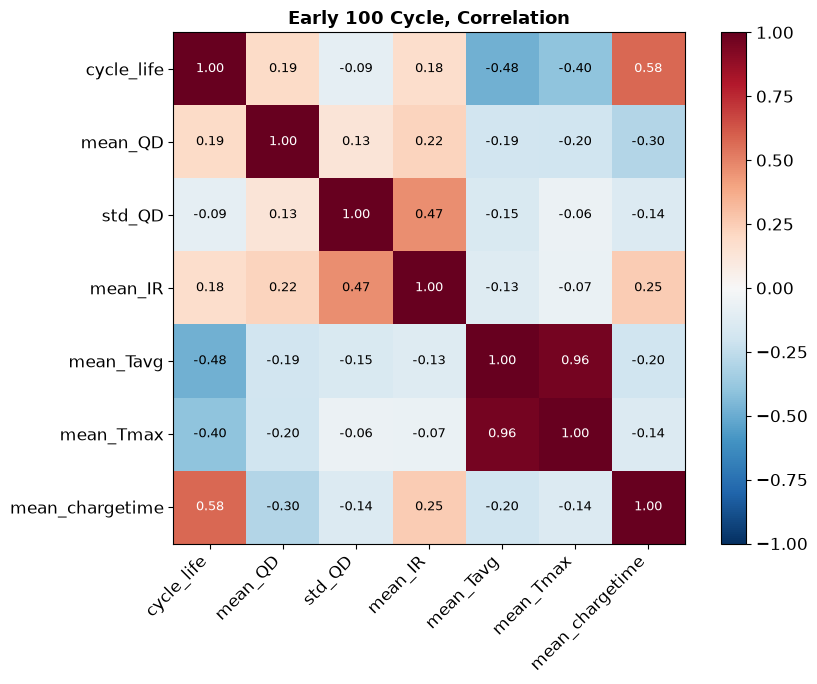


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [66]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[상관관계 해석]
- 이 히트맵은 위쪽 Batch 1 기본 분석의 초기 요약값에 대한 결과다. 아래 전처리 이후의 통합 분석과 구분한다.
- 충전 시간·온도와 수명 사이에 연관성이 보이지만 원인과 결과의 방향을 뜻하지는 않는다.
- 평균 온도와 최고 온도의 상관이 0.96으로 높아 두 변수가 중복된 정보를 담을 가능성이 있다.

[모델 설계 연결]
- 초기 구간 정의와 빈 기록 처리를 맞춘 뒤 상관관계 및 VIF를 다시 확인한다.
- 높은 상관의 변수를 동시에 늘리기보다 대표값이나 대체 조합을 비교한다.


---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

### 5-1. EDA 보완: 첫 사이클의 빈 기록 처리

#### 무엇이 문제인가?

앞의 `df.head()`에서 셀 0의 첫 사이클은 QD·QC·IR·온도·충전 시간이 모두 0이다.
같은 셀의 상세 기록 `cycles[0]`도 측정 배열이 `None`으로 표시됐다.
이는 실제로 용량·저항·온도가 모두 0이었다는 의미가 아니라, **측정값이 없는 첫 기록이 summary에 0으로 들어간 것**으로 판단하는 근거다.
다른 셀도 같은 상태인지 아래에서 확인한다.

`df.isnull()`은 NaN·None을 찾지만 숫자 0은 결측으로 세지 않는다. 따라서 **결측치 0개가 유효한 측정값만 있다는 뜻은 아니다.**

#### 평균과 표준편차에 어떤 영향을 주는가?

설명용 예시로 초기 용량이 `[0, 1.07, 1.07, 1.07, 1.07]` Ah라면:

| 계산 대상 | 평균 용량 | 해석 |
|---|---:|---|
| 빈 기록의 0까지 포함 | 0.856 Ah | 실제보다 초기 용량이 작게 계산됨 |
| 실제 측정 4개만 사용 | 1.070 Ah | 측정된 초기 용량을 반영 |

0에서 1.07로 급변한 것처럼 보여 표준편차도 커진다. 이 값으로 피처를 만들면 빈 기록을 배터리의 특성으로 오해할 수 있다.

#### 처리 원칙

1. 원본 `df`를 보관하고 첫 사이클의 상태를 셀별로 확인한다.
2. 첫 기록이 모두 0인 것으로 확인되면 `df_measured`를 만들어 2회차부터 분석한다.
3. 초기 5회 이내는 **2~5회차**, 초기 100회 이내는 **2~100회차**로 선택한다. 제외한 한 회를 보충하려고 6회차 또는 101회차까지 늘리지 않는다.
4. 모든 숫자 0을 결측으로 바꾸지는 않는다. 예를 들어 휴지 구간의 전류 0은 정상적인 측정값이다.

먼저 맨 위의 `%pip install` 셀로 패키지를 설치한다. 아래 첫 코드 셀은 `df`가 없으면 기존 `data/2017-05-12/` CSV에서 자동으로 생성한다. 따라서 앞의 대용량 MAT 로딩을 다시 실행하지 않아도 이 절부터 진행할 수 있다. 이번 단계는 첫 기록만 처리하며, 이전 `df_clean`의 용량 범위 필터는 적용하지 않는다.

In [67]:
# 준비: 위쪽 로딩 셀을 실행하지 않았다면, 기존에 변환한 Batch 1 CSV에서 df를 생성
import pandas as pd
from pathlib import Path
from IPython.display import display

if 'df' not in globals():
    project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                         if (p / 'data/2017-05-12/summary.csv').exists()), None)
    if project_root is None:
        raise FileNotFoundError('프로젝트 폴더에서 실행하세요. data/2017-05-12/summary.csv가 필요합니다.')
    batch1_dir = project_root / 'data/2017-05-12'
    summary_source = pd.read_csv(batch1_dir / 'summary.csv')
    cell_source = pd.read_csv(batch1_dir / 'cells.csv')
    df = summary_source.merge(
        cell_source[['cell_index', 'cycle_life', 'policy_readable']],
        on='cell_index', how='left', validate='many_to_one'
    ).rename(columns={'cell_index': 'cell_id', 'QDischarge': 'QD',
                      'QCharge': 'QC', 'policy_readable': 'charging_policy'})
    df = df[['cell_id', 'cycle', 'cycle_life', 'charging_policy',
             'QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']]
    print(f'기존 Batch 1 CSV에서 df 생성: {df.shape}')
else:
    print(f'현재 커널의 df 사용: {df.shape}')

# 1. 셀별 첫 사이클과 0값 상태 확인
measurement_cols = ['QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']
first_cycle_rows = df.loc[df['cycle'].eq(1)].copy()
first_cycle_audit = first_cycle_rows[['cell_id', 'cycle']].copy()
first_cycle_audit['측정값_모두_0'] = first_cycle_rows[measurement_cols].eq(0).all(axis=1)

print(f"전체 셀 수: {df['cell_id'].nunique()}")
print(f"첫 사이클 행 수: {len(first_cycle_rows)}")
print(f"측정값이 모두 0인 첫 사이클: {first_cycle_audit['측정값_모두_0'].sum()}행")
display(first_cycle_audit)

# 예상과 다르면 자동으로 제거하지 않고 실제 기록을 먼저 확인한다.
assert len(first_cycle_rows) == df['cell_id'].nunique(), '셀별 첫 기록 수를 확인하세요.'
assert first_cycle_rows['cell_id'].is_unique, '첫 기록의 셀 번호가 중복됩니다.'
assert first_cycle_audit['측정값_모두_0'].all(), '0이 아닌 첫 기록이 있습니다. 개별 확인이 필요합니다.'

현재 커널의 df 사용: (38811, 11)
전체 셀 수: 46
첫 사이클 행 수: 46
측정값이 모두 0인 첫 사이클: 46행


,cell_id,cycle,측정값_모두_0
0,0,1,True
1189,1,1,True
2367,2,1,True
3543,3,1,True
4768,4,1,True
5994,5,1,True
7067,6,1,True
7702,7,1,True
8571,8,1,True
9449,9,1,True


In [68]:
# 2. 원본을 보존하면서 분석용 표 생성
original_row_count = len(df)
df_measured = df.loc[df['cycle'] >= 2].copy()

# 예측 시점 이내의 유효 측정 기록만 선택한다.
early_5 = df_measured.loc[df_measured['cycle'] <= 5].copy()
early_100 = df_measured.loc[df_measured['cycle'] <= 100].copy()

print(f"원본 df: {original_row_count:,}행")
print(f"분석용 df_measured: {len(df_measured):,}행")
print(f"제외한 첫 사이클: {original_row_count - len(df_measured):,}행")
print(f"초기 5회 이내(2~5회): {len(early_5):,}행")
print(f"초기 100회 이내(2~100회): {len(early_100):,}행")
assert len(df) == original_row_count
assert df_measured['cycle'].ge(2).all()

원본 df: 38,811행
분석용 df_measured: 38,765행
제외한 첫 사이클: 46행
초기 5회 이내(2~5회): 184행
초기 100회 이내(2~100회): 4,554행


In [69]:
# 3. 셀별로 초기 용량의 평균·표준편차가 어떻게 달라지는지 비교
before_qd = df.loc[df['cycle'] <= 5].groupby('cell_id')['QD'].agg(['mean', 'std'])
after_qd = early_5.groupby('cell_id')['QD'].agg(['mean', 'std'])
first_cycle_effect = before_qd.rename(columns={
    'mean': '처리전_평균용량_Ah', 'std': '처리전_표준편차_Ah'
}).join(after_qd.rename(columns={
    'mean': '처리후_평균용량_Ah', 'std': '처리후_표준편차_Ah'
}))
display(first_cycle_effect.round(6))

,처리전_평균용량_Ah,처리전_표준편차_Ah,처리후_평균용량_Ah,처리후_표준편차_Ah
cell_id,,,,
0,0.857655,0.479444,1.072068,0.001056
1,0.861472,0.481579,1.076841,0.001204
2,0.865241,0.483685,1.081551,0.001234
3,0.865135,0.483627,1.081419,0.001286
4,0.863521,0.482723,1.079401,0.000874
5,0.861781,0.481751,1.077226,0.001058
6,0.862137,0.481951,1.077671,0.001456
7,0.876280,0.489857,1.095351,0.001139
8,0.873179,0.488123,1.091473,0.001124


#### 이번 처리의 의미와 남은 작업

- **처리 내용:** 빈 첫 기록을 분석 대상에서 제외하고 원본과 분석용 표를 분리했다. 위 코드 실행 결과에서 제외 행 수와 셀별 평균·표준편차 변화를 확인한다.
- **EDA 시사점:** 숫자로 채워진 데이터도 측정 의미를 확인해야 한다. 초기 평균이나 변동성을 계산하기 전에 빈 기록을 구분한다.
- **모델링 연결:** 분류를 초기 5회 이내 정보로 설계한다면 이후 피처는 `early_5`에서 생성한다. `early_100`은 초기 100회 분석용이며 5회 시점 분류 입력으로 사용하지 않는다.
- **아직 해결하지 않은 것:** 46개 셀의 수명 라벨 유효성, 다른 이상값, 충전 정책 해석, 공선성은 다음 단계에서 하나씩 확인한다. `df_measured`가 최종 학습 데이터라는 뜻은 아니다.
- **기존 결과와의 관계:** 위쪽의 `early`·상관 히트맵은 첫 사이클을 포함한 이전 결과다. 이번 셀을 실행해도 자동으로 바뀌지 않으므로, 후속 단계에서 정리된 데이터로 다시 계산한다.

### 5-2. Question 1 — Batch 1·2·3의 Cycle Life 분포 비교

과제에서 지정한 파일명을 기준으로 Batch 1=2017-05-12, Batch 2=2018-02-20, Batch 3=2018-04-12로 부른다.
**이 절부터 세 배치를 같은 코드로 분석한다.** 위쪽 기본 EDA와 5-1은 Batch 1의 기존 실습 기록이며 세 배치 결과로 해석하지 않는다.

- 배치별 히스토그램: 가로축 150~2,300회, 세로축 셀 수. 셀 하나를 한 번만 집계한다.
- 모든 배치에 같은 기준: 단수명 `<500`, 중간 `500~1,000`, 장수명 `>1,000`. 상대적 12셀 그룹은 사용하지 않는다.
- 수명 NaN·비양수·무한대는 수명 미확인으로 따로 세고, 그룹 분모에는 유한한 양수 라벨만 사용한다. 기록 길이로 결측 수명을 채우지 않는다.
- Batch 1의 재개·조기 종료 10셀은 저장값 히스토그램에는 포함하되 별도 색으로 표시한다.
- Batch 2·3의 유한한 라벨도 모두 완전한 종료 관측임을 검증한 것은 아니다. 아래 비교는 **저장 라벨 기준의 탐색 결과**다.

EDA 전 고찰: 셀별 온도 측정값과 충전 정책의 분포를 함께 확인한다. 서로 다른 파일의 조건이 모두 같다고 가정하지 않는다. 과제 Batch 2는 파일 날짜 2018-02-20을 기준으로 지칭한다.
이번 EDA는 세 배치의 분포와 초기 측정 특성을 비교한다.

이미 변환된 각 배치의 cells.csv·summary.csv를 읽는다. 원본 데이터와 기존 df를 변경하지 않는다. 아래 첫 코드 셀부터 실행할 수 있다.

In [ ]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

eda_root=next((p for p in [Path.cwd(),*Path.cwd().parents]
               if (p/'data/2017-05-12/cells.csv').exists()),None)
if eda_root is None: raise FileNotFoundError('프로젝트 폴더에서 실행하세요. data 폴더가 필요합니다.')
eda_specs=[('Batch 1','2017-05-12'),('Batch 2','2018-02-20'),('Batch 3','2018-04-12')]
eda_font=Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if eda_font.exists():plt.rcParams['font.family']=FontProperties(fname=str(eda_font)).get_name()
plt.rcParams['axes.unicode_minus']=False
eda_out=eda_root/'DAY1/results';eda_out.mkdir(parents=True,exist_ok=True)
eda_batches={}
eda_group_names=['단수명 <500','중간 500~1,000','장수명 >1,000']
eda_colors=['#cf5656','#a77c1a','#357abb']
def eda_group(life):return 0 if life<500 else 1 if life<=1000 else 2
for name,date in eda_specs:
    folder=eda_root/'data'/date
    with (folder/'cells.csv').open(encoding='utf-8-sig') as f:raw=list(csv.DictReader(f))
    cells={}
    for r in raw:
        cid=int(r['cell_index']);life=float(r['cycle_life'])
        known_incomplete=name=='Batch 1' and cid in {0,1,2,3,4,8,10,12,13,22}
        valid=bool(np.isfinite(life) and life>0)
        status=('후속 기록 필요' if name=='Batch 1' and cid in {0,1,2,3,4} else
                '조기 종료' if known_incomplete else '수명 미확인' if not valid else
                '종료 기준 부근까지 관측' if name=='Batch 1' else '저장 라벨 있음·종료 상태 추가 확인')
        cells[cid]=dict(id=cid,life=life,policy=r['policy_readable'],valid=valid,
                        incomplete=known_incomplete,status=status)
    series={cid:[] for cid in cells}
    with (folder/'summary.csv').open(encoding='utf-8-sig') as f:
        for r in csv.DictReader(f):
            cid=int(r['cell_index'])
            series[cid].append({k:float(r[k]) for k in ['cycle','QDischarge','IR','Tavg','Tmax','chargetime']})
    series={cid:{k:np.array([r[k] for r in rows]) for k in rows[0]} for cid,rows in series.items() if rows}
    eda_batches[name]=dict(date=date,cells=cells,series=series)
    lives=np.array([r['life'] for r in cells.values() if r['valid']])
    print(f'{name} ({date}): 전체 {len(cells)}셀, 유효 저장 라벨 {len(lives)}셀, 수명 미확인 {len(cells)-len(lives)}셀')
    print(f'  수명 범위 {lives.min():.0f}~{lives.max():.0f}, 중앙값 {np.median(lives):.1f}회')

Batch 1 (2017-05-12): 전체 46셀, 유효 저장 라벨 46셀, 수명 미확인 0셀
  수명 범위 534~1227, 중앙값 858.5회
Batch 2 (2018-02-20): 전체 47셀, 유효 저장 라벨 39셀, 수명 미확인 8셀
  수명 범위 392~1186, 중앙값 472.0회
Batch 3 (2018-04-12): 전체 46셀, 유효 저장 라벨 44셀, 수명 미확인 2셀
  수명 범위 541~1935, 중앙값 1005.5회


#### 추가 비교 기준 — 수명 3그룹과 550회 기준 2그룹 비교

수명 그룹을 나누는 방식에 따라 피처의 분포와 열화 추이가 어떻게 달라지는지 살펴본다. **550회**는 이번 2그룹 비교에 사용하는 경계값이며, 데이터에서 최적값으로 추정한 기준은 아니다.

| 비교 | 단수명 | 중간 | 장수명 |
|---|---|---|---|
| 3그룹 비교 | <500회 | 500~1,000회 | >1,000회 |
| 550회 기준 2그룹 비교 | <550회 | 별도 그룹 없음 | ≥550회 |

같은 통합 119셀과 동일한 전처리 결과를 사용한다. 3그룹 비교와 함께 2그룹 비교를 제시하여 그룹 구분에 따른 차이를 확인한다. 550회와 정확히 같은 셀은 장수명에 포함한다.

전체 관측 구간과 초기 100회 피처를 이용한 **탐색적 비교**이며, 그룹 간 차이가 곧 예측 성능을 의미하지는 않는다. 최종 예측 목표는 초기 100회 측정값을 이용한 총수명 회귀다.


In [ ]:
# 2그룹 탐색 비교의 경계값은 550회이며, 정확히 550회인 셀은 장수명에 포함한다.
b2_eda_batches=eda_batches
b2_eda_root=eda_root
b2_eda_out=eda_out
b2_eda_colors=['#cf5656','#357abb']
b2_eda_group_names=['단수명 <550','장수명 ≥550']
def b2_eda_group(life):return int(life>=550)
b2_eda_metric_names=['평균 방전 용량','방전 용량 변화량','평균 온도','최고 온도','내부저항 변화량','평균 충전 시간']
b2_eda_units=['Ah','Ah','°C','°C','mΩ','분']
b2_eda_features={};b2_eda_groups={}
for name,b in b2_eda_batches.items():
    b2_eda_groups[name]=[[r['id'] for r in sorted(b['cells'].values(),key=lambda r:(r['life'] if r['valid'] else np.inf,r['id']))
                       if r['valid'] and not r['incomplete'] and b2_eda_group(r['life'])==g] for g in range(2)]
    print(name,'비교 셀 수:',[len(g) for g in b2_eda_groups[name]])
    for end in [5,100]:
        b2_eda_features[name,end]={}
        for group in b2_eda_groups[name]:
            for cid in group:
                s=b['series'][cid];mask=(s['cycle']>=2)&(s['cycle']<=end)
                cycles=s['cycle'][mask]
                if not np.array_equal(np.sort(cycles),np.arange(2,end+1)):
                    print(name,cid,end,'사이클 누락/중복: 해당 구간의 지표 제외');continue
                q=s['QDischarge'][mask];ir=s['IR'][mask]
                indices=np.argsort(cycles);q=q[indices];ir=ir[indices]
                vals=[np.mean(q),q[-1]-q[0],np.mean(s['Tavg'][mask]),np.max(s['Tmax'][mask]),
                      (ir[-1]-ir[0])*1000,np.mean(s['chargetime'][mask])]
                b2_eda_features[name,end][cid]=np.array(vals)
                if end==100 and np.any((q<=0)|(q>1.2)|~np.isfinite(q)):
                    print(name,'셀',cid,'초기 용량 점검 후보 있음: 값 유지')
                if not np.isfinite(vals).all():print(name,cid,end,'비유한 지표: 해당 지표 점만 제외')
b2_pooled_groups=[[(name,cid) for name in b2_eda_batches for cid in b2_eda_groups[name][g]] for g in range(2)]
assert sum(map(len,b2_pooled_groups))==119
print('550회 경계 셀 수:',sum(r['life']==550 for b in eda_batches.values() for r in b['cells'].values() if r['valid'] and not r['incomplete']))


Batch 1 비교 셀 수: [1, 35]
Batch 1 셀 18 초기 용량 점검 후보 있음: 값 유지
Batch 2 비교 셀 수: [30, 9]
Batch 3 비교 셀 수: [1, 43]
550회 경계 셀 수: 0


#### ① 같은 축의 히스토그램과 수명 그룹 비율

히스토그램의 회색은 알려진 불완전 라벨(Batch 1의 10셀), 파란색은 그 외 유효 저장 라벨이다.
회색 셀도 저장값 기준 그룹 비율에는 포함된다. 누락 라벨은 별도로 출력한다.
막대 경계는 500·1,000회에 맞도록 50회 간격으로 통일했다. 150~2,300 밖의 값이 있으면 별도로 출력한다.

Batch 1 단/중/장: [0, 36, 10] 표시 범위 밖: []
Batch 2 단/중/장: [28, 8, 3] 표시 범위 밖: []
Batch 3 단/중/장: [0, 21, 23] 표시 범위 밖: []


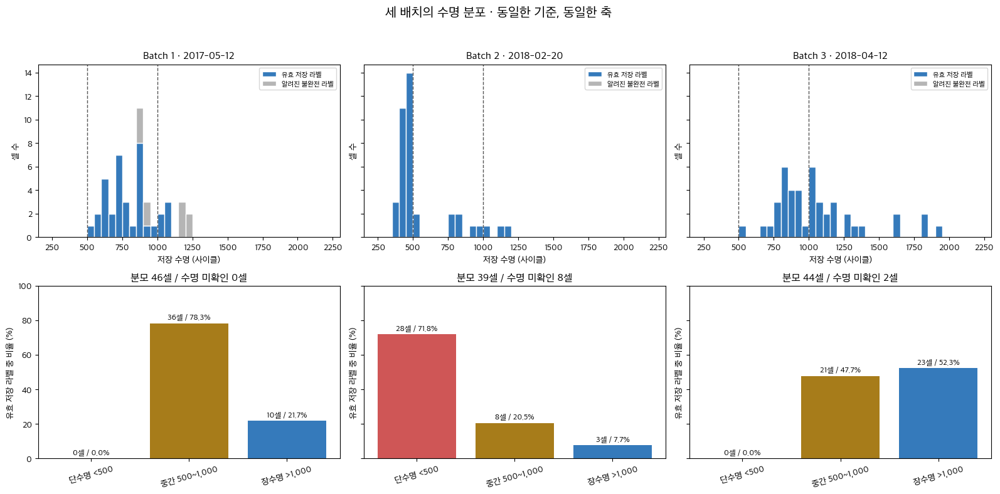

In [ ]:
fig,axes=plt.subplots(2,3,figsize=(16,8),sharex='row',sharey='row')
eda_stats=[]
for j,(name,b) in enumerate(eda_batches.items()):
    rows=[r for r in b['cells'].values() if r['valid']]
    lives=np.array([r['life'] for r in rows]);counts=[sum(eda_group(v)==g for v in lives) for g in range(3)]
    normal=[r['life'] for r in rows if not r['incomplete']]
    flagged=[r['life'] for r in rows if r['incomplete']]
    axes[0,j].hist([normal,flagged],bins=np.arange(150,2301,50),stacked=True,
                  color=['#357abb','#b5b5b5'],edgecolor='white',label=['유효 저장 라벨','알려진 불완전 라벨'])
    for x in [500,1000]:axes[0,j].axvline(x,color='#555555',ls='--',lw=1)
    axes[0,j].set(xlim=(150,2300),title=f'{name} · {b["date"]}',xlabel='저장 수명 (사이클)',ylabel='셀 수')
    axes[0,j].legend(fontsize=8)
    axes[1,j].bar(range(3),np.array(counts)/len(rows)*100,color=eda_colors)
    axes[1,j].set_xticks(range(3),eda_group_names,rotation=15)
    axes[1,j].set(ylim=(0,100),ylabel='유효 저장 라벨 중 비율 (%)',title=f'분모 {len(rows)}셀 / 수명 미확인 {len(b["cells"])-len(rows)}셀')
    for g,cnt in enumerate(counts):axes[1,j].text(g,cnt/len(rows)*100+2,f'{cnt}셀 / {cnt/len(rows):.1%}',ha='center',fontsize=9)
    print(name,'단/중/장:',counts,'표시 범위 밖:',lives[(lives<150)|(lives>2300)])
    eda_stats.append(dict(batch=name,total=len(b['cells']),labeled=len(rows),missing=len(b['cells'])-len(rows),
                          short=counts[0],middle=counts[1],long=counts[2],median=float(np.median(lives))))
fig.suptitle('세 배치의 수명 분포 · 동일한 기준, 동일한 축',fontsize=15)
fig.tight_layout(rect=(0,0,1,.95));fig.savefig(eda_out/'scratch_all_batches_life.png',dpi=140,bbox_inches='tight');plt.show()

#### 병렬 비교 · 수명 550회 기준 2그룹 — 수명 분포와 그룹 비율

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


통합 비교 대상: 119 셀
단수명 <550 : 32 셀
장수명 ≥550 : 87 셀


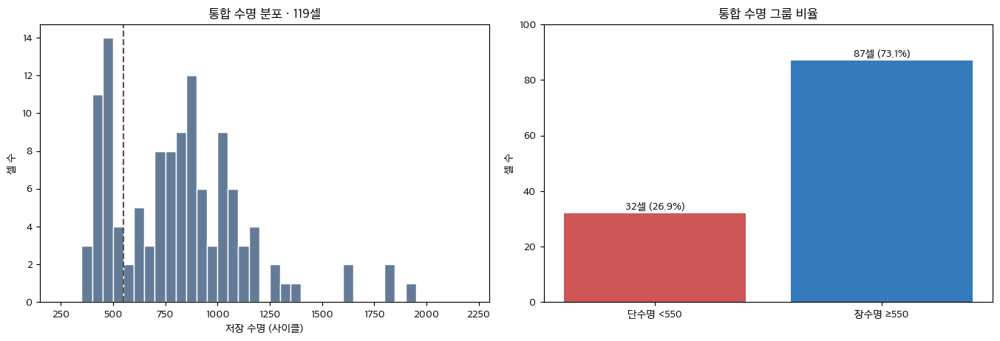

In [ ]:
b2_pooled_groups=[[(name,cid) for name in b2_eda_batches for cid in b2_eda_groups[name][g]] for g in range(2)]
assert sum(map(len,b2_pooled_groups))==119
print('통합 비교 대상:',sum(map(len,b2_pooled_groups)),'셀')
for g,group in enumerate(b2_pooled_groups):
    print(b2_eda_group_names[g],':',len(group),'셀')
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
b2_pooled_life=[b2_eda_batches[name]['cells'][cid]['life'] for group in b2_pooled_groups for name,cid in group]
axes[0].hist(b2_pooled_life,bins=np.arange(150,2301,50),color='#647b98',edgecolor='white')
axes[0].set(xlim=(150,2300),xlabel='저장 수명 (사이클)',ylabel='셀 수',title='통합 수명 분포 · 119셀')
for x in [550]:axes[0].axvline(x,color='#555555',ls='--')
counts=[len(g) for g in b2_pooled_groups]
axes[1].bar(range(2),counts,color=b2_eda_colors)
for g,v in enumerate(counts):axes[1].text(g,v+1,f'{v}셀 ({v/119:.1%})',ha='center')
axes[1].set_xticks(range(2),b2_eda_group_names);axes[1].set(ylabel='셀 수',ylim=(0,100),title='통합 수명 그룹 비율')
fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_pooled_composition.png',dpi=140,bbox_inches='tight');plt.show()

#### ② 배치별로 유독 짧은 셀 확인

각 배치 안에서 IQR 경계(Q1−1.5×IQR, Q3+1.5×IQR)를 계산한다. 서로 다른 배치를 합친 하나의 기준으로 이상치를 판정하지 않는다.
경계 밖은 점검 후보이지 자동 제거 대상이 아니다. 가장 짧은 5셀과 같은 정책의 셀을 확인하되, 기록 종료 원인은 용량 추이·실험 기록을 추가 확인해야 한다.

In [ ]:
for name,b in eda_batches.items():
    rows=sorted((r for r in b['cells'].values() if r['valid']),key=lambda r:r['life'])
    q25,q75=np.percentile([r['life'] for r in rows],[25,75]);iqr=q75-q25
    low,high=q25-1.5*iqr,q75+1.5*iqr
    print(f'\n{name}: IQR 범위 {low:.1f}~{high:.1f}회')
    print('범위 밖:',[(r['id'],r['life'],r['status']) for r in rows if r['life']<low or r['life']>high])
    print('짧은 5셀: 셀 번호 | 수명 | 정책 | 상태')
    for r in rows[:5]:print(r['id'],r['life'],r['policy'],r['status'],sep=' | ')
    policy=rows[0]['policy']
    print('최단 셀과 같은 정책:',[(r['id'],r['life']) for r in rows if r['policy']==policy])


Batch 1: IQR 범위 386.8~1230.8회
범위 밖: []
짧은 5셀: 셀 번호 | 수명 | 정책 | 상태
20 | 534.0 | 5.4C(80%)-5.4C | 종료 기준 부근까지 관측
21 | 559.0 | 5.4C(80%)-5.4C | 종료 기준 부근까지 관측
45 | 599.0 | 8C(35%)-3.6C | 종료 기준 부근까지 관측
44 | 616.0 | 8C(35%)-3.6C | 종료 기준 부근까지 관측
38 | 617.0 | 7C(40%)-3.6C | 종료 기준 부근까지 관측
최단 셀과 같은 정책: [(20, 534.0), (21, 559.0)]

Batch 2: IQR 범위 336.0~612.0회
범위 밖: [(7, 777.0, '저장 라벨 있음·종료 상태 추가 확인'), (9, 791.0, '저장 라벨 있음·종료 상태 추가 확인'), (32, 809.0, '저장 라벨 있음·종료 상태 추가 확인'), (44, 841.0, '저장 라벨 있음·종료 상태 추가 확인'), (8, 904.0, '저장 라벨 있음·종료 상태 추가 확인'), (45, 997.0, '저장 라벨 있음·종료 상태 추가 확인'), (43, 1029.0, '저장 라벨 있음·종료 상태 추가 확인'), (33, 1140.0, '저장 라벨 있음·종료 상태 추가 확인'), (34, 1186.0, '저장 라벨 있음·종료 상태 추가 확인')]
짧은 5셀: 셀 번호 | 수명 | 정책 | 상태
19 | 392.0 | 6C(60%)-3C | 저장 라벨 있음·종료 상태 추가 확인
6 | 393.0 | 3.6C(9%)-5C | 저장 라벨 있음·종료 상태 추가 확인
15 | 396.0 | 3.6C(9%)-5C | 저장 라벨 있음·종료 상태 추가 확인
21 | 408.0 | 6C(60%)-3C | 저장 라벨 있음·종료 상태 추가 확인
30 | 412.0 | 5.6C(26%)-4.5C | 저장 라벨 있음·종료 상태 추가 확인
최단 셀과 같은 정책: [(19, 392.0), (21, 408.0)]

B

### 5-3. 세 배치의 단수명·중간·장수명 초기 측정값 비교

**과제의 절대 수명 기준을 그대로 사용한다.** 그룹이 없으면 빈칸으로 표시하고 기준을 바꿔 채우지 않는다.
Batch 1의 알려진 불완전 라벨 10셀 및 모든 배치의 수명 미확인 셀은 이번 수명 그룹 비교에서만 제외한다.
따라서 앞 히스토그램과 비교 표본 수가 다르다. Batch 2·3의 나머지 셀은 저장 라벨에 기반한 잠정 비교 대상이다.

- 대표 셀은 각 배치·그룹에서 수명순 아래쪽 중앙의 실제 셀을 선택한다. 온도나 곡선 모양을 보고 선택하지 않는다.
- 2~100회와 2~5회를 따로 그린다. 초기 5회 분류에 100회 지표를 사용하지 않는다.
- 각 사이클 평균 온도·최고 온도, 용량과 내부저항 변화, 충전 시간을 비교한다.
- 원시 측정값에 임의 필터를 적용하지 않는다. 누락·중복·비유한 값이 있는 지표는 제외 이유를 출력한다.
- 그룹당 점 하나는 배터리 한 개다. 그룹 크기가 1~2개이면 박스 모양보다 개별 점을 중심으로 해석한다.

In [ ]:
eda_metric_names=['평균 방전 용량','방전 용량 변화량','평균 온도','최고 온도','내부저항 변화량','평균 충전 시간']
eda_units=['Ah','Ah','°C','°C','mΩ','분']
eda_features={};eda_groups={}
for name,b in eda_batches.items():
    eda_groups[name]=[[r['id'] for r in sorted(b['cells'].values(),key=lambda r:(r['life'] if r['valid'] else np.inf,r['id']))
                       if r['valid'] and not r['incomplete'] and eda_group(r['life'])==g] for g in range(3)]
    print(name,'비교 셀 수:',[len(g) for g in eda_groups[name]])
    for end in [5,100]:
        eda_features[name,end]={}
        for group in eda_groups[name]:
            for cid in group:
                s=b['series'][cid];mask=(s['cycle']>=2)&(s['cycle']<=end)
                cycles=s['cycle'][mask]
                if not np.array_equal(np.sort(cycles),np.arange(2,end+1)):
                    print(name,cid,end,'사이클 누락/중복: 해당 구간의 지표 제외');continue
                q=s['QDischarge'][mask];ir=s['IR'][mask]
                indices=np.argsort(cycles);q=q[indices];ir=ir[indices]
                vals=[np.mean(q),q[-1]-q[0],np.mean(s['Tavg'][mask]),np.max(s['Tmax'][mask]),
                      (ir[-1]-ir[0])*1000,np.mean(s['chargetime'][mask])]
                eda_features[name,end][cid]=np.array(vals)
                if end==100 and np.any((q<=0)|(q>1.2)|~np.isfinite(q)):
                    print(name,'셀',cid,'초기 용량 점검 후보 있음: 값 유지')
                if not np.isfinite(vals).all():print(name,cid,end,'비유한 지표: 해당 지표 점만 제외')

Batch 1 비교 셀 수: [0, 31, 5]
Batch 1 셀 18 초기 용량 점검 후보 있음: 값 유지
Batch 2 비교 셀 수: [28, 8, 3]
Batch 3 비교 셀 수: [0, 21, 23]


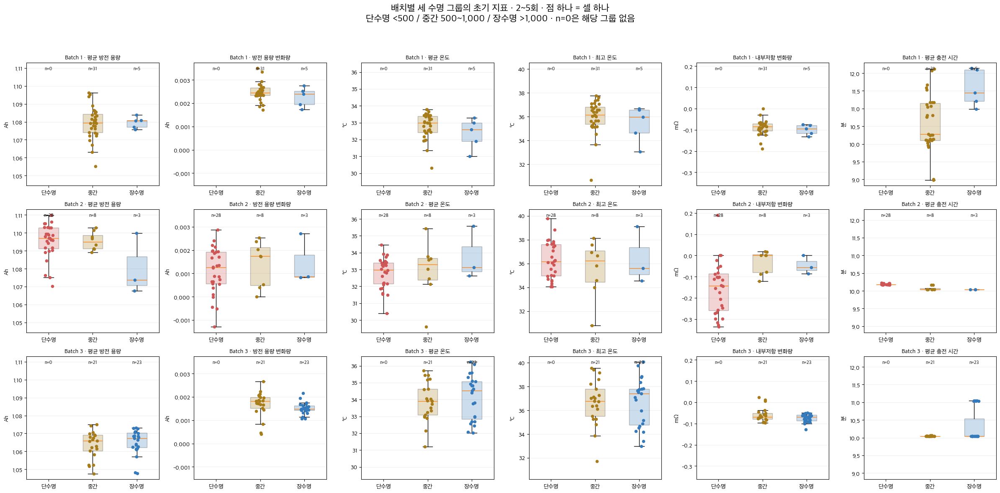

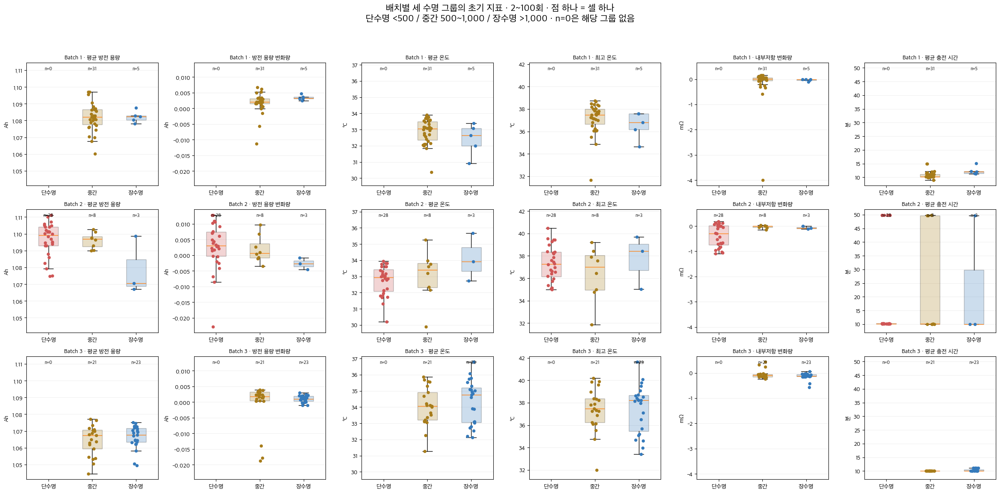

In [ ]:
# 배치(행) × 지표(열): 같은 열은 같은 단위와 y축으로 비교
for end in [5,100]:
    fig,axes=plt.subplots(3,6,figsize=(24,12),sharey='col')
    rng=np.random.default_rng(42)
    for row,(name,b) in enumerate(eda_batches.items()):
        for j,(title,unit) in enumerate(zip(eda_metric_names,eda_units)):
            ax=axes[row,j]
            for g,group in enumerate(eda_groups[name]):
                vals=[eda_features[name,end][cid][j] for cid in group
                      if cid in eda_features[name,end] and np.isfinite(eda_features[name,end][cid][j])]
                if vals:
                    box=ax.boxplot([vals],positions=[g],widths=.45,patch_artist=True,showfliers=False)
                    box['boxes'][0].set(facecolor=eda_colors[g],alpha=.25)
                    ax.scatter(g+rng.uniform(-.1,.1,len(vals)),vals,color=eda_colors[g],s=20,zorder=3)
                ax.text(g,.97,f'n={len(vals)}',transform=ax.get_xaxis_transform(),ha='center',va='top',fontsize=8)
            ax.set_xticks([0,1,2],['단수명','중간','장수명']);ax.set_xlim(-.5,2.5)
            ax.set_title(f'{name} · {title}',fontsize=10);ax.set_ylabel(unit);ax.grid(axis='y',alpha=.2)
    fig.suptitle(f'배치별 세 수명 그룹의 초기 지표 · 2~{end}회 · 점 하나 = 셀 하나\n단수명 <500 / 중간 500~1,000 / 장수명 >1,000 · n=0은 해당 그룹 없음',fontsize=16)
    fig.tight_layout(rect=(0,0,1,.94));fig.savefig(eda_out/f'scratch_all_batches_groups_{end}.png',dpi=120,bbox_inches='tight');plt.show()

#### 병렬 비교 · 수명 550회 기준 2그룹 — 초기 지표 분포 (배치를 합쳐 비교)

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


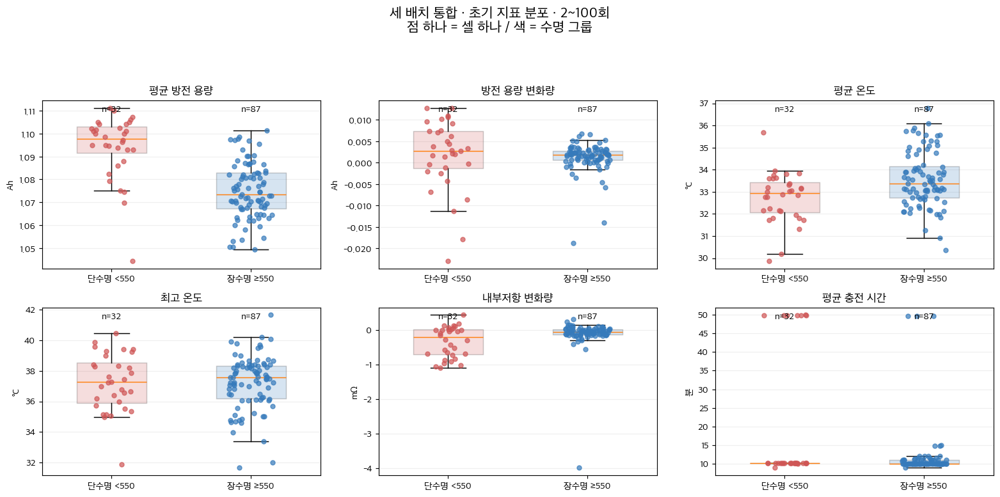

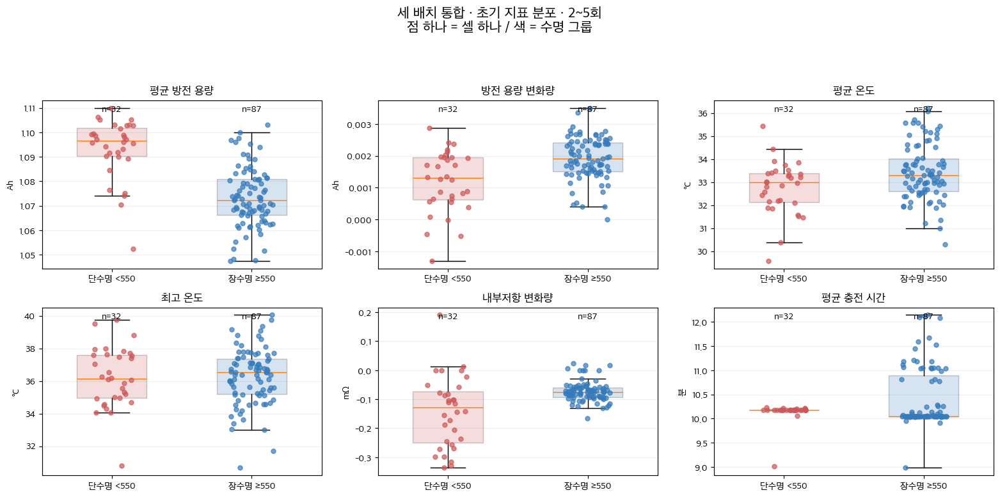

In [ ]:
# 통합 그룹 분포: 색은 수명 그룹, 모든 점은 셀 하나
for end in [100,5]:
    fig,axes=plt.subplots(2,3,figsize=(15,8));rng=np.random.default_rng(42)
    for j,ax in enumerate(axes.flat):
        for g,group in enumerate(b2_pooled_groups):
            valid=[(name,cid,b2_eda_features[name,end][cid][j]) for name,cid in group
                   if cid in b2_eda_features[name,end] and np.isfinite(b2_eda_features[name,end][cid][j])]
            vals=[v for name,cid,v in valid]
            if vals:
                box=ax.boxplot([vals],positions=[g],widths=.5,patch_artist=True,showfliers=False)
                box['boxes'][0].set(facecolor=b2_eda_colors[g],alpha=.2)
            ax.scatter(g+rng.uniform(-.16,.16,len(vals)),vals,color=b2_eda_colors[g],marker='o',s=23,alpha=.7,zorder=3)
            ax.text(g,.97,f'n={len(vals)}',transform=ax.get_xaxis_transform(),ha='center',va='top')
        ax.set_xticks(range(2),b2_eda_group_names);ax.set_xlim(-.5,1.5)
        ax.set(title=b2_eda_metric_names[j],ylabel=b2_eda_units[j]);ax.grid(axis='y',alpha=.2)
    fig.suptitle(f'세 배치 통합 · 초기 지표 분포 · 2~{end}회\n점 하나 = 셀 하나 / 색 = 수명 그룹',fontsize=15)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(b2_eda_out/f'scratch_binary_overview_features_{end}.png',dpi=140,bbox_inches='tight');plt.show()

2~5회 / Batch 1 / 중간 500~1,000: 셀 32, 731회 / 6C(60%)-3C
2~5회 / Batch 1 / 장수명 >1,000: 셀 41, 1051회 / 8C(15%)-3.6C
2~5회 / Batch 2 / 단수명 <500: 셀 18, 449회 / 5.2C(50%)-4.25C
2~5회 / Batch 2 / 중간 500~1,000: 셀 9, 791회 / 5.6C(26%)-4.5C-newstructure
2~5회 / Batch 2 / 장수명 >1,000: 셀 33, 1140회 / 5.2C(58%)-4C-newstructure
2~5회 / Batch 3 / 중간 500~1,000: 셀 5, 828회 / 5.6C(36%)-4.3C-newstructure
2~5회 / Batch 3 / 장수명 >1,000: 셀 19, 1155회 / 5.6C(36%)-4.3C-newstructure
2~100회 / Batch 1 / 중간 500~1,000: 셀 32, 731회 / 6C(60%)-3C
2~100회 / Batch 1 / 장수명 >1,000: 셀 41, 1051회 / 8C(15%)-3.6C
2~100회 / Batch 2 / 단수명 <500: 셀 18, 449회 / 5.2C(50%)-4.25C
2~100회 / Batch 2 / 중간 500~1,000: 셀 9, 791회 / 5.6C(26%)-4.5C-newstructure
2~100회 / Batch 2 / 장수명 >1,000: 셀 33, 1140회 / 5.2C(58%)-4C-newstructure
2~100회 / Batch 3 / 중간 500~1,000: 셀 5, 828회 / 5.6C(36%)-4.3C-newstructure
2~100회 / Batch 3 / 장수명 >1,000: 셀 19, 1155회 / 5.6C(36%)-4.3C-newstructure


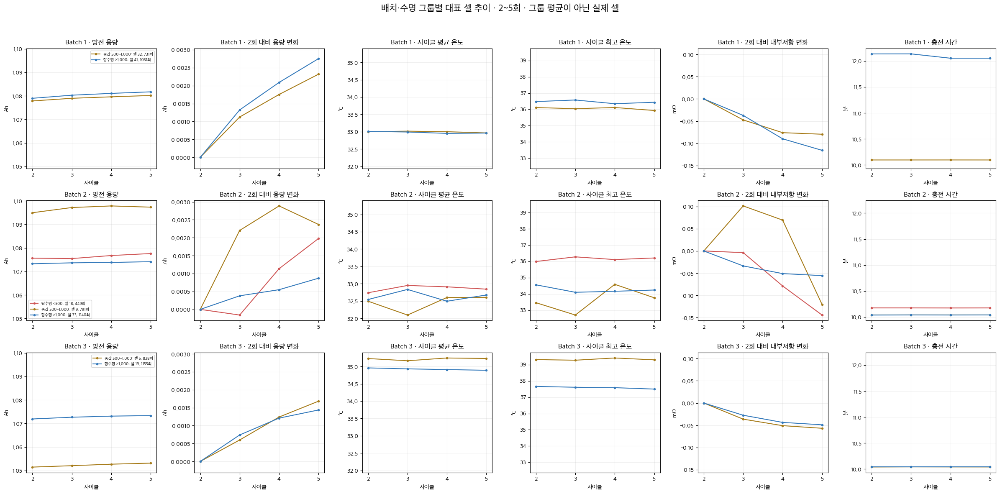

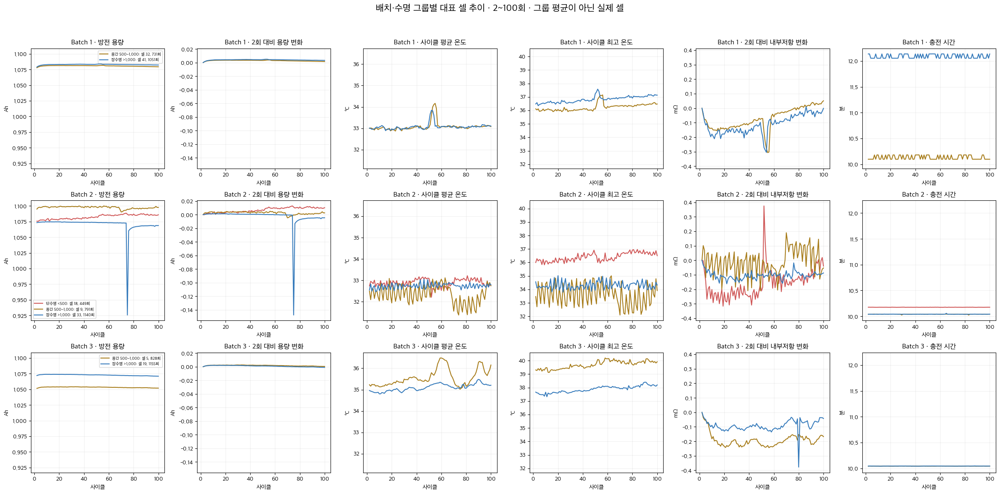

In [ ]:
for end in [5,100]:
    fig,axes=plt.subplots(3,6,figsize=(24,12),sharey='col')
    trace_titles=['방전 용량','2회 대비 용량 변화','사이클 평균 온도','사이클 최고 온도','2회 대비 내부저항 변화','충전 시간']
    for row,(name,b) in enumerate(eda_batches.items()):
        labels=[]
        for g,group in enumerate(eda_groups[name]):
            if not group:continue
            cid=group[(len(group)-1)//2];r=b['cells'][cid];s=b['series'][cid]
            mask=(s['cycle']>=2)&(s['cycle']<=end);start=np.flatnonzero(s['cycle']==2)
            if len(start)!=1 or not mask.any():
                print(name,cid,'대표 셀 기록 확인 필요');continue
            vals=[s['QDischarge'],s['QDischarge']-s['QDischarge'][start[0]],s['Tavg'],s['Tmax'],
                  (s['IR']-s['IR'][start[0]])*1000,s['chargetime']]
            label=f"{eda_group_names[g]}: 셀 {cid}, {r['life']:.0f}회"
            labels.append(label)
            print(f"2~{end}회 / {name} / {label} / {r['policy']}")
            for j,v in enumerate(vals):
                axes[row,j].plot(s['cycle'][mask],v[mask],color=eda_colors[g],label=label,
                                 marker='o' if end==5 else None,markersize=3)
        for j,ax in enumerate(axes[row]):
            ax.set(title=f'{name} · {trace_titles[j]}',xlabel='사이클',ylabel=eda_units[j]);ax.grid(alpha=.2)
            if end==5:ax.set_xticks([2,3,4,5])
        axes[row,0].legend(fontsize=7)
    fig.suptitle(f'배치·수명 그룹별 대표 셀 추이 · 2~{end}회 · 그룹 평균이 아닌 실제 셀',fontsize=16)
    fig.tight_layout(rect=(0,0,1,.95));fig.savefig(eda_out/f'scratch_all_batches_traces_{end}.png',dpi=120,bbox_inches='tight');plt.show()

#### 병렬 비교 · 수명 550회 기준 2그룹 — 초기 사이클 추이 (배치를 합쳐 비교)

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


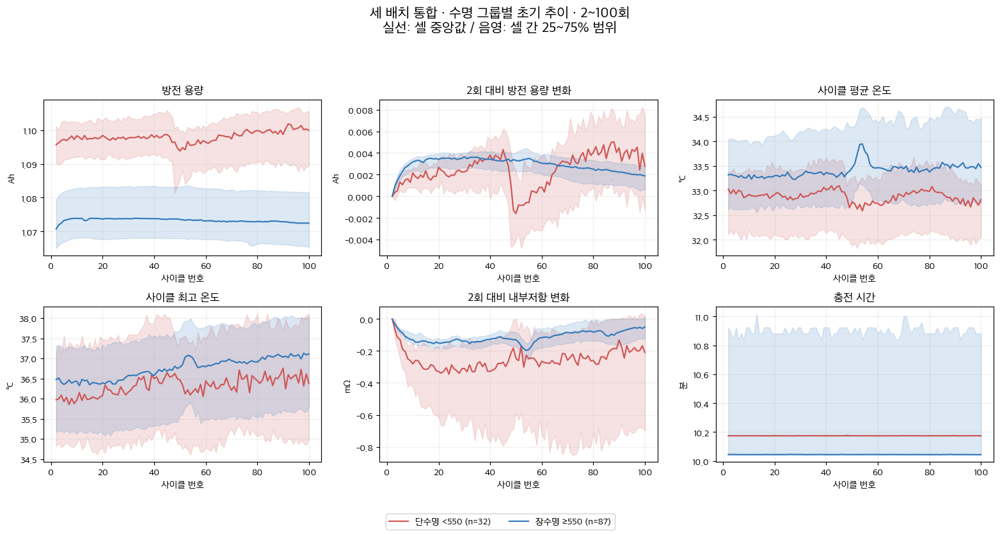

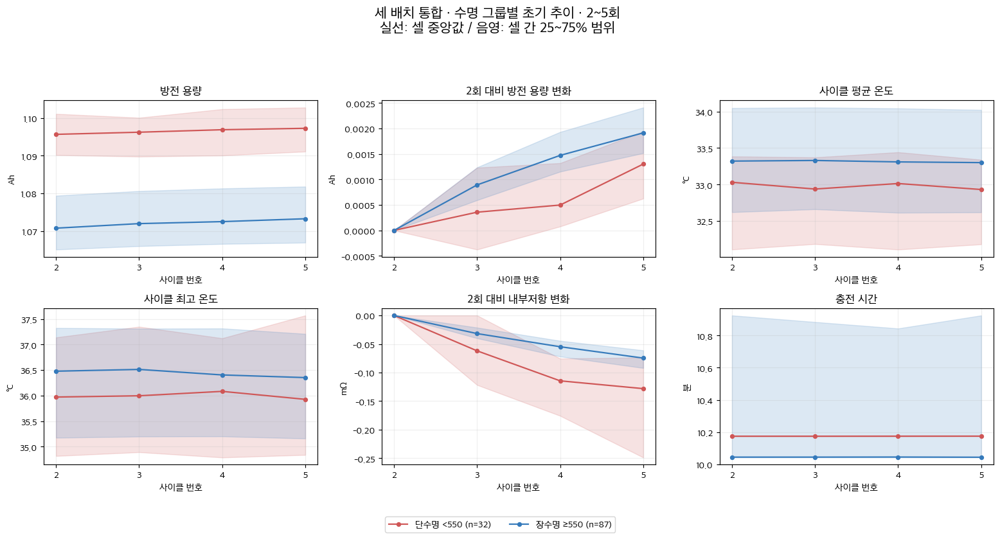

In [ ]:
# 전체 셀의 사이클별 중앙값 + 사분위 구간 (누락은 연결 보간하지 않음)
b2_pooled_trace_titles=['방전 용량','2회 대비 방전 용량 변화','사이클 평균 온도','사이클 최고 온도','2회 대비 내부저항 변화','충전 시간']
for end in [100,5]:
    axis_cycles=np.arange(2,end+1)
    fig,axes=plt.subplots(2,3,figsize=(15,8))
    for g,group in enumerate(b2_pooled_groups):
        matrices=[]
        for name,cid in group:
            s=b2_eda_batches[name]['series'][cid]
            trace=np.full((6,len(axis_cycles)),np.nan)
            start=np.flatnonzero(s['cycle']==2)
            if len(start)!=1:continue
            q0=s['QDischarge'][start[0]];ir0=s['IR'][start[0]]
            for j,k in enumerate(axis_cycles):
                pos=np.flatnonzero(s['cycle']==k)
                if len(pos)!=1:continue
                i=pos[0]
                trace[:,j]=[s['QDischarge'][i],s['QDischarge'][i]-q0,s['Tavg'][i],s['Tmax'][i],
                            (s['IR'][i]-ir0)*1000,s['chargetime'][i]]
            trace[~np.isfinite(trace)]=np.nan
            matrices.append(trace)
        arr=np.array(matrices)
        for j,ax in enumerate(axes.flat):
            low,med,high=np.nanpercentile(arr[:,j,:],[25,50,75],axis=0)
            ax.plot(axis_cycles,med,color=b2_eda_colors[g],label=f'{b2_eda_group_names[g]} (n={len(group)})',marker='o' if end==5 else None,markersize=4)
            ax.fill_between(axis_cycles,low,high,color=b2_eda_colors[g],alpha=.17)
            available=np.isfinite(arr[:,j,:]).sum(axis=0)
            if available.min()!=len(group):print(end,b2_eda_group_names[g],b2_pooled_trace_titles[j],'사이클별 유효 n',available.min(),available.max())
    for j,ax in enumerate(axes.flat):
        ax.set(title=b2_pooled_trace_titles[j],xlabel='사이클 번호',ylabel=b2_eda_units[j]);ax.grid(alpha=.2)
        if end==5:ax.set_xticks([2,3,4,5])
    handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=2)
    fig.suptitle(f'세 배치 통합 · 수명 그룹별 초기 추이 · 2~{end}회\n실선: 셀 중앙값 / 음영: 셀 간 25~75% 범위',fontsize=15)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(b2_eda_out/f'scratch_binary_overview_traces_{end}.png',dpi=140,bbox_inches='tight');plt.show()

#### 결과 해석과 걱정되는 점

1. **빈 그룹:** Batch 1에는 <500회 셀이 없다. 빈칸이 오류는 아니다. Batch 간 차이 자체가 EDA 결과다.
2. **라벨 누락과 불완전 관측:** 비율 분모와 비교 제외 대상을 확인한다. 마지막 사이클 번호나 마지막 용량만으로 결측 수명을 임의 복원하지 않는다.
3. **조건 차이와 센서:** 온도·시간 차이가 충전 조건, 진단 절차, 센서 상태와 섞여 있을 수 있다. 같은 종류의 셀이라도 배치가 같은 실험을 뜻하지 않는다. 다음 질문에서 충전 정책·실험 조건과 함께 해석한다.
4. **작은 그룹:** 장수명 또는 단수명 셀이 매우 적으면 중앙값과 박스가 불안정하다. 대표 셀은 설명 사례이며 그룹의 평균적 행동을 보증하지 않는다.
5. **시간 누수:** 초기 5회 분류를 선택한다면 2~5회 피처만 사용한다. 100회 그림과 전체 수명 정보는 탐색용이다.
6. **중요도와 인과:** 그룹 차이나 상관이 크다는 사실만으로 모델 중요도 또는 화학적 원인이 확정되지 않는다. 공선성과 검증 안정성은 후속 단계에서 확인한다.

**현재 완료 범위:** 질문 1의 배치 간 분포 비교와 수명 그룹별 초기 측정값 탐색.
질문 2의 전체 열화·knee, 질문 3의 ΔQ(V), 질문 4의 정책 분석, 질문 5의 상관·공선성은 이 절만으로 완료되지 않았으며 같은 세 배치 구조로 이어간다.
위쪽 Batch 1 전용 기본 EDA의 기존 설명·EOL 기준은 이번 작업에서 수정하지 않았다.

### 5-4. 통합 EDA — 전체 사이클과 그룹 분포

세 배치를 합친 119셀을 단수명(<500)·중간 수명(500~1,000)·장수명(>1,000)으로 비교한다.
수명 미확인 및 알려진 불완전 라벨은 이전과 같은 기준으로 구분하며 원본은 보존한다.

**읽는 순서:** 전체 기록 추이와 관측 셀 수 → 통합 그룹 분포 → 통합 피처·상관·VIF 검토 → 초기·중기·말기 → 초기 100회/5회 확대.
단·중·장수명은 배터리의 그룹이고, 초기·중기·말기는 한 배터리 안의 시간 구간이다.

#### ① 전체 사이클 분석 — 먼저 전체 흐름 보기

x축은 실제 사이클 번호이며, 비교 대상의 마지막 기록까지 표시한다. 선은 해당 시점에 기록이 있는 셀의 중앙값, 음영은 25~75% 범위다.
기록이 끝난 셀의 값을 연장하거나 0으로 채우지 않는다. 후반의 구성 변화 때문에 중앙값이 상승할 수 있어 관측 셀 수 그래프도 함께 본다.
`2회 대비 변화량`은 각 셀의 해당 시점 값에서 그 셀의 2회차 값을 뺀 것이다.
기록 길이는 저장 수명과 다를 수 있으므로 마지막 기록을 곧바로 EOL이라고 해석하지 않는다.

단수명 <500: 28셀, 마지막 기록 최대 519회
중간 500~1,000: 60셀, 마지막 기록 최대 1027회
장수명 >1,000: 31셀, 마지막 기록 최대 1934회
전체 그림 x축: 실제 사이클 번호 2~1934회


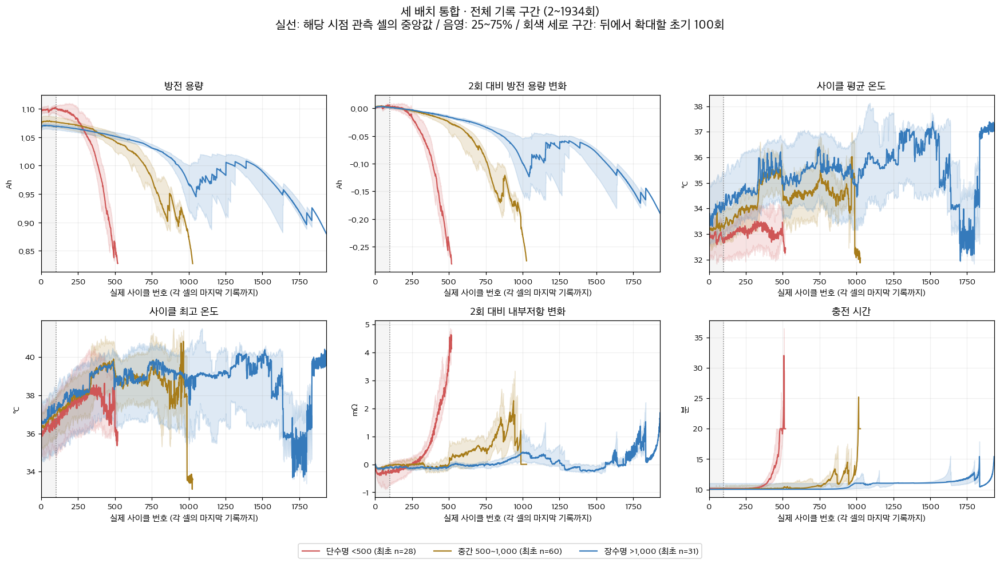

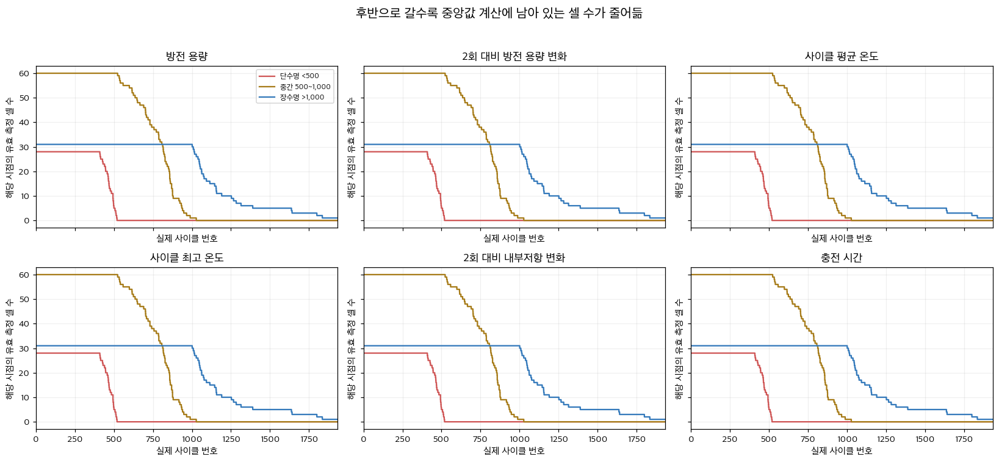

In [ ]:
# 전체 기록으로 확장: 원래 사이클 번호를 유지하고 없는 시점은 NaN으로 둔다.
full_groups=[[(name,cid) for name in eda_batches for cid in eda_groups[name][g]] for g in range(3)]
full_max=int(max(np.nanmax(eda_batches[name]['series'][cid]['cycle'])
                 for group in full_groups for name,cid in group))
full_cycles=np.arange(2,full_max+1)
full_matrices=[]
for g,group in enumerate(full_groups):
    matrix=np.full((len(group),6,len(full_cycles)),np.nan)
    for row,(name,cid) in enumerate(group):
        s=eda_batches[name]['series'][cid];cy=s['cycle']
        start=np.flatnonzero(cy==2)
        if len(start)!=1:raise ValueError(f'{name} 셀 {cid}: 2회차 기준 확인 필요')
        if len(np.unique(cy))!=len(cy):raise ValueError(f'{name} 셀 {cid}: 사이클 중복')
        mask=np.isfinite(cy)&(cy>=2)
        if not np.equal(cy[mask],np.floor(cy[mask])).all():raise ValueError('정수가 아닌 사이클 번호')
        pos=cy[mask].astype(int)-2
        vals=[s['QDischarge'],s['QDischarge']-s['QDischarge'][start[0]],s['Tavg'],s['Tmax'],
              (s['IR']-s['IR'][start[0]])*1000,s['chargetime']]
        for j,v in enumerate(vals):matrix[row,j,pos]=np.where(np.isfinite(v[mask]),v[mask],np.nan)
    full_matrices.append(matrix)
    last=max(np.max(eda_batches[name]['series'][cid]['cycle']) for name,cid in group)
    print(f'{eda_group_names[g]}: {len(group)}셀, 마지막 기록 최대 {last:.0f}회')
print(f'전체 그림 x축: 실제 사이클 번호 2~{full_max}회')
full_titles=['방전 용량','2회 대비 방전 용량 변화','사이클 평균 온도','사이클 최고 온도','2회 대비 내부저항 변화','충전 시간']
fig,axes=plt.subplots(2,3,figsize=(16,9))
for g,arr in enumerate(full_matrices):
    for j,ax in enumerate(axes.flat):
        count=np.isfinite(arr[:,j,:]).sum(axis=0);exists=count>0
        low=np.full(len(full_cycles),np.nan);med=low.copy();high=low.copy()
        low[exists],med[exists],high[exists]=np.nanpercentile(arr[:,j,exists],[25,50,75],axis=0)
        # 한 셀만 남으면 IQR 띠 대신 중앙값 선만 표시한다.
        ax.plot(full_cycles,med,color=eda_colors[g],lw=1.4,label=f'{eda_group_names[g]} (최초 n={len(full_groups[g])})')
        ax.fill_between(full_cycles,low,high,where=count>=2,color=eda_colors[g],alpha=.16)
for j,ax in enumerate(axes.flat):
    ax.set(title=full_titles[j],xlabel='실제 사이클 번호 (각 셀의 마지막 기록까지)',ylabel=eda_units[j],xlim=(0,full_max))
    ax.axvspan(2,100,color='gray',alpha=.08)
    ax.axvline(100,color='gray',ls=':',lw=1)
    ax.grid(alpha=.2)
handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=3)
fig.suptitle(f'세 배치 통합 · 전체 기록 구간 (2~{full_max}회)\n실선: 해당 시점 관측 셀의 중앙값 / 음영: 25~75% / 회색 세로 구간: 뒤에서 확대할 초기 100회',fontsize=14)
fig.tight_layout(rect=(0,.05,1,.92));fig.savefig(eda_out/'scratch_pooled_full_cycles.png',dpi=140,bbox_inches='tight');plt.show()

# 각 지표에 실제 기여한 셀 수: 후반 구성 변화와 결측을 해석하기 위한 그래프
fig,axes=plt.subplots(2,3,figsize=(15,7),sharex=True,sharey=True)
for j,ax in enumerate(axes.flat):
    for g,arr in enumerate(full_matrices):
        counts=np.isfinite(arr[:,j,:]).sum(axis=0)
        ax.step(full_cycles,counts,where='mid',color=eda_colors[g],label=eda_group_names[g])
    ax.set(title=full_titles[j],xlabel='실제 사이클 번호',ylabel='해당 시점의 유효 측정 셀 수',xlim=(0,full_max))
    ax.grid(alpha=.2)
axes[0,0].legend(fontsize=8)
fig.suptitle('후반으로 갈수록 중앙값 계산에 남아 있는 셀 수가 줄어듦',fontsize=14)
fig.tight_layout(rect=(0,0,1,.95));fig.savefig(eda_out/'scratch_pooled_full_counts.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

단수명 그룹은 더 이른 실제 사이클에서 용량이 감소하고 저항 변화·충전 시간이 커지는 모습을 보인다. 이는 수명 차이가 열화 진행 시점의 차이와 함께 나타난다는 결과다. 다만 후반 실선의 반등이나 급변은 남아 있는 셀 구성이 바뀐 영향도 포함하므로, 개별 배터리의 용량 회복으로 해석해서는 안 된다.

후반으로 갈수록 비교에 남는 셀이 줄어들기 때문에 초기와 말기의 중앙값은 같은 셀 집합을 대표하지 않는다. 특히 소수 셀만 남은 구간의 급격한 변화는 그룹 전체의 공통 특성으로 일반화하기 어렵다. 전체 곡선의 변화는 개별 셀 곡선 및 관측 진행률 기준 결과와 함께 읽어야 한다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 전체 기록 구간과 시점별 관측 셀 수

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


단수명 <550: 32셀, 마지막 기록 최대 540회
장수명 ≥550: 87셀, 마지막 기록 최대 1934회
전체 그림 x축: 실제 사이클 번호 2~1934회


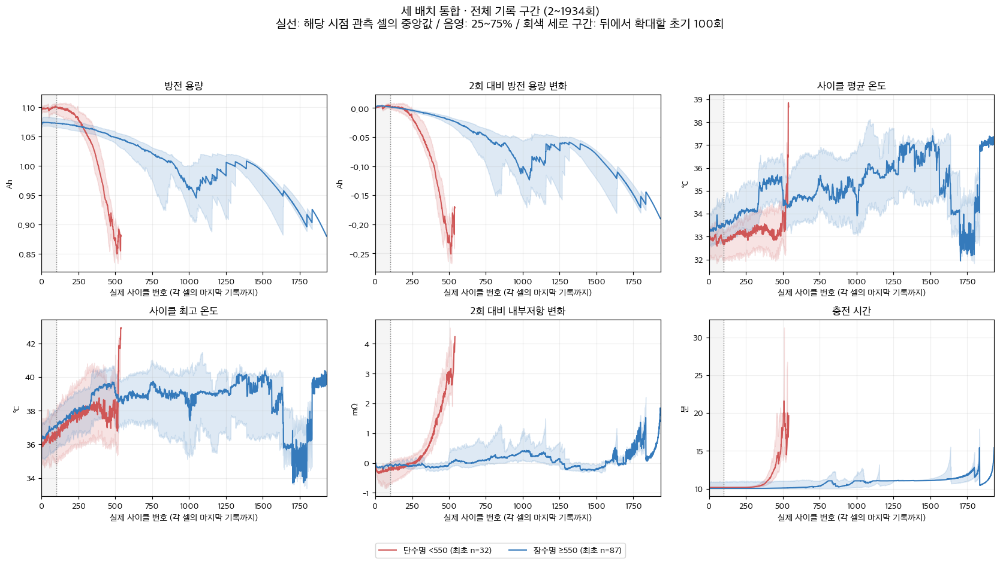

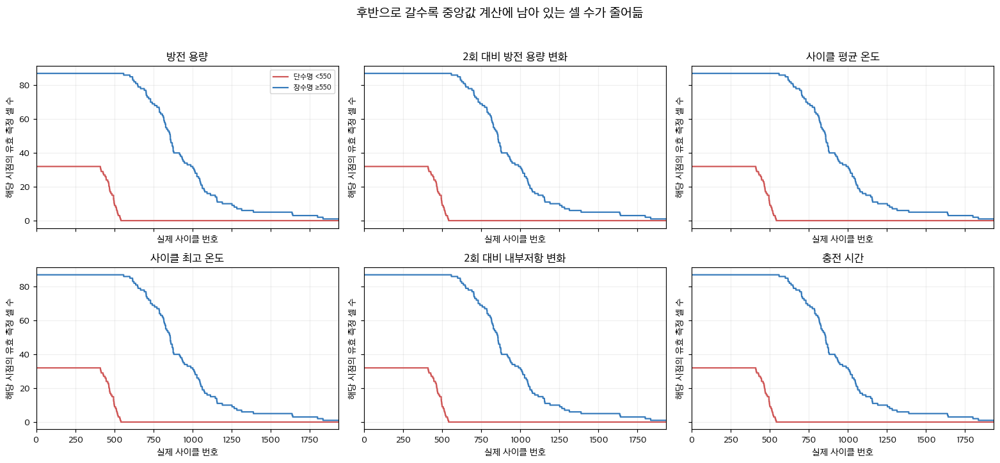

In [ ]:
# 전체 기록으로 확장: 원래 사이클 번호를 유지하고 없는 시점은 NaN으로 둔다.
b2_full_groups=[[(name,cid) for name in b2_eda_batches for cid in b2_eda_groups[name][g]] for g in range(2)]
b2_full_max=int(max(np.nanmax(b2_eda_batches[name]['series'][cid]['cycle'])
                 for group in b2_full_groups for name,cid in group))
b2_full_cycles=np.arange(2,b2_full_max+1)
b2_full_matrices=[]
for g,group in enumerate(b2_full_groups):
    matrix=np.full((len(group),6,len(b2_full_cycles)),np.nan)
    for row,(name,cid) in enumerate(group):
        s=b2_eda_batches[name]['series'][cid];cy=s['cycle']
        start=np.flatnonzero(cy==2)
        if len(start)!=1:raise ValueError(f'{name} 셀 {cid}: 2회차 기준 확인 필요')
        if len(np.unique(cy))!=len(cy):raise ValueError(f'{name} 셀 {cid}: 사이클 중복')
        mask=np.isfinite(cy)&(cy>=2)
        if not np.equal(cy[mask],np.floor(cy[mask])).all():raise ValueError('정수가 아닌 사이클 번호')
        pos=cy[mask].astype(int)-2
        vals=[s['QDischarge'],s['QDischarge']-s['QDischarge'][start[0]],s['Tavg'],s['Tmax'],
              (s['IR']-s['IR'][start[0]])*1000,s['chargetime']]
        for j,v in enumerate(vals):matrix[row,j,pos]=np.where(np.isfinite(v[mask]),v[mask],np.nan)
    b2_full_matrices.append(matrix)
    last=max(np.max(b2_eda_batches[name]['series'][cid]['cycle']) for name,cid in group)
    print(f'{b2_eda_group_names[g]}: {len(group)}셀, 마지막 기록 최대 {last:.0f}회')
print(f'전체 그림 x축: 실제 사이클 번호 2~{b2_full_max}회')
b2_full_titles=['방전 용량','2회 대비 방전 용량 변화','사이클 평균 온도','사이클 최고 온도','2회 대비 내부저항 변화','충전 시간']
fig,axes=plt.subplots(2,3,figsize=(16,9))
for g,arr in enumerate(b2_full_matrices):
    for j,ax in enumerate(axes.flat):
        count=np.isfinite(arr[:,j,:]).sum(axis=0);exists=count>0
        low=np.full(len(b2_full_cycles),np.nan);med=low.copy();high=low.copy()
        low[exists],med[exists],high[exists]=np.nanpercentile(arr[:,j,exists],[25,50,75],axis=0)
        # 한 셀만 남으면 IQR 띠 대신 중앙값 선만 표시한다.
        ax.plot(b2_full_cycles,med,color=b2_eda_colors[g],lw=1.4,label=f'{b2_eda_group_names[g]} (최초 n={len(b2_full_groups[g])})')
        ax.fill_between(b2_full_cycles,low,high,where=count>=2,color=b2_eda_colors[g],alpha=.16)
for j,ax in enumerate(axes.flat):
    ax.set(title=b2_full_titles[j],xlabel='실제 사이클 번호 (각 셀의 마지막 기록까지)',ylabel=b2_eda_units[j],xlim=(0,b2_full_max))
    ax.axvspan(2,100,color='gray',alpha=.08)
    ax.axvline(100,color='gray',ls=':',lw=1)
    ax.grid(alpha=.2)
handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=2)
fig.suptitle(f'세 배치 통합 · 전체 기록 구간 (2~{b2_full_max}회)\n실선: 해당 시점 관측 셀의 중앙값 / 음영: 25~75% / 회색 세로 구간: 뒤에서 확대할 초기 100회',fontsize=14)
fig.tight_layout(rect=(0,.05,1,.92));fig.savefig(b2_eda_out/'scratch_binary_pooled_full_cycles.png',dpi=140,bbox_inches='tight');plt.show()

# 각 지표에 실제 기여한 셀 수: 후반 구성 변화와 결측을 해석하기 위한 그래프
fig,axes=plt.subplots(2,3,figsize=(15,7),sharex=True,sharey=True)
for j,ax in enumerate(axes.flat):
    for g,arr in enumerate(b2_full_matrices):
        counts=np.isfinite(arr[:,j,:]).sum(axis=0)
        ax.step(b2_full_cycles,counts,where='mid',color=b2_eda_colors[g],label=b2_eda_group_names[g])
    ax.set(title=b2_full_titles[j],xlabel='실제 사이클 번호',ylabel='해당 시점의 유효 측정 셀 수',xlim=(0,b2_full_max))
    ax.grid(alpha=.2)
axes[0,0].legend(fontsize=8)
fig.suptitle('후반으로 갈수록 중앙값 계산에 남아 있는 셀 수가 줄어듦',fontsize=14)
fig.tight_layout(rect=(0,0,1,.95));fig.savefig(b2_eda_out/'scratch_binary_pooled_full_counts.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

단수명 그룹은 더 이른 실제 사이클에서 용량이 감소하고 저항 변화·충전 시간이 커지는 모습을 보인다. 이는 수명 차이가 열화 진행 시점의 차이와 함께 나타난다는 결과다. 다만 후반 실선의 반등이나 급변은 남아 있는 셀 구성이 바뀐 영향도 포함하므로, 개별 배터리의 용량 회복으로 해석해서는 안 된다.

후반으로 갈수록 비교에 남는 셀이 줄어들기 때문에 초기와 말기의 중앙값은 같은 셀 집합을 대표하지 않는다. 특히 소수 셀만 남은 구간의 급격한 변화는 그룹 전체의 공통 특성으로 일반화하기 어렵다. 전체 곡선의 변화는 개별 셀 곡선 및 관측 진행률 기준 결과와 함께 읽어야 한다.


통합 비교 대상: 119 셀
단수명 <500 : 28 셀
중간 500~1,000 : 60 셀
장수명 >1,000 : 31 셀


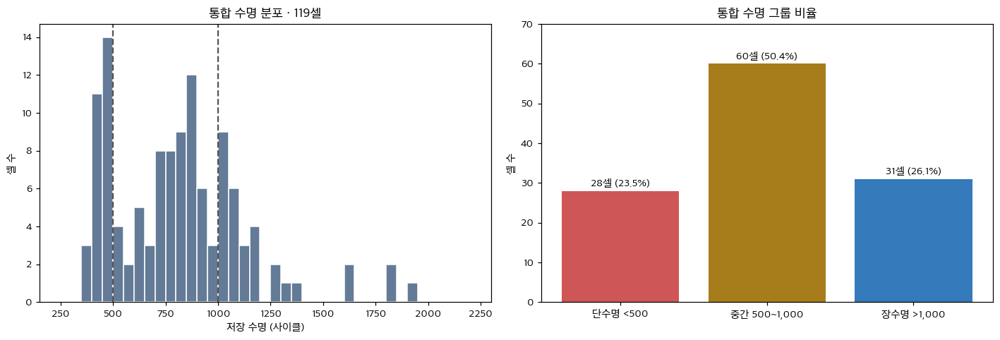

In [ ]:
pooled_groups=[[(name,cid) for name in eda_batches for cid in eda_groups[name][g]] for g in range(3)]
assert sum(map(len,pooled_groups))==119
print('통합 비교 대상:',sum(map(len,pooled_groups)),'셀')
for g,group in enumerate(pooled_groups):
    print(eda_group_names[g],':',len(group),'셀')
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
pooled_life=[eda_batches[name]['cells'][cid]['life'] for group in pooled_groups for name,cid in group]
axes[0].hist(pooled_life,bins=np.arange(150,2301,50),color='#647b98',edgecolor='white')
axes[0].set(xlim=(150,2300),xlabel='저장 수명 (사이클)',ylabel='셀 수',title='통합 수명 분포 · 119셀')
for x in [500,1000]:axes[0].axvline(x,color='#555555',ls='--')
counts=[len(g) for g in pooled_groups]
axes[1].bar(range(3),counts,color=eda_colors)
for g,v in enumerate(counts):axes[1].text(g,v+1,f'{v}셀 ({v/119:.1%})',ha='center')
axes[1].set_xticks(range(3),eda_group_names);axes[1].set(ylabel='셀 수',ylim=(0,70),title='통합 수명 그룹 비율')
fig.tight_layout();fig.savefig(eda_out/'scratch_pooled_composition.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

수명이 392~1,935회에 걸쳐 분포하고 중간 그룹이 절반가량을 차지한다. 따라서 단수명과 장수명 두 극단만 비교하면 중간 수명 셀의 특성이 충분히 드러나지 않는다. 550회로 나눈 결과는 동일한 연속 수명에 경계를 적용한 비교이며, 3그룹과 다른 실험 결과가 아니다. 짧은 수명이라는 이유만으로 해당 셀을 측정 이상치로 제외할 근거는 없다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 통합 수명 분포

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


통합 비교 대상: 119 셀
단수명 <550 : 32 셀
장수명 ≥550 : 87 셀


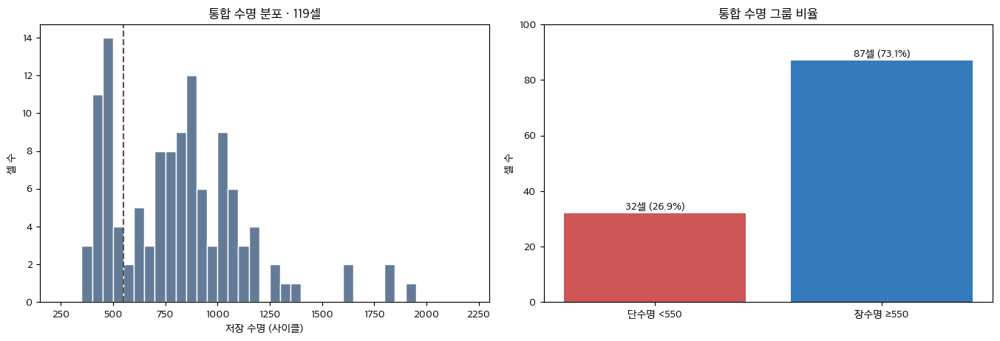

In [ ]:
b2_pooled_groups=[[(name,cid) for name in b2_eda_batches for cid in b2_eda_groups[name][g]] for g in range(2)]
assert sum(map(len,b2_pooled_groups))==119
print('통합 비교 대상:',sum(map(len,b2_pooled_groups)),'셀')
for g,group in enumerate(b2_pooled_groups):
    print(b2_eda_group_names[g],':',len(group),'셀')
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
b2_pooled_life=[b2_eda_batches[name]['cells'][cid]['life'] for group in b2_pooled_groups for name,cid in group]
axes[0].hist(b2_pooled_life,bins=np.arange(150,2301,50),color='#647b98',edgecolor='white')
axes[0].set(xlim=(150,2300),xlabel='저장 수명 (사이클)',ylabel='셀 수',title='통합 수명 분포 · 119셀')
for x in [550]:axes[0].axvline(x,color='#555555',ls='--')
counts=[len(g) for g in b2_pooled_groups]
axes[1].bar(range(2),counts,color=b2_eda_colors)
for g,v in enumerate(counts):axes[1].text(g,v+1,f'{v}셀 ({v/119:.1%})',ha='center')
axes[1].set_xticks(range(2),b2_eda_group_names);axes[1].set(ylabel='셀 수',ylim=(0,100),title='통합 수명 그룹 비율')
fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_pooled_composition.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

수명이 392~1,935회에 걸쳐 분포하고 중간 그룹이 절반가량을 차지한다. 따라서 단수명과 장수명 두 극단만 비교하면 중간 수명 셀의 특성이 충분히 드러나지 않는다. 550회로 나눈 결과는 동일한 연속 수명에 경계를 적용한 비교이며, 3그룹과 다른 실험 결과가 아니다. 짧은 수명이라는 이유만으로 해당 셀을 측정 이상치로 제외할 근거는 없다.


#### ② 통합 그룹 분포
아래는 같은 통합 119셀의 초기 100회·5회 지표를 셀별로 요약한 분포다. 전체 기록 구간의 평균이 아니며, 피처 비교를 위해 여기서 함께 확인한다. 시간 구간별 추이는 통합 피처 검토 다음에 이어진다.

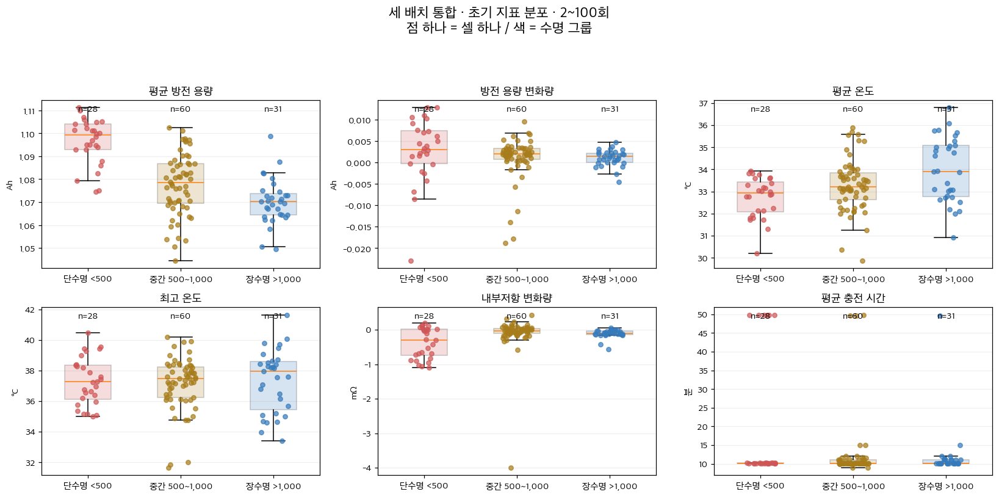

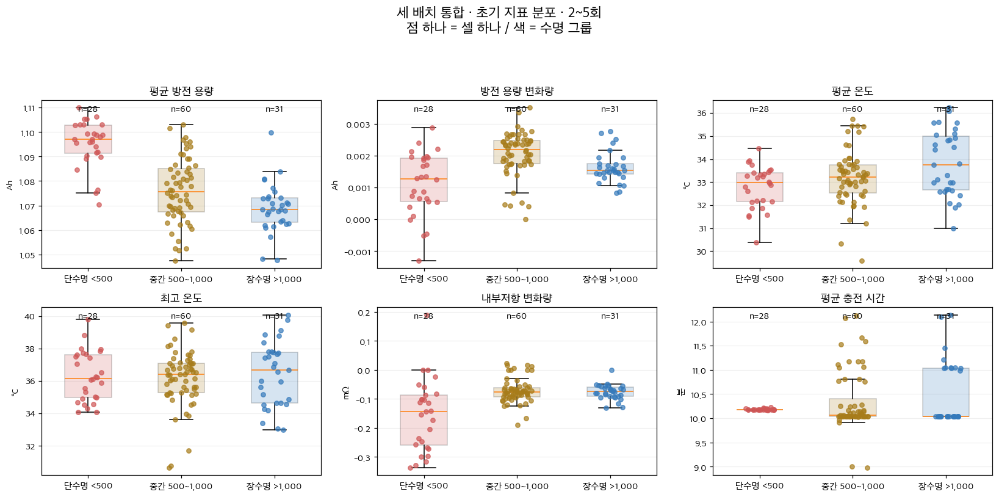

In [ ]:
# 통합 그룹 분포: 색은 수명 그룹, 모든 점은 셀 하나
for end in [100,5]:
    fig,axes=plt.subplots(2,3,figsize=(15,8));rng=np.random.default_rng(42)
    for j,ax in enumerate(axes.flat):
        for g,group in enumerate(pooled_groups):
            valid=[(name,cid,eda_features[name,end][cid][j]) for name,cid in group
                   if cid in eda_features[name,end] and np.isfinite(eda_features[name,end][cid][j])]
            vals=[v for name,cid,v in valid]
            if vals:
                box=ax.boxplot([vals],positions=[g],widths=.5,patch_artist=True,showfliers=False)
                box['boxes'][0].set(facecolor=eda_colors[g],alpha=.2)
            ax.scatter(g+rng.uniform(-.16,.16,len(vals)),vals,color=eda_colors[g],marker='o',s=23,alpha=.7,zorder=3)
            ax.text(g,.97,f'n={len(vals)}',transform=ax.get_xaxis_transform(),ha='center',va='top')
        ax.set_xticks(range(3),eda_group_names);ax.set_xlim(-.5,2.5)
        ax.set(title=eda_metric_names[j],ylabel=eda_units[j]);ax.grid(axis='y',alpha=.2)
    fig.suptitle(f'세 배치 통합 · 초기 지표 분포 · 2~{end}회\n점 하나 = 셀 하나 / 색 = 수명 그룹',fontsize=15)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(eda_out/f'scratch_pooled_features_{end}.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

초기 100회 요약값에서는 절대 용량·온도·저항 변화 등의 그룹 중앙값 차이가 나타나지만 셀별 분포도 함께 겹친다. 단수명 그룹의 초기 용량이 더 높다는 점은 초기 용량 수준과 장기 내구성이 같은 개념이 아님을 보여준다. 이 분포 차이의 크기와 연속 수명과의 관계는 별개이므로, 이후 상관계수와 함께 해석해야 한다.

2~5회에서도 그룹별 측정값 수준 차이는 보이지만 네 사이클만으로 장기간의 감소 추세를 확인한 것은 아니다. 저항 변화 중앙값이 음수라는 사실도 모든 셀에서 저항이 처음부터 계속 증가하는 것은 아님을 보여준다. 초기 5회 분포 차이를 말기 열화의 직접적인 증거로 해석하지 않는다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 초기 지표 분포

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


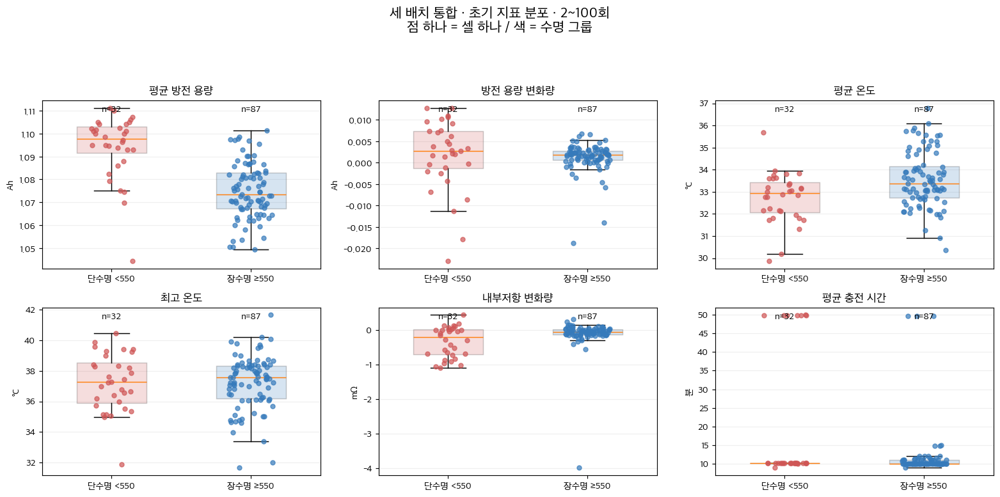

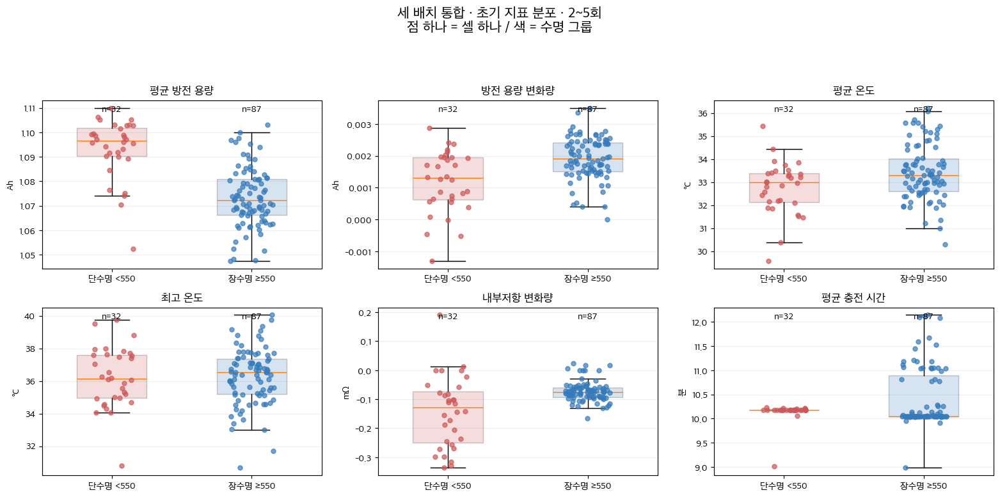

In [ ]:
# 통합 그룹 분포: 색은 수명 그룹, 모든 점은 셀 하나
for end in [100,5]:
    fig,axes=plt.subplots(2,3,figsize=(15,8));rng=np.random.default_rng(42)
    for j,ax in enumerate(axes.flat):
        for g,group in enumerate(b2_pooled_groups):
            valid=[(name,cid,b2_eda_features[name,end][cid][j]) for name,cid in group
                   if cid in b2_eda_features[name,end] and np.isfinite(b2_eda_features[name,end][cid][j])]
            vals=[v for name,cid,v in valid]
            if vals:
                box=ax.boxplot([vals],positions=[g],widths=.5,patch_artist=True,showfliers=False)
                box['boxes'][0].set(facecolor=b2_eda_colors[g],alpha=.2)
            ax.scatter(g+rng.uniform(-.16,.16,len(vals)),vals,color=b2_eda_colors[g],marker='o',s=23,alpha=.7,zorder=3)
            ax.text(g,.97,f'n={len(vals)}',transform=ax.get_xaxis_transform(),ha='center',va='top')
        ax.set_xticks(range(2),b2_eda_group_names);ax.set_xlim(-.5,1.5)
        ax.set(title=b2_eda_metric_names[j],ylabel=b2_eda_units[j]);ax.grid(axis='y',alpha=.2)
    fig.suptitle(f'세 배치 통합 · 초기 지표 분포 · 2~{end}회\n점 하나 = 셀 하나 / 색 = 수명 그룹',fontsize=15)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(b2_eda_out/f'scratch_binary_pooled_features_{end}.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

초기 100회 요약값에서는 절대 용량·온도·저항 변화 등의 그룹 중앙값 차이가 나타나지만 셀별 분포도 함께 겹친다. 단수명 그룹의 초기 용량이 더 높다는 점은 초기 용량 수준과 장기 내구성이 같은 개념이 아님을 보여준다. 이 분포 차이의 크기와 연속 수명과의 관계는 별개이므로, 이후 상관계수와 함께 해석해야 한다.

2~5회에서도 그룹별 측정값 수준 차이는 보이지만 네 사이클만으로 장기간의 감소 추세를 확인한 것은 아니다. 저항 변화 중앙값이 음수라는 사실도 모든 셀에서 저항이 처음부터 계속 증가하는 것은 아님을 보여준다. 초기 5회 분포 차이를 말기 열화의 직접적인 증거로 해석하지 않는다.


#### 통합 결과에서 먼저 볼 것

- 비교 대상은 단수명 28셀, 중간 60셀, 장수명 31셀이다. 앞의 전체 저장 라벨 분포와 제외 기준이 달라 분모를 구분한다.
- 선·음영·박스·개별 점을 함께 보고 그룹 간 겹침을 확인한다. 서로 다른 실험 조건을 합쳤으므로 관찰된 차이를 인과효과로 단정하지 않는다.
- 박스 밖의 점과 급격한 변동은 원시 기록 점검 후보다. 자동 삭제하지 않는다.
- 평균 온도와 최고 온도, 용량 변화량과 기울기 등 비슷한 피처는 아래의 **통합 상관·VIF**로 중복을 점검한다.

#### 2그룹 추가 해석 — 위의 3그룹 해석과 함께 읽기

**단수명 32셀(26.9%), 장수명 87셀(73.1%)**이다. 기존 그룹의 재배정은 다음과 같다.

|기존 3그룹|추가 단수명 <550|추가 장수명 ≥550|
|---|---:|---:|
|단수명 <500|28|0|
|중간 500~1,000|4|56|
|장수명 >1,000|0|31|

2그룹의 장수명은 기존 >1,000회 장수명보다 넓은 범위다. 두 그림의 같은 색을 동일한 셀 집합으로 해석하지 않는다.

### 5-5. 피처 후보 검토 — 의미 → 수명과의 관계 → 중복 정보 → 후보 선정

5-2의 로딩 셀을 먼저 실행한다. summary는 기존 CSV, ΔQ(V)는 각 배치의 원본 MAT에서 10·100사이클의 Qdlin만 읽는다.
이번 절은 **100회까지의 EDA 피처 후보 검토**이며 모델 중요도를 계산하거나 최종 피처를 확정한 것은 아니다.

|우선순위|피처|의미|중복 정보 점검|
|---|---|---|---|
|1순위|ΔQ(V) log 분산|100회−10회 곡선 차이가 전압 구간별로 얼마나 다르게 나타나는가|ΔQ 평균·최솟값과 함께 비교 후 대표 변수 하나|
|2순위 검토|방전 용량 기울기|2~100회 용량의 변화 추세, Ah/사이클|QD100−QD2와 중복 확인|
|보조|평균 온도|2~100회의 사이클 평균 온도를 평균|최고 온도와 동시 채택하지 않고 비교|
|포함|내부저항 변화량|100회−2회 저항 변화, Ω|초기 저항 변화와 수명의 관계 확인. 저항 수준·기울기 등은 별도 검토|
|별도 조건 분석|충전 시간·등가 C-rate|충전 절차·설정의 차이|두 변수 간 중복 및 ΔQ와의 중복 확인|

**측정 신호와 원인을 구분한다.** 충전 정책은 설정 조건, 용량·온도·저항은 반응 신호다. 이 데이터만으로 특정 열화 반응을 직접 식별할 수는 없다.
충전 시간은 2~6회 평균(초기 충전 소요 시간을 요약한 후보), 온도 최고값은 2~100회의 Tmax 최댓값이다. 이 정의는 기존 그림의 mean_Tmax와 다르다.
기울기 계산에만 QD≤0 또는 QD>1.2 Ah를 점검 기준으로 제외한다. 이 탐색 상한은 물리 법칙이 아니며 제외 지점과 포함/제외 민감도를 기록한다.

In [ ]:
import h5py
import re
import json
fr_keys=['logvar_dq','dq_mean','dq_min','q_slope','q_change','t_mean','t_max','ir_change','charge_mean','c_equiv']
fr_labels=['방전곡선 변화 log 분산','방전곡선 변화 평균','방전곡선 변화 최솟값','방전 용량 기울기',
           '방전 용량 변화량','평균 온도','최고 온도','내부저항 변화량','초기 평균 충전 시간','설정 기반 등가 C-rate']
fr_rows=[];fr_audit=[]
for name,b in eda_batches.items():
    path=eda_root/'archive'/f'{b["date"]}_batchdata_updated_struct_errorcorrect.mat'
    with h5py.File(path,'r') as mat:
        for cid,r in b['cells'].items():
            if not r['valid'] or r['incomplete']:continue
            s=b['series'][cid];cy=s['cycle'];pos=[np.flatnonzero(cy==k) for k in [2,10,100]]
            if any(len(p)!=1 for p in pos):
                fr_audit.append(f'{name} 셀 {cid}: 2/10/100회 누락·중복, 피처 계산 제외');continue
            # CSV summary와 MAT summary의 실제 cycle 순서를 대조한다.
            summary=mat[mat['batch']['summary'][cid,0]]
            mat_cycles=summary['cycle'][()].ravel()
            if not np.array_equal(cy,mat_cycles):raise ValueError(f'{name} 셀 {cid}: 사이클 순서 불일치')
            cycles=mat[mat['batch']['cycles'][cid,0]]
            q10=mat[cycles['Qdlin'][pos[1][0],0]][()].ravel()
            q100=mat[cycles['Qdlin'][pos[2][0],0]][()].ravel()
            axis=mat[mat['batch']['Vdlin'][cid,0]][()].ravel()
            if len(q10)!=len(axis) or len(q100)!=len(axis):raise ValueError('전압 축/곡선 길이 불일치')
            dq=q100-q10
            if not np.isfinite(dq).all() or np.var(dq)<=0:
                fr_audit.append(f'{name} 셀 {cid}: ΔQ 분산 계산 불가');continue
            early=(cy>=2)&(cy<=100)
            valid=early&np.isfinite(s['QDischarge'])&(s['QDischarge']>0)&(s['QDischarge']<=1.2)
            raw_valid=early&np.isfinite(s['QDischarge'])
            slope=np.polyfit(cy[valid],s['QDischarge'][valid],1)[0]
            slope_raw=np.polyfit(cy[raw_valid],s['QDischarge'][raw_valid],1)[0]
            if valid.sum()!=early.sum():fr_audit.append(f'{name} 셀 {cid}: 용량 기울기 점검값 제외 {early.sum()-valid.sum()}개, 포함 {slope_raw:.6g} → 제외 {slope:.6g} Ah/회')
            m=re.match(r'([\d.]+)C\(([\d.]+)%\)-([\d.]+)C',r['policy'])
            if m:
                c1,q1,c2=map(float,m.groups());ceq=.8/((q1/100)/c1+(.8-q1/100)/c2)
            else:ceq=np.nan;fr_audit.append(f'{name} 셀 {cid}: 정책 해석 실패, 등가 C 결측')
            vals=[np.log10(np.var(dq)),np.mean(dq),np.min(dq),slope,
                  s['QDischarge'][pos[2][0]]-s['QDischarge'][pos[0][0]],
                  np.mean(s['Tavg'][early]),np.max(s['Tmax'][early]),
                  s['IR'][pos[2][0]]-s['IR'][pos[0][0]],
                  np.mean(s['chargetime'][(cy>=2)&(cy<=6)]),ceq]
            fr_rows.append(dict(batch=name,cell_id=cid,life=r['life'],policy=r['policy'],values=[float(v) for v in vals]))
fr_X=np.array([r['values'] for r in fr_rows]);fr_y=np.array([r['life'] for r in fr_rows]);fr_batch=np.array([r['batch'] for r in fr_rows])
print('통합 피처 계산 셀 수:',len(fr_rows))
print('점검 기록:');print('\n'.join(fr_audit) if fr_audit else '특이사항 없음')
assert len({(r['batch'],r['cell_id']) for r in fr_rows})==len(fr_rows)

통합 피처 계산 셀 수: 119
점검 기록:
Batch 1 셀 18: 용량 기울기 점검값 제외 1개, 포함 -0.000294542 → 제외 -4.75408e-05 Ah/회


In [ ]:
b2_fr_X=fr_X.copy();b2_fr_y=fr_y.copy();b2_fr_labels=fr_labels.copy()
b2_fr_five=[0,3,5,7,8]


#### ① 통합 산점도 — 연속 수명과의 관계

점 하나는 셀 하나이며 색은 단수명·중간·장수명이다. 모든 셀을 한 좌표계에서 비교한다.
수명 그룹은 y축 수명을 나눈 표시일 뿐, 입력 피처로 사용하지 않는다.

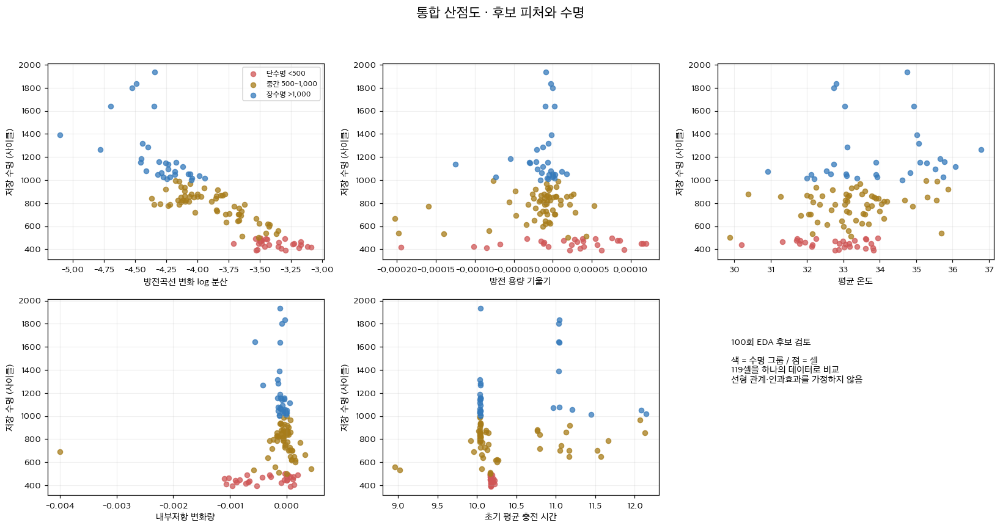

In [ ]:
fr_five=[0,3,5,7,8]
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,j in zip(axes.flat,fr_five):
    for g,color in enumerate(eda_colors):
        m=np.array([eda_group(v)==g for v in fr_y]);ax.scatter(fr_X[m,j],fr_y[m],label=eda_group_names[g],color=color,s=28,alpha=.75)
    ax.set(xlabel=fr_labels[j],ylabel='저장 수명 (사이클)');ax.grid(alpha=.2)
axes[0,0].legend(fontsize=8)
axes[1,2].axis('off');axes[1,2].text(.05,.8,'100회 EDA 후보 검토\n\n색 = 수명 그룹 / 점 = 셀\n119셀을 하나의 데이터로 비교\n선형 관계·인과효과를 가정하지 않음',va='top')
fig.suptitle('통합 산점도 · 후보 피처와 수명',fontsize=15);fig.tight_layout(rect=(0,0,1,.94))
fig.savefig(eda_out/'scratch_feature_candidates_scatter.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

비교한 다섯 지표 중 ΔQ log 분산이 수명과 가장 뚜렷한 단조 관계를 보인다. 다른 지표는 더 넓게 흩어져 있어 그룹 수준 차이가 보여도 수명을 연속적인 값으로 설명하는 정도는 다르다. 특히 저항의 초기 변화는 말기 저항 증가와 구분해야 하며, 이 산점도에서 강한 초기 수명 관계가 확인된 것은 아니다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 후보 피처와 연속 수명

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


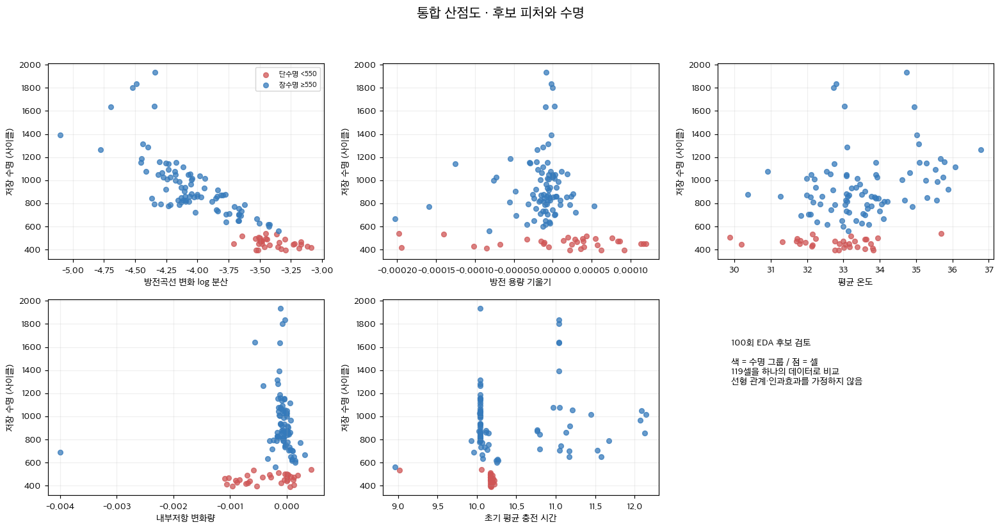

In [ ]:
b2_fr_five=[0,3,5,7,8]
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,j in zip(axes.flat,b2_fr_five):
    for g,color in enumerate(b2_eda_colors):
        m=np.array([b2_eda_group(v)==g for v in b2_fr_y]);ax.scatter(b2_fr_X[m,j],b2_fr_y[m],label=b2_eda_group_names[g],color=color,s=28,alpha=.75)
    ax.set(xlabel=b2_fr_labels[j],ylabel='저장 수명 (사이클)');ax.grid(alpha=.2)
axes[0,0].legend(fontsize=8)
axes[1,2].axis('off');axes[1,2].text(.05,.8,'100회 EDA 후보 검토\n\n색 = 수명 그룹 / 점 = 셀\n119셀을 하나의 데이터로 비교\n선형 관계·인과효과를 가정하지 않음',va='top')
fig.suptitle('통합 산점도 · 후보 피처와 수명',fontsize=15);fig.tight_layout(rect=(0,0,1,.94))
fig.savefig(b2_eda_out/'scratch_binary_feature_candidates_scatter.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

비교한 다섯 지표 중 ΔQ log 분산이 수명과 가장 뚜렷한 단조 관계를 보인다. 다른 지표는 더 넓게 흩어져 있어 그룹 수준 차이가 보여도 수명을 연속적인 값으로 설명하는 정도는 다르다. 특히 저항의 초기 변화는 말기 저항 증가와 구분해야 하며, 이 산점도에서 강한 초기 수명 관계가 확인된 것은 아니다.


방전곡선 변화 log 분산 -0.888
방전곡선 변화 평균 0.861
방전곡선 변화 최솟값 0.876
방전 용량 기울기 -0.219
방전 용량 변화량 -0.176
평균 온도 0.325
최고 온도 0.023
내부저항 변화량 -0.001
초기 평균 충전 시간 -0.221
설정 기반 등가 C-rate -0.029


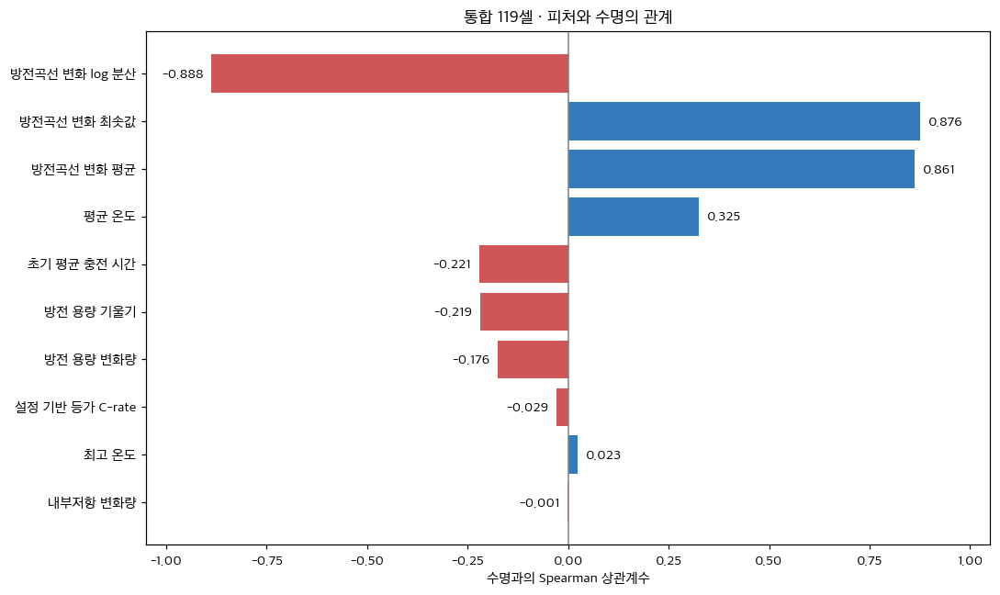

In [ ]:
def fr_rank(x):
    # 동률에는 평균 순위를 부여
    return np.array([(np.sum(x<v)+(np.sum(x==v)-1)/2) for v in x],float)
def fr_corr(a,b,rank=False):
    m=np.isfinite(a)&np.isfinite(b);a=a[m];b=b[m]
    if len(a)<3 or np.std(a)==0 or np.std(b)==0:return np.nan
    if rank:a,b=fr_rank(a),fr_rank(b)
    return float(np.corrcoef(a,b)[0,1])
fr_scopes=['통합']
fr_corrs=np.array([fr_corr(fr_X[:,j],fr_y,True) for j in range(len(fr_keys))])
order=np.argsort(np.abs(fr_corrs))
fig,ax=plt.subplots(figsize=(10,6))
ax.barh([fr_labels[j] for j in order],fr_corrs[order],color=['#cf5656' if fr_corrs[j]<0 else '#357abb' for j in order])
for k,j in enumerate(order):ax.text(fr_corrs[j]+(.02 if fr_corrs[j]>=0 else -.02),k,f'{fr_corrs[j]:.3f}',va='center',ha='left' if fr_corrs[j]>=0 else 'right')
ax.axvline(0,color='gray',lw=1);ax.set(xlim=(-1.05,1.05),xlabel='수명과의 Spearman 상관계수',title='통합 119셀 · 피처와 수명의 관계')
fig.tight_layout();fig.savefig(eda_out/'scratch_feature_life_correlations.png',dpi=140,bbox_inches='tight');plt.show()
for j in range(len(fr_keys)):print(fr_labels[j],round(float(fr_corrs[j]),3))

#### 그래프 결과 해석

연속 수명과 이진 라벨은 서로 다른 목표이므로 피처의 상관 순위가 달라질 수 있다. 550회 라벨에서는 경계 안쪽의 수명 차이가 사라지지만 연속 수명 상관에는 그 차이가 남는다. 두 상관계수의 크기를 비교해 회귀나 분류의 정확도가 더 높다고 판단할 수는 없다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 2그룹 라벨과 피처의 관계

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


점이연 상관은 연속 수명 Spearman 및 모델 중요도와 다른 통계입니다.
방전곡선 변화 log 분산 -0.72
방전곡선 변화 평균 0.75
방전곡선 변화 최솟값 0.763
방전 용량 기울기 -0.215
방전 용량 변화량 -0.037
평균 온도 0.291
최고 온도 0.002
내부저항 변화량 0.23
초기 평균 충전 시간 0.216
설정 기반 등가 C-rate -0.257


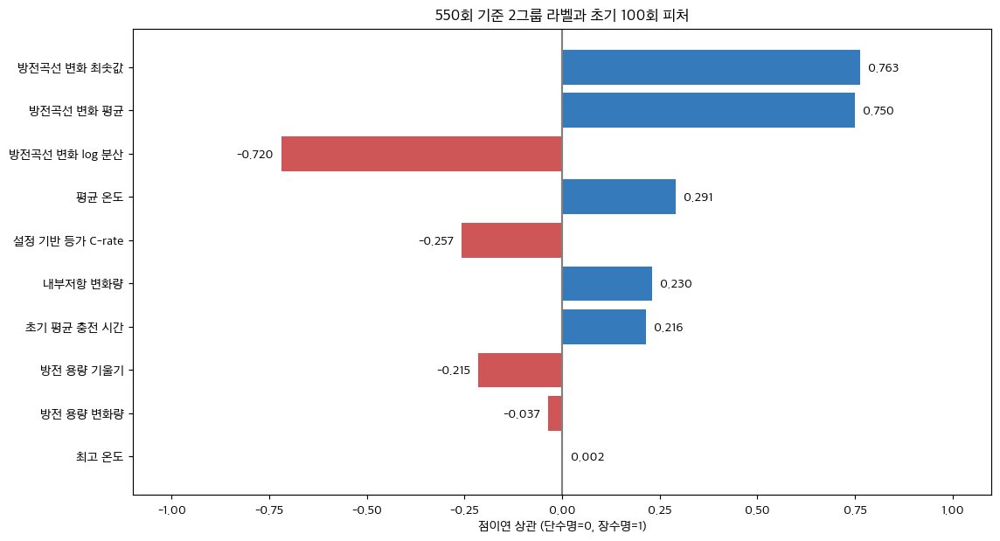

In [ ]:

b2_target=(fr_y>=550).astype(float)
b2_point_r=np.array([fr_corr(fr_X[:,j],b2_target) for j in range(fr_X.shape[1])])
order=np.argsort(np.abs(b2_point_r));fig,ax=plt.subplots(figsize=(11,6))
ax.barh([fr_labels[j] for j in order],b2_point_r[order],color=['#cf5656' if b2_point_r[j]<0 else '#357abb' for j in order])
for k,j in enumerate(order):ax.text(b2_point_r[j]+(.02 if b2_point_r[j]>=0 else -.02),k,f'{b2_point_r[j]:.3f}',va='center',ha='left' if b2_point_r[j]>=0 else 'right')
ax.axvline(0,color='gray');ax.set(xlim=(-1.1,1.1),xlabel='점이연 상관 (단수명=0, 장수명=1)',title='550회 기준 2그룹 라벨과 초기 100회 피처')
fig.tight_layout();fig.savefig(eda_out/'scratch_binary_target_correlations.png',dpi=140,bbox_inches='tight');plt.show()
print('점이연 상관은 연속 수명 Spearman 및 모델 중요도와 다른 통계입니다.')
for label,v in zip(fr_labels,b2_point_r):print(label,round(float(v),3))


#### 그래프 결과 해석

연속 수명과 이진 라벨은 서로 다른 목표이므로 피처의 상관 순위가 달라질 수 있다. 550회 라벨에서는 경계 안쪽의 수명 차이가 사라지지만 연속 수명 상관에는 그 차이가 남는다. 두 상관계수의 크기를 비교해 회귀나 분류의 정확도가 더 높다고 판단할 수는 없다.


#### ② 피처끼리 중복되는가? — 대표 피처 선택과 VIF

수명과의 상관이 강한 피처를 모두 넣는 대신, 의미가 겹치는 후보를 먼저 묶는다.

|후보 묶음|우선 남길 대표|보류 이유|
|---|---|---|
|ΔQ log 분산·평균·최솟값|log 분산|같은 곡선 차이에서 만든 통계값. 피처끼리 높은 상관 가능|
|용량 기울기·용량 변화량|기울기|동일한 초기 용량 추세를 요약. 기울기는 구간 전체를 쓰지만 이상값 점검 필요|
|평균 온도·최고 온도|평균 온도|온도 수준을 중복 요약. 센서 신뢰성은 별도 점검|
|충전 시간·등가 C-rate|일단 충전 시간 하나|설정과 측정 지표의 관계를 확인. 등가 C는 CV·휴지·펄스를 반영하지 않은 이상적 0~80% 요약|

VIF는 각 피처를 다른 피처들의 선형 결합으로 설명할 수 있는 정도를 점검한다. `VIF = 1/(1−R²)`이며 목표 수명은 계산에 넣지 않는다.
절편을 포함하고 수치 안정성을 위해 표준화한다. **표준화 자체가 공선성을 제거하지는 않는다.**
VIF 5는 이번 탐색의 점검선이며 절대적인 합격 기준이 아니다. 모든 조합을 완전 사례로 계산하고 표본 수를 출력한다.

비교 조합: 전체 10개 → 대표 5개 → 충전 시간을 뺀 4개 대안.
통합 5개 조합의 VIF가 이미 낮다면 공선성 때문에 충전 시간을 반드시 제거할 이유는 없다. 4개 조합은 단순화 대안으로만 비교한다. VIF가 낮다고 피처 모두 예측에 유용한 것은 아니다.


 통합
전체 10개 n= 119 {'방전곡선 변화 log 분산': np.float64(22.37), '방전곡선 변화 평균': np.float64(59.1), '방전곡선 변화 최솟값': np.float64(85.87), '방전 용량 기울기': np.float64(9.74), '방전 용량 변화량': np.float64(10.07), '평균 온도': np.float64(7.23), '최고 온도': np.float64(5.23), '내부저항 변화량': np.float64(1.15), '초기 평균 충전 시간': np.float64(8.62), '설정 기반 등가 C-rate': np.float64(8.8)}
대표 5개 n= 119 {'방전곡선 변화 log 분산': np.float64(1.32), '방전 용량 기울기': np.float64(1.09), '평균 온도': np.float64(1.37), '내부저항 변화량': np.float64(1.08), '초기 평균 충전 시간': np.float64(1.11)}
4개 단순화 대안 n= 119 {'방전곡선 변화 log 분산': np.float64(1.26), '방전 용량 기울기': np.float64(1.08), '평균 온도': np.float64(1.32), '내부저항 변화량': np.float64(1.06)}


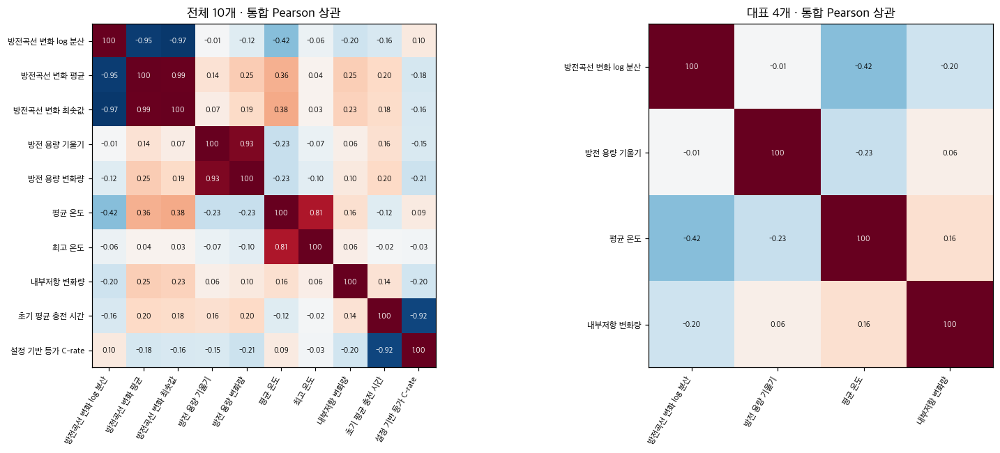

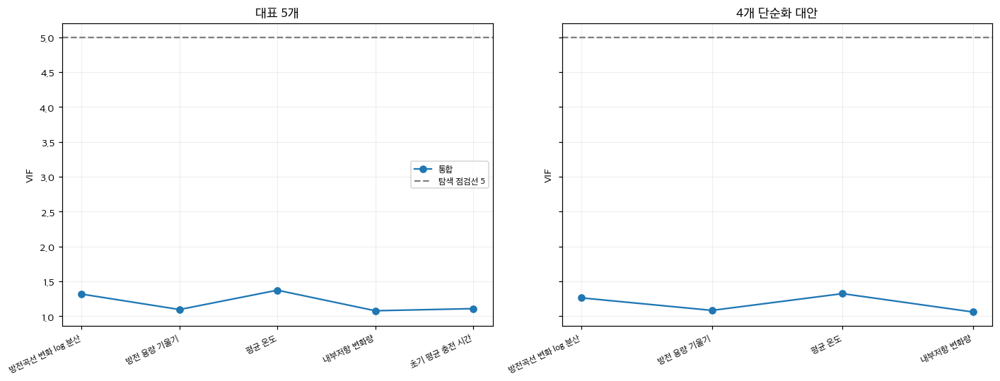

In [ ]:
fr_sets={'전체 10개':list(range(10)),'대표 5개':[0,3,5,7,8],'4개 단순화 대안':[0,3,5,7]}
def fr_vif(X):
    X=X[np.isfinite(X).all(axis=1)]
    if len(X)<=X.shape[1]+1:raise ValueError('VIF 계산 표본 부족')
    sd=X.std(axis=0)
    if np.any(sd==0):raise ValueError('상수 피처를 먼저 확인하세요')
    Z=(X-X.mean(axis=0))/sd;out=[]
    for j in range(Z.shape[1]):
        B=np.column_stack([np.ones(len(Z)),np.delete(Z,j,axis=1)])
        beta=np.linalg.lstsq(B,Z[:,j],rcond=None)[0]
        residual=Z[:,j]-np.sum(B*beta,axis=1)
        sse=np.sum(residual**2);sst=np.sum(Z[:,j]**2)
        out.append(float(sst/sse) if sse>1e-12*sst else float('inf'))
    return np.array(out),len(X)
fr_vif_records=[]
for scope in fr_scopes:
    X=fr_X if scope=='통합' else fr_X[fr_batch==scope]
    print('\n',scope)
    for stage,idx in fr_sets.items():
        vifs,count=fr_vif(X[:,idx]);print(stage,'n=',count,dict(zip([fr_labels[j] for j in idx],np.round(vifs,2))))
        for j,v in zip(idx,vifs):fr_vif_records.append(dict(scope=scope,stage=stage,feature=fr_keys[j],vif=float(v),n=count))
fig,axes=plt.subplots(1,2,figsize=(15,6))
for ax,(stage,idx) in zip(axes,[('전체 10개',fr_sets['전체 10개']),('대표 4개',fr_sets['4개 단순화 대안'])]):
    matrix=np.array([[fr_corr(fr_X[:,i],fr_X[:,j]) for j in idx] for i in idx])
    im=ax.imshow(matrix,vmin=-1,vmax=1,cmap='RdBu_r')
    ax.set_xticks(range(len(idx)),[fr_labels[i] for i in idx],rotation=60,ha='right',fontsize=8)
    ax.set_yticks(range(len(idx)),[fr_labels[i] for i in idx],fontsize=8);ax.set_title(stage+' · 통합 Pearson 상관')
    for a in range(len(idx)):
        for b in range(len(idx)):
            ax.text(b,a,f'{matrix[a,b]:.2f}',ha='center',va='center',fontsize=7,color='white' if abs(matrix[a,b])>.6 else 'black')
fig.tight_layout();fig.savefig(eda_out/'scratch_feature_collinearity.png',dpi=140,bbox_inches='tight');plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,5),sharey=True)
for ax,stage in zip(axes,['대표 5개','4개 단순화 대안']):
    idx=fr_sets[stage]
    for k,scope in enumerate(fr_scopes):
        values=[r['vif'] for r in fr_vif_records if r['scope']==scope and r['stage']==stage]
        ax.plot(range(len(idx)),values,marker='o',label=scope)
    ax.axhline(5,color='gray',ls='--',label='탐색 점검선 5')
    ax.set_xticks(range(len(idx)),[fr_labels[j] for j in idx],rotation=25,ha='right',fontsize=8)
    ax.set(title=stage,ylabel='VIF');ax.grid(alpha=.2)
axes[0].legend(fontsize=8);fig.tight_layout();fig.savefig(eda_out/'scratch_feature_vif.png',dpi=140,bbox_inches='tight');plt.show()
# 계산 결과와 표본 식별자를 저장하여 수치와 처리 기준 추적
with (eda_out/'scratch_feature_review.json').open('w') as f:
    json.dump(dict(keys=fr_keys,rows=fr_rows,audit=fr_audit,vif=fr_vif_records,correlations=fr_corrs.tolist()),f,ensure_ascii=False,indent=2)

#### 그래프 결과 해석

ΔQ 파생 통계, 용량 기울기·변화량, 평균·최고 온도, 충전 시간·등가 C-rate는 서로 겹치는 정보를 가진다. 특히 ΔQ 평균·최솟값은 거의 같은 순서로 움직여 두 피처의 높은 수명 상관을 독립적인 증거로 볼 수 없다. 히트맵은 변수 중복을 확인한 결과이며, 어떤 변수가 수명의 원인인지 판별한 그림은 아니다.

중복되는 변수들을 함께 넣은 10개 조합에서는 VIF가 높지만 부분집합에서는 약 1 수준으로 낮아진다. 이는 선택한 조합에서 선형 공선성이 줄었다는 정량적인 결과다. 다만 중복 감소와 예측 성능 향상은 별개의 문제이며, VIF만으로 피처의 유용성이나 최종 조합이 검증된 것은 아니다.


#### 병렬 비교 · 2그룹에서도 공선성 결과는 같은가?

**같은 119셀·같은 입력 피처를 사용하므로 위의 Pearson 히트맵과 VIF 값은 그대로다.** 그룹 라벨만 바꾸어도 입력 X 사이의 중복은 줄어들지 않는다. 전체 10개 피처의 높은 VIF와 대표 5개/4개 대안의 VIF를 두 분석에서 공통으로 참조한다. 라벨을 X에 포함하지 않는다. 2그룹과의 점이연 상관은 위에 별도로 계산했으며, 이는 수명과의 상관이나 모델 Feature importance가 아니다.


#### ③ 통합 결과에서 후보 선정으로 연결

- **ΔQ log 분산:** 통합 수명과의 Spearman 상관은 약 −0.888이다. 첫 핵심 후보로 둔다. ΔQ 평균·최솟값과 함께 넣으면 중복이 커져 대표 하나를 우선 검토한다.
- **전체 10개:** 통합 VIF가 최대 약 85.9로 크다. 같은 현상을 요약하는 통계값들을 중복 투입하지 않는다.
- **대표 5개:** ΔQ log 분산·용량 기울기·평균 온도·내부저항 변화·충전 시간의 통합 VIF는 약 1.08~1.37이다. **통합 분석에서는 이미 심한 선형 공선성이 줄었다.**
- **4개 단순화 대안:** 충전 시간을 빼면 통합 VIF는 약 1.06~1.32다. 5개도 낮으므로 VIF만을 이유로 충전 시간을 반드시 제거하지 않는다.
- **온도·기울기·충전 시간:** 수명과 관계가 보여도 각 셀에 적용된 조건과 다른 측정 신호가 섞여 있을 수 있다. 평균·최고 온도, 기울기·용량 변화량, 충전 시간·등가 C-rate는 각각 대표를 골라 검토한다.
- **저항 변화:** 초기 변화량과 수명의 Spearman은 약 −0.001이다. 다른 피처와의 선형 중복은 낮으며(VIF 약 1.08), 관측 말기에는 단수명 그룹의 저항 증가가 두드러졌다. 초기와 말기의 의미를 구분해 해석한다.

**권장 EDA 후보:** ΔQ log 분산을 핵심으로 두고, 대표 5개 조합을 중복이 적은 탐색 후보로 유지한다. 추가 정보가 약한 변수는 이후 별도로 평가한다.
통합 데이터에서 보이는 연관성을 원인으로 확정하지 않는다. 모델 학습을 하지 않았으므로 이번 수치는 Feature Importance나 검증 성능이 아니다.

분석 근거: 위에서 계산한 통합 상관계수와 VIF, 초기·중기·말기 추이.


#### 2그룹 추가 해석 — 위의 3그룹 해석과 함께 읽기

점이연 상관은 장수명=1과의 연관성이다. 양수이면 해당 피처가 클수록 장수명 쪽, 음수이면 단수명 쪽 경향이다.

|피처|2그룹 라벨과 점이연 상관|
|---|---:|
|방전곡선 변화 log 분산|-0.720|
|방전곡선 변화 평균|0.750|
|방전곡선 변화 최솟값|0.763|
|방전 용량 기울기|-0.215|
|방전 용량 변화량|-0.037|
|평균 온도|0.291|
|최고 온도|0.002|
|내부저항 변화량|0.230|
|초기 평균 충전 시간|0.216|
|설정 기반 등가 C-rate|-0.257|

상관 크기만으로 피처를 확정하지 않는다. 기존 ΔQ 통계끼리의 중복, 온도끼리의 중복, 충전 시간과 등가 C-rate의 중복을 그대로 고려한다. 2그룹 라벨은 정답이며 입력 피처가 아니다.

### 5-6. 시간 구간별 분석 — 초기·중기·말기

통합 분포와 피처 검토를 마친 뒤 시간 구간별 변화를 살펴본다.

#### ① 각 셀의 관측 구간을 3등분

수백 회에 기록이 끝나는 셀과 1,000회 넘게 기록된 셀을 같은 절대 사이클 구간으로 나누면 짧은 셀은 중·말기 비교에서 빠진다.
따라서 각 셀의 2회차를 0%, 마지막 기록을 100%로 두고 같은 상대적 위치를 비교한다.

`관측 진행률(%) = (사이클 번호 − 2) / (마지막 기록 사이클 − 2) × 100`

|단계|관측 진행률|설명용 예시: 마지막 기록이 902회인 셀|
|---|---|---|
|초기|0% 이상, 33⅓% 미만|2~301회|
|중기|33⅓% 이상, 66⅔% 미만|302~601회|
|말기|66⅔% 이상, 100% 이하|602~902회|

**관측 구간을 나눈 탐색용 기준**이며 실제 화학적 열화 단계나 knee를 검증한 기준은 아니다. 말기는 관측 말기를 뜻한다.
아래 x축은 사이클 번호가 아닌 진행률이다. 곡선 비교를 위해 셀마다 1% 구간 안의 평균을 먼저 계산하고, 셀별 값의 중앙값·사분위 범위를 표시한다.
각 셀은 한 표본으로 동일하게 반영된다. 1% 구간 평균이므로 순간 스파이크는 완화될 수 있으며, 원본 값은 변경하지 않는다.
단계별 세 그림은 같은 지표의 y축 범위를 맞춰 비교한다. 전체 기록을 알아야 가능한 사후 EDA이므로 초기 예측 피처로 쓰지 않는다.

단계별 비교 완료: 관측 초기 0~33⅓%, 중기 33⅓~66⅔%, 말기 66⅔~100%
각 단계는 탐색용 구간이며, knee 또는 화학적 열화 단계를 판정한 결과가 아닙니다.


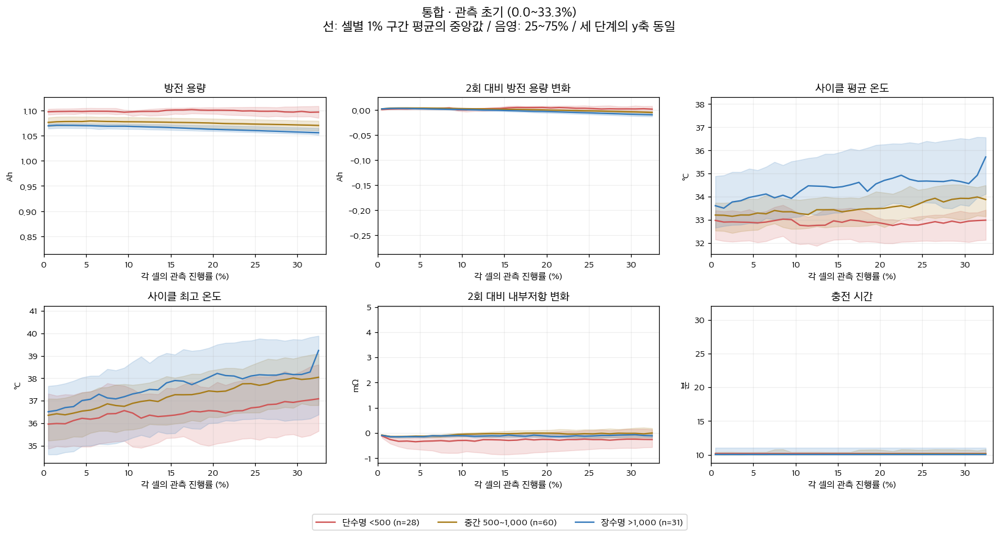

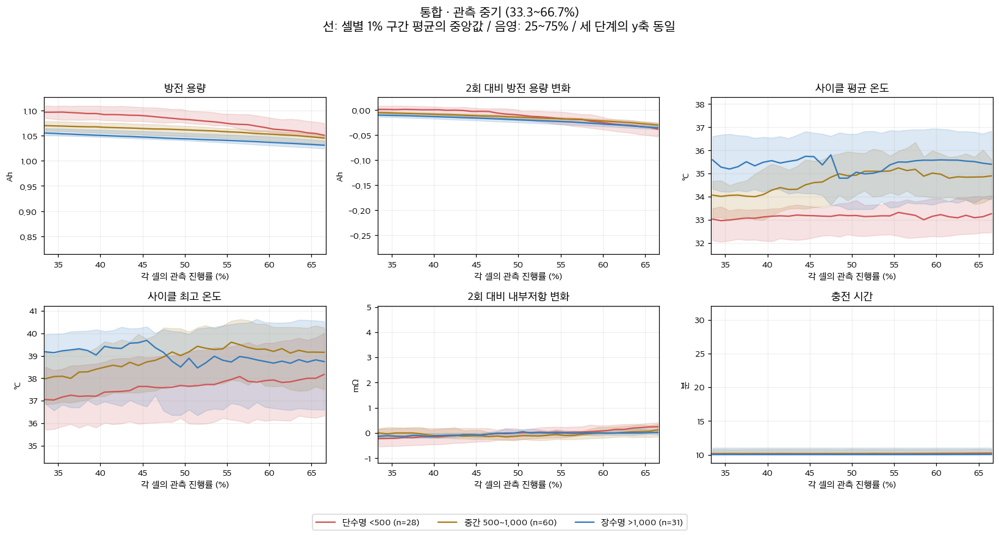

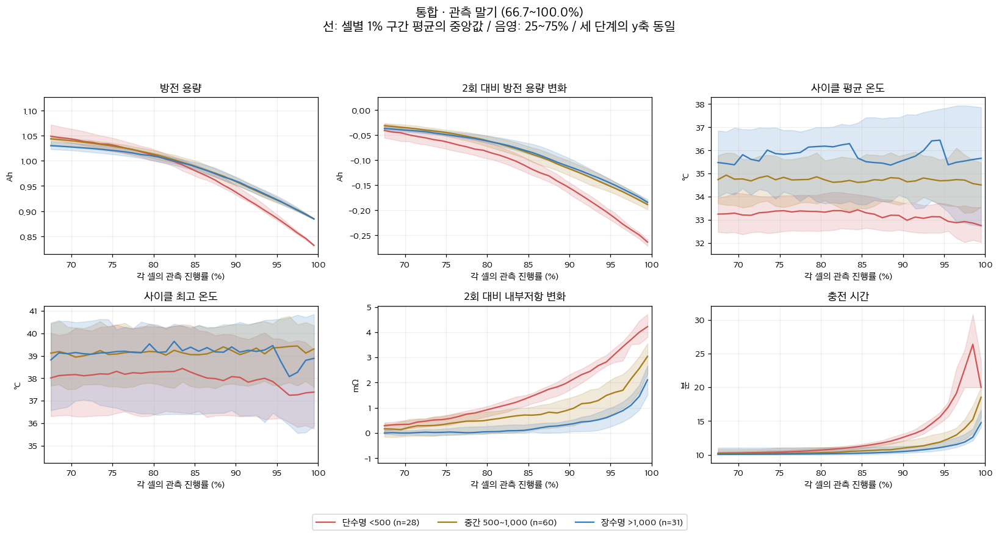

In [ ]:
phase_edges=np.linspace(0,100,101)
phase_x=(phase_edges[:-1]+phase_edges[1:])/2
phase_groups=[]
for g,group in enumerate(full_groups):
    matrix=np.full((len(group),6,100),np.nan)
    for row,(name,cid) in enumerate(group):
        s=eda_batches[name]['series'][cid];cy=s['cycle'];start=np.flatnonzero(cy==2)
        if len(start)!=1:raise ValueError('2회차 기준 확인 필요')
        mask=np.isfinite(cy)&(cy>=2);last=np.max(cy[mask]);progress=(cy[mask]-2)/(last-2)*100
        bins=np.minimum(np.floor(progress).astype(int),99)
        vals=[s['QDischarge'],s['QDischarge']-s['QDischarge'][start[0]],s['Tavg'],s['Tmax'],
              (s['IR']-s['IR'][start[0]])*1000,s['chargetime']]
        for j,v in enumerate(vals):
            v=v[mask]
            for k in range(100):
                selected=v[(bins==k)&np.isfinite(v)]
                if len(selected):matrix[row,j,k]=np.mean(selected)
    phase_groups.append(matrix)
phase_stats=[]
for arr in phase_groups:
    stats=np.full((3,6,100),np.nan)
    for j in range(6):
        good=np.isfinite(arr[:,j,:]).any(axis=0)
        stats[:,j,good]=np.nanpercentile(arr[:,j,good],[25,50,75],axis=0)
    phase_stats.append(stats)
phase_ranges=[]
for j in range(6):
    bounds=np.concatenate([st[:,j,:].ravel() for st in phase_stats]);bounds=bounds[np.isfinite(bounds)]
    low,high=bounds.min(),bounds.max();pad=max((high-low)*.06,1e-6);phase_ranges.append((low-pad,high+pad))
for label,lo,hi in [('초기',0,100/3),('중기',100/3,200/3),('말기',200/3,100)]:
    fig,axes=plt.subplots(2,3,figsize=(15,8));m=(phase_x>=lo)&(phase_x<hi)
    for g,stats in enumerate(phase_stats):
        for j,ax in enumerate(axes.flat):
            low,med,high=stats[:,j,:]
            ax.plot(phase_x[m],med[m],color=eda_colors[g],label=f'{eda_group_names[g]} (n={len(full_groups[g])})')
            ax.fill_between(phase_x[m],low[m],high[m],color=eda_colors[g],alpha=.17)
    for j,ax in enumerate(axes.flat):
        ax.set(title=full_titles[j],xlabel='각 셀의 관측 진행률 (%)',ylabel=eda_units[j],xlim=(lo,hi),ylim=phase_ranges[j]);ax.grid(alpha=.2)
    handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=3)
    fig.suptitle(f'통합 · 관측 {label} ({lo:.1f}~{hi:.1f}%)\n선: 셀별 1% 구간 평균의 중앙값 / 음영: 25~75% / 세 단계의 y축 동일',fontsize=14)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(eda_out/f'scratch_pooled_phase_{label}.png',dpi=140,bbox_inches='tight');plt.show()
print('단계별 비교 완료: 관측 초기 0~33⅓%, 중기 33⅓~66⅔%, 말기 66⅔~100%')
print('각 단계는 탐색용 구간이며, knee 또는 화학적 열화 단계를 판정한 결과가 아닙니다.')

#### 그래프 결과 해석

관측 초기에는 단수명 그룹의 절대 용량이 오히려 높고 충전 시간은 세 그룹 모두 약 10분으로 비슷하다. 따라서 초기 용량이 크다는 사실만으로 긴 수명을 설명할 수 없다. 온도에는 그룹 간 수준 차이가 있지만 단수명 그룹이 더 높은 방향은 아니므로, 이 결과를 단수명 셀의 고온 열화 근거로 사용하지 않는다.

관측 중기에는 모든 그룹의 용량이 감소하며, 단수명 그룹은 용량 감소가 커지는 동시에 저항 변화가 양수로 전환하는 모습을 보인다. 충전 시간의 큰 증가는 아직 두드러지지 않아 모든 지표가 같은 시점에 동일한 정도로 변하는 것은 아니다. 이 구간은 각 셀 기록의 중간 부분이므로 그룹 간 실제 누적 사이클 수는 다르다.

관측 말기에는 단수명 그룹에서 용량 감소와 내부저항 증가가 특히 크게 나타나며 충전 시간도 증가한다. 마지막 1% 구간의 저항 변화 중앙값은 단·중·장수명 순으로 4.217/3.037/2.108 mΩ여서, 저항은 말기의 열화 상태 차이를 설명하는 지표로 의미가 있다. 이 동반 변화는 열화가 심해진 상태와 부합하지만, 측정값만으로 활물질 균열이나 특정 부반응을 원인으로 확정할 수는 없다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 관측 초기·중기·말기

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


단계별 비교 완료: 관측 초기 0~33⅓%, 중기 33⅓~66⅔%, 말기 66⅔~100%
각 단계는 탐색용 구간이며, knee 또는 화학적 열화 단계를 판정한 결과가 아닙니다.


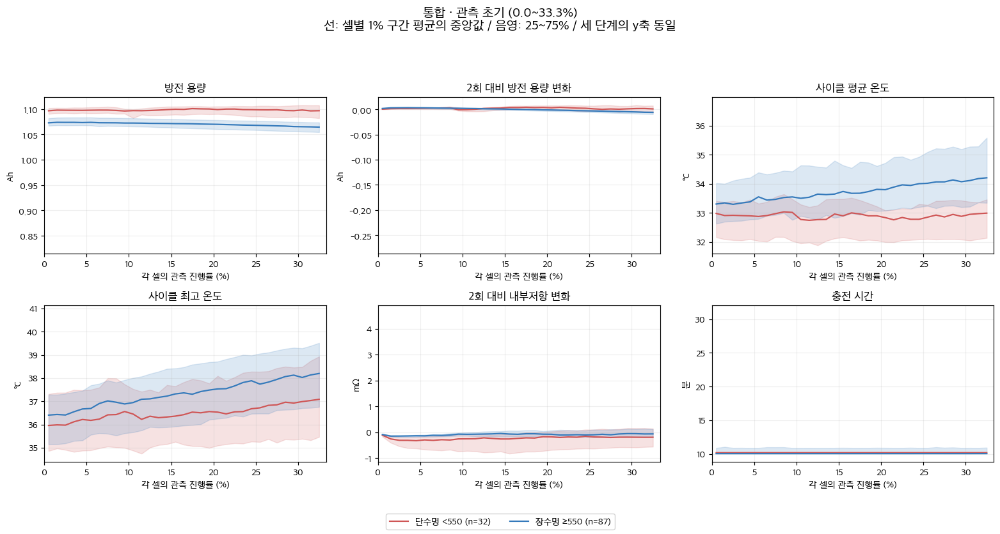

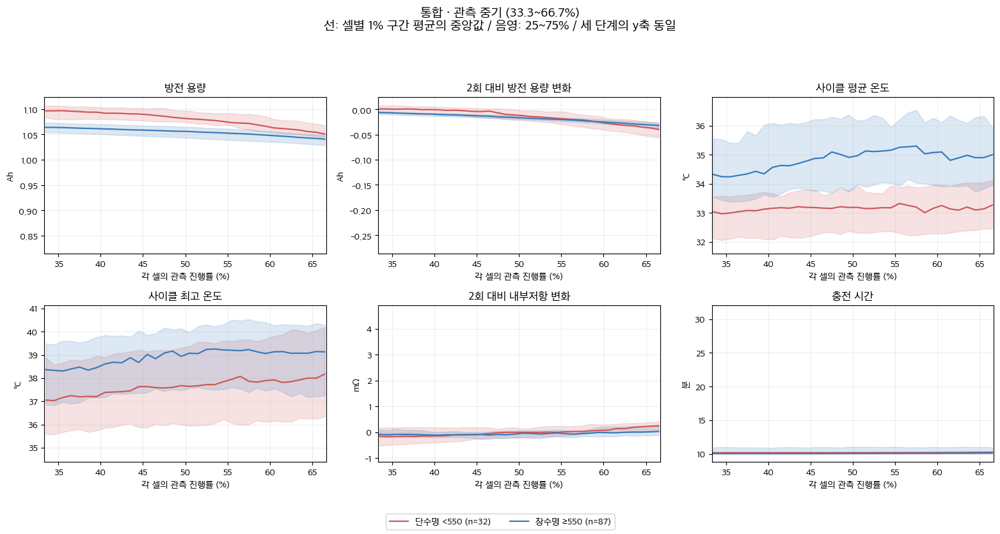

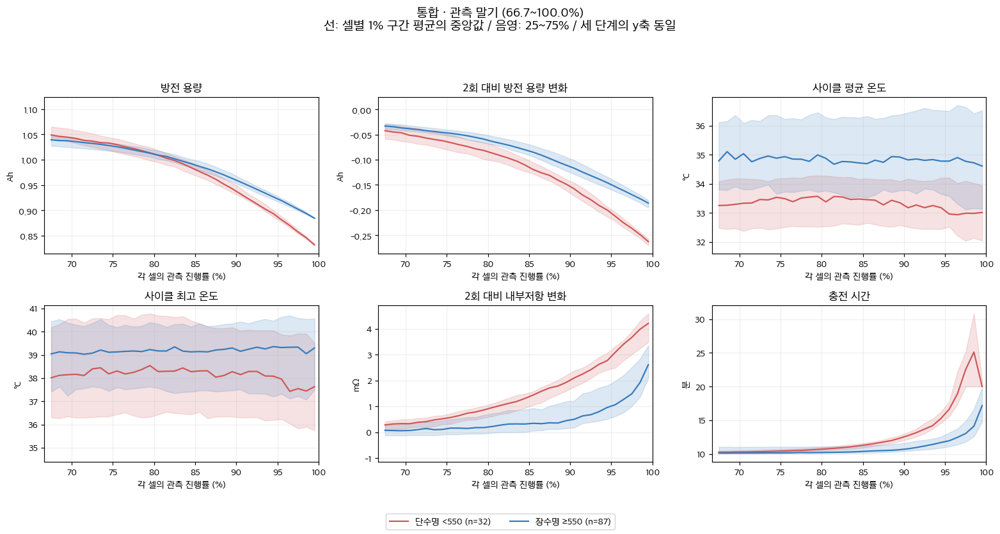

In [ ]:
b2_phase_edges=np.linspace(0,100,101)
b2_phase_x=(b2_phase_edges[:-1]+b2_phase_edges[1:])/2
b2_phase_groups=[]
for g,group in enumerate(b2_full_groups):
    matrix=np.full((len(group),6,100),np.nan)
    for row,(name,cid) in enumerate(group):
        s=b2_eda_batches[name]['series'][cid];cy=s['cycle'];start=np.flatnonzero(cy==2)
        if len(start)!=1:raise ValueError('2회차 기준 확인 필요')
        mask=np.isfinite(cy)&(cy>=2);last=np.max(cy[mask]);progress=(cy[mask]-2)/(last-2)*100
        bins=np.minimum(np.floor(progress).astype(int),99)
        vals=[s['QDischarge'],s['QDischarge']-s['QDischarge'][start[0]],s['Tavg'],s['Tmax'],
              (s['IR']-s['IR'][start[0]])*1000,s['chargetime']]
        for j,v in enumerate(vals):
            v=v[mask]
            for k in range(100):
                selected=v[(bins==k)&np.isfinite(v)]
                if len(selected):matrix[row,j,k]=np.mean(selected)
    b2_phase_groups.append(matrix)
b2_phase_stats=[]
for arr in b2_phase_groups:
    stats=np.full((3,6,100),np.nan)
    for j in range(6):
        good=np.isfinite(arr[:,j,:]).any(axis=0)
        stats[:,j,good]=np.nanpercentile(arr[:,j,good],[25,50,75],axis=0)
    b2_phase_stats.append(stats)
b2_phase_ranges=[]
for j in range(6):
    bounds=np.concatenate([st[:,j,:].ravel() for st in b2_phase_stats]);bounds=bounds[np.isfinite(bounds)]
    low,high=bounds.min(),bounds.max();pad=max((high-low)*.06,1e-6);b2_phase_ranges.append((low-pad,high+pad))
for label,lo,hi in [('초기',0,100/3),('중기',100/3,200/3),('말기',200/3,100)]:
    fig,axes=plt.subplots(2,3,figsize=(15,8));m=(b2_phase_x>=lo)&(b2_phase_x<hi)
    for g,stats in enumerate(b2_phase_stats):
        for j,ax in enumerate(axes.flat):
            low,med,high=stats[:,j,:]
            ax.plot(b2_phase_x[m],med[m],color=b2_eda_colors[g],label=f'{b2_eda_group_names[g]} (n={len(b2_full_groups[g])})')
            ax.fill_between(b2_phase_x[m],low[m],high[m],color=b2_eda_colors[g],alpha=.17)
    for j,ax in enumerate(axes.flat):
        ax.set(title=b2_full_titles[j],xlabel='각 셀의 관측 진행률 (%)',ylabel=b2_eda_units[j],xlim=(lo,hi),ylim=b2_phase_ranges[j]);ax.grid(alpha=.2)
    handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=2)
    fig.suptitle(f'통합 · 관측 {label} ({lo:.1f}~{hi:.1f}%)\n선: 셀별 1% 구간 평균의 중앙값 / 음영: 25~75% / 세 단계의 y축 동일',fontsize=14)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(b2_eda_out/f'scratch_binary_pooled_phase_{label}.png',dpi=140,bbox_inches='tight');plt.show()
print('단계별 비교 완료: 관측 초기 0~33⅓%, 중기 33⅓~66⅔%, 말기 66⅔~100%')
print('각 단계는 탐색용 구간이며, knee 또는 화학적 열화 단계를 판정한 결과가 아닙니다.')

#### 그래프 결과 해석

관측 초기에는 단수명 그룹의 절대 용량이 오히려 높고 충전 시간은 세 그룹 모두 약 10분으로 비슷하다. 따라서 초기 용량이 크다는 사실만으로 긴 수명을 설명할 수 없다. 온도에는 그룹 간 수준 차이가 있지만 단수명 그룹이 더 높은 방향은 아니므로, 이 결과를 단수명 셀의 고온 열화 근거로 사용하지 않는다.

관측 중기에는 모든 그룹의 용량이 감소하며, 단수명 그룹은 용량 감소가 커지는 동시에 저항 변화가 양수로 전환하는 모습을 보인다. 충전 시간의 큰 증가는 아직 두드러지지 않아 모든 지표가 같은 시점에 동일한 정도로 변하는 것은 아니다. 이 구간은 각 셀 기록의 중간 부분이므로 그룹 간 실제 누적 사이클 수는 다르다.

관측 말기에는 단수명 그룹에서 용량 감소와 내부저항 증가가 특히 크게 나타나며 충전 시간도 증가한다. 마지막 1% 구간의 저항 변화 중앙값은 단·중·장수명 순으로 4.217/3.037/2.108 mΩ여서, 저항은 말기의 열화 상태 차이를 설명하는 지표로 의미가 있다. 이 동반 변화는 열화가 심해진 상태와 부합하지만, 측정값만으로 활물질 균열이나 특정 부반응을 원인으로 확정할 수는 없다.


#### ② 초기 절대 사이클 확대 — 2~100회, 그 안의 2~5회

앞에서는 전체 관측 기간을 상대적 진행률로 비교했다. 여기서는 모든 셀의 **동일한 실제 사이클 번호**를 확대한다.
먼저 2~100회를 보고 그 안의 2~5회를 더 자세히 본다. 이 그림의 초기 100회는 위의 관측 초기 1/3과 다른 기준이다.
이어지는 박스플롯도 같은 순서로 셀별 초기 지표를 비교한다.

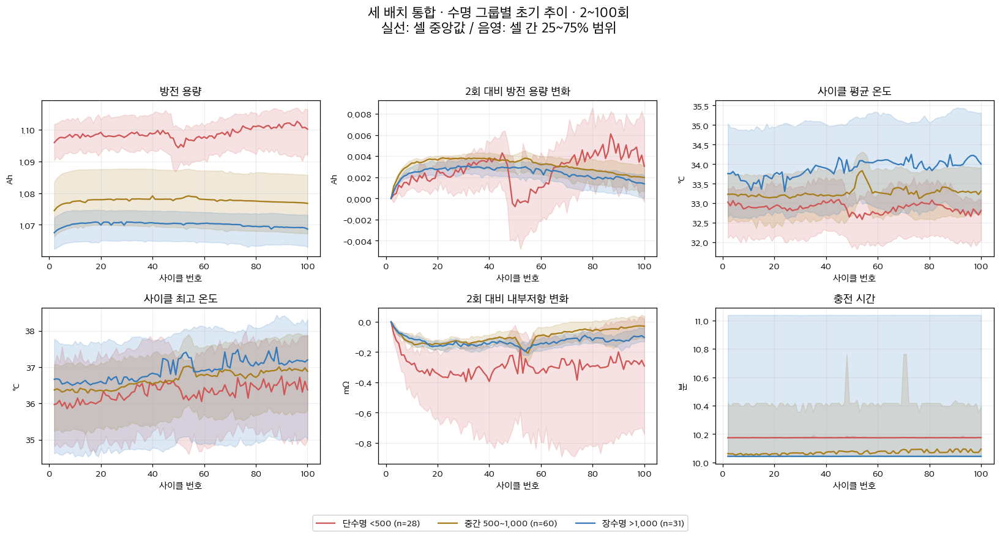

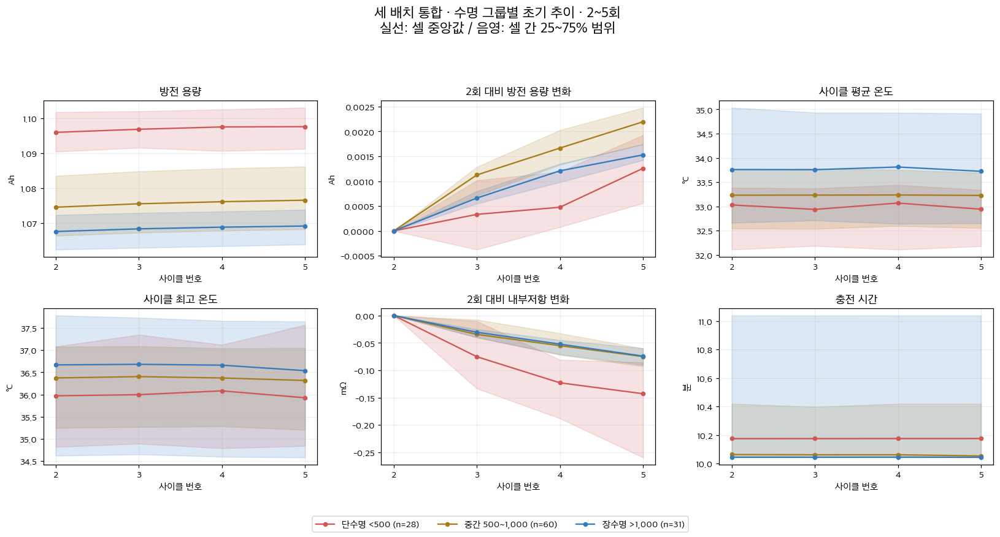

In [ ]:
# 전체 셀의 사이클별 중앙값 + 사분위 구간 (누락은 연결 보간하지 않음)
pooled_trace_titles=['방전 용량','2회 대비 방전 용량 변화','사이클 평균 온도','사이클 최고 온도','2회 대비 내부저항 변화','충전 시간']
for end in [100,5]:
    axis_cycles=np.arange(2,end+1)
    fig,axes=plt.subplots(2,3,figsize=(15,8))
    for g,group in enumerate(pooled_groups):
        matrices=[]
        for name,cid in group:
            s=eda_batches[name]['series'][cid]
            trace=np.full((6,len(axis_cycles)),np.nan)
            start=np.flatnonzero(s['cycle']==2)
            if len(start)!=1:continue
            q0=s['QDischarge'][start[0]];ir0=s['IR'][start[0]]
            for j,k in enumerate(axis_cycles):
                pos=np.flatnonzero(s['cycle']==k)
                if len(pos)!=1:continue
                i=pos[0]
                trace[:,j]=[s['QDischarge'][i],s['QDischarge'][i]-q0,s['Tavg'][i],s['Tmax'][i],
                            (s['IR'][i]-ir0)*1000,s['chargetime'][i]]
            trace[~np.isfinite(trace)]=np.nan
            matrices.append(trace)
        arr=np.array(matrices)
        for j,ax in enumerate(axes.flat):
            low,med,high=np.nanpercentile(arr[:,j,:],[25,50,75],axis=0)
            ax.plot(axis_cycles,med,color=eda_colors[g],label=f'{eda_group_names[g]} (n={len(group)})',marker='o' if end==5 else None,markersize=4)
            ax.fill_between(axis_cycles,low,high,color=eda_colors[g],alpha=.17)
            available=np.isfinite(arr[:,j,:]).sum(axis=0)
            if available.min()!=len(group):print(end,eda_group_names[g],pooled_trace_titles[j],'사이클별 유효 n',available.min(),available.max())
    for j,ax in enumerate(axes.flat):
        ax.set(title=pooled_trace_titles[j],xlabel='사이클 번호',ylabel=eda_units[j]);ax.grid(alpha=.2)
        if end==5:ax.set_xticks([2,3,4,5])
    handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=3)
    fig.suptitle(f'세 배치 통합 · 수명 그룹별 초기 추이 · 2~{end}회\n실선: 셀 중앙값 / 음영: 셀 간 25~75% 범위',fontsize=15)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(eda_out/f'scratch_pooled_traces_{end}.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

100회까지의 확대에서는 작은 용량 증가나 굴곡, 초기 저항 감소를 볼 수 있다. 전체 수명에서 나타나는 큰 용량 저하와 달리 초기에는 변화 규모가 작으므로, 곡선이 완만하다고 이후 수명 차이가 없다고 볼 수는 없다. 초기의 작은 신호와 이후 수명의 관계는 ΔQ(V)와 셀별 피처 분석에서 별도로 확인된다.

2~5회 그래프는 초기 측정 수준과 아주 짧은 구간의 변화를 보여준다. 네 점의 선이 벌어져 보이는 정도에는 확대된 y축도 영향을 주므로, 선 간격만으로 수명 구분 능력이 크다고 판단할 수 없다. 전체 열화 곡선과 연결해 읽되, 이 구간에서 장기 열화 속도를 관찰했다고 표현하지 않는다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 초기 100회 및 5회 확대

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


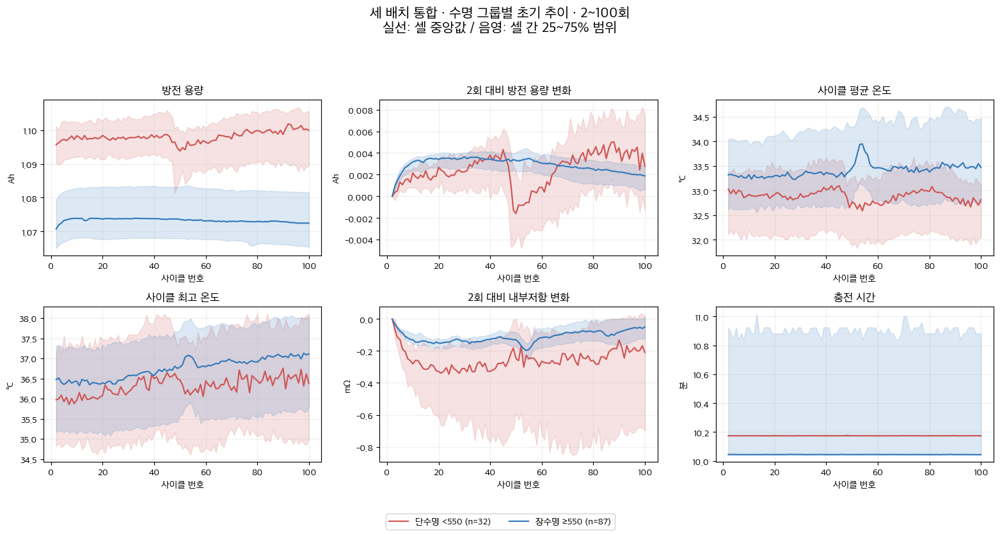

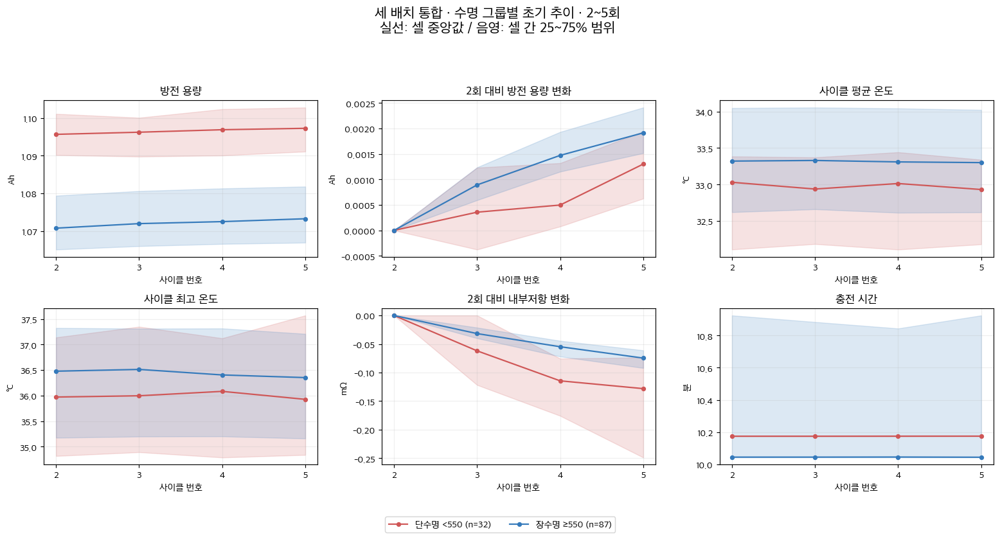

In [ ]:
# 전체 셀의 사이클별 중앙값 + 사분위 구간 (누락은 연결 보간하지 않음)
b2_pooled_trace_titles=['방전 용량','2회 대비 방전 용량 변화','사이클 평균 온도','사이클 최고 온도','2회 대비 내부저항 변화','충전 시간']
for end in [100,5]:
    axis_cycles=np.arange(2,end+1)
    fig,axes=plt.subplots(2,3,figsize=(15,8))
    for g,group in enumerate(b2_pooled_groups):
        matrices=[]
        for name,cid in group:
            s=b2_eda_batches[name]['series'][cid]
            trace=np.full((6,len(axis_cycles)),np.nan)
            start=np.flatnonzero(s['cycle']==2)
            if len(start)!=1:continue
            q0=s['QDischarge'][start[0]];ir0=s['IR'][start[0]]
            for j,k in enumerate(axis_cycles):
                pos=np.flatnonzero(s['cycle']==k)
                if len(pos)!=1:continue
                i=pos[0]
                trace[:,j]=[s['QDischarge'][i],s['QDischarge'][i]-q0,s['Tavg'][i],s['Tmax'][i],
                            (s['IR'][i]-ir0)*1000,s['chargetime'][i]]
            trace[~np.isfinite(trace)]=np.nan
            matrices.append(trace)
        arr=np.array(matrices)
        for j,ax in enumerate(axes.flat):
            low,med,high=np.nanpercentile(arr[:,j,:],[25,50,75],axis=0)
            ax.plot(axis_cycles,med,color=b2_eda_colors[g],label=f'{b2_eda_group_names[g]} (n={len(group)})',marker='o' if end==5 else None,markersize=4)
            ax.fill_between(axis_cycles,low,high,color=b2_eda_colors[g],alpha=.17)
            available=np.isfinite(arr[:,j,:]).sum(axis=0)
            if available.min()!=len(group):print(end,b2_eda_group_names[g],b2_pooled_trace_titles[j],'사이클별 유효 n',available.min(),available.max())
    for j,ax in enumerate(axes.flat):
        ax.set(title=b2_pooled_trace_titles[j],xlabel='사이클 번호',ylabel=b2_eda_units[j]);ax.grid(alpha=.2)
        if end==5:ax.set_xticks([2,3,4,5])
    handles,labels=axes[0,0].get_legend_handles_labels();fig.legend(handles,labels,loc='lower center',ncol=2)
    fig.suptitle(f'세 배치 통합 · 수명 그룹별 초기 추이 · 2~{end}회\n실선: 셀 중앙값 / 음영: 셀 간 25~75% 범위',fontsize=15)
    fig.tight_layout(rect=(0,.06,1,.92));fig.savefig(b2_eda_out/f'scratch_binary_pooled_traces_{end}.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

100회까지의 확대에서는 작은 용량 증가나 굴곡, 초기 저항 감소를 볼 수 있다. 전체 수명에서 나타나는 큰 용량 저하와 달리 초기에는 변화 규모가 작으므로, 곡선이 완만하다고 이후 수명 차이가 없다고 볼 수는 없다. 초기의 작은 신호와 이후 수명의 관계는 ΔQ(V)와 셀별 피처 분석에서 별도로 확인된다.

2~5회 그래프는 초기 측정 수준과 아주 짧은 구간의 변화를 보여준다. 네 점의 선이 벌어져 보이는 정도에는 확대된 y축도 영향을 주므로, 선 간격만으로 수명 구분 능력이 크다고 판단할 수 없다. 전체 열화 곡선과 연결해 읽되, 이 구간에서 장기 열화 속도를 관찰했다고 표현하지 않는다.


#### 관찰 해석 — 왜 유독 수명이 짧은가?

**관측 사실:** 통합 그룹 그래프에서 단수명 그룹은 관측 말기에 방전 용량 감소, 2회차 대비 내부저항 증가, 충전 시간 증가가 함께 두드러졌다. 온도는 이번 원인 설명에서 제외한다.

|확인한 변화|현재 해석|다음에 데이터에서 확인할 내용|
|---|---|---|
|말기 방전 용량 감소 확대|반복 사이클 후 저장·방출 가능한 용량이 줄어드는 패턴|실제 사이클당 감소 기울기와 knee 후보|
|말기 내부저항 증가 확대|저항의 변화가 용량 감소와 함께 관측됨|같은 셀 안에서 두 변화가 시작되는 순서와 시점|
|말기 충전 시간 증가|충전 소요 시간이 말기에 달라짐|전류·전압 기록의 구간 길이와 summary 집계 범위|
|동일 그룹 안의 편차|모든 셀이 같은 형태로 변하는 것은 아님|셀별 곡선, 충전 정책, 기록 종료 상태|

##### 데이터에 근거한 후속 확인

1. 그룹 중앙값에서 함께 보이는 변화가 개별 셀에서도 같은 시점에 나타나는지 확인한다.
2. 내부저항 증가와 충전 시간 증가의 선후 관계를 실제 사이클 축에서 비교한다.
3. 충전 시간 급변 구간의 전류·전압·시간 기록을 확인하여 실제 충전 구간이 길어진 것인지 점검한다.
4. 기록 말단의 급변은 종료 절차나 측정 이상 여부도 함께 확인한다.

##### 결과 해석

> 단수명 그룹은 관측 말기에 용량 감소와 저항·충전 시간 증가가 함께 크게 나타났다. 이 동반 변화는 수명 그룹별 열화 양상의 차이를 설명한다. 다만 그룹 그래프만으로 수명이 짧아진 원인이나 특정 화학 반응을 확정할 수는 없다. 개별 셀의 변화 시점과 충전 구간을 확인하여 설명을 구체화한다.

##### 해석 범위

- x축은 **각 셀의 관측 진행률(%)**이다. 실제 사이클당 열화 속도는 실제 사이클 축에서 별도로 계산한다.
- 초기·중기·말기는 관측 기간을 3등분한 탐색 구간이다.
- 단수명 그룹의 파일·정책 구성이 다를 수 있으므로 수명 그룹 차이를 하나의 변수 효과로 읽지 않는다.
- 선은 셀별 1% 구간 평균의 중앙값, 음영은 셀 간 25~75% 범위다.
- 말기의 큰 차이는 초기 예측력이 높다는 증거가 아니다. 피처는 초기 100회에서 계산 가능한 값으로 구성한다.


#### 2그룹 추가 해석 — 위의 3그룹 해석과 함께 읽기

관측 초기·중기·말기는 수명의 550회 경계와 별개로 **각 셀의 마지막 기록까지를 3등분**한 구간이다. 같은 진행률도 실제 사이클 수는 다르다.

|관측 말기 마지막 1% 구간 중앙값|단수명 <550|장수명 ≥550|
|---|---:|---:|
|방전 용량 (Ah)|0.8320|0.8846|
|2회 대비 방전 용량 변화 (Ah)|-0.2627|-0.1862|
|2회 대비 내부저항 변화 (mΩ)|4.2072|2.6112|
|충전 시간 (분)|20.0000|17.1730|

이 표는 관측 말기 차이를 요약한 것으로, 원인의 확정이나 초기 예측 성능이 아니다. 넓어진 장수명 그룹에 중간수명 셀이 포함되어 중앙값·음영이 달라진다. 원인 해석은 개별 셀의 변화 시점과 충전 구간을 확인한 뒤 구체화하며, 온도는 원인 설명에서 제외한다.

### 5-7. Question 2 — 방전 용량은 어떻게 감소하며, 언제 가속되는가?

**앞 결과에서 이어지는 질문**

전체·구간별 추이에서 후반 용량 감소가 두드러졌지만, 중앙값의 모양만으로 개별 셀의 열화 속도나 시작점을 정할 수 없다. 그래서 이 절은 **개별 곡선 확인 → 실제 사이클당 기울기 → knee 후보**로 질문을 좁힌다.

**통합 119셀**, 단수명·중간·장수명 구분을 그대로 사용한다. 아래 순서는 전체 곡선 → 실제 사이클당 변화 속도 → 셀별 knee 후보 → 결과 해석이다.
배치별 패널로 나누지 않는다. 같은 셀 번호의 충돌을 막기 위해 내부 식별자에는 출처와 셀 번호를 함께 사용한다.

먼저 5-2의 데이터 로딩 셀을 실행한다. 이 절은 이전 그래프 변수를 재사용하지 않고 필요한 표본과 계산을 직접 만든다.
원본 곡선은 유지하며, 기울기·knee 적합에만 비유한 QD, QD≤0, QD>1.2 Ah를 점검값으로 제외한다.
**1.2 Ah는 탐색용 상한**이다. 낮은 양의 용량을 EOL 아래라는 이유로 제거하지 않는다. 제외 지점·포함/제외 민감도를 출력한다.
기존 EOL 정의나 저장 수명은 수정하지 않는다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
q2_cells=[]
for name,b in eda_batches.items():
    for cid,r in b['cells'].items():
        if not r['valid'] or r['incomplete']:continue
        s=b['series'][cid];x=s['cycle'];y=s['QDischarge']
        m=np.isfinite(x)&(x>=2);order=np.argsort(x[m]);x=x[m][order];y=y[m][order]
        if len(np.unique(x))!=len(x):raise ValueError('사이클 번호 중복 확인 필요')
        valid=np.isfinite(y)&(y>0)&(y<=1.2)
        q2_cells.append(dict(uid=f'{name} / 셀 {cid}',life=r['life'],policy=r['policy'],
                             group=eda_group(r['life']),x=x,y=y,valid=valid))
assert len(q2_cells)==119
print('통합 분석 대상:',len(q2_cells),'셀')
for g in range(3):print(eda_group_names[g],sum(c['group']==g for c in q2_cells),'셀')
q2_flagged=[c for c in q2_cells if not c['valid'].all()]
print('용량 점검값이 있는 셀:',len(q2_flagged))
for c in q2_flagged:
    print(c['uid'],'점검 사이클:',c['x'][~c['valid']].tolist(),'용량:',c['y'][~c['valid']].tolist())

통합 분석 대상: 119 셀
단수명 <500 28 셀
중간 500~1,000 60 셀
장수명 >1,000 31 셀
용량 점검값이 있는 셀: 1
Batch 1 / 셀 18 점검 사이클: [40.0] 용량: [2.8840845]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json
b2_q2_cells=[]
for name,b in b2_eda_batches.items():
    for cid,r in b['cells'].items():
        if not r['valid'] or r['incomplete']:continue
        s=b['series'][cid];x=s['cycle'];y=s['QDischarge']
        m=np.isfinite(x)&(x>=2);order=np.argsort(x[m]);x=x[m][order];y=y[m][order]
        if len(np.unique(x))!=len(x):raise ValueError('사이클 번호 중복 확인 필요')
        valid=np.isfinite(y)&(y>0)&(y<=1.2)
        b2_q2_cells.append(dict(uid=f'{name} / 셀 {cid}',life=r['life'],policy=r['policy'],
                             group=b2_eda_group(r['life']),x=x,y=y,valid=valid))
assert len(b2_q2_cells)==119
print('통합 분석 대상:',len(b2_q2_cells),'셀')
for g in range(2):print(b2_eda_group_names[g],sum(c['group']==g for c in b2_q2_cells),'셀')
b2_q2_flagged=[c for c in b2_q2_cells if not c['valid'].all()]
print('용량 점검값이 있는 셀:',len(b2_q2_flagged))
for c in b2_q2_flagged:
    print(c['uid'],'점검 사이클:',c['x'][~c['valid']].tolist(),'용량:',c['y'][~c['valid']].tolist())

통합 분석 대상: 119 셀
단수명 <550 32 셀
장수명 ≥550 87 셀
용량 점검값이 있는 셀: 1
Batch 1 / 셀 18 점검 사이클: [40.0] 용량: [2.8840845]


#### ① 전체 사이클별 Qd 추이

왼쪽은 원본 방전 용량, 오른쪽은 **각 셀의 2회차 대비 용량 변화량**이다. 두 그림 모두 한 선이 실제 배터리 한 개이며 색만 수명 그룹을 구분한다.
열화 추이를 읽기 위해 y축을 용량 0.75~1.15 Ah, 변화량 −0.35~0.05 Ah로 확대한다. 범위 밖 값은 원본에 유지하며, 축 경계의 삼각형과 출력 목록으로 표시한다. 중앙값 곡선의 구성 변화와 실제 셀의 열화를 혼동하지 않도록 개별 곡선을 먼저 본다.

표시 범위 밖 Batch 1 / 셀 18 Qd 사이클 [40.0] 값 [2.8840845]
표시 범위 밖 Batch 1 / 셀 18 Qd-Qd(2) 사이클 [40.0] 값 [1.8179140000000003]
표시 범위 밖 Batch 3 / 셀 37 Qd-Qd(2) 사이클 [598.0] 값 [0.05322110000000002]


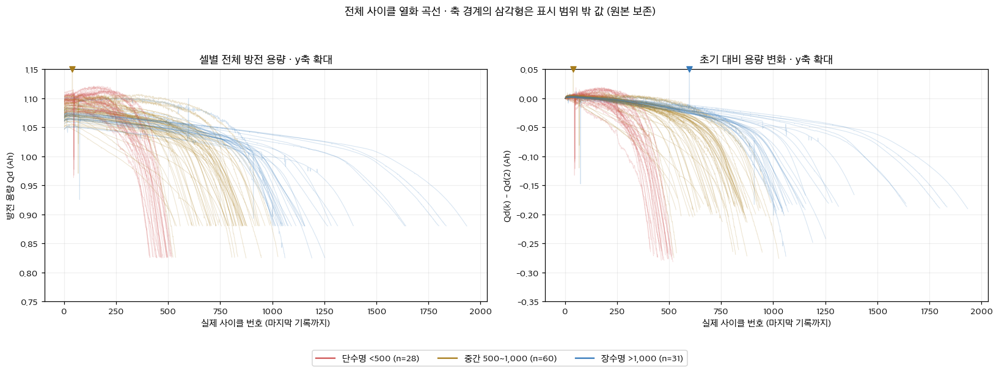

In [ ]:
from matplotlib.lines import Line2D
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
for c in q2_cells:
    color=eda_colors[c['group']];x,y=c['x'],c['y'];start=np.flatnonzero(x==2)
    axes[0].plot(x,y,color=color,alpha=.2,lw=.7)
    if len(start)==1 and np.isfinite(y[start[0]]):axes[1].plot(x,y-y[start[0]],color=color,alpha=.2,lw=.7)
for ax in axes:ax.set_xlabel('실제 사이클 번호 (마지막 기록까지)');ax.grid(alpha=.2)
axes[0].set(title='셀별 전체 방전 용량 · 원본 점검값 포함',ylabel='방전 용량 Qd (Ah)')
axes[1].set(title='초기 용량 차이를 뺀 변화량',ylabel='Qd(k) - Qd(2) (Ah)')
# 표시 범위만 확대: 원본 측정값과 적합용 데이터는 변경하지 않는다.
q2_display_limits=[(.75,1.15),(-.35,.05)]
for ax,(lo,hi) in zip(axes,q2_display_limits):
    ax.set_ylim(lo,hi)
    ax.yaxis.set_major_locator(plt.MultipleLocator(.05))
for c in q2_cells:
    x,y=c['x'],c['y'];start=np.flatnonzero(x==2)
    if len(start)!=1:continue
    for j,values in enumerate([y,y-y[start[0]]]):
        lo,hi=q2_display_limits[j]
        for outside,edge,marker in [(np.isfinite(values)&(values>hi),hi,'v'),(np.isfinite(values)&(values<lo),lo,'^')]:
            if outside.any():
                axes[j].scatter(x[outside],np.full(outside.sum(),edge),marker=marker,
                                color=eda_colors[c['group']],s=35,clip_on=False,zorder=5)
                print('표시 범위 밖',c['uid'],['Qd','Qd-Qd(2)'][j],
                      '사이클',x[outside].tolist(),'값',values[outside].tolist())
axes[0].set_title('셀별 전체 방전 용량 · y축 확대')
axes[1].set_title('초기 대비 용량 변화 · y축 확대')
fig.suptitle('전체 사이클 열화 곡선 · 축 경계의 삼각형은 표시 범위 밖 값 (원본 보존)',fontsize=12)
handles=[Line2D([],[],color=eda_colors[g],label=f'{eda_group_names[g]} (n={sum(c["group"]==g for c in q2_cells)})') for g in range(3)]
fig.legend(handles=handles,loc='lower center',ncol=3);fig.tight_layout(rect=(0,.08,1,.93))
fig.savefig(eda_out/'scratch_q2_individual_capacity.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

초기 용량을 뺀 뒤에도 단수명 셀의 감소가 더 이른 실제 사이클에서 나타나므로, 그룹 차이는 초기 용량 수준만의 차이로 설명되지 않는다. 동시에 같은 수명 그룹 안에서도 곡선이 다양해 그룹 중앙값 하나가 모든 셀을 대표하지는 않는다. 축 범위 밖의 값은 이상 여부를 점검할 대상이며, 짧은 수명의 셀 자체와 측정 이상값을 구분해야 한다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 전체 방전 용량 곡선

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


표시 범위 밖 Batch 1 / 셀 18 Qd 사이클 [40.0] 값 [2.8840845]
표시 범위 밖 Batch 1 / 셀 18 Qd-Qd(2) 사이클 [40.0] 값 [1.8179140000000003]
표시 범위 밖 Batch 3 / 셀 37 Qd-Qd(2) 사이클 [598.0] 값 [0.05322110000000002]


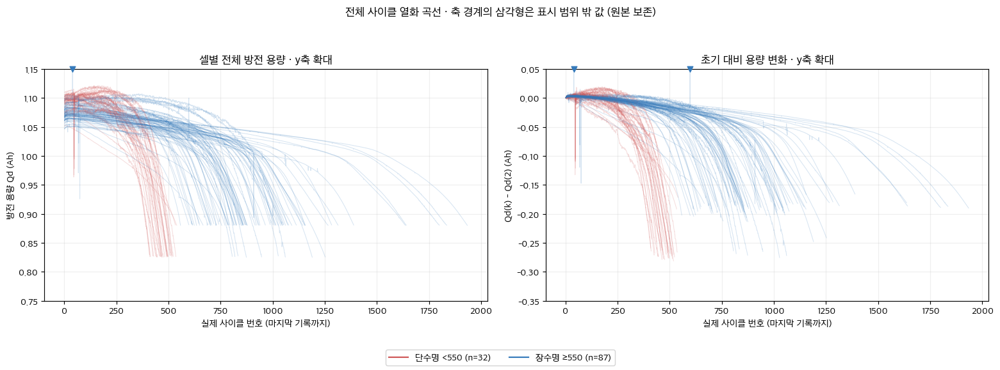

In [ ]:
from matplotlib.lines import Line2D
fig,axes=plt.subplots(1,2,figsize=(15,5.5))
for c in b2_q2_cells:
    color=b2_eda_colors[c['group']];x,y=c['x'],c['y'];start=np.flatnonzero(x==2)
    axes[0].plot(x,y,color=color,alpha=.2,lw=.7)
    if len(start)==1 and np.isfinite(y[start[0]]):axes[1].plot(x,y-y[start[0]],color=color,alpha=.2,lw=.7)
for ax in axes:ax.set_xlabel('실제 사이클 번호 (마지막 기록까지)');ax.grid(alpha=.2)
axes[0].set(title='셀별 전체 방전 용량 · 원본 점검값 포함',ylabel='방전 용량 Qd (Ah)')
axes[1].set(title='초기 용량 차이를 뺀 변화량',ylabel='Qd(k) - Qd(2) (Ah)')
# 표시 범위만 확대: 원본 측정값과 적합용 데이터는 변경하지 않는다.
b2_q2_display_limits=[(.75,1.15),(-.35,.05)]
for ax,(lo,hi) in zip(axes,b2_q2_display_limits):
    ax.set_ylim(lo,hi)
    ax.yaxis.set_major_locator(plt.MultipleLocator(.05))
for c in b2_q2_cells:
    x,y=c['x'],c['y'];start=np.flatnonzero(x==2)
    if len(start)!=1:continue
    for j,values in enumerate([y,y-y[start[0]]]):
        lo,hi=b2_q2_display_limits[j]
        for outside,edge,marker in [(np.isfinite(values)&(values>hi),hi,'v'),(np.isfinite(values)&(values<lo),lo,'^')]:
            if outside.any():
                axes[j].scatter(x[outside],np.full(outside.sum(),edge),marker=marker,
                                color=b2_eda_colors[c['group']],s=35,clip_on=False,zorder=5)
                print('표시 범위 밖',c['uid'],['Qd','Qd-Qd(2)'][j],
                      '사이클',x[outside].tolist(),'값',values[outside].tolist())
axes[0].set_title('셀별 전체 방전 용량 · y축 확대')
axes[1].set_title('초기 대비 용량 변화 · y축 확대')
fig.suptitle('전체 사이클 열화 곡선 · 축 경계의 삼각형은 표시 범위 밖 값 (원본 보존)',fontsize=12)
handles=[Line2D([],[],color=b2_eda_colors[g],label=f'{b2_eda_group_names[g]} (n={sum(c["group"]==g for c in b2_q2_cells)})') for g in range(2)]
fig.legend(handles=handles,loc='lower center',ncol=2);fig.tight_layout(rect=(0,.08,1,.93))
fig.savefig(b2_eda_out/'scratch_binary_q2_individual_capacity.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

초기 용량을 뺀 뒤에도 단수명 셀의 감소가 더 이른 실제 사이클에서 나타나므로, 그룹 차이는 초기 용량 수준만의 차이로 설명되지 않는다. 동시에 같은 수명 그룹 안에서도 곡선이 다양해 그룹 중앙값 하나가 모든 셀을 대표하지는 않는다. 축 범위 밖의 값은 이상 여부를 점검할 대상이며, 짧은 수명의 셀 자체와 측정 이상값을 구분해야 한다.


#### ② 일정한 속도인가, 후반에 가속되는가?

각 셀의 관측 구간을 3등분하고, 각 구간에서 **실제 사이클 번호에 대한 선형 기울기**를 구한다.
표시 단위는 `Ah / 100사이클`이다. 음수는 용량 감소, 양수는 증가이며 더 음수일수록 감소 속도가 크다.
초기·중기·말기는 탐색용 구간이고, 서로 다른 셀의 동일한 실제 사이클 범위를 뜻하지 않는다.
점검값을 제외한 적합 결과를 사용하고 원본 유한값으로 계산한 결과도 보관한다. 사분위 박스 밖의 점도 표시한다.

그룹별 기울기 중앙값: 초기 / 중기 / 말기 (Ah/100회)
단수명 <500 [ 0.00028 -0.02682 -0.14398] 중기·말기 모두 감소하며 말기가 더 가파른 셀: 28/28
중간 500~1,000 [-0.00358 -0.00911 -0.05993] 중기·말기 모두 감소하며 말기가 더 가파른 셀: 60/60
장수명 >1,000 [-0.00348 -0.00612 -0.04068] 중기·말기 모두 감소하며 말기가 더 가파른 셀: 31/31
점검값 포함/제외 기울기: Batch 1 / 셀 18 [-0.02429161717037469, -0.010728064263088137, -0.06055695340801208] → [-0.010598892705361216, -0.010728064263088137, -0.06055695340801208]


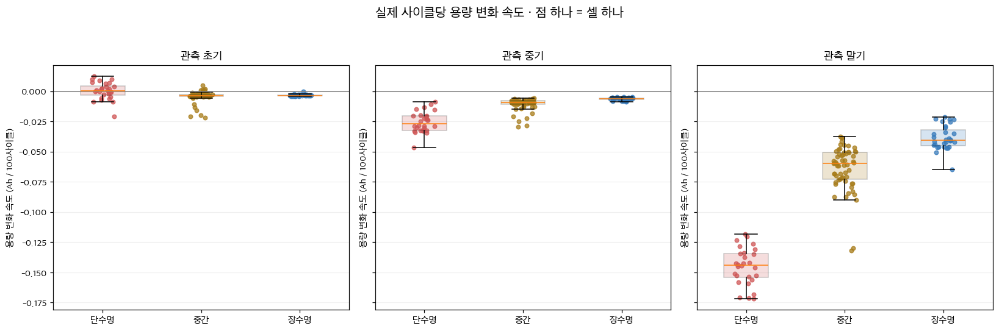

In [ ]:
def q2_slope(x,y):
    if len(x)<20 or np.ptp(x)==0:return np.nan
    return float(np.polyfit(x,y,1)[0]*100)
for c in q2_cells:
    x,y=c['x'],c['y'];progress=(x-2)/(x.max()-2)
    c['slopes']=[];c['raw_slopes']=[]
    for lo,hi in [(0,1/3),(1/3,2/3),(2/3,1.000001)]:
        m=(progress>=lo)&(progress<hi)
        c['slopes'].append(q2_slope(x[m&c['valid']],y[m&c['valid']]))
        c['raw_slopes'].append(q2_slope(x[m&np.isfinite(y)],y[m&np.isfinite(y)]))
fig,axes=plt.subplots(1,3,figsize=(15,5),sharey=True);rng=np.random.default_rng(42)
for j,ax in enumerate(axes):
    for g in range(3):
        v=np.array([c['slopes'][j] for c in q2_cells if c['group']==g]);v=v[np.isfinite(v)]
        box=ax.boxplot([v],positions=[g],widths=.45,patch_artist=True,showfliers=False)
        box['boxes'][0].set(facecolor=eda_colors[g],alpha=.2)
        ax.scatter(g+rng.uniform(-.12,.12,len(v)),v,color=eda_colors[g],s=18,alpha=.75)
    ax.set_xticks(range(3),['단수명','중간','장수명']);ax.axhline(0,color='gray',lw=1)
    ax.set(title=['관측 초기','관측 중기','관측 말기'][j],ylabel='용량 변화 속도 (Ah / 100사이클)');ax.grid(axis='y',alpha=.2)
fig.suptitle('실제 사이클당 용량 변화 속도 · 점 하나 = 셀 하나',fontsize=14)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(eda_out/'scratch_q2_degradation_rates.png',dpi=140,bbox_inches='tight');plt.show()
print('그룹별 기울기 중앙값: 초기 / 중기 / 말기 (Ah/100회)')
for g in range(3):
    records=[c for c in q2_cells if c['group']==g]
    slopes=np.array([c['slopes'] for c in records])
    both_negative=(slopes[:,1]<0)&(slopes[:,2]<0)
    accelerated=both_negative&(slopes[:,2]<slopes[:,1])
    print(eda_group_names[g],np.round(np.nanmedian(slopes,axis=0),5),
          f'중기·말기 모두 감소하며 말기가 더 가파른 셀: {accelerated.sum()}/{len(records)}')
for c in q2_flagged:print('점검값 포함/제외 기울기:',c['uid'],c['raw_slopes'],'→',c['slopes'])

#### 그래프 결과 해석

119셀 모두 중기보다 말기의 용량 감소 기울기가 더 가파르므로, 이 데이터에서는 일정한 속도의 열화보다 후반 가속 형태가 공통적으로 관측된다. 실제 100사이클당 변화량으로 비교했을 때도 단수명 그룹의 말기 감소가 더 크므로, 관측 진행률을 정규화한 그림의 시각적 차이만은 아니다. 다만 말기 기울기는 수명 후반을 관측한 결과이며 초기 예측 가능성을 직접 보여주지는 않는다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 실제 사이클당 열화 속도

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


그룹별 기울기 중앙값: 초기 / 중기 / 말기 (Ah/100회)
단수명 <550 [-0.00019 -0.0266  -0.14256] 중기·말기 모두 감소하며 말기가 더 가파른 셀: 32/32
장수명 ≥550 [-0.00353 -0.00806 -0.05071] 중기·말기 모두 감소하며 말기가 더 가파른 셀: 87/87
점검값 포함/제외 기울기: Batch 1 / 셀 18 [-0.02429161717037469, -0.010728064263088137, -0.06055695340801208] → [-0.010598892705361216, -0.010728064263088137, -0.06055695340801208]


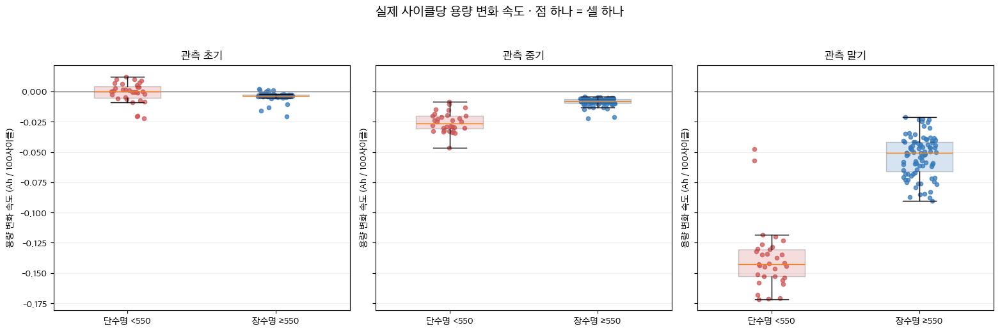

In [ ]:
def b2_q2_slope(x,y):
    if len(x)<20 or np.ptp(x)==0:return np.nan
    return float(np.polyfit(x,y,1)[0]*100)
for c in b2_q2_cells:
    x,y=c['x'],c['y'];progress=(x-2)/(x.max()-2)
    c['slopes']=[];c['raw_slopes']=[]
    for lo,hi in [(0,1/3),(1/3,2/3),(2/3,1.000001)]:
        m=(progress>=lo)&(progress<hi)
        c['slopes'].append(b2_q2_slope(x[m&c['valid']],y[m&c['valid']]))
        c['raw_slopes'].append(b2_q2_slope(x[m&np.isfinite(y)],y[m&np.isfinite(y)]))
fig,axes=plt.subplots(1,3,figsize=(15,5),sharey=True);rng=np.random.default_rng(42)
for j,ax in enumerate(axes):
    for g in range(2):
        v=np.array([c['slopes'][j] for c in b2_q2_cells if c['group']==g]);v=v[np.isfinite(v)]
        box=ax.boxplot([v],positions=[g],widths=.45,patch_artist=True,showfliers=False)
        box['boxes'][0].set(facecolor=b2_eda_colors[g],alpha=.2)
        ax.scatter(g+rng.uniform(-.12,.12,len(v)),v,color=b2_eda_colors[g],s=18,alpha=.75)
    ax.set_xticks(range(2),b2_eda_group_names);ax.axhline(0,color='gray',lw=1)
    ax.set(title=['관측 초기','관측 중기','관측 말기'][j],ylabel='용량 변화 속도 (Ah / 100사이클)');ax.grid(axis='y',alpha=.2)
fig.suptitle('실제 사이클당 용량 변화 속도 · 점 하나 = 셀 하나',fontsize=14)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(b2_eda_out/'scratch_binary_q2_degradation_rates.png',dpi=140,bbox_inches='tight');plt.show()
print('그룹별 기울기 중앙값: 초기 / 중기 / 말기 (Ah/100회)')
for g in range(2):
    records=[c for c in b2_q2_cells if c['group']==g]
    slopes=np.array([c['slopes'] for c in records])
    both_negative=(slopes[:,1]<0)&(slopes[:,2]<0)
    accelerated=both_negative&(slopes[:,2]<slopes[:,1])
    print(b2_eda_group_names[g],np.round(np.nanmedian(slopes,axis=0),5),
          f'중기·말기 모두 감소하며 말기가 더 가파른 셀: {accelerated.sum()}/{len(records)}')
for c in b2_q2_flagged:print('점검값 포함/제외 기울기:',c['uid'],c['raw_slopes'],'→',c['slopes'])

#### 그래프 결과 해석

119셀 모두 중기보다 말기의 용량 감소 기울기가 더 가파르므로, 이 데이터에서는 일정한 속도의 열화보다 후반 가속 형태가 공통적으로 관측된다. 실제 100사이클당 변화량으로 비교했을 때도 단수명 그룹의 말기 감소가 더 크므로, 관측 진행률을 정규화한 그림의 시각적 차이만은 아니다. 다만 말기 기울기는 수명 후반을 관측한 결과이며 초기 예측 가능성을 직접 보여주지는 않는다.


#### ③ 셀별 knee 후보 탐색

**Knee 후보:** 용량 감소가 후반에 더 가팔라지는 분기점. 특정 화학 반응이나 물리적 전환점을 직접 검증한 정답은 아니다.

1. 초기 용량 상승의 영향을 줄이기 위해 **100회 이후**의 유효 측정값으로 탐색한다.
2. 관측 길이의 20~80% 안에서 80개 후보 위치를 확인하되, 양쪽에 최소 50개 측정점과 50사이클 폭을 확보한다.
3. 두 직선이 분기점에서 연결되는 모형 `Q = a + b·cycle + c·max(0, cycle−k)`을 적합한다.
4. 단일 직선 대비 SSE가 **25% 이상 감소**하고, 후반 기울기가 음수이며 전반보다 더 가파르고, 절댓값이 전반의 **2배 이상**인 경우만 후보로 표시한다.
5. SSE 감소 기준을 15%·25%·40%로 바꿔 후보 수의 민감도도 확인한다. 탐색 경계에 걸린 후보는 별도로 표시한다.

후보가 없으면 미검출로 남긴다. 최적 분기점을 모든 셀의 knee라고 강제로 지정하지 않는다.
전체 기록을 사용하는 사후 분석이므로 knee 위치를 초기 수명 예측 입력으로 넣지 않는다.

SSE 개선 15% 기준 후보: 118/119셀
SSE 개선 25% 기준 후보: 118/119셀
SSE 개선 40% 기준 후보: 118/119셀
단수명 <500 후보 28/28셀 경계 후보: 4
중간 500~1,000 후보 59/60셀 경계 후보: 17
장수명 >1,000 후보 31/31셀 경계 후보: 12
점검값 포함/제외 knee: Batch 1 / 셀 18 (552, True) (552, True)


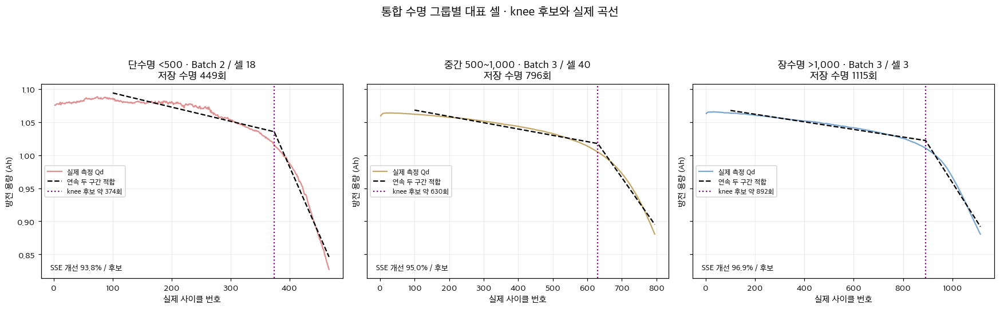

In [ ]:
def q2_fit_knee(c,filtered=True):
    x,y=c['x'],c['y'];valid=c['valid'] if filtered else np.isfinite(y)
    m=valid&(x>=100);x=x[m];y=y[m]
    if len(x)<120:return None
    origin=x.min();scale=x.max()-origin
    z=(x-origin)/scale
    B=np.column_stack([np.ones(len(z)),z]);beta=np.linalg.lstsq(B,y,rcond=None)[0]
    sse0=float(np.sum((y-np.sum(B*beta,axis=1))**2))
    lo=max(100,2+.2*(c['x'].max()-2));hi=2+.8*(c['x'].max()-2)
    candidates=[k for k in np.linspace(lo,hi,80)
                if np.sum(x<=k)>=50 and np.sum(x>k)>=50 and k-x.min()>=50 and x.max()-k>=50]
    if not candidates:return None
    best=None
    for k in candidates:
        hinge=np.maximum(0,(x-k)/scale)
        A=np.column_stack([np.ones(len(z)),z,hinge]);coef=np.linalg.lstsq(A,y,rcond=None)[0]
        pred=np.sum(A*coef,axis=1);sse=float(np.sum((y-pred)**2))
        if best is None or sse<best['sse']:
            before=float(coef[1]/scale);after=float((coef[1]+coef[2])/scale)
            best=dict(k=float(k),sse=sse,improvement=1-sse/sse0 if sse0>0 else 0,
                      before=before,after=after,coef=coef.tolist(),origin=float(origin),scale=float(scale))
    best['shape_ok']=bool(best['after']<0 and best['after']<best['before'] and abs(best['after'])>=2*max(abs(best['before']),1e-9))
    best['detected']=bool(best['shape_ok'] and best['improvement']>=.25)
    best['boundary']=bool(np.isclose(best['k'],candidates[0]) or np.isclose(best['k'],candidates[-1]))
    return best
for c in q2_cells:c['knee']=q2_fit_knee(c)
for threshold in [.15,.25,.40]:
    count=sum(c['knee'] is not None and c['knee']['shape_ok'] and c['knee']['improvement']>=threshold for c in q2_cells)
    print(f'SSE 개선 {threshold:.0%} 기준 후보: {count}/{len(q2_cells)}셀')
for g in range(3):
    group=[c for c in q2_cells if c['group']==g];detected=[c for c in group if c['knee'] and c['knee']['detected']]
    print(eda_group_names[g],f'후보 {len(detected)}/{len(group)}셀',
          '경계 후보:',sum(c['knee']['boundary'] for c in detected))
for c in q2_flagged:
    raw=q2_fit_knee(c,False)
    print('점검값 포함/제외 knee:',c['uid'],None if raw is None else (round(raw['k']),raw['detected']),
          None if c['knee'] is None else (round(c['knee']['k']),c['knee']['detected']))
# 대표 셀은 모형 결과를 보고 고르지 않고, 각 수명 그룹의 아래쪽 중앙 순위로 고정
q2_reps=[]
for g in range(3):
    group=sorted([c for c in q2_cells if c['group']==g],key=lambda c:(c['life'],c['uid']))
    q2_reps.append(group[(len(group)-1)//2])
fig,axes=plt.subplots(1,3,figsize=(16,5),sharey=True)
for ax,c in zip(axes,q2_reps):
    x,y=c['x'],c['y'];ax.plot(x,y,color=eda_colors[c['group']],alpha=.65,label='실제 측정 Qd')
    fit=c['knee']
    if fit:
        xf=x[(x>=100)&c['valid']];a,b,d=fit['coef'];yf=a+b*(xf-fit['origin'])/fit['scale']+d*np.maximum(0,(xf-fit['k'])/fit['scale'])
        ax.plot(xf,yf,color='black',ls='--',lw=1.5,label='연속 두 구간 적합')
        if fit['detected']:
            ax.axvline(fit['k'],color='purple',ls=':',label=f'knee 후보 약 {fit["k"]:.0f}회')
        ax.text(.03,.04,f'SSE 개선 {fit["improvement"]:.1%} / '+('후보' if fit['detected'] else '미검출'),transform=ax.transAxes,fontsize=9)
    ax.set(title=f'{eda_group_names[c["group"]]} · {c["uid"]}\n저장 수명 {c["life"]:.0f}회',xlabel='실제 사이클 번호',ylabel='방전 용량 (Ah)')
    ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.suptitle('통합 수명 그룹별 대표 셀 · knee 후보와 실제 곡선',fontsize=14)
fig.tight_layout(rect=(0,0,1,.9));fig.savefig(eda_out/'scratch_q2_knee_examples.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

knee는 각 셀의 곡선에서 감소 기울기가 크게 달라지는 위치를 두 직선으로 근사한 후보다. 대표 셀마다 후보 위치가 달라 모든 배터리에 공통인 하나의 시작 사이클이 있는 것은 아니다. 표시된 SSE 개선은 곡선 적합의 개선 정도이며 수명 예측 정확도가 아니다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 대표 셀의 knee 후보

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


SSE 개선 15% 기준 후보: 118/119셀
SSE 개선 25% 기준 후보: 118/119셀
SSE 개선 40% 기준 후보: 118/119셀
단수명 <550 후보 32/32셀 경계 후보: 5
장수명 ≥550 후보 86/87셀 경계 후보: 28
점검값 포함/제외 knee: Batch 1 / 셀 18 (552, True) (552, True)


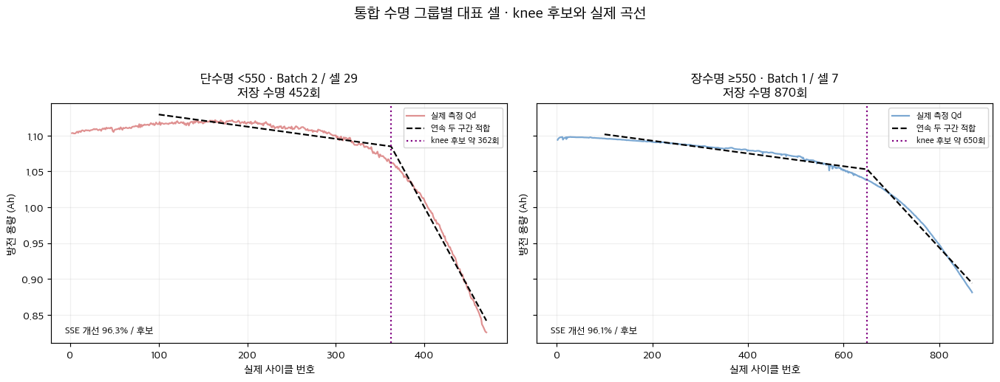

In [ ]:
def b2_q2_fit_knee(c,filtered=True):
    x,y=c['x'],c['y'];valid=c['valid'] if filtered else np.isfinite(y)
    m=valid&(x>=100);x=x[m];y=y[m]
    if len(x)<120:return None
    origin=x.min();scale=x.max()-origin
    z=(x-origin)/scale
    B=np.column_stack([np.ones(len(z)),z]);beta=np.linalg.lstsq(B,y,rcond=None)[0]
    sse0=float(np.sum((y-np.sum(B*beta,axis=1))**2))
    lo=max(100,2+.2*(c['x'].max()-2));hi=2+.8*(c['x'].max()-2)
    candidates=[k for k in np.linspace(lo,hi,80)
                if np.sum(x<=k)>=50 and np.sum(x>k)>=50 and k-x.min()>=50 and x.max()-k>=50]
    if not candidates:return None
    best=None
    for k in candidates:
        hinge=np.maximum(0,(x-k)/scale)
        A=np.column_stack([np.ones(len(z)),z,hinge]);coef=np.linalg.lstsq(A,y,rcond=None)[0]
        pred=np.sum(A*coef,axis=1);sse=float(np.sum((y-pred)**2))
        if best is None or sse<best['sse']:
            before=float(coef[1]/scale);after=float((coef[1]+coef[2])/scale)
            best=dict(k=float(k),sse=sse,improvement=1-sse/sse0 if sse0>0 else 0,
                      before=before,after=after,coef=coef.tolist(),origin=float(origin),scale=float(scale))
    best['shape_ok']=bool(best['after']<0 and best['after']<best['before'] and abs(best['after'])>=2*max(abs(best['before']),1e-9))
    best['detected']=bool(best['shape_ok'] and best['improvement']>=.25)
    best['boundary']=bool(np.isclose(best['k'],candidates[0]) or np.isclose(best['k'],candidates[-1]))
    return best
for c in b2_q2_cells:c['knee']=b2_q2_fit_knee(c)
for threshold in [.15,.25,.40]:
    count=sum(c['knee'] is not None and c['knee']['shape_ok'] and c['knee']['improvement']>=threshold for c in b2_q2_cells)
    print(f'SSE 개선 {threshold:.0%} 기준 후보: {count}/{len(b2_q2_cells)}셀')
for g in range(2):
    group=[c for c in b2_q2_cells if c['group']==g];detected=[c for c in group if c['knee'] and c['knee']['detected']]
    print(b2_eda_group_names[g],f'후보 {len(detected)}/{len(group)}셀',
          '경계 후보:',sum(c['knee']['boundary'] for c in detected))
for c in b2_q2_flagged:
    raw=b2_q2_fit_knee(c,False)
    print('점검값 포함/제외 knee:',c['uid'],None if raw is None else (round(raw['k']),raw['detected']),
          None if c['knee'] is None else (round(c['knee']['k']),c['knee']['detected']))
# 대표 셀은 모형 결과를 보고 고르지 않고, 각 수명 그룹의 아래쪽 중앙 순위로 고정
b2_q2_reps=[]
for g in range(2):
    group=sorted([c for c in b2_q2_cells if c['group']==g],key=lambda c:(c['life'],c['uid']))
    b2_q2_reps.append(group[(len(group)-1)//2])
fig,axes=plt.subplots(1,2,figsize=(13,5),sharey=True)
for ax,c in zip(axes,b2_q2_reps):
    x,y=c['x'],c['y'];ax.plot(x,y,color=b2_eda_colors[c['group']],alpha=.65,label='실제 측정 Qd')
    fit=c['knee']
    if fit:
        xf=x[(x>=100)&c['valid']];a,b,d=fit['coef'];yf=a+b*(xf-fit['origin'])/fit['scale']+d*np.maximum(0,(xf-fit['k'])/fit['scale'])
        ax.plot(xf,yf,color='black',ls='--',lw=1.5,label='연속 두 구간 적합')
        if fit['detected']:
            ax.axvline(fit['k'],color='purple',ls=':',label=f'knee 후보 약 {fit["k"]:.0f}회')
        ax.text(.03,.04,f'SSE 개선 {fit["improvement"]:.1%} / '+('후보' if fit['detected'] else '미검출'),transform=ax.transAxes,fontsize=9)
    ax.set(title=f'{b2_eda_group_names[c["group"]]} · {c["uid"]}\n저장 수명 {c["life"]:.0f}회',xlabel='실제 사이클 번호',ylabel='방전 용량 (Ah)')
    ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.suptitle('통합 수명 그룹별 대표 셀 · knee 후보와 실제 곡선',fontsize=14)
fig.tight_layout(rect=(0,0,1,.9));fig.savefig(b2_eda_out/'scratch_binary_q2_knee_examples.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

knee는 각 셀의 곡선에서 감소 기울기가 크게 달라지는 위치를 두 직선으로 근사한 후보다. 대표 셀마다 후보 위치가 달라 모든 배터리에 공통인 하나의 시작 사이클이 있는 것은 아니다. 표시된 SSE 개선은 곡선 적합의 개선 정도이며 수명 예측 정확도가 아니다.


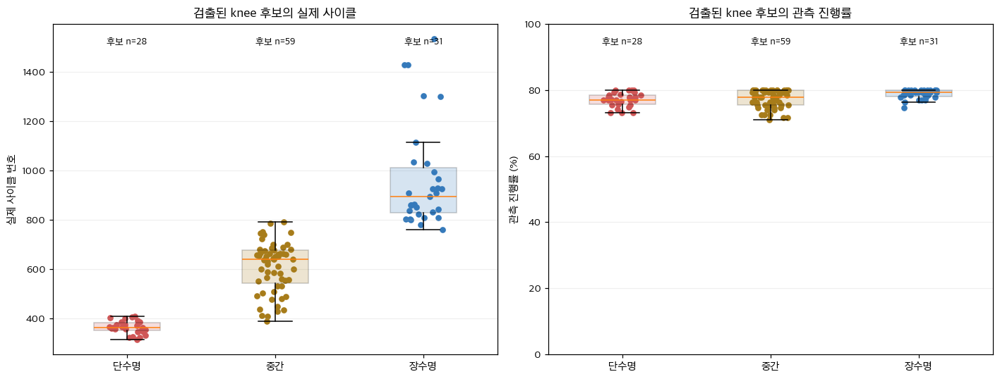

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(13,5));rng=np.random.default_rng(42)
for g in range(3):
    found=[c for c in q2_cells if c['group']==g and c['knee'] and c['knee']['detected']]
    for j in range(2):
        vals=[c['knee']['k'] if j==0 else (c['knee']['k']-2)/(c['x'].max()-2)*100 for c in found]
        if vals:
            box=axes[j].boxplot([vals],positions=[g],widths=.45,patch_artist=True,showfliers=False)
            box['boxes'][0].set(facecolor=eda_colors[g],alpha=.2)
            axes[j].scatter(g+rng.uniform(-.13,.13,len(vals)),vals,color=eda_colors[g],s=22)
        axes[j].text(g,.96,f'후보 n={len(vals)}',transform=axes[j].get_xaxis_transform(),ha='center',va='top',fontsize=9)
for ax in axes:ax.set_xticks(range(3),['단수명','중간','장수명']);ax.set_xlim(-.5,2.5);ax.grid(axis='y',alpha=.2)
axes[0].set(title='검출된 knee 후보의 실제 사이클',ylabel='실제 사이클 번호')
axes[1].set(title='검출된 knee 후보의 관측 진행률',ylabel='관측 진행률 (%)',ylim=(0,100))
fig.tight_layout();fig.savefig(eda_out/'scratch_q2_knee_distribution.png',dpi=140,bbox_inches='tight');plt.show()
q2_export=[]
for c in q2_cells:
    q2_export.append(dict(cell=c['uid'],group=eda_group_names[c['group']],life=c['life'],
                          last_record=float(c['x'].max()),flagged_cycles=c['x'][~c['valid']].tolist(),
                          slopes_ah_per_100=c['slopes'],raw_slopes_ah_per_100=c['raw_slopes'],knee=c['knee']))
(eda_out/'scratch_q2_results.json').write_text(json.dumps(q2_export,ensure_ascii=False,indent=2))

#### 그래프 결과 해석

검출된 knee 후보의 중앙값은 단·중·장수명에서 약 362/639/892회로, 수명이 긴 그룹일수록 실제 사이클 기준 후보가 늦다. 반면 관측 진행률 중앙값은 약 77~79%로 가까워 각 셀의 기록 후반에서 기울기 변화가 잡히는 경향을 보인다. 탐색 상한이 80%이고 33셀이 경계에 걸렸으므로, 이 결과를 모든 셀의 정확한 열화 시작점이 수명의 80%라는 결론으로 바꾸면 안 된다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — knee 후보의 분포

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


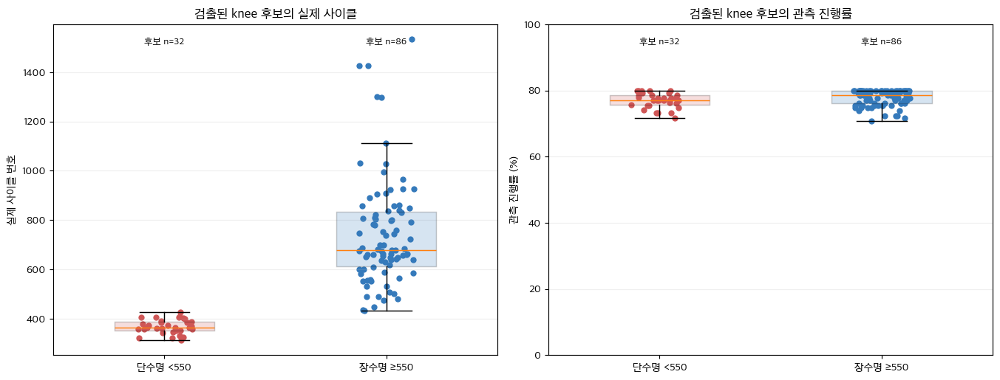

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(13,5));rng=np.random.default_rng(42)
for g in range(2):
    found=[c for c in b2_q2_cells if c['group']==g and c['knee'] and c['knee']['detected']]
    for j in range(2):
        vals=[c['knee']['k'] if j==0 else (c['knee']['k']-2)/(c['x'].max()-2)*100 for c in found]
        if vals:
            box=axes[j].boxplot([vals],positions=[g],widths=.45,patch_artist=True,showfliers=False)
            box['boxes'][0].set(facecolor=b2_eda_colors[g],alpha=.2)
            axes[j].scatter(g+rng.uniform(-.13,.13,len(vals)),vals,color=b2_eda_colors[g],s=22)
        axes[j].text(g,.96,f'후보 n={len(vals)}',transform=axes[j].get_xaxis_transform(),ha='center',va='top',fontsize=9)
for ax in axes:ax.set_xticks(range(2),b2_eda_group_names);ax.set_xlim(-.5,1.5);ax.grid(axis='y',alpha=.2)
axes[0].set(title='검출된 knee 후보의 실제 사이클',ylabel='실제 사이클 번호')
axes[1].set(title='검출된 knee 후보의 관측 진행률',ylabel='관측 진행률 (%)',ylim=(0,100))
fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_q2_knee_distribution.png',dpi=140,bbox_inches='tight');plt.show()
b2_q2_export=[]
for c in b2_q2_cells:
    b2_q2_export.append(dict(cell=c['uid'],group=b2_eda_group_names[c['group']],life=c['life'],
                          last_record=float(c['x'].max()),flagged_cycles=c['x'][~c['valid']].tolist(),
                          slopes_ah_per_100=c['slopes'],raw_slopes_ah_per_100=c['raw_slopes'],knee=c['knee']))
(b2_eda_out/'scratch_binary_q2_results.json').write_text(json.dumps(b2_q2_export,ensure_ascii=False,indent=2))

#### 그래프 결과 해석

검출된 knee 후보의 중앙값은 단·중·장수명에서 약 362/639/892회로, 수명이 긴 그룹일수록 실제 사이클 기준 후보가 늦다. 반면 관측 진행률 중앙값은 약 77~79%로 가까워 각 셀의 기록 후반에서 기울기 변화가 잡히는 경향을 보인다. 탐색 상한이 80%이고 33셀이 경계에 걸렸으므로, 이 결과를 모든 셀의 정확한 열화 시작점이 수명의 80%라는 결론으로 바꾸면 안 된다.


#### Knee 결과를 사이클 번호로 읽기 — 그래서 언제부터 가팔라지는가?

**한 개의 공통 시작점은 없다.** 셀마다 다른 knee 후보를 계산했으며, 아래 숫자는 검출된 후보 사이클의 **그룹 중앙값**이다. 그룹 평균 곡선에 직접 적합한 시작점이 아니다.

|수명 그룹|가팔라지는 지점의 대표 추정치|셀별 후보 범위|검출 셀 / 전체|탐색 경계 후보|
|---|---:|---:|---:|---:|
|단수명 <500|**약 362회**|약 313~406회|28 / 28|4|
|중간 500~1,000|**약 639회**|약 387~791회|59 / 60|17|
|장수명 >1,000|**약 892회**|약 759~1533회|31 / 31|12|

예를 들어 단수명 그룹의 “약 362회”는 **단수명 셀들이 모두 362회부터 열화된다는 뜻이 아니라**, 계산한 전환점들이 그 부근을 중심으로 분포한다는 뜻이다.
열화 자체는 그 이전에도 진행된다. 여기서 찾는 것은 **감소가 시작되는 첫 순간이 아니라, 이미 진행 중인 용량 감소가 더 가팔라지는 전환 구간**이다.

앞의 대표 셀 그림에서 보라색 세로선은 각각 **약 374회(단수명 사례), 630회(중간 사례), 892회(장수명 사례)**다. 대표 셀의 후보와 그룹 중앙값은 다른 통계다.

탐색 경계에 걸린 33개 후보는 실제 위치가 탐색 범위 밖에 있을 가능성이 있어 추가 확인 대상으로 표시한다. 경계 후보를 뺀 후보 중앙값은 단수명 약 363회, 중간 약 614회, 장수명 약 908회다. 이것도 확정된 물리적 knee는 아니다.
아래 표에서 **각 셀의 후보 사이클·전후 용량 감소 속도·판정 상태**를 확인할 수 있다. “미검출”은 설정한 기준을 충족하지 못했다는 뜻이다.


In [ ]:
# 셀별 knee 시작점 표: 실제 사이클 번호로 표시
from pathlib import Path
import json
knee_table_path = eda_out / 'scratch_q2_results.json'
knee_table_rows = json.loads(knee_table_path.read_text())
print('셀 식별자 | 수명 그룹 | 저장 수명 | knee 후보(회) | 전반→후반 기울기(Ah/100회) | 상태')
for row in sorted(knee_table_rows, key=lambda r:(r['life'], r['cell'])):
    k=row['knee']
    found=k is not None and k['detected']
    point=f"{k['k']:.0f}" if found else '—'
    status=('경계 후보·추가 확인' if k['boundary'] else '탐색 후보') if found else '미검출'
    slopes=f"{k['before']*100:.4f} → {k['after']*100:.4f}" if k else '—'
    print(f"{row['cell']} | {row['group']} | {row['life']:.0f} | {point} | {slopes} | {status}")


셀 식별자 | 수명 그룹 | 저장 수명 | knee 후보(회) | 전반→후반 기울기(Ah/100회) | 상태
Batch 2 / 셀 19 | 단수명 <500 | 392 | 320 | -0.0254 → -0.2334 | 탐색 후보
Batch 2 / 셀 6 | 단수명 <500 | 393 | 313 | -0.0319 → -0.1949 | 탐색 후보
Batch 2 / 셀 15 | 단수명 <500 | 396 | 326 | -0.0328 → -0.1933 | 탐색 후보
Batch 2 / 셀 21 | 단수명 <500 | 408 | 323 | -0.0244 → -0.2108 | 탐색 후보
Batch 2 / 셀 30 | 단수명 <500 | 412 | 344 | -0.0296 → -0.2131 | 경계 후보·추가 확인
Batch 2 / 셀 5 | 단수명 <500 | 416 | 330 | -0.0419 → -0.1382 | 탐색 후보
Batch 2 / 셀 2 | 단수명 <500 | 424 | 352 | -0.0206 → -0.2060 | 경계 후보·추가 확인
Batch 2 / 셀 31 | 단수명 <500 | 425 | 357 | -0.0363 → -0.2083 | 경계 후보·추가 확인
Batch 2 / 셀 14 | 단수명 <500 | 426 | 345 | -0.0300 → -0.1614 | 탐색 후보
Batch 2 / 셀 28 | 단수명 <500 | 437 | 352 | -0.0292 → -0.1866 | 탐색 후보
Batch 2 / 셀 41 | 단수명 <500 | 442 | 357 | -0.0297 → -0.1972 | 탐색 후보
Batch 2 / 셀 4 | 단수명 <500 | 444 | 358 | -0.0281 → -0.1661 | 탐색 후보
Batch 2 / 셀 11 | 단수명 <500 | 449 | 361 | -0.0161 → -0.2249 | 탐색 후보
Batch 2 / 셀 18 | 단수명 <500 | 449 | 374 | -0.0214 → -0.2036 | 경계 후보·추

#### Question 2 결과 해석 — 모든 그래프를 본 뒤 정리

##### 1. 방전 용량은 일정하게 감소하는가?

초기에는 변화가 작거나 일부 증가하는 구간이 있지만, 중기부터 감소하고 관측 말기에 감소가 가팔라진다.
그룹 중앙값 선만으로 판단하지 않고, 셀마다 실제 사이클 번호에 대한 기울기를 계산했다.

|수명 그룹|관측 초기 기울기 중앙값|관측 중기|관측 말기|중기·말기 모두 감소하며 말기가 더 가파른 셀|
|---|---:|---:|---:|---:|
|단수명|+0.00028|−0.02682|−0.14398|28 / 28|
|중간|−0.00358|−0.00911|−0.05993|60 / 60|
|장수명|−0.00348|−0.00612|−0.04068|31 / 31|

단위는 **Ah / 100사이클**이다. 이는 각 구간의 직선 적합 기울기이며 특정 100회 구간의 실측 감소량을 뜻하지 않는다.
통합 표본에서는 119셀 모두 중기보다 말기의 감소가 더 가팔랐고, 단수명 그룹의 말기 기울기 중앙값이 가장 음수였다.
따라서 **일정한 감소 속도보다는 후반 가속을 동반한 형태가 관찰됐다**고 정리할 수 있다.
다만 관측 구간 3등분의 경계는 임의의 분석 기준이고, 실험 조건·기록 종료 시점이 섞여 있으므로 원인이나 통계적 유의성을 확정한 것은 아니다.

##### 2. Knee point를 찾았는가?

|수명 그룹|기준을 만족한 knee 후보|그중 탐색 경계에 걸린 후보|
|---|---:|---:|
|단수명|28 / 28|4|
|중간|59 / 60|17|
|장수명|31 / 31|12|
|합계|118 / 119|33|

- 이 수치는 **연속 두 구간 직선 모형으로 얻은 탐색 후보**다. 물리적 knee의 정답이나 정확도가 아니다.
- 특히 **33셀은 최적점이 탐색 경계에 위치**한다. 실제 최적 분기점이 범위 밖일 수 있어 위치의 불확실성이 크다. 나머지 85개 역시 검증된 정답은 아니다.
- SSE 개선 기준을 15%·25%·40%로 바꿔도 이번 표본에서는 후보 수가 118개로 같았다. 이는 이 기준에 대한 민감도가 작다는 뜻이며, 탐색 범위·모형·후반 기울기 배수까지 안정적이라는 뜻은 아니다.
- 미검출 1셀은 후반 감소가 없다는 뜻이 아니다. 두 구간 적합은 개선되지만 후반 기울기가 전반의 2배 이상이라는 이번 기준을 충족하지 못했다.
- 관측 진행률 그림은 기록 길이로 나눈 상대 위치다. 후보가 늦게 나타나는 것과 실제 수명이 긴 것은 독립적인 정보가 아니므로, knee와 총수명의 관계를 예측력으로 해석하지 않는다.

##### 3. 데이터 점검과 후속 판단

- 한 셀의 40회차 Qd=2.884 Ah가 확인돼, 원본 곡선에는 남기고 기울기 적합에서는 제외했다. 초기 기울기는 포함 시 −0.02429, 제외 시 −0.01060 Ah/100회로 달라져 이상값 영향이 있었다.
- knee 적합은 100회 이후를 사용하므로 이 40회차 점의 포함/제외가 해당 셀의 knee 후보에 영향을 주지 않았다.
- 다음에 knee를 더 정밀하게 다룬다면 경계 후보부터 탐색 범위를 넓혀 보고, 개별 곡선과 구간별 잔차를 확인한다. 여러 방법이 같은 위치를 가리키는지도 검토해야 한다.
- 용량 감소 가속은 관찰됐지만 계면 부반응·가용 리튬 손실 등 구체적인 화학 원인은 아직 가설이다.

##### 보고서용 정리

> 통합 데이터의 셀별 방전 용량은 일정한 속도로 감소하기보다 관측 후반에 감소가 가팔라지는 경향을 보였다. 실제 사이클 번호에 대한 구간별 기울기로 확인한 결과, 분석 대상 119셀 모두 말기 감소 속도가 중기보다 컸다. 연속 두 구간 직선 적합으로 118셀에서 knee 후보를 찾았으나, 33셀은 탐색 경계에 위치하여 추가 확인이 필요하다. 따라서 이번 결과는 열화 가속과 전환 구간에 대한 탐색 근거이며 특정 화학적 원인이나 확정된 knee 위치를 입증한 것은 아니다.

#### 2그룹 추가 해석 — 위의 3그룹 해석과 함께 읽기

|550회 기준 그룹|셀 수|초기/중기/말기 기울기 중앙값 (Ah/100회)|knee 후보 수|knee 중앙값 (실제 사이클)|경계 후보 수|
|---|---:|---|---:|---:|---:|
|단수명 <550|32|-0.00019 / -0.02660 / -0.14256|32|364.6|5|
|장수명 ≥550|87|-0.00353 / -0.00806 / -0.05071|86|679.6|28|

그룹을 바꿔도 **개별 셀의 knee 추정치는 같고 그룹 요약만 달라진다.** 하나의 공통 열화 시작점은 없다. 경계 후보는 탐색 범위에 걸린 값이므로 그대로 물리적 knee로 확정하지 않는다. 기존 적합 조건·점검값 제외 기준을 유지했다.

### 5-8. Question 3 — ΔQ(V) 곡선: 초기 사이클에서 차이가 보이는가?

**앞 결과에서 이어지는 질문**

앞 절에서 확인한 가속 열화와 knee는 후반 기록을 사용한 설명이다. 초기 100회만으로 수명을 추정하려면 그 이전에 보이는 차이가 필요하다. 따라서 **총용량 한 값에서 전압별 곡선 변화로 분석 대상을 넓혀** ΔQ(V)를 확인한다.

통합 119셀을 단수명(<500)·중간(500~1,000)·장수명(>1,000)으로 비교한다. 배치별로 그래프를 나누지 않는다.
앞서 요약 피처를 계산했지만, 이번에는 **실제 곡선 모양 → 곡선 차이 → 통계 피처 → 중복 점검** 순서로 확인한다.
5-2의 로딩 셀 실행 후 이 절을 실행할 수 있다.

`ΔQ(V) = Q100(V) − Q10(V)`

- **x축은 사이클 번호가 아니라 전압(V)**이다. 같은 전압 위치의 값을 뺀다.
- Q(V)는 해당 전압에 도달할 때까지의 누적 방전 용량(Ah)이다. 한 사이클의 총 방전 용량 QDischarge와 구분한다.
- y축이 음수면 100회차의 누적 방전 용량이 10회차보다 작다는 뜻이다. 모든 전압에서 반드시 음수일 필요는 없다.
- 원본의 Qdlin은 보간된 곡선이다. Vdlin 축이 같은지 확인하고 공통 축으로 정렬한다. 곡선 전체에서 계산하는 분산은 **전압 위치에 따른 차이의 분산**이며 센서 잡음 분산과 같은 뜻이 아니다.
- 실제 summary.cycle에서 10·100회 위치를 찾는다. 단순히 배열 10번째·100번째를 사용하지 않는다.

In [ ]:
import h5py
import json
import numpy as np
import matplotlib.pyplot as plt
q3_rows=[];q3_axis=None
for name,b in eda_batches.items():
    with h5py.File(eda_root/'archive'/f'{b["date"]}_batchdata_updated_struct_errorcorrect.mat','r') as mat:
        for cid,r in b['cells'].items():
            if not r['valid'] or r['incomplete']:continue
            summary=mat[mat['batch']['summary'][cid,0]];cy=summary['cycle'][()].ravel()
            pos=[np.flatnonzero(cy==k) for k in [10,100]]
            if any(len(p)!=1 for p in pos):raise ValueError(f'{name} 셀 {cid}: 10/100회 누락 또는 중복')
            cycles=mat[mat['batch']['cycles'][cid,0]]
            axis=mat[mat['batch']['Vdlin'][cid,0]][()].ravel()
            a=mat[cycles['Qdlin'][pos[0][0],0]][()].ravel();z=mat[cycles['Qdlin'][pos[1][0],0]][()].ravel()
            if len(a)!=len(axis) or len(z)!=len(axis):raise ValueError('곡선/전압축 길이 불일치')
            order=np.argsort(axis);axis=axis[order];a=a[order];z=z[order]
            if not np.isfinite(np.r_[axis,a,z]).all() or not (np.diff(axis)>0).all():raise ValueError('축/곡선 유효성 확인 필요')
            if q3_axis is None:q3_axis=axis
            if len(axis)!=len(q3_axis) or not np.allclose(axis,q3_axis,rtol=0,atol=1e-8):raise ValueError('셀 간 공통 전압축 불일치')
            dq=z-a;var=float(np.var(dq,ddof=0))
            if var<=0:raise ValueError('ΔQ 분산 0: 로그 계산 불가')
            features=[float(np.log10(var)),float(np.mean(dq)),float(np.min(dq)),float(np.percentile(dq,75)-np.percentile(dq,25))]
            q3_rows.append(dict(cell=f'{name} / 셀 {cid}',life=r['life'],group=eda_group(r['life']),q10=a,q100=z,delta=dq,features=features))
assert len(q3_rows)==119
q3_feature_names=['ΔQ log 분산','ΔQ 평균','ΔQ 최솟값','ΔQ 사분위 범위']
q3_X=np.array([r['features'] for r in q3_rows]);q3_y=np.array([r['life'] for r in q3_rows]);q3_g=np.array([r['group'] for r in q3_rows])
print(f'통합 {len(q3_rows)}셀 / 공통 전압축 {q3_axis[0]:.1f}~{q3_axis[-1]:.1f} V / {len(q3_axis)}점')
print('그룹 셀 수:',[int((q3_g==g).sum()) for g in range(3)])

통합 119셀 / 공통 전압축 2.0~3.5 V / 1000점
그룹 셀 수: [28, 60, 31]


In [ ]:
b2_q3_rows=[dict(r,group=b2_eda_group(r['life'])) for r in q3_rows]
b2_q3_axis=q3_axis.copy();b2_q3_X=q3_X.copy();b2_q3_y=q3_y.copy()
b2_q3_g=np.array([r['group'] for r in b2_q3_rows]);b2_q3_feature_names=q3_feature_names.copy()


#### ① 원래 방전곡선과 ΔQ(V)의 관계

각 수명 그룹에서 저장 수명순 아래쪽 중앙 셀을 대표로 고른다. 점선은 10회차, 실선은 100회차이며 같은 색의 두 선 사이 차이를 아래 ΔQ로 표시한다.
전압은 방전 진행 방향에 맞춰 왼쪽 3.5 V에서 오른쪽 2.0 V로 감소한다. 대표 셀은 그룹 평균이 아니다.

대표 셀: 단수명 <500 Batch 2 / 셀 18 449.0
대표 셀: 중간 500~1,000 Batch 3 / 셀 40 796.0
대표 셀: 장수명 >1,000 Batch 3 / 셀 3 1115.0


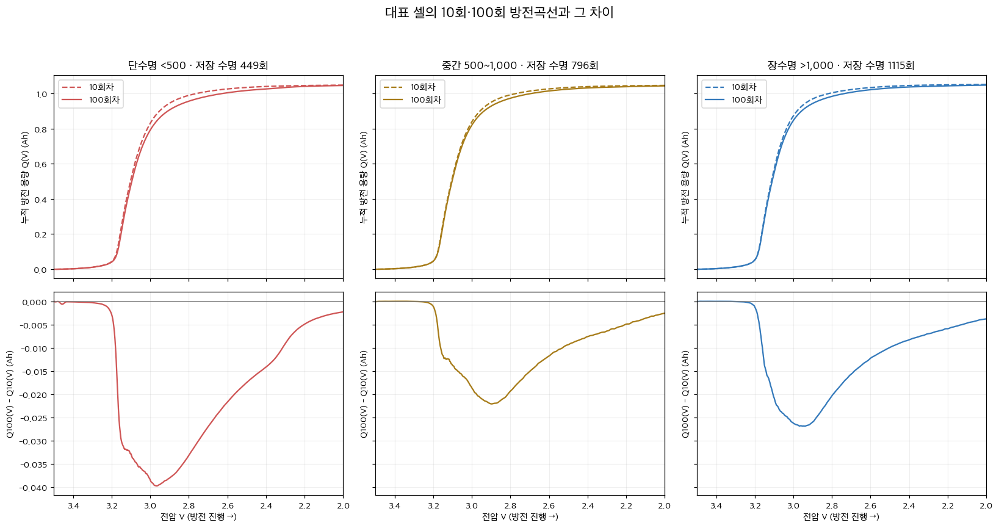

In [ ]:
q3_reps=[]
for g in range(3):
    group=sorted([r for r in q3_rows if r['group']==g],key=lambda r:(r['life'],r['cell']))
    q3_reps.append(group[(len(group)-1)//2])
fig,axes=plt.subplots(2,3,figsize=(15,8),sharex=True,sharey='row')
for g,r in enumerate(q3_reps):
    axes[0,g].plot(q3_axis,r['q10'],color=eda_colors[g],ls='--',label='10회차')
    axes[0,g].plot(q3_axis,r['q100'],color=eda_colors[g],label='100회차')
    axes[0,g].set(title=f'{eda_group_names[g]} · 저장 수명 {r["life"]:.0f}회',ylabel='누적 방전 용량 Q(V) (Ah)');axes[0,g].legend()
    axes[1,g].plot(q3_axis,r['delta'],color=eda_colors[g]);axes[1,g].axhline(0,color='gray',lw=1)
    axes[1,g].set(xlabel='전압 V (방전 진행 →)',ylabel='Q100(V) - Q10(V) (Ah)')
    for ax in axes[:,g]:ax.set_xlim(3.5,2.0);ax.grid(alpha=.2)
    print('대표 셀:',eda_group_names[g],r['cell'],r['life'])
fig.suptitle('대표 셀의 10회·100회 방전곡선과 그 차이',fontsize=15)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(eda_out/'scratch_q3_original_and_delta.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

겹쳐 보이는 10회·100회 방전곡선도 동일 전압에서 차이를 계산하면 변화의 위치와 크기가 드러난다. ΔQ(V)는 총 방전 용량 한 값으로는 드러나지 않는 곡선 형태의 변화를 나타낸다. 다만 대표 셀의 사례이므로 수명 그룹 전체의 차이는 다음 전체 셀 비교로 확인해야 한다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 10회·100회 곡선과 차이

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


대표 셀: 단수명 <550 Batch 2 / 셀 29 452.0
대표 셀: 장수명 ≥550 Batch 1 / 셀 7 870.0


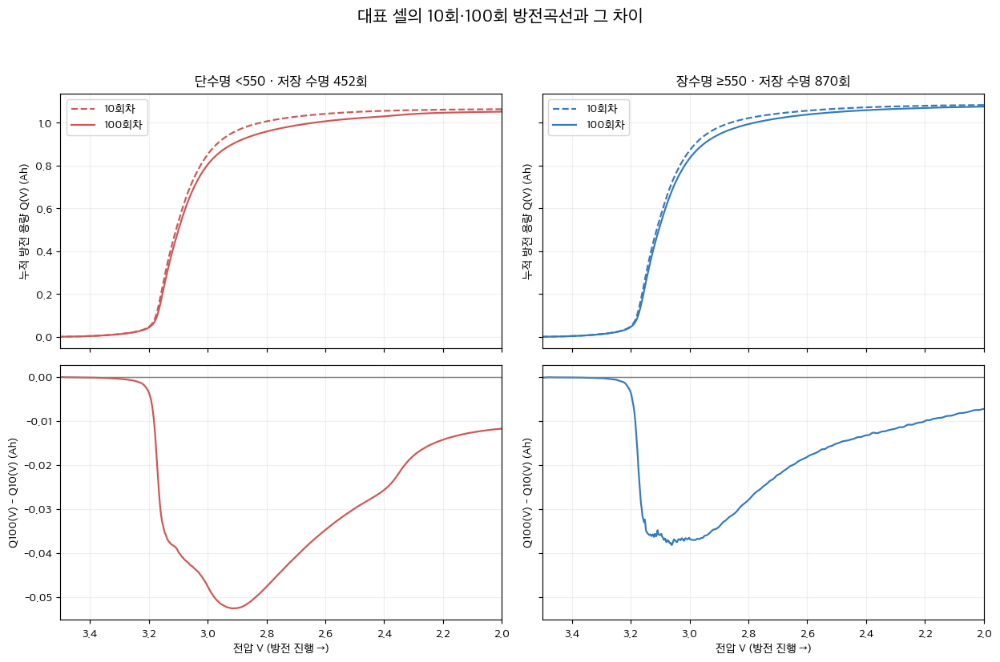

In [ ]:
b2_q3_reps=[]
for g in range(2):
    group=sorted([r for r in b2_q3_rows if r['group']==g],key=lambda r:(r['life'],r['cell']))
    b2_q3_reps.append(group[(len(group)-1)//2])
fig,axes=plt.subplots(2,2,figsize=(12,8),sharex=True,sharey='row')
for g,r in enumerate(b2_q3_reps):
    axes[0,g].plot(b2_q3_axis,r['q10'],color=b2_eda_colors[g],ls='--',label='10회차')
    axes[0,g].plot(b2_q3_axis,r['q100'],color=b2_eda_colors[g],label='100회차')
    axes[0,g].set(title=f'{b2_eda_group_names[g]} · 저장 수명 {r["life"]:.0f}회',ylabel='누적 방전 용량 Q(V) (Ah)');axes[0,g].legend()
    axes[1,g].plot(b2_q3_axis,r['delta'],color=b2_eda_colors[g]);axes[1,g].axhline(0,color='gray',lw=1)
    axes[1,g].set(xlabel='전압 V (방전 진행 →)',ylabel='Q100(V) - Q10(V) (Ah)')
    for ax in axes[:,g]:ax.set_xlim(3.5,2.0);ax.grid(alpha=.2)
    print('대표 셀:',b2_eda_group_names[g],r['cell'],r['life'])
fig.suptitle('대표 셀의 10회·100회 방전곡선과 그 차이',fontsize=15)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(b2_eda_out/'scratch_binary_q3_original_and_delta.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

겹쳐 보이는 10회·100회 방전곡선도 동일 전압에서 차이를 계산하면 변화의 위치와 크기가 드러난다. ΔQ(V)는 총 방전 용량 한 값으로는 드러나지 않는 곡선 형태의 변화를 나타낸다. 다만 대표 셀의 사례이므로 수명 그룹 전체의 차이는 다음 전체 셀 비교로 확인해야 한다.


#### ② 모든 셀을 합쳐 곡선 형태 비교

왼쪽은 셀별 ΔQ 곡선, 오른쪽은 전압 위치별 그룹 중앙값과 사분위 범위다. 음영은 셀 간 25~75% 범위이며 평균의 신뢰구간이 아니다.
그룹 중앙값 곡선 하나에서 피처를 계산하지 않고, **각 셀의 곡선에서 통계값 하나씩** 추출한다.

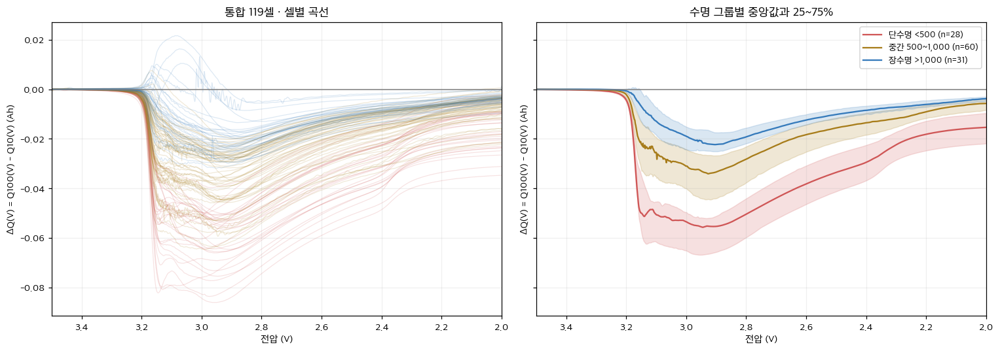

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True)
for g in range(3):
    curves=np.array([r['delta'] for r in q3_rows if r['group']==g])
    for curve in curves:axes[0].plot(q3_axis,curve,color=eda_colors[g],alpha=.17,lw=.8)
    lo,med,hi=np.percentile(curves,[25,50,75],axis=0)
    axes[1].plot(q3_axis,med,color=eda_colors[g],label=f'{eda_group_names[g]} (n={len(curves)})')
    axes[1].fill_between(q3_axis,lo,hi,color=eda_colors[g],alpha=.18)
for ax in axes:
    ax.set(xlim=(3.5,2),xlabel='전압 (V)',ylabel='ΔQ(V) = Q100(V) - Q10(V) (Ah)');ax.axhline(0,color='gray',lw=1);ax.grid(alpha=.2)
axes[0].set_title('통합 119셀 · 셀별 곡선');axes[1].set_title('수명 그룹별 중앙값과 25~75%');axes[1].legend(fontsize=9)
fig.tight_layout();fig.savefig(eda_out/'scratch_q3_delta_groups.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

단수명 그룹은 ΔQ가 더 깊은 음수 방향으로 나타나는 경향이 있어 초기 10~100회 사이의 방전곡선 변화와 이후 수명이 연결되어 있음을 보여준다. 중간 그룹이 대체로 그 사이에 놓인다는 점도 변화량이 수명과 연속적으로 연관될 가능성을 뒷받침한다. 개별 곡선의 겹침이 있으므로 이 모양만으로 모든 셀을 완벽히 구분한다고 볼 수는 없다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 전체 ΔQ(V)와 그룹 중앙값

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


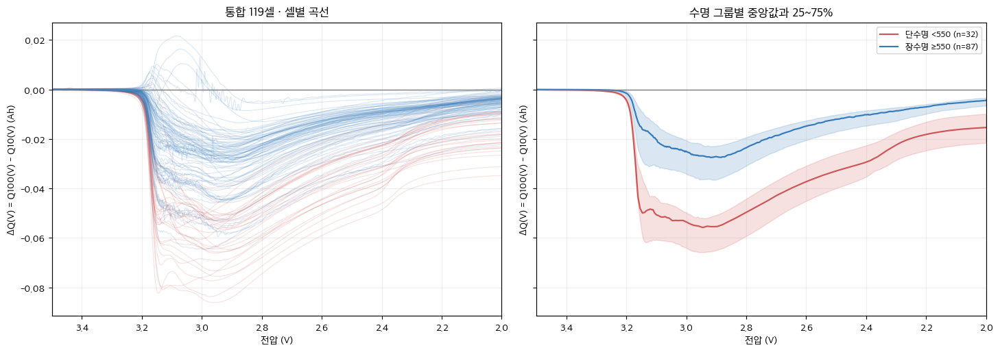

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True)
for g in range(2):
    curves=np.array([r['delta'] for r in b2_q3_rows if r['group']==g])
    for curve in curves:axes[0].plot(b2_q3_axis,curve,color=b2_eda_colors[g],alpha=.17,lw=.8)
    lo,med,hi=np.percentile(curves,[25,50,75],axis=0)
    axes[1].plot(b2_q3_axis,med,color=b2_eda_colors[g],label=f'{b2_eda_group_names[g]} (n={len(curves)})')
    axes[1].fill_between(b2_q3_axis,lo,hi,color=b2_eda_colors[g],alpha=.18)
for ax in axes:
    ax.set(xlim=(3.5,2),xlabel='전압 (V)',ylabel='ΔQ(V) = Q100(V) - Q10(V) (Ah)');ax.axhline(0,color='gray',lw=1);ax.grid(alpha=.2)
axes[0].set_title('통합 119셀 · 셀별 곡선');axes[1].set_title('수명 그룹별 중앙값과 25~75%');axes[1].legend(fontsize=9)
fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_q3_delta_groups.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

단수명 그룹은 ΔQ가 더 깊은 음수 방향으로 나타나는 경향이 있어 초기 10~100회 사이의 방전곡선 변화와 이후 수명이 연결되어 있음을 보여준다. 중간 그룹이 대체로 그 사이에 놓인다는 점도 변화량이 수명과 연속적으로 연관될 가능성을 뒷받침한다. 개별 곡선의 겹침이 있으므로 이 모양만으로 모든 셀을 완벽히 구분한다고 볼 수는 없다.


#### ③ 곡선을 숫자로 요약 — 피처 추출

|피처|계산|무엇을 요약하는가?|
|---|---|---|
|ΔQ log 분산|log10(전압점별 ΔQ의 분산)|전압 구간에 따라 변화량이 달라지는 정도. Ah 단위로 계산한 분산의 로그를 사용|
|ΔQ 평균|전압점별 ΔQ의 평균|곡선 변화의 전반적인 방향과 수준, Ah|
|ΔQ 최솟값|전압점별 ΔQ 중 가장 작은 값|가장 음의 변화. 한 전압점의 국소 이상값 영향 가능, Ah|
|ΔQ 사분위 범위|ΔQ의 75분위−25분위|극단점의 영향을 상대적으로 덜 받는 곡선 변화 폭, Ah|

단·중·장수명은 y에서 나눈 그룹이다. 피처 분포가 달라도 분류 성능을 검증한 것은 아니다.
log 분산이 크다는 것은 변동폭이 크다는 뜻이지 단순히 용량이 더 많이 감소했다는 뜻은 아니다. 평균·최솟값 및 원곡선과 함께 읽는다.

피처 | 수명 Spearman | 네 피처 동시 투입 VIF | 단/중/장수명 중앙값
ΔQ log 분산 | -0.888 | 21.88 | [-3.446103, -3.869312, -4.271782]
ΔQ 평균 | 0.861 | 49.39 | [-0.028665, -0.015567, -0.009621]
ΔQ 최솟값 | 0.876 | 87.83 | [-0.05618, -0.034853, -0.022324]
ΔQ 사분위 범위 | -0.896 | 18.35 | [0.031203, 0.018782, 0.011532]


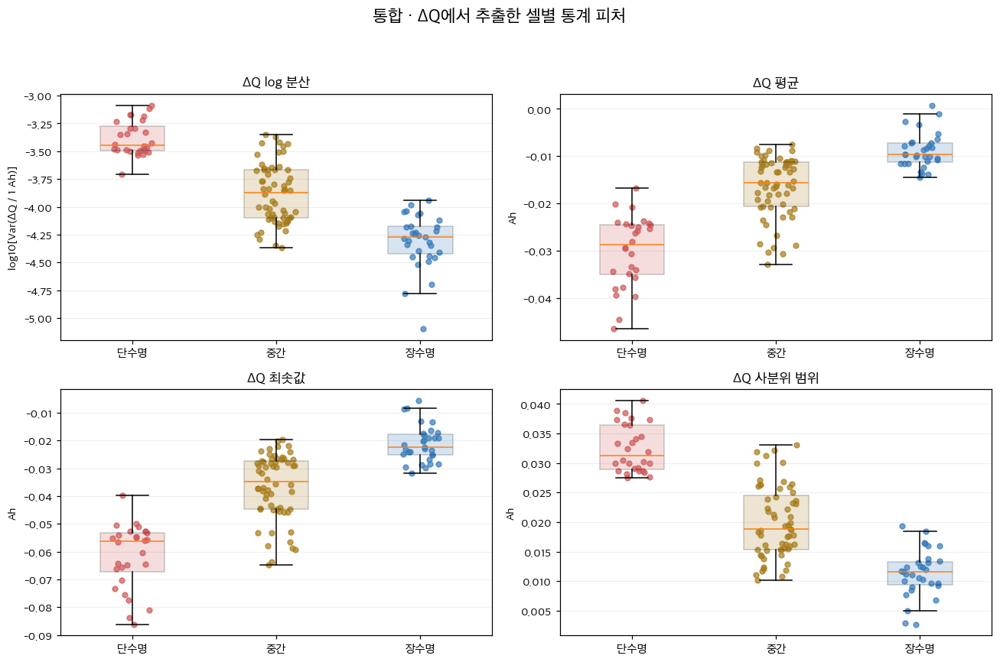

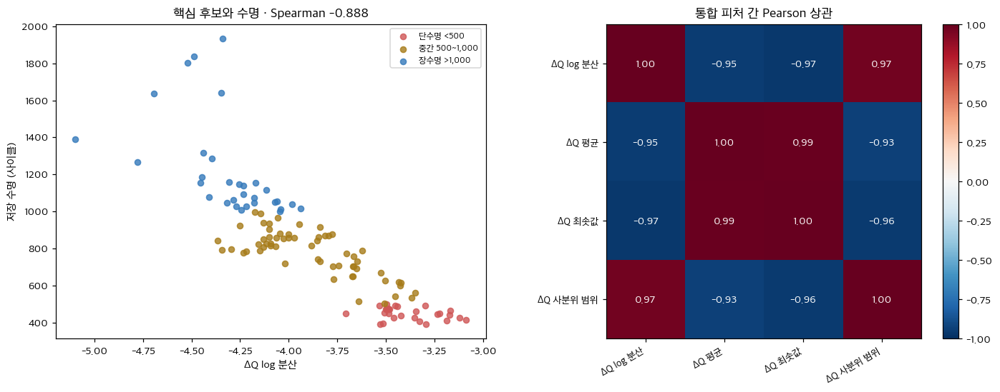

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(12,8));rng=np.random.default_rng(42)
for j,ax in enumerate(axes.flat):
    for g in range(3):
        v=q3_X[q3_g==g,j];box=ax.boxplot([v],positions=[g],widths=.45,showfliers=False,patch_artist=True)
        box['boxes'][0].set(facecolor=eda_colors[g],alpha=.2)
        ax.scatter(g+rng.uniform(-.14,.14,len(v)),v,color=eda_colors[g],alpha=.7,s=20)
    ax.set_xticks(range(3),['단수명','중간','장수명']);ax.set(title=q3_feature_names[j],ylabel='log10[Var(ΔQ / 1 Ah)]' if j==0 else 'Ah');ax.grid(axis='y',alpha=.2)
fig.suptitle('통합 · ΔQ에서 추출한 셀별 통계 피처',fontsize=15)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(eda_out/'scratch_q3_feature_distributions.png',dpi=140,bbox_inches='tight');plt.show()
def q3_rank(a):return np.array([np.sum(a<v)+(np.sum(a==v)-1)/2 for v in a],float)
q3_rho=np.array([np.corrcoef(q3_rank(q3_X[:,j]),q3_rank(q3_y))[0,1] for j in range(4)])
q3_corr=np.corrcoef(q3_X,rowvar=False)
fig,axes=plt.subplots(1,2,figsize=(13,5))
for g in range(3):
    m=q3_g==g;axes[0].scatter(q3_X[m,0],q3_y[m],color=eda_colors[g],s=28,alpha=.8,label=eda_group_names[g])
axes[0].set(xlabel='ΔQ log 분산',ylabel='저장 수명 (사이클)',title=f'핵심 후보와 수명 · Spearman {q3_rho[0]:.3f}');axes[0].legend(fontsize=8)
im=axes[1].imshow(q3_corr,vmin=-1,vmax=1,cmap='RdBu_r');axes[1].set_xticks(range(4),q3_feature_names,rotation=30,ha='right',fontsize=9);axes[1].set_yticks(range(4),q3_feature_names,fontsize=9)
for i in range(4):
    for j in range(4):axes[1].text(j,i,f'{q3_corr[i,j]:.2f}',ha='center',va='center',color='white' if abs(q3_corr[i,j])>.6 else 'black')
axes[1].set_title('통합 피처 간 Pearson 상관');fig.colorbar(im,ax=axes[1]);fig.tight_layout();fig.savefig(eda_out/'scratch_q3_feature_relationships.png',dpi=140,bbox_inches='tight');plt.show()
Z=(q3_X-q3_X.mean(0))/q3_X.std(0);q3_vif=[]
for j in range(4):
    B=np.column_stack([np.ones(len(Z)),np.delete(Z,j,axis=1)]);coef=np.linalg.lstsq(B,Z[:,j],rcond=None)[0]
    residual=Z[:,j]-np.sum(B*coef,axis=1);q3_vif.append(float(np.sum(Z[:,j]**2)/np.sum(residual**2)))
print('피처 | 수명 Spearman | 네 피처 동시 투입 VIF | 단/중/장수명 중앙값')
for j,label in enumerate(q3_feature_names):
    print(label,round(q3_rho[j],3),round(q3_vif[j],2),[round(float(np.median(q3_X[q3_g==g,j])),6) for g in range(3)],sep=' | ')
q3_export=[dict(cell=r['cell'],life=r['life'],group=eda_group_names[r['group']],**dict(zip(['logvar_dq','dq_mean','dq_min','dq_iqr'],r['features']))) for r in q3_rows]
(eda_out/'scratch_q3_features.json').write_text(json.dumps(dict(rows=q3_export,spearman=q3_rho.tolist(),correlation=q3_corr.tolist(),vif=q3_vif),ensure_ascii=False,indent=2))

#### 그래프 결과 해석

단수명 그룹의 큰 분산·IQR과 더 음수인 평균·최솟값은 ΔQ 곡선 변화의 크기와 전압별 불균일성이 수명과 연관되어 있다는 결과다. 같은 곡선에서 얻은 통계들이므로 네 지표에서 차이가 관측되었다고 해서 독립된 네 가지 원인이 확인된 것은 아니다. 분포의 겹침을 고려하면 각 지표는 확정적인 수명 판정 기준이 아니라 연관 신호로 해석하는 것이 적절하다.

ΔQ 통계는 수명과 강한 순위 상관을 보이지만 통계들끼리도 강하게 중복된다. IQR의 |상관|가 log 분산보다 조금 크다는 결과만으로 더 좋은 예측 변수라고 확정할 수는 없다. 여러 ΔQ 통계의 높은 상관을 각각 독립된 증거로 합산하기보다, 공통된 초기 곡선 변화 신호가 여러 방식으로 요약된 결과로 읽는다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — ΔQ 피처 분포·상관·VIF

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


피처 | 수명 Spearman | 네 피처 동시 투입 VIF | 단/장수명 중앙값
ΔQ log 분산 | -0.888 | 21.88 | [-3.451279, -4.091804]
ΔQ 평균 | 0.861 | 49.39 | [-0.028665, -0.011765]
ΔQ 최솟값 | 0.876 | 87.83 | [-0.05618, -0.027841]
ΔQ 사분위 범위 | -0.896 | 18.35 | [0.03011, 0.015921]


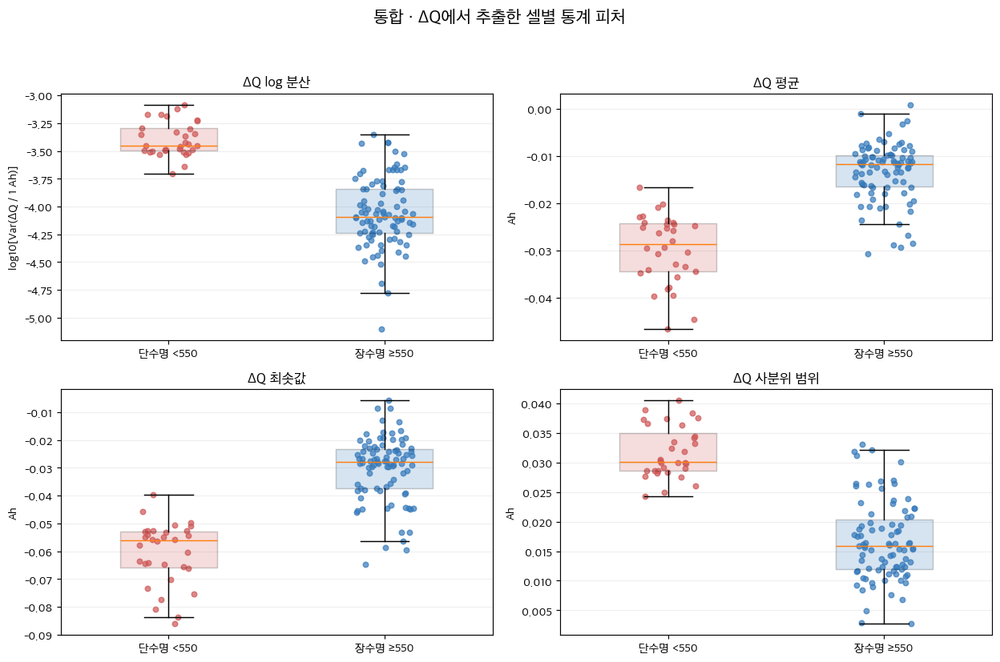

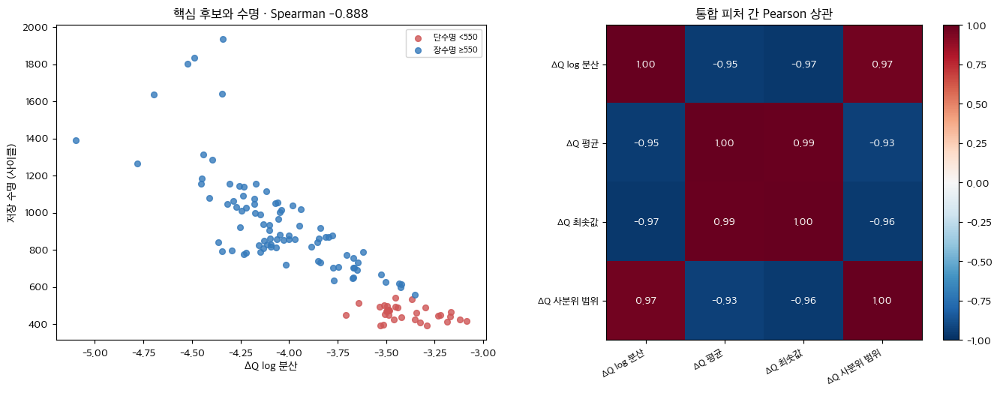

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(12,8));rng=np.random.default_rng(42)
for j,ax in enumerate(axes.flat):
    for g in range(2):
        v=b2_q3_X[b2_q3_g==g,j];box=ax.boxplot([v],positions=[g],widths=.45,showfliers=False,patch_artist=True)
        box['boxes'][0].set(facecolor=b2_eda_colors[g],alpha=.2)
        ax.scatter(g+rng.uniform(-.14,.14,len(v)),v,color=b2_eda_colors[g],alpha=.7,s=20)
    ax.set_xticks(range(2),b2_eda_group_names);ax.set(title=b2_q3_feature_names[j],ylabel='log10[Var(ΔQ / 1 Ah)]' if j==0 else 'Ah');ax.grid(axis='y',alpha=.2)
fig.suptitle('통합 · ΔQ에서 추출한 셀별 통계 피처',fontsize=15)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(b2_eda_out/'scratch_binary_q3_feature_distributions.png',dpi=140,bbox_inches='tight');plt.show()
def b2_q3_rank(a):return np.array([np.sum(a<v)+(np.sum(a==v)-1)/2 for v in a],float)
b2_q3_rho=np.array([np.corrcoef(b2_q3_rank(b2_q3_X[:,j]),b2_q3_rank(b2_q3_y))[0,1] for j in range(4)])
b2_q3_corr=np.corrcoef(b2_q3_X,rowvar=False)
fig,axes=plt.subplots(1,2,figsize=(13,5))
for g in range(2):
    m=b2_q3_g==g;axes[0].scatter(b2_q3_X[m,0],b2_q3_y[m],color=b2_eda_colors[g],s=28,alpha=.8,label=b2_eda_group_names[g])
axes[0].set(xlabel='ΔQ log 분산',ylabel='저장 수명 (사이클)',title=f'핵심 후보와 수명 · Spearman {b2_q3_rho[0]:.3f}');axes[0].legend(fontsize=8)
im=axes[1].imshow(b2_q3_corr,vmin=-1,vmax=1,cmap='RdBu_r');axes[1].set_xticks(range(4),b2_q3_feature_names,rotation=30,ha='right',fontsize=9);axes[1].set_yticks(range(4),b2_q3_feature_names,fontsize=9)
for i in range(4):
    for j in range(4):axes[1].text(j,i,f'{b2_q3_corr[i,j]:.2f}',ha='center',va='center',color='white' if abs(b2_q3_corr[i,j])>.6 else 'black')
axes[1].set_title('통합 피처 간 Pearson 상관');fig.colorbar(im,ax=axes[1]);fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_q3_feature_relationships.png',dpi=140,bbox_inches='tight');plt.show()
Z=(b2_q3_X-b2_q3_X.mean(0))/b2_q3_X.std(0);b2_q3_vif=[]
for j in range(4):
    B=np.column_stack([np.ones(len(Z)),np.delete(Z,j,axis=1)]);coef=np.linalg.lstsq(B,Z[:,j],rcond=None)[0]
    residual=Z[:,j]-np.sum(B*coef,axis=1);b2_q3_vif.append(float(np.sum(Z[:,j]**2)/np.sum(residual**2)))
print('피처 | 수명 Spearman | 네 피처 동시 투입 VIF | 단/장수명 중앙값')
for j,label in enumerate(b2_q3_feature_names):
    print(label,round(b2_q3_rho[j],3),round(b2_q3_vif[j],2),[round(float(np.median(b2_q3_X[b2_q3_g==g,j])),6) for g in range(2)],sep=' | ')
b2_q3_export=[dict(cell=r['cell'],life=r['life'],group=b2_eda_group_names[r['group']],**dict(zip(['logvar_dq','dq_mean','dq_min','dq_iqr'],r['features']))) for r in b2_q3_rows]
(b2_eda_out/'scratch_binary_q3_features.json').write_text(json.dumps(dict(rows=b2_q3_export,spearman=b2_q3_rho.tolist(),correlation=b2_q3_corr.tolist(),vif=b2_q3_vif),ensure_ascii=False,indent=2))

#### 그래프 결과 해석

단수명 그룹의 큰 분산·IQR과 더 음수인 평균·최솟값은 ΔQ 곡선 변화의 크기와 전압별 불균일성이 수명과 연관되어 있다는 결과다. 같은 곡선에서 얻은 통계들이므로 네 지표에서 차이가 관측되었다고 해서 독립된 네 가지 원인이 확인된 것은 아니다. 분포의 겹침을 고려하면 각 지표는 확정적인 수명 판정 기준이 아니라 연관 신호로 해석하는 것이 적절하다.

ΔQ 통계는 수명과 강한 순위 상관을 보이지만 통계들끼리도 강하게 중복된다. IQR의 |상관|가 log 분산보다 조금 크다는 결과만으로 더 좋은 예측 변수라고 확정할 수는 없다. 여러 ΔQ 통계의 높은 상관을 각각 독립된 증거로 합산하기보다, 공통된 초기 곡선 변화 신호가 여러 방식으로 요약된 결과로 읽는다.


#### Question 3 결과 해석 — 곡선 차이와 피처 선정

##### 1. 초기 사이클에서도 차이가 보이는가?

통합 그룹 중앙값에서 단수명 그룹은 대체로 약 3.2 V 아래에서 ΔQ가 더 음수로 내려가고, 약 3.0 V 부근의 골이 더 깊다.
장수명 그룹은 변화 폭이 상대적으로 작으며 중간 그룹은 그 사이에 위치한다. 따라서 총 방전 용량 평균만으로 잘 드러나지 않던 초기 차이를 **전압별 곡선 변화**로 관찰할 수 있다.
단, 개별 곡선에는 겹침과 양의 변화도 있다. 모든 셀이 같은 모양이라는 뜻은 아니며 특정 전압의 골을 특정 부반응과 바로 연결하지 않는다.
같은 전압에서의 누적 용량 차이는 곡선의 형태·분극 등의 변화도 반영하므로 최종 방전 용량 손실이나 리튬 손실량과 일대일 대응하지 않는다.

##### 2. 어떤 통계값이 그룹을 구분하는가?

|셀별 피처|단수명 중앙값|중간 중앙값|장수명 중앙값|수명과의 Spearman 상관|
|---|---:|---:|---:|---:|
|ΔQ log 분산|−3.446|−3.869|−4.272|−0.888|
|ΔQ 평균 (Ah)|−0.02867|−0.01557|−0.00962|+0.861|
|ΔQ 최솟값 (Ah)|−0.05618|−0.03485|−0.02232|+0.876|
|ΔQ 사분위 범위 (Ah)|0.03120|0.01878|0.01153|−0.896|

각 그룹 중앙값은 **셀별로 추출한 통계값들의 중앙값**이다. 그룹 중앙값 곡선을 한 번 요약한 값이 아니다.
평균·최솟값의 양의 상관은 값이 덜 음수인 셀일수록 수명이 긴 경향을 뜻한다.
사분위 범위의 상관 절댓값이 이번 통합 표본에서 조금 더 크지만, −0.896과 −0.888의 작은 차이만으로 더 좋은 예측 피처라고 확정하지 않는다.

##### 3. 다중공선성을 고려하면 무엇을 남길까?

네 피처를 동시에 넣었을 때 통합 VIF는 log 분산 약 **21.9**, 평균 **49.4**, 최솟값 **87.8**, 사분위 범위 **18.4**다.
모두 같은 ΔQ 곡선을 요약해 중복 정보가 크므로, 상관이 높다는 이유로 네 개를 전부 선택하지 않는다.

- **기준 후보:** ΔQ log 분산 하나. 앞선 피처 검토와 연결하고 전압별 변화 폭을 요약한다.
- **대체 후보:** ΔQ 사분위 범위 하나. 극단점에 덜 민감한 요약을 검토하는 목적이며 log 분산과 동시 추가하지 않고 대체 비교한다.
- **보류:** ΔQ 평균·최솟값. 형태 설명에는 유용하지만 현재 조합에서는 중복이 크다.

이는 후보 선정의 EDA 근거이며 모델 중요도·분류 성능을 측정한 것은 아니다. 전체 10~100회 정보를 사용하는 피처이므로 초기 5회 시점에는 계산할 수 없다.

##### 보고서용 정리

> 10회차와 100회차의 방전곡선을 같은 전압축에서 비교한 결과, 단수명 그룹은 장수명 그룹보다 ΔQ(V)의 음의 변화와 전압별 변화 폭이 크게 나타났다. ΔQ의 log 분산 및 사분위 범위는 통합 수명과 강한 음의 순위 상관을 보였다. 다만 이 통계값들은 서로 중복되는 정보를 포함하므로, log 분산을 우선 후보로 두고 사분위 범위를 대체 후보로 검토한다. 이러한 차이는 초기 전기화학적 변화의 신호이며, 특정 화학적 부반응이나 인과관계를 직접 입증하지는 않는다.

#### 2그룹 추가 해석 — 위의 3그룹 해석과 함께 읽기

|ΔQ100−10 피처|단수명 <550 중앙값|장수명 ≥550 중앙값|
|---|---:|---:|
|ΔQ log 분산|-3.451279|-4.091804|
|ΔQ 평균|-0.028665|-0.011765|
|ΔQ 최솟값|-0.056180|-0.027841|
|ΔQ 사분위 범위|0.030110|0.015921|

셀별 곡선·피처는 동일하고 그룹 중앙값·사분위 범위가 바뀐다. 연속 수명과의 Spearman 및 피처끼리의 상관·VIF가 동일한 것은 정상이다. ΔQ log 분산·평균·최솟값·IQR을 한꺼번에 추가하지 않고 대표 피처를 검토한다. **이 결과는 초기 100회 측정값을 이용한 수명 그룹 비교다.** 시각적 분리는 예측 정확도로 해석하지 않는다.

### 5-9. Question 4 — 충전 조건(C-rate)과 수명의 관계

**앞 결과에서 이어지는 질문**

ΔQ(V)가 수명과 연관되어도 그 차이를 만든 조건을 곧바로 알 수는 없다. 서로 다른 충전 설정이 적용되어 있으므로 **정책별 수명 → 같은 속도 안의 차이 → 전류 패턴 → 열화 속도 상관**으로 조건과 수명의 관계를 살핀다.

통합 비교 대상 119셀을 사용한다. **정책별 평균 수명 → 설정 전류 패턴 → 충전 속도와 수명 → 열화 속도와의 관계** 순서로 확인한다.
5-2의 데이터 로딩 셀을 먼저 실행하면 이 절을 실행할 수 있다. 모델 학습이나 원인 판정은 하지 않는다.

정책 `C1(Q1%)-C2`는 0~Q1% SOC에서 C1, Q1~80%에서 C2로 충전하는 설정이다. 이후에는 1C CC-CV를 사용한다.
C-rate는 전류를 공칭 용량으로 나눈 값이며 이 셀의 1C는 1.1 A에 해당한다. 실제 시간에는 CV·휴지 등의 영향이 있어 단순한 역수로 완충 시간을 확정하지 않는다.

빠른 충전의 비교에는 C1만 쓰지 않고 **0~80% 구간의 이상적인 등가 C-rate**도 사용한다.
`C_eq = 0.8 / [(Q1/100)/C1 + (0.8−Q1/100)/C2]`
이 값은 정책으로 계산한 설정 지표이며 실제 측정 평균 전류가 아니다. CV 전환·펄스·휴지는 반영하지 않는다.
`Q1=80%`이면 두 번째 단계 길이는 0이므로 C2를 실제 적용된 전류로 해석하지 않는다.

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
import json
q4_rows=[];q4_audit=[]
def q4_rate(x,y):
    m=np.isfinite(x)&np.isfinite(y)&(y>0)&(y<=1.2)
    if m.sum()<20:return np.nan
    return float(-100*np.polyfit(x[m],y[m],1)[0])
for name,b in eda_batches.items():
    for cid,r in b['cells'].items():
        if not r['valid'] or r['incomplete']:continue
        match=re.fullmatch(r'([\d.]+)C\(([\d.]+)%\)-([\d.]+)C(.*)',r['policy'])
        if not match:q4_audit.append(f'{name} 셀 {cid}: 정책 파싱 실패 {r["policy"]}');continue
        c1,q1,c2=map(float,match.groups()[:3]);suffix=match.group(4)
        if not (c1>0 and c2>0 and 0<=q1<=80):raise ValueError('정책 범위 확인 필요')
        eq=.8/((q1/100)/c1+(.8-q1/100)/c2)
        s=b['series'][cid];cy=s['cycle'];q=s['QDischarge'];early=(cy>=2)&(cy<=100)
        last=np.max(cy[np.isfinite(cy)]);late=(cy>=2+(last-2)*2/3)&(cy>=2)
        if np.any(early&((q<=0)|(q>1.2)|~np.isfinite(q))):q4_audit.append(f'{name} 셀 {cid}: 초기 기울기에서 용량 점검값 제외')
        q4_rows.append(dict(cell=f'{name} / 셀 {cid}',life=r['life'],group=eda_group(r['life']),
            policy=r['policy'],numeric_policy=f'{c1:g}C({q1:g}%)-{c2:g}C',suffix=suffix,c1=c1,soc=q1,c2=c2,
            c2_active=c2 if q1<80 else float('nan'),equiv=eq,
            early_rate=q4_rate(cy[early],q[early]),late_rate=q4_rate(cy[late],q[late])))
print('정책 분석 셀 수:',len(q4_rows));print('점검 기록:',q4_audit)
assert len(q4_rows)==119
# 원래 정책명 유지: newstructure 등 접미사가 다른 정책을 임의로 동일 실험으로 합치지 않음
q4_policies={}
for r in q4_rows:q4_policies.setdefault(r['policy'],[]).append(r)
q4_order=sorted(q4_policies,key=lambda p:np.mean([r['life'] for r in q4_policies[p]]))
print('원래 이름 기준 정책 수:',len(q4_policies))
print('정책별 평균 수명 / 표준편차 / 셀 수')
for policy in q4_order:
    v=np.array([r['life'] for r in q4_policies[policy]])
    print(policy,round(v.mean(),1),round(float(v.std(ddof=1)),1) if len(v)>1 else '계산 불가',len(v))

정책 분석 셀 수: 119
점검 기록: ['Batch 1 셀 18: 초기 기울기에서 용량 점검값 제외']
원래 이름 기준 정책 수: 37
정책별 평균 수명 / 표준편차 / 셀 수
3.6C(9%)-5C 394.5 2.1 2
3.6C(30%)-6C 421.0 7.1 2
5.6C(26%)-4.5C 448.5 29.1 6
4.65C(69%)-6C 452.0 11.3 2
5.2C(50%)-4.25C 454.0 20.9 5
5.2C(58%)-4C 477.8 18.5 4
4.65C(44%)-5C 482.5 23.3 2
5.4C(80%)-5.4C 546.5 17.7 2
4.8C(80%)-4.8C 560.6 149.9 7
6C(60%)-3C 572.0 199.0 4
8C(35%)-3.6C 607.5 12.0 2
7C(40%)-3.6C 621.0 5.7 2
3.7C(31%)-5.9C-newstructure 660.0 115.7 3
7C(40%)-3C 676.0 39.6 2
8C(25%)-3.6C 676.5 36.1 2
7C(30%)-3.6C 722.5 27.6 2
5.4C(70%)-3C 739.5 68.6 2
5.4C(50%)-3C 788.0 계산 불가 1
6C(50%)-3.6C 792.5 118.1 2
5.4C(60%)-3C 799.5 113.8 2
6C(40%)-3.6C 856.0 19.8 2
5.4C(60%)-3.6C 859.5 3.5 2
5.9C(60%)-3.1C-newstructure 866.5 191.6 2
5.9C(15%)-4.6C-newstructure 867.0 12.7 2
6C(50%)-3C 888.5 40.3 2
5.6C(36%)-4.3C-newstructure 930.9 135.0 8
6C(40%)-3C 935.5 115.3 2
5.2C(58%)-4C-newstructure 961.7 157.6 3
5.6C(26%)-4.5C-newstructure 991.3 197.6 3
5.6C(19%)-4.6C-newstructure 1001.4 174.6 8
8C(1

In [ ]:
b2_q4_rows=[dict(r,group=b2_eda_group(r['life'])) for r in q4_rows]
b2_q4_policies={}
for r in b2_q4_rows:b2_q4_policies.setdefault(r['policy'],[]).append(r)
b2_q4_order=q4_order.copy()


#### ① 충전 프로토콜별 평균 수명

큰 점은 평균, 가로선은 셀 간 표준편차(±1 SD), 작은 점은 실제 셀의 수명이다. 신뢰구간이 아니다. n=1이면 표준편차를 표시하지 않는다.
원래 정책 이름의 접미사(`newstructure` 등)는 보존한다. 숫자 설정이 같아도 실험 절차가 같다고 가정하지 않는다.
평균 순서는 기술적 정렬이며 최적 충전 정책의 확정 순위가 아니다. 표본이 적은 정책의 극단적인 평균은 주의해서 본다.

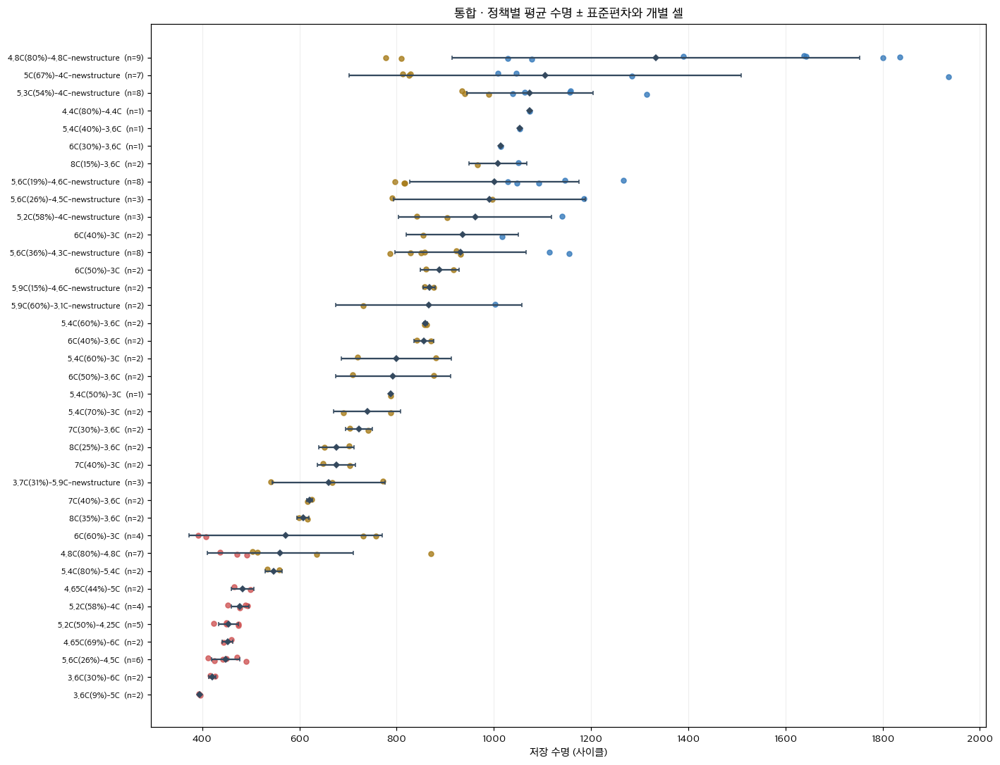

In [ ]:
fig,ax=plt.subplots(figsize=(13,max(8,len(q4_order)*.27)));rng=np.random.default_rng(42)
for i,policy in enumerate(q4_order):
    rows=q4_policies[policy];v=np.array([r['life'] for r in rows]);std=v.std(ddof=1) if len(v)>1 else 0
    ax.errorbar(v.mean(),i,xerr=std,fmt='D',color='#34495e',capsize=2,markersize=4,zorder=3)
    for r in rows:ax.scatter(r['life'],i+rng.uniform(-.12,.12),color=eda_colors[r['group']],s=21,alpha=.8)
ax.set_yticks(range(len(q4_order)),[f'{p}  (n={len(q4_policies[p])})' for p in q4_order],fontsize=8)
ax.set(xlabel='저장 수명 (사이클)',title='통합 · 정책별 평균 수명 ± 표준편차와 개별 셀');ax.grid(axis='x',alpha=.2)
fig.tight_layout();fig.savefig(eda_out/'scratch_q4_policy_life.png',dpi=130,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

충전 정책에 따라 관측 평균 수명이 다르며 같은 정책 안에서도 셀 간 차이가 있다. 따라서 정책은 수명 차이와 연관된 조건이지만 정책별 표본 수가 적고 다른 조건을 통제한 비교가 아니므로 평균 순위를 최적 정책의 확정 순위로 사용할 수는 없다. C1만 보지 않고 전환 SOC와 C2까지 함께 읽어야 같은 속도에서 다른 수명이 나타나는 결과를 이해할 수 있다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 정책별 평균 수명

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


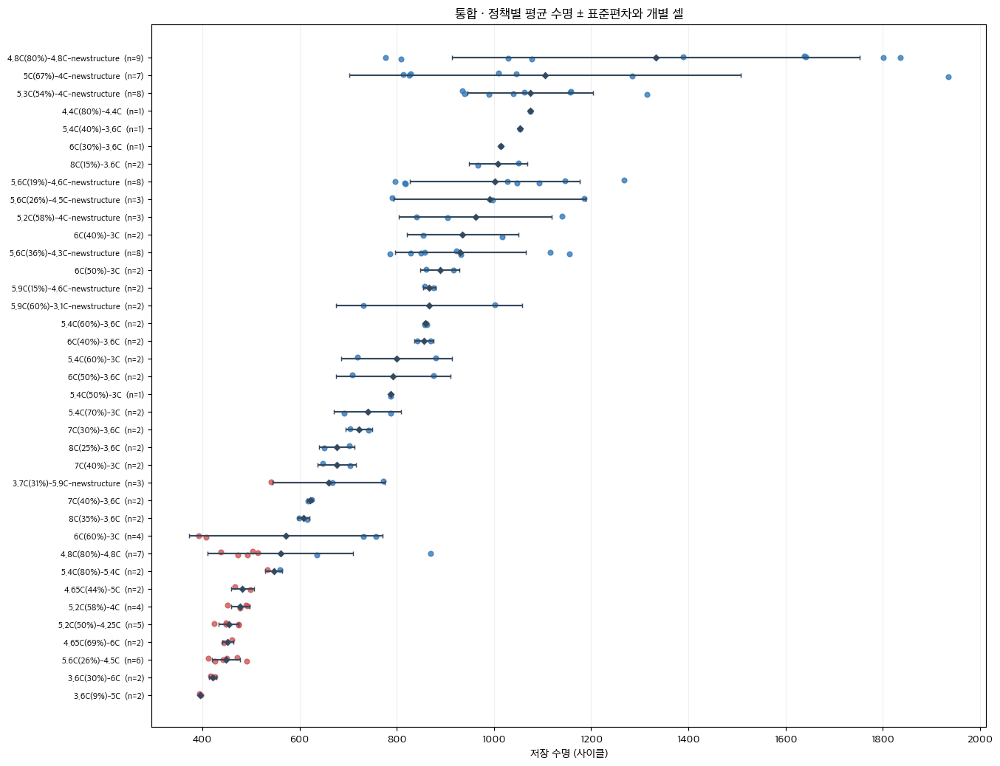

In [ ]:
fig,ax=plt.subplots(figsize=(13,max(8,len(b2_q4_order)*.27)));rng=np.random.default_rng(42)
for i,policy in enumerate(b2_q4_order):
    rows=b2_q4_policies[policy];v=np.array([r['life'] for r in rows]);std=v.std(ddof=1) if len(v)>1 else 0
    ax.errorbar(v.mean(),i,xerr=std,fmt='D',color='#34495e',capsize=2,markersize=4,zorder=3)
    for r in rows:ax.scatter(r['life'],i+rng.uniform(-.12,.12),color=b2_eda_colors[r['group']],s=21,alpha=.8)
ax.set_yticks(range(len(b2_q4_order)),[f'{p}  (n={len(b2_q4_policies[p])})' for p in b2_q4_order],fontsize=8)
ax.set(xlabel='저장 수명 (사이클)',title='통합 · 정책별 평균 수명 ± 표준편차와 개별 셀');ax.grid(axis='x',alpha=.2)
fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_q4_policy_life.png',dpi=130,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

충전 정책에 따라 관측 평균 수명이 다르며 같은 정책 안에서도 셀 간 차이가 있다. 따라서 정책은 수명 차이와 연관된 조건이지만 정책별 표본 수가 적고 다른 조건을 통제한 비교가 아니므로 평균 순위를 최적 정책의 확정 순위로 사용할 수는 없다. C1만 보지 않고 전환 SOC와 C2까지 함께 읽어야 같은 속도에서 다른 수명이 나타나는 결과를 이해할 수 있다.


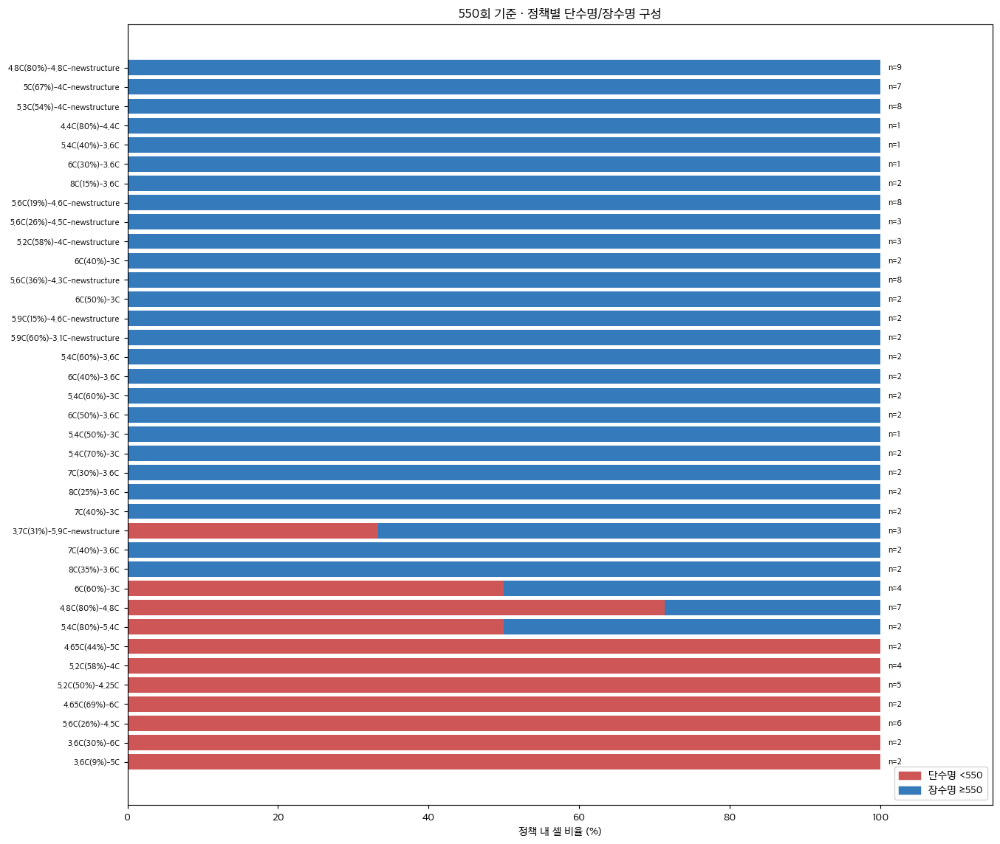

In [ ]:
fig,ax=plt.subplots(figsize=(13,11))
for i,policy in enumerate(b2_q4_order):
 rows=b2_q4_policies[policy];counts=np.bincount([r['group'] for r in rows],minlength=2);left=0
 for g in range(2):
  width=counts[g]/len(rows)*100
  ax.barh(i,width,left=left,color=b2_eda_colors[g]);left+=width
 ax.text(101,i,f'n={len(rows)}',va='center',fontsize=8)
ax.set_yticks(range(len(b2_q4_order)),b2_q4_order,fontsize=8);ax.set(xlim=(0,115),xlabel='정책 내 셀 비율 (%)',title='550회 기준 · 정책별 단수명/장수명 구성')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c,label=l) for c,l in zip(b2_eda_colors,b2_eda_group_names)],loc='lower right')
fig.tight_layout();fig.savefig(eda_out/'scratch_binary_policy_proportions.png',dpi=140,bbox_inches='tight');plt.show()


#### 그래프 결과 해석

정책별 두 그룹 구성은 평균만으로 가려지는 셀별 수명 차이를 보여준다. 다만 작은 표본의 정책에서 한 색이 100%를 차지하는 것은 관측된 몇 셀이 모두 같은 그룹이라는 뜻이다. 이를 새로운 셀에서도 같은 수명 그룹이 나올 확률이 100%라는 의미로 해석하지 않는다.


#### ①-추가. 같은 충전 속도에서도 수명이 다른가?

정책별 평균을 본 뒤 **충전 속도를 기준으로 다시 묶어**, 그 안의 수명 분포와 단·중·장 / 단·장 구성 비율을 함께 본다. 모든 셀을 통합하며 배치별로 나누지 않는다.

- **같은 C1:** 첫 단계 전류 설정이 정확히 같은 셀끼리 묶는다. Q1·C2는 다를 수 있으므로 전체 충전 과정이 동일하다는 뜻은 아니다.
- **비슷한 등가 C-rate:** 앞에서 계산한 0~80% SOC의 이상적 등가 속도를 **0.1C 단위로 반올림**하여 묶는다. 예를 들어 약 4.8C는 4.75 이상 4.85 미만이다. 정확히 같은 속도라는 뜻이 아니며, 각 묶음의 실제 범위도 x축 아래에 표시한다.
- 박스·평균은 각 속도 묶음의 모든 셀에서 계산한다. 같은 셀이므로 좌우 패널의 분포는 같고 수명 그룹 색상·비율만 바뀐다. n=1은 박스를 생략한다.


같은 첫 단계 전류 C1
3.6C: n=4, 평균 407.8, 중앙값 406.0, 범위 393~426회, 원래 정책 2개
3.7C: n=3, 평균 660.0, 중앙값 667.0, 범위 541~772회, 원래 정책 1개
4.4C: n=1, 평균 1074.0, 중앙값 1074.0, 범위 1074~1074회, 원래 정책 1개
4.65C: n=4, 평균 467.2, 중앙값 463.0, 범위 444~499회, 원래 정책 2개
4.8C: n=16, 평균 995.2, 중앙값 839.5, 범위 437~1836회, 원래 정책 2개
5C: n=7, 평균 1105.7, 중앙값 1009.0, 범위 813~1935회, 원래 정책 1개
5.2C: n=12, 평균 588.8, 중앙값 475.5, 범위 424~1140회, 원래 정책 3개
5.3C: n=8, 평균 1074.4, 중앙값 1051.0, 범위 935~1315회, 원래 정책 1개
5.4C: n=10, 평균 773.2, 중앙값 788.0, 범위 534~1054회, 원래 정책 6개
5.6C: n=25, 평균 844.9, 중앙값 850.0, 범위 412~1267회, 원래 정책 4개
5.9C: n=4, 평균 866.8, 중앙값 867.0, 범위 731~1002회, 원래 정책 2개
6C: n=13, 평균 788.2, 중앙값 854.0, 범위 392~1017회, 원래 정책 6개
7C: n=6, 평균 673.2, 중앙값 675.5, 범위 617~742회, 원래 정책 3개
8C: n=6, 평균 764.2, 중앙값 676.5, 범위 599~1051회, 원래 정책 3개
비슷한 등가 C-rate (0.1C 간격)
4C: n=4, 평균 972.0, 중앙값 991.5, 범위 854~1051회, 원래 정책 2개
4.2C: n=4, 평균 788.5, 중앙값 746.0, 범위 648~1014회, 원래 정책 3개
4.3C: n=3, 평균 802.3, 중앙값 702.0, 범위 651~1054회, 원래 정책 2개
4.4C: n=5, 평균 859.2, 중앙값 860

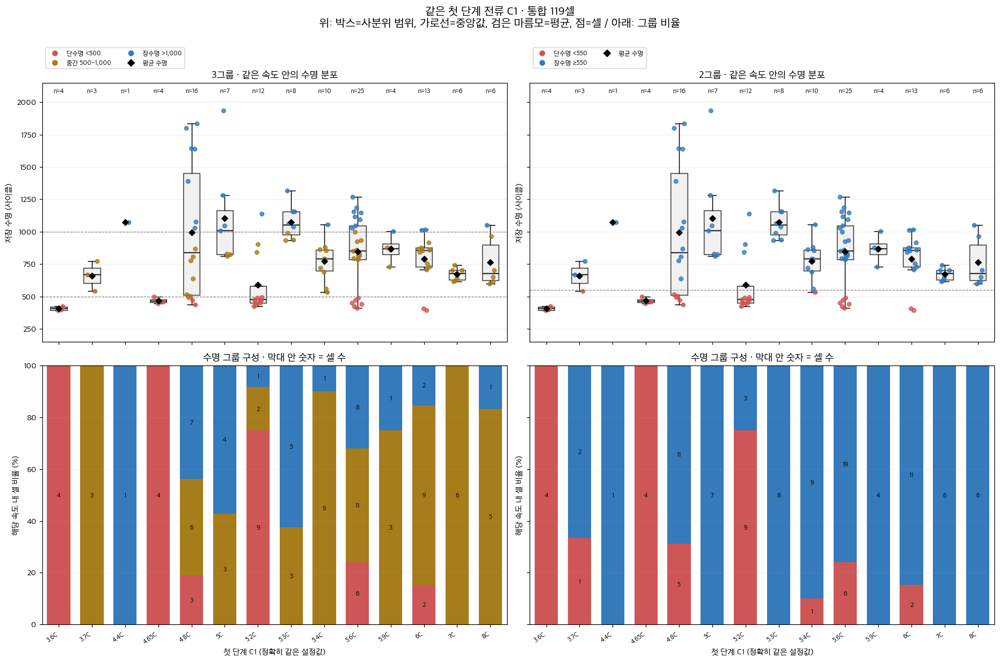

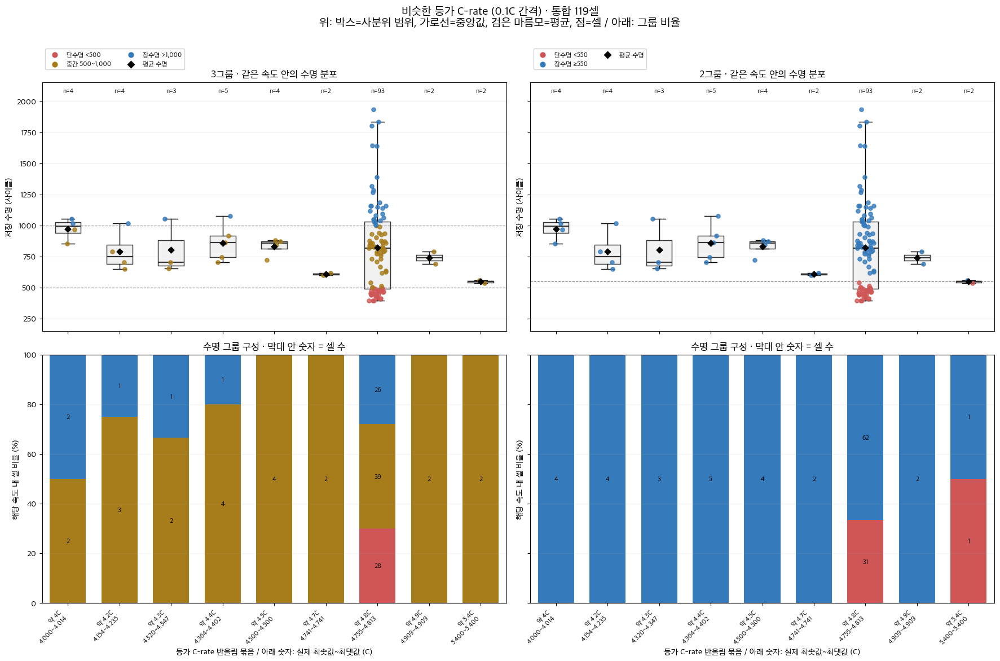

In [ ]:
# 같은 첫 단계 전류 / 비슷한 등가 속도 안에서 셀별 수명 비교
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
speed_root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'DAY1/results/scratch_q4_results.json').exists())
speed_out=speed_root/'DAY1/results'
# 위 Question 4를 실행한 경우 최신 계산값을 사용한다.
speed_rows=q4_rows if 'q4_rows' in globals() else json.loads((speed_out/'scratch_q4_results.json').read_text())['rows']
speed_definitions=[('c1','같은 첫 단계 전류 C1',lambda r:r['c1']),
                   ('equiv','비슷한 등가 C-rate (0.1C 간격)',lambda r:float(np.floor(r['equiv']*10+.5)/10))]
speed_schemes=[('3그룹',['단수명 <500','중간 500~1,000','장수명 >1,000'],['#cf5656','#a77c1a','#357abb'],lambda v:0 if v<500 else 1 if v<=1000 else 2),
               ('2그룹',['단수명 <550','장수명 ≥550'],['#cf5656','#357abb'],lambda v:int(v>=550))]
speed_stats={}
for key,title,bucket in speed_definitions:
    grouped={}
    for r in speed_rows:grouped.setdefault(bucket(r),[]).append(r)
    levels=sorted(grouped);fig,axes=plt.subplots(2,2,figsize=(17,11),sharex='col',sharey='row')
    speed_stats[key]=[]
    for level in levels:
        rows=grouped[level];life=np.array([r['life'] for r in rows])
        speed_stats[key].append(dict(speed=level,n=len(rows),mean=float(life.mean()),median=float(np.median(life)),minimum=float(life.min()),maximum=float(life.max()),actual_min=min(r[key] for r in rows),actual_max=max(r[key] for r in rows),policies=len(set(r['policy'] for r in rows))))
    for col,(scheme,names,colors,classify) in enumerate(speed_schemes):
        top,bottom=axes[:,col];rng=np.random.default_rng(42)
        for x,level in enumerate(levels):
            rows=grouped[level];v=np.array([r['life'] for r in rows]);groups=np.array([classify(z) for z in v])
            if len(v)>1:
                box=top.boxplot([v],positions=[x],widths=.5,patch_artist=True,showfliers=False)
                box['boxes'][0].set(facecolor='#eeeeee',alpha=.8)
                box['medians'][0].set(color='#333333',linewidth=1.5)
            jitter=rng.uniform(-.17,.17,len(v))
            for g,color in enumerate(colors):
                m=groups==g;top.scatter(x+jitter[m],v[m],color=color,s=24,alpha=.8,zorder=3)
            top.scatter(x,v.mean(),marker='D',s=27,color='black',zorder=4)
            top.text(x,.98,f'n={len(v)}',ha='center',va='top',transform=top.get_xaxis_transform(),fontsize=8)
            left=0
            for g,color in enumerate(colors):
                count=int((groups==g).sum());height=100*count/len(v)
                bottom.bar(x,height,bottom=left,color=color,width=.7,label=names[g] if x==0 else None)
                if count:bottom.text(x,left+height/2,str(count),ha='center',va='center',fontsize=8)
                left+=height
        for cut in ([500,1000] if col==0 else [550]):top.axhline(cut,color='gray',ls='--',lw=.8)
        top.set(title=scheme+' · 같은 속도 안의 수명 분포',ylabel='저장 수명 (사이클)',ylim=(150,2150));top.grid(axis='y',alpha=.2)
        handles=[Line2D([],[],color=c,marker='o',ls='',label=l) for c,l in zip(colors,names)]
        handles.append(Line2D([],[],color='black',marker='D',ls='',label='평균 수명'))
        top.legend(handles=handles,fontsize=8,loc='upper left',bbox_to_anchor=(0,1.15),ncol=2)
        labels=[f'{v:g}C' for v in levels]
        if key=='equiv':labels=[f"약 {r['speed']:g}C\n{r['actual_min']:.3f}~{r['actual_max']:.3f}" for r in speed_stats[key]]
        bottom.set_xticks(range(len(levels)),labels,rotation=35 if key=='c1' else 45,ha='right',fontsize=8)
        bottom.set(ylabel='해당 속도 내 셀 비율 (%)',ylim=(0,100),xlabel='첫 단계 C1 (정확히 같은 설정값)' if key=='c1' else '등가 C-rate 반올림 묶음 / 아래 숫자: 실제 최솟값~최댓값 (C)',title='수명 그룹 구성 · 막대 안 숫자 = 셀 수')
        bottom.grid(axis='y',alpha=.15)
    fig.suptitle(title+' · 통합 119셀\n위: 박스=사분위 범위, 가로선=중앙값, 검은 마름모=평균, 점=셀 / 아래: 그룹 비율',fontsize=14,y=1.01)
    fig.tight_layout();fig.savefig(speed_out/f'scratch_same_speed_{key}.png',dpi=140,bbox_inches='tight');plt.show()
    print(title)
    for r in speed_stats[key]:print(f"{r['speed']:g}C: n={r['n']}, 평균 {r['mean']:.1f}, 중앙값 {r['median']:.1f}, 범위 {r['minimum']:.0f}~{r['maximum']:.0f}회, 원래 정책 {r['policies']}개")
(speed_out/'scratch_same_speed_summary.json').write_text(json.dumps(speed_stats,ensure_ascii=False,indent=2))


#### 그래프 결과 해석

같은 C1에서도 수명 범위가 넓으므로 첫 충전 전류 하나로 수명을 설명하기 어렵다. C1이 같은 묶음에도 전환 SOC·C2·원래 정책 구분이 다를 수 있어, “같은 첫 전류”는 “같은 전체 실험 조건”과 구분해야 한다. 관측 결과는 고속 충전일수록 항상 단수명이라는 단순한 순서를 보여주지 않는다.

약 4.8C 묶음에 서로 다른 정책 22개와 폭넓은 수명이 포함되어 등가 C-rate만으로 정책별 수명 차이를 충분히 표현하기 어렵다. 등가값이 비슷해도 충전 구간의 전류 배분은 다를 수 있다. 따라서 등가 C-rate의 약한 수명 상관을 충전 조건 전체가 수명과 무관하다는 결론으로 확대하지 않는다.


#### 같은 속도별 비교 해석

**약 4.8C 묶음**은 93셀, 실제 등가 속도 4.755~4.813C이며, 수명은 **392~1935회**에 걸쳐 있다. 평균은 819.7회, 중앙값은 816.0회다. 이 묶음에는 원래 이름 기준 22개 정책이 포함된다.

따라서 **비슷한 설정 속도에서도 단수명과 장수명이 모두 나타난다.** 평균만으로는 가려지는 수명 편차를 박스와 셀별 점으로 확인할 수 있다. C1이 같아도 전환 SOC·두 번째 전류가 다르고, 등가 속도가 비슷해도 전류 패턴이 다를 수 있다. 실험 절차 차이도 남아 있어 이를 속도만의 효과로 해석하지 않는다.

막대의 비율은 현재 관측한 셀의 구성이다. 셀 수가 적은 속도에서 100%가 나오더라도 일반적인 장수명 확률로 확정하지 않는다. 0.1C 묶음은 시각화용이며 기존 연속 등가 C-rate 피처를 대체하지 않는다. 추가 피처를 늘린 것이 아니므로 기존 공선성 검토는 그대로 유지한다.


#### ② 설정 전류 패턴과 충전 속도

왼쪽 x축은 SOC(%)이며 시간축이 아니다. 80%까지의 **설정 전류**만 그린다. 실제 I(t)나 CV 구간을 그린 것이 아니다.
색은 해당 원래 정책의 평균 수명이다. 오른쪽은 셀별 등가 C-rate와 수명으로, 같은 속도 지표에서도 수명이 달라지는지 본다.

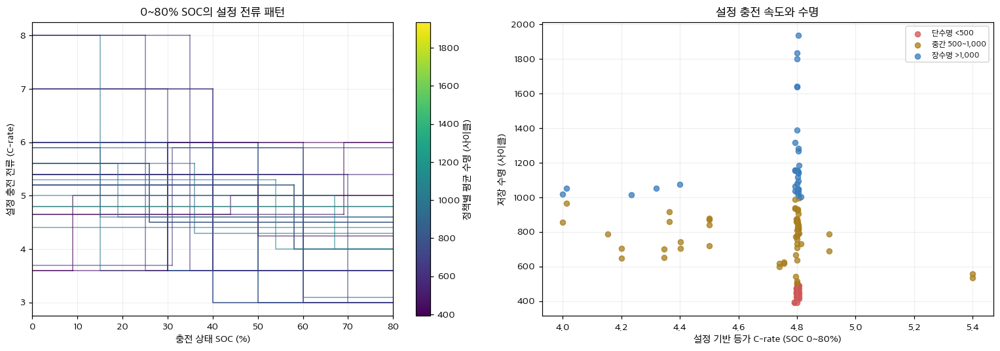

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
q4_norm=Normalize(min(r['life'] for r in q4_rows),max(r['life'] for r in q4_rows))
fig,axes=plt.subplots(1,2,figsize=(14,5))
for policy,rows in q4_policies.items():
    r=rows[0];color=plt.cm.viridis(q4_norm(np.mean([a['life'] for a in rows])))
    axes[0].plot([0,r['soc']],[r['c1'],r['c1']],color=color,alpha=.55,lw=1.2)
    if r['soc']<80:axes[0].plot([r['soc'],r['soc'],80],[r['c1'],r['c2'],r['c2']],color=color,alpha=.55,lw=1.2)
axes[0].set(xlabel='충전 상태 SOC (%)',ylabel='설정 충전 전류 (C-rate)',xlim=(0,80),title='0~80% SOC의 설정 전류 패턴')
fig.colorbar(ScalarMappable(norm=q4_norm,cmap='viridis'),ax=axes[0],label='정책별 평균 수명 (사이클)')
for g in range(3):
    rows=[r for r in q4_rows if r['group']==g]
    axes[1].scatter([r['equiv'] for r in rows],[r['life'] for r in rows],color=eda_colors[g],s=28,alpha=.75,label=eda_group_names[g])
axes[1].set(xlabel='설정 기반 등가 C-rate (SOC 0~80%)',ylabel='저장 수명 (사이클)',title='설정 충전 속도와 수명');axes[1].legend(fontsize=8)
for ax in axes:ax.grid(alpha=.2)
fig.tight_layout();fig.savefig(eda_out/'scratch_q4_current_patterns.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

전류 패턴을 하나의 등가값으로 압축하면 서로 다른 C1·전환 SOC·C2 조합이 겹칠 수 있다. 통합 표본에서 등가 C-rate와 수명의 순위 상관이 거의 0인 것은 이 요약값만으로 수명 순서를 잘 설명하지 못한다는 뜻이다. 충전 프로토콜의 모든 차이나 효과가 없다는 결과는 아니다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 설정 전류 패턴과 수명

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


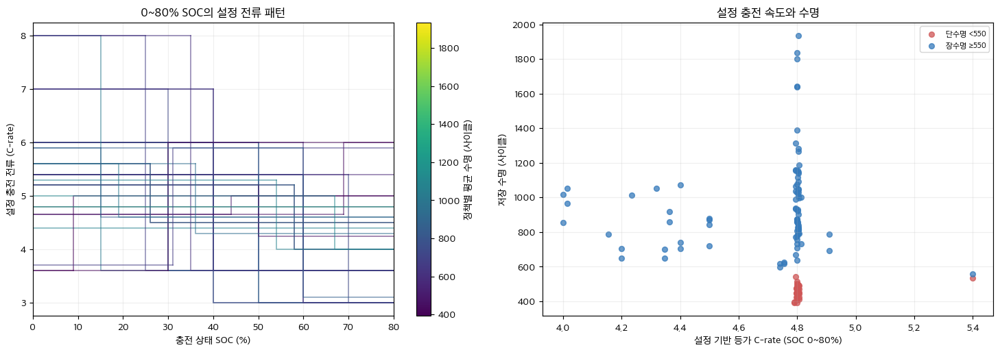

In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
b2_q4_norm=Normalize(min(r['life'] for r in b2_q4_rows),max(r['life'] for r in b2_q4_rows))
fig,axes=plt.subplots(1,2,figsize=(14,5))
for policy,rows in b2_q4_policies.items():
    r=rows[0];color=plt.cm.viridis(b2_q4_norm(np.mean([a['life'] for a in rows])))
    axes[0].plot([0,r['soc']],[r['c1'],r['c1']],color=color,alpha=.55,lw=1.2)
    if r['soc']<80:axes[0].plot([r['soc'],r['soc'],80],[r['c1'],r['c2'],r['c2']],color=color,alpha=.55,lw=1.2)
axes[0].set(xlabel='충전 상태 SOC (%)',ylabel='설정 충전 전류 (C-rate)',xlim=(0,80),title='0~80% SOC의 설정 전류 패턴')
fig.colorbar(ScalarMappable(norm=b2_q4_norm,cmap='viridis'),ax=axes[0],label='정책별 평균 수명 (사이클)')
for g in range(2):
    rows=[r for r in b2_q4_rows if r['group']==g]
    axes[1].scatter([r['equiv'] for r in rows],[r['life'] for r in rows],color=b2_eda_colors[g],s=28,alpha=.75,label=b2_eda_group_names[g])
axes[1].set(xlabel='설정 기반 등가 C-rate (SOC 0~80%)',ylabel='저장 수명 (사이클)',title='설정 충전 속도와 수명');axes[1].legend(fontsize=8)
for ax in axes:ax.grid(alpha=.2)
fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_q4_current_patterns.png',dpi=140,bbox_inches='tight');plt.show()

#### 그래프 결과 해석

전류 패턴을 하나의 등가값으로 압축하면 서로 다른 C1·전환 SOC·C2 조합이 겹칠 수 있다. 통합 표본에서 등가 C-rate와 수명의 순위 상관이 거의 0인 것은 이 요약값만으로 수명 순서를 잘 설명하지 못한다는 뜻이다. 충전 프로토콜의 모든 차이나 효과가 없다는 결과는 아니다.


#### ③ 전류 조건과 열화 속도의 관계

용량 감소 속도는 `−100 × Qd의 실제 사이클당 기울기`로 표시한다. 단위는 Ah/100사이클이며 **양수일수록 감소가 빠르고 음수는 용량 증가**다.
앞 질문 2의 “용량 변화 기울기”와 부호가 반대임에 주의한다.
초기 2~100회와 관측 말기 1/3을 따로 계산한다. 말기는 셀별 기록 길이에 따라 다르며 초기 예측용 피처가 아니다.
기울기 적합에는 앞 질문과 동일하게 Qd≤0 또는 >1.2 Ah인 점검값을 제외한다. 값 자체나 셀을 원본에서 삭제하지 않는다.

첫 전류 C1 {'수명': np.float64(0.077), '초기 용량 감소 속도': np.float64(0.133), '말기 용량 감소 속도': np.float64(0.0)}
전환 SOC Q1 {'수명': np.float64(0.085), '초기 용량 감소 속도': np.float64(-0.143), '말기 용량 감소 속도': np.float64(-0.028)}
실제 구간이 있는 C2 {'수명': np.float64(-0.131), '초기 용량 감소 속도': np.float64(0.177), '말기 용량 감소 속도': np.float64(-0.018)}
등가 C-rate {'수명': np.float64(-0.029), '초기 용량 감소 속도': np.float64(0.229), '말기 용량 감소 속도': np.float64(0.007)}
충전 조건끼리의 Spearman 상관 (순서: C1, Q1, 유효 C2, 등가 C):
[[ 1.    -0.496 -0.514 -0.174]
 [-0.496  1.    -0.477  0.089]
 [-0.514 -0.477  1.     0.401]
 [-0.174  0.089  0.401  1.   ]]
등가 C와 초기 평균 충전 시간 Spearman: (-0.5948141198029264, 119)


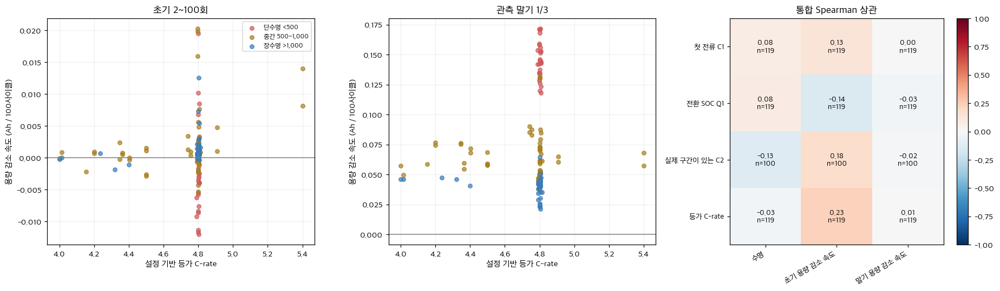

In [ ]:
q4_condition_keys=['c1','soc','c2_active','equiv']
q4_condition_names=['첫 전류 C1','전환 SOC Q1','실제 구간이 있는 C2','등가 C-rate']
q4_target_keys=['life','early_rate','late_rate'];q4_target_names=['수명','초기 용량 감소 속도','말기 용량 감소 속도']
def q4_rank(a):return np.array([np.sum(a<v)+(np.sum(a==v)-1)/2 for v in a],float)
def q4_corr(a,b):
    a=np.array(a);b=np.array(b);m=np.isfinite(a)&np.isfinite(b);a=a[m];b=b[m]
    return (float(np.corrcoef(q4_rank(a),q4_rank(b))[0,1]) if len(a)>=3 and np.std(a)>0 and np.std(b)>0 else np.nan),int(m.sum())
q4_corrs=np.zeros((4,3));q4_ns=np.zeros((4,3),int)
for i,k in enumerate(q4_condition_keys):
    for j,t in enumerate(q4_target_keys):q4_corrs[i,j],q4_ns[i,j]=q4_corr([r[k] for r in q4_rows],[r[t] for r in q4_rows])
fig,axes=plt.subplots(1,3,figsize=(17,5))
for j,key in enumerate(['early_rate','late_rate']):
    for g in range(3):
        rows=[r for r in q4_rows if r['group']==g]
        axes[j].scatter([r['equiv'] for r in rows],[r[key] for r in rows],color=eda_colors[g],alpha=.7,s=24,label=eda_group_names[g])
    axes[j].set(xlabel='設定 기반 등가 C-rate'.replace('設定','설정'),ylabel='용량 감소 속도 (Ah / 100사이클)',title=['초기 2~100회','관측 말기 1/3'][j]);axes[j].axhline(0,color='gray',lw=1);axes[j].grid(alpha=.2)
axes[0].legend(fontsize=8)
im=axes[2].imshow(q4_corrs,vmin=-1,vmax=1,cmap='RdBu_r',aspect='auto')
axes[2].set_xticks(range(3),q4_target_names,rotation=30,ha='right',fontsize=9);axes[2].set_yticks(range(4),q4_condition_names,fontsize=9)
for i in range(4):
    for j in range(3):axes[2].text(j,i,f'{q4_corrs[i,j]:.2f}\nn={q4_ns[i,j]}',ha='center',va='center',fontsize=9,color='white' if abs(q4_corrs[i,j])>.6 else 'black')
axes[2].set_title('통합 Spearman 상관');fig.colorbar(im,ax=axes[2]);fig.tight_layout();fig.savefig(eda_out/'scratch_q4_rate_relationships.png',dpi=140,bbox_inches='tight');plt.show()
for i,label in enumerate(q4_condition_names):print(label,dict(zip(q4_target_names,np.round(q4_corrs[i],3))))
q4_pair=np.array([[q4_corr([r[a] for r in q4_rows],[r[b] for r in q4_rows])[0] for b in q4_condition_keys] for a in q4_condition_keys])
print('충전 조건끼리의 Spearman 상관 (순서: C1, Q1, 유효 C2, 등가 C):');print(np.round(q4_pair,3))
q4_timecorr=q4_corr([r['equiv'] for r in q4_rows],[np.mean(eda_batches[r['cell'].split(' / ')[0]]['series'][int(r['cell'].split('셀 ')[1])]['chargetime'][(eda_batches[r['cell'].split(' / ')[0]]['series'][int(r['cell'].split('셀 ')[1])]['cycle']>=2)&(eda_batches[r['cell'].split(' / ')[0]]['series'][int(r['cell'].split('셀 ')[1])]['cycle']<=6)]) for r in q4_rows])
print('등가 C와 초기 평균 충전 시간 Spearman:',q4_timecorr)
(eda_out/'scratch_q4_results.json').write_text(json.dumps(dict(rows=q4_rows,correlations=q4_corrs.tolist(),n=q4_ns.tolist(),condition_correlation=q4_pair.tolist(),time_correlation=q4_timecorr,policy_count=len(q4_policies)),ensure_ascii=False,indent=2))

#### 그래프 결과 해석

설정 등가 C-rate는 초기 감소 속도와 약한 양의 상관이 있지만 말기 감소 속도와의 상관은 거의 없다. 그러므로 충전 속도가 초기·말기 열화 속도를 모두 일관되게 설명한다고 정리하기 어렵다. 충전 시간과 등가 C-rate가 서로 연관되어 있다는 결과는 두 지표의 정보 중복 가능성도 함께 보여준다.


#### 병렬 비교 · 수명 550회 기준 2그룹 — 충전 조건과 열화 속도

통합 119셀을 **단수명 <550회 / 장수명 ≥550회**로 나누어 비교한다. 위의 3그룹 결과와 함께, 그룹 구분에 따라 피처의 분포와 관계가 어떻게 달라지는지 확인한다.


첫 전류 C1 {'수명': np.float64(0.077), '초기 용량 감소 속도': np.float64(0.133), '말기 용량 감소 속도': np.float64(0.0)}
전환 SOC Q1 {'수명': np.float64(0.085), '초기 용량 감소 속도': np.float64(-0.143), '말기 용량 감소 속도': np.float64(-0.028)}
실제 구간이 있는 C2 {'수명': np.float64(-0.131), '초기 용량 감소 속도': np.float64(0.177), '말기 용량 감소 속도': np.float64(-0.018)}
등가 C-rate {'수명': np.float64(-0.029), '초기 용량 감소 속도': np.float64(0.229), '말기 용량 감소 속도': np.float64(0.007)}
충전 조건끼리의 Spearman 상관 (순서: C1, Q1, 유효 C2, 등가 C):
[[ 1.    -0.496 -0.514 -0.174]
 [-0.496  1.    -0.477  0.089]
 [-0.514 -0.477  1.     0.401]
 [-0.174  0.089  0.401  1.   ]]
등가 C와 초기 평균 충전 시간 Spearman: (-0.5948141198029264, 119)


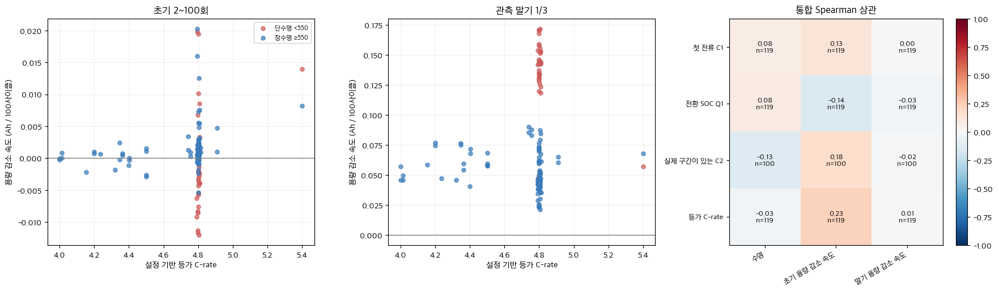

In [ ]:
b2_q4_condition_keys=['c1','soc','c2_active','equiv']
b2_q4_condition_names=['첫 전류 C1','전환 SOC Q1','실제 구간이 있는 C2','등가 C-rate']
b2_q4_target_keys=['life','early_rate','late_rate'];b2_q4_target_names=['수명','초기 용량 감소 속도','말기 용량 감소 속도']
def b2_q4_rank(a):return np.array([np.sum(a<v)+(np.sum(a==v)-1)/2 for v in a],float)
def b2_q4_corr(a,b):
    a=np.array(a);b=np.array(b);m=np.isfinite(a)&np.isfinite(b);a=a[m];b=b[m]
    return (float(np.corrcoef(b2_q4_rank(a),b2_q4_rank(b))[0,1]) if len(a)>=3 and np.std(a)>0 and np.std(b)>0 else np.nan),int(m.sum())
b2_q4_corrs=np.zeros((4,3));b2_q4_ns=np.zeros((4,3),int)
for i,k in enumerate(b2_q4_condition_keys):
    for j,t in enumerate(b2_q4_target_keys):b2_q4_corrs[i,j],b2_q4_ns[i,j]=b2_q4_corr([r[k] for r in b2_q4_rows],[r[t] for r in b2_q4_rows])
fig,axes=plt.subplots(1,3,figsize=(17,5))
for j,key in enumerate(['early_rate','late_rate']):
    for g in range(2):
        rows=[r for r in b2_q4_rows if r['group']==g]
        axes[j].scatter([r['equiv'] for r in rows],[r[key] for r in rows],color=b2_eda_colors[g],alpha=.7,s=24,label=b2_eda_group_names[g])
    axes[j].set(xlabel='設定 기반 등가 C-rate'.replace('設定','설정'),ylabel='용량 감소 속도 (Ah / 100사이클)',title=['초기 2~100회','관측 말기 1/3'][j]);axes[j].axhline(0,color='gray',lw=1);axes[j].grid(alpha=.2)
axes[0].legend(fontsize=8)
im=axes[2].imshow(b2_q4_corrs,vmin=-1,vmax=1,cmap='RdBu_r',aspect='auto')
axes[2].set_xticks(range(3),b2_q4_target_names,rotation=30,ha='right',fontsize=9);axes[2].set_yticks(range(4),b2_q4_condition_names,fontsize=9)
for i in range(4):
    for j in range(3):axes[2].text(j,i,f'{b2_q4_corrs[i,j]:.2f}\nn={b2_q4_ns[i,j]}',ha='center',va='center',fontsize=9,color='white' if abs(b2_q4_corrs[i,j])>.6 else 'black')
axes[2].set_title('통합 Spearman 상관');fig.colorbar(im,ax=axes[2]);fig.tight_layout();fig.savefig(b2_eda_out/'scratch_binary_q4_rate_relationships.png',dpi=140,bbox_inches='tight');plt.show()
for i,label in enumerate(b2_q4_condition_names):print(label,dict(zip(b2_q4_target_names,np.round(b2_q4_corrs[i],3))))
b2_q4_pair=np.array([[b2_q4_corr([r[a] for r in b2_q4_rows],[r[b] for r in b2_q4_rows])[0] for b in b2_q4_condition_keys] for a in b2_q4_condition_keys])
print('충전 조건끼리의 Spearman 상관 (순서: C1, Q1, 유효 C2, 등가 C):');print(np.round(b2_q4_pair,3))
b2_q4_timecorr=b2_q4_corr([r['equiv'] for r in b2_q4_rows],[np.mean(b2_eda_batches[r['cell'].split(' / ')[0]]['series'][int(r['cell'].split('셀 ')[1])]['chargetime'][(b2_eda_batches[r['cell'].split(' / ')[0]]['series'][int(r['cell'].split('셀 ')[1])]['cycle']>=2)&(b2_eda_batches[r['cell'].split(' / ')[0]]['series'][int(r['cell'].split('셀 ')[1])]['cycle']<=6)]) for r in b2_q4_rows])
print('등가 C와 초기 평균 충전 시간 Spearman:',b2_q4_timecorr)
(b2_eda_out/'scratch_binary_q4_results.json').write_text(json.dumps(dict(rows=b2_q4_rows,correlations=b2_q4_corrs.tolist(),n=b2_q4_ns.tolist(),condition_correlation=b2_q4_pair.tolist(),time_correlation=b2_q4_timecorr,policy_count=len(b2_q4_policies)),ensure_ascii=False,indent=2))

#### 그래프 결과 해석

설정 등가 C-rate는 초기 감소 속도와 약한 양의 상관이 있지만 말기 감소 속도와의 상관은 거의 없다. 그러므로 충전 속도가 초기·말기 열화 속도를 모두 일관되게 설명한다고 정리하기 어렵다. 충전 시간과 등가 C-rate가 서로 연관되어 있다는 결과는 두 지표의 정보 중복 가능성도 함께 보여준다.


#### 관찰 해석 — 충전 속도가 빠르면 반드시 수명이 짧을까?

**통합 119셀, 원래 정책 이름 기준 37개 프로토콜을 비교했다.** 아래 수치는 현재 선별된 셀의 관측 결과이며, 정책의 인과 효과나 최적 조건을 확정한 결과가 아니다.

| 질문 | 이번 통합 데이터에서 확인한 결과 | 해석 |
|---|---|---|
| 프로토콜별 평균 수명이 다른가? | 정책별 평균 수명은 약 394.5~1,333.3회, 정책당 1~9셀이다. | 차이는 있지만 표본 수와 셀 간 편차를 함께 봐야 한다. |
| 첫 전류 C1이 높을수록 수명이 짧은가? | 수명과의 Spearman 상관은 +0.077이다. | 첫 전류 하나로 수명을 설명하기 어렵다. |
| 등가 C-rate가 높을수록 수명이 짧은가? | 수명과의 상관은 −0.029이다. | 전체 자료에서 뚜렷한 단조 관계를 확인하지 못했다. 충전 조건의 영향이 없다는 뜻은 아니다. |
| 충전 속도와 용량 감소 속도는 관련되는가? | 등가 C-rate와 초기 감소 속도는 +0.229, 말기 감소 속도는 +0.007이다. | 초기에는 약한 양의 관계가 있으나 말기에는 단순한 관계가 보이지 않는다. |

**같은 첫 전류여도 ‘언제 낮추는가’가 다르다.** 다음 세 정책은 C1=8C, C2=3.6C가 같고 전환 SOC가 다르다.

| 충전 정책 | 전류 전환 시점 | 평균 수명 ± 셀 간 표준편차 | 셀 수 |
|---|---|---:|---:|
| 8C(15%)-3.6C | SOC 15%에서 전류를 낮춤 | 1,008.5 ± 60.1회 | 2 |
| 8C(25%)-3.6C | SOC 25%에서 전류를 낮춤 | 676.5 ± 36.1회 | 2 |
| 8C(35%)-3.6C | SOC 35%에서 전류를 낮춤 | 607.5 ± 12.0회 | 2 |

이 부분집합에서는 8C 구간이 길수록 평균 수명이 짧았다. **C1뿐 아니라 C2와 전환 SOC를 함께 검토할 근거**가 된다. 다만 각 2셀의 비교이므로 일반적인 법칙이나 원인으로 확정하지 않는다.

**약 4.8C 부근에 셀이 몰리면서 수명은 넓게 퍼진다.** 같은 등가 속도로 요약되더라도 서로 다른 전류 패턴이 포함된다. 등가 속도는 패턴을 하나의 수로 압축하므로 정보를 잃는다. 또한 같은 숫자 정책인 `4.8C(80%)-4.8C`도 원래 이름에 `newstructure`가 없는 경우 평균 560.6회(n=7), 있는 경우 1,333.3회(n=9)였다. 접미사의 의미를 확인하지 않은 상태에서 이 차이를 전류 설정의 효과로 설명하면 안 된다. 통합 그래프는 유지하되 실험 절차·기록 조건이 섞였을 가능성을 고려한다.

#### 피처 선정에 연결 — 공선성과 중복 정보

| 후보 | 표현하는 정보 | 이번 단계의 선택 방향 |
|---|---|---|
| C1·전환 SOC·C2 | 설정 전류 패턴 | 패턴을 자세히 볼 때 함께 검토하되, C2 구간이 없는 SOC 80% 정책은 구분한다. |
| 등가 C-rate | 0~80% SOC의 이상적 충전 속도 | 단순한 조건 요약 후보. 위 세 값으로 계산되므로 네 변수를 무조건 동시에 추가하지 않는다. |
| 초기 충전 시간 | 실제 기록된 초기 충전 소요 시간 | 등가 C-rate와 Spearman −0.595로 정보가 일부 겹친다. 둘을 함께 쓸 필요가 있는지 기존 피처와 함께 상관·VIF로 검토한다. |
| 초기 용량 감소 속도 | 초기의 관측된 용량 변화 | 충전 설정과는 다른 반응 지표. 초기 용량 변화량과 중복되는지 확인한다. |
| 말기 용량 감소 속도 | 열화가 진행된 뒤의 결과 | 이번 EDA의 설명용 지표로 사용한다. |

조건 변수 사이의 쌍별 상관만으로 공선성이 없다고 판단하지 않는다. 특히 등가 C-rate는 C1·전환 SOC·C2의 **비선형 계산값**이므로 쌍별 상관이나 선형 VIF가 낮아도 정보 중복이 남을 수 있다. 현재는 설정 패턴 세 변수와 등가 속도 하나를 서로 다른 표현 후보로 비교하는 것이 적절하다.

#### Question 4 정리

> 충전 프로토콜에 따라 평균 수명 차이가 관찰되었으나, 통합 데이터에서는 첫 전류나 등가 C-rate 하나와 수명 사이에 뚜렷한 단조 관계가 나타나지 않았다. 일부 조건에서는 높은 전류를 적용하는 SOC 구간이 길수록 수명이 짧았으므로, 충전 속도뿐 아니라 전류 전환 패턴을 함께 검토할 필요가 있다. 다만 정책별 표본 수가 적고 같은 숫자 설정에서도 수명 차이가 커서, 충전 조건만으로 단수명의 원인이나 특정 화학적 열화 기전을 확정할 수 없다.


#### 2그룹 추가 해석 — 위의 3그룹 해석과 함께 읽기

정책별 평균 수명과 표준편차는 같은 셀을 사용하므로 기존 3그룹 결과와 같다. 새로 달라지는 것은 셀 색상 및 **정책 안의 단수명/장수명 비율**이다. 정책 평균이 550회를 넘더라도 그 정책의 모든 셀이 장수명인 것은 아니다.

|550회 기준 그룹|셀 수|등가 C-rate 중앙값|초기 용량 감소 속도 중앙값|말기 용량 감소 속도 중앙값|
|---|---:|---:|---:|---:|
|단수명 <550|32|4.800|-0.00298|0.14256|
|장수명 ≥550|87|4.800|0.00077|0.05071|

감소 속도 단위는 Ah/100사이클, 양수일수록 감소가 빠르다. 전체 등가 C-rate와 연속 수명의 Spearman은 기존과 같은 −0.029이다. 그룹을 나누는 것만으로 상관이나 인과 근거가 강화되지 않는다. 정책별 표본 수가 1~9셀로 작아 0%·100% 비율도 일반적인 확률로 해석하지 않는다. C1·Q1·C2와 이들로 계산한 등가 C-rate의 정보 중복에 대한 검토도 그대로 적용한다.

### 5-10. Question 5 — 초기의 어떤 신호가 수명과 연관되는가?

**앞 결과에서 이어지는 질문**

앞 분석들에서 여러 초기 지표와 말기 지표의 차이를 확인했다. 그러나 말기에 뚜렷한 지표가 초기에도 유용한지, 강한 피처들이 같은 정보를 반복하는지는 별도 질문이다. 그래서 이 절은 **초기 수명 상관 → 관계 형태 → 저항의 측정 시점 구분 → 공선성**을 점검한다.

앞의 충전 조건 비교에 이어 **초기 피처 정의 → 연속 수명과의 상관 → 3그룹·2그룹 비교 → 피처 간 상관·VIF** 순서로 정리한다. 세 배치를 합친 동일한 119셀을 사용하며, 앞서 계산한 셀별 피처를 재사용한다.

여기서는 초기 100회까지의 EDA를 수행한다. 2그룹 색상을 사용해도 초기 5회 분류 입력으로 바뀌는 것은 아니다. 수명으로 만든 그룹 라벨은 입력 피처에 포함하지 않는다.

|피처|관측 구간·계산|의미|
|---|---|---|
|ΔQ log 분산|Q100(V)−Q10(V)의 전압점별 분산에 log10|방전곡선 변화가 전압에 따라 얼마나 달라지는가|
|ΔQ 평균·최솟값|같은 ΔQ(V)의 평균·최솟값|곡선 변화의 수준·가장 큰 음의 변화|
|방전 용량 기울기|2~100회 Qd 선형 적합, Ah/100회|음수일수록 초기 용량 감소가 빠름|
|방전 용량 변화량|QD100−QD2, Ah|초기 구간 양 끝의 용량 차이|
|평균 온도|2~100회 Tavg 평균, °C|초기 셀 표면 온도 수준|
|최고 온도|2~100회 Tmax 중 최댓값, °C|초기 구간의 가장 높은 측정 온도|
|내부저항 변화량|IR100−IR2, mΩ|초기 저항 변화|
|초기 평균 충전 시간|2~6회 평균, 분|초기 충전 소요 시간|
|설정 기반 등가 C-rate|C1·Q1·C2에서 계산|0~80% SOC의 이상적 충전 속도|

첫 빈 사이클·불완전 라벨 처리 및 용량 기울기 점검값 제외 기준은 앞의 분석과 동일하다. 온도는 연관성 비교에 포함하되 열화 원인으로 확정하지 않는다.


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
q5_root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'DAY1/results/scratch_feature_review.json').exists())
q5_out=q5_root/'DAY1/results'
q5_saved=json.loads((q5_out/'scratch_feature_review.json').read_text())
q5_rows=fr_rows if 'fr_rows' in globals() else q5_saved['rows']
q5_keys=q5_saved['keys']
q5_names=['ΔQ log 분산','ΔQ 평균','ΔQ 최솟값','방전 용량 기울기','방전 용량 변화량','평균 온도','최고 온도','내부저항 변화량','초기 평균 충전 시간','설정 등가 C-rate']
q5_units=['log10[Var(ΔQ / 1 Ah)]','Ah','Ah','Ah/100회','Ah','°C','°C','mΩ','분','C']
q5_X=np.array([r['values'] for r in q5_rows],float);q5_y=np.array([r['life'] for r in q5_rows],float)
q5_X[:,3]*=100;q5_X[:,7]*=1000 # 표시 단위 변환: 상관계수·VIF는 변하지 않음
assert len(q5_rows)==119 and len({(r['batch'],r['cell_id']) for r in q5_rows})==119
assert q5_X.shape==(119,10) and np.isfinite(q5_y).all()
def q5_rank(x):return np.array([np.sum(x<v)+(np.sum(x==v)-1)/2 for v in x],float)
def q5_corr(x,y,rank=False):
    ok=np.isfinite(x)&np.isfinite(y);a=x[ok];b=y[ok]
    if len(a)<3 or np.std(a)==0 or np.std(b)==0:return np.nan,int(ok.sum())
    if rank:a,b=q5_rank(a),q5_rank(b)
    return float(np.corrcoef(a,b)[0,1]),int(ok.sum())
q5_pearson=np.array([q5_corr(q5_X[:,j],q5_y)[0] for j in range(10)])
q5_spearman=np.array([q5_corr(q5_X[:,j],q5_y,True)[0] for j in range(10)])
q5_counts=np.array([q5_corr(q5_X[:,j],q5_y)[1] for j in range(10)])
q5_order=np.argsort(np.abs(q5_spearman))
print('피처 | Pearson | Spearman | 사용 셀 수')
for j in q5_order[::-1]:print(q5_names[j],round(q5_pearson[j],3),round(q5_spearman[j],3),q5_counts[j],sep=' | ')


피처 | Pearson | Spearman | 사용 셀 수
ΔQ log 분산 | -0.857 | -0.888 | 119
ΔQ 최솟값 | 0.818 | 0.876 | 119
ΔQ 평균 | 0.786 | 0.861 | 119
평균 온도 | 0.351 | 0.325 | 119
초기 평균 충전 시간 | 0.223 | -0.221 | 119
방전 용량 기울기 | -0.115 | -0.219 | 119
방전 용량 변화량 | -0.027 | -0.176 | 119
설정 등가 C-rate | -0.096 | -0.029 | 119
최고 온도 | -0.006 | 0.023 | 119
내부저항 변화량 | 0.164 | -0.001 | 119


#### ① 초기 피처와 Cycle Life의 상관계수

**Pearson**은 선형 관계, **Spearman**은 순위에 따른 단조 관계를 본다. 두 값의 차이가 크면 산점도로 비선형성·극단값을 함께 확인한다. 큰 절댓값은 강한 연관성을 뜻하며 원인이나 모델 중요도를 뜻하지 않는다. n은 각 계산에 실제 사용한 셀 수다.


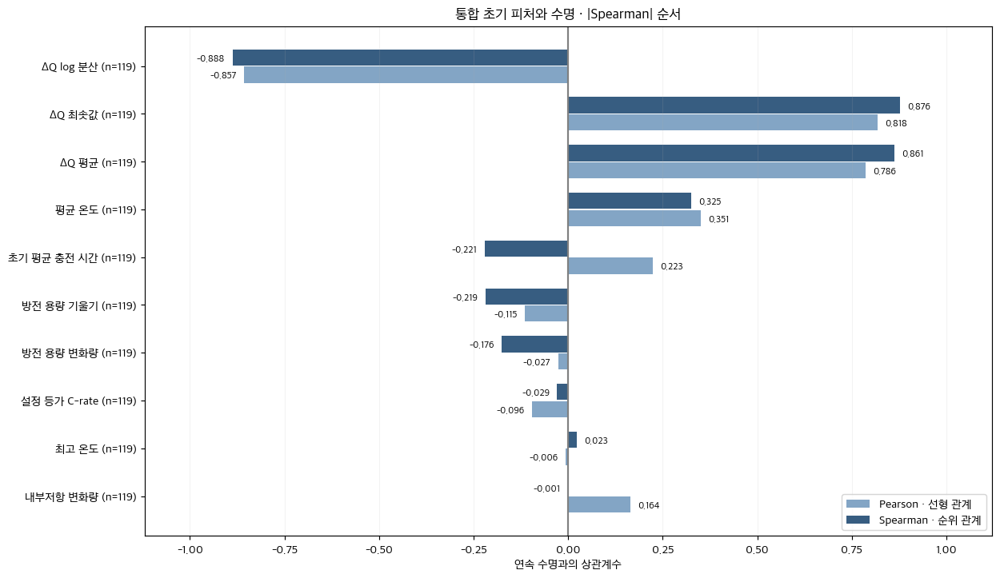

In [ ]:
fig,ax=plt.subplots(figsize=(12,7));pos=np.arange(10)
ax.barh(pos-.18,q5_pearson[q5_order],height=.34,label='Pearson · 선형 관계',color='#83a5c5')
ax.barh(pos+.18,q5_spearman[q5_order],height=.34,label='Spearman · 순위 관계',color='#375d81')
for k,j in enumerate(q5_order):
 for v,offset in [(q5_pearson[j],-.18),(q5_spearman[j],.18)]:ax.text(v+(.02 if v>=0 else -.02),k+offset,f'{v:.3f}',ha='left' if v>=0 else 'right',va='center',fontsize=8)
ax.set_yticks(pos,[f'{q5_names[j]} (n={q5_counts[j]})' for j in q5_order]);ax.axvline(0,color='gray');ax.set(xlim=(-1.12,1.12),xlabel='연속 수명과의 상관계수',title='통합 초기 피처와 수명 · |Spearman| 순서');ax.legend(loc='lower right');ax.grid(axis='x',alpha=.15)
fig.tight_layout();fig.savefig(q5_out/'scratch_q5_life_correlations.png',dpi=140,bbox_inches='tight');plt.show()


#### 그래프 결과 해석

ΔQ 통계는 Pearson과 Spearman 모두에서 강한 관계를 보이는 반면, 충전 시간은 두 계수의 부호가 달라 관계를 한 방향으로 요약하기 어렵다. 평균 온도의 양의 상관도 온도를 높이면 수명이 늘어난다는 뜻은 아니다. 상관의 크기·방향·측정 구간을 함께 읽어야 하며 상관만으로 화학적 원인을 결정할 수는 없다.


#### ② 관계가 강한 피처 — 3그룹과 2그룹을 병렬 비교

|Spearman| 상위 3개 피처를 표시한다. 위아래는 같은 셀의 동일한 x·y 값이며 색으로 구분하는 기준만 다르다. 연속 수명과의 상관은 두 패널에서 같다. 2그룹 라벨(단=0, 장=1)과의 **점이연 상관**은 표로 별도 출력한다. 3그룹을 0·1·2로 부호화해 임의의 간격을 가정하지 않는다.


피처 | 550회 기준 장수명=1과 점이연 상관
ΔQ log 분산 | -0.72
ΔQ 최솟값 | 0.763
ΔQ 평균 | 0.75
평균 온도 | 0.291
초기 평균 충전 시간 | 0.216
방전 용량 기울기 | -0.215
방전 용량 변화량 | -0.037
설정 등가 C-rate | -0.257
최고 온도 | 0.002
내부저항 변화량 | 0.23


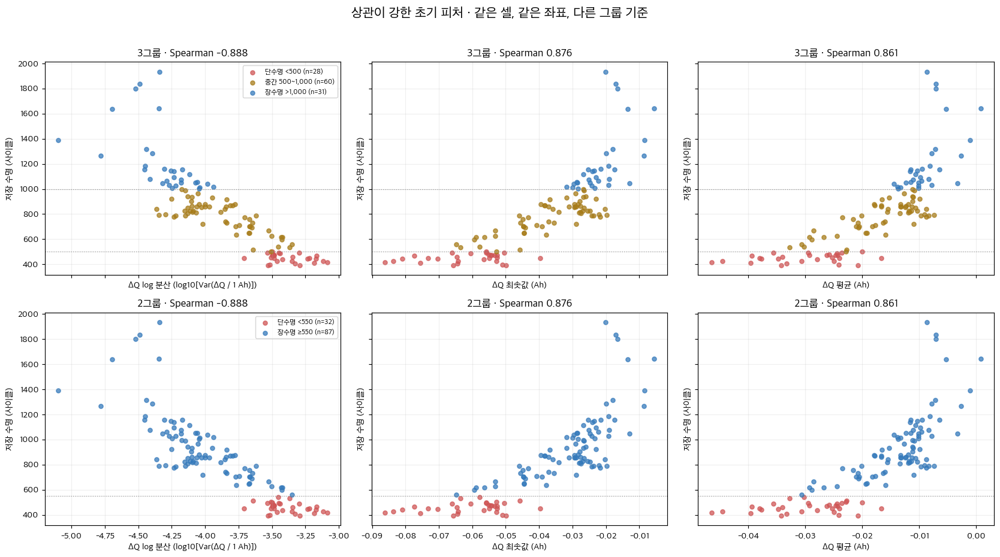

In [ ]:
q5_top=q5_order[-3:][::-1]
q5_schemes=[('3그룹',np.where(q5_y<500,0,np.where(q5_y<=1000,1,2)),['단수명 <500','중간 500~1,000','장수명 >1,000'],['#cf5656','#a77c1a','#357abb']),('2그룹',(q5_y>=550).astype(int),['단수명 <550','장수명 ≥550'],['#cf5656','#357abb'])]
fig,axes=plt.subplots(2,3,figsize=(16,9),sharex='col',sharey=True)
for row,(scheme,groups,names,colors) in enumerate(q5_schemes):
 for col,j in enumerate(q5_top):
  ax=axes[row,col]
  for g,(name,color) in enumerate(zip(names,colors)):
   m=groups==g;ax.scatter(q5_X[m,j],q5_y[m],color=color,s=24,alpha=.75,label=f'{name} (n={m.sum()})')
  for cut in ([500,1000] if row==0 else [550]):ax.axhline(cut,color='gray',ls=':',lw=.8)
  ax.set(xlabel=f'{q5_names[j]} ({q5_units[j]})',ylabel='저장 수명 (사이클)',title=f'{scheme} · Spearman {q5_spearman[j]:.3f}');ax.grid(alpha=.2)
 axes[row,0].legend(fontsize=8)
fig.suptitle('상관이 강한 초기 피처 · 같은 셀, 같은 좌표, 다른 그룹 기준',fontsize=15);fig.tight_layout(rect=(0,0,1,.96));fig.savefig(q5_out/'scratch_q5_top_features.png',dpi=140,bbox_inches='tight');plt.show()
q5_binary=np.array([q5_corr(q5_X[:,j],(q5_y>=550).astype(float))[0] for j in range(10)])
print('피처 | 550회 기준 장수명=1과 점이연 상관')
for j in q5_order[::-1]:print(q5_names[j],round(q5_binary[j],3),sep=' | ')


#### 그래프 결과 해석

상위 세 피처는 모두 ΔQ 곡선의 변화를 나타내며 수명이 길어질수록 변화가 작아지는 방향이 일관된다. 동시에 이들끼리의 상관도 매우 높으므로 상위 세 개를 모두 독립적인 핵심 요인으로 표현하면 같은 신호를 반복해서 강조하게 된다. 여기서 확인된 핵심은 초기 방전곡선 변화와 수명 사이의 연관성이다.


#### ②-추가. 내부저항도 별도로 확인하기

아래는 초기 2→100회 변화와 수명의 관계다. 앞서 관측한 말기 저항 증가와 측정 시점을 구분해 읽는다. 초기 변화가 음수인 셀도 있으므로 모든 셀의 저항이 처음부터 계속 증가했다고 해석하지 않는다.


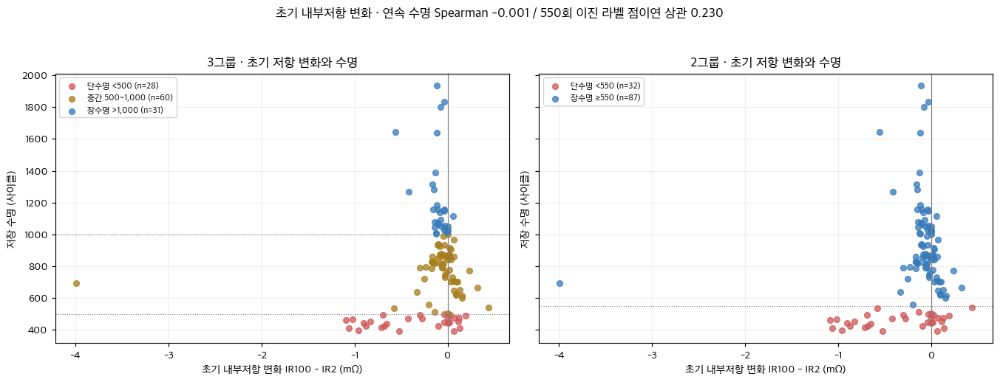

In [ ]:
# 저항은 상위 3개 상관 피처와 별도로 관찰한다.
fig,axes=plt.subplots(1,2,figsize=(13,5),sharex=True,sharey=True)
for ax,(scheme,groups,names,colors) in zip(axes,q5_schemes):
 for g,(name,color) in enumerate(zip(names,colors)):
  m=groups==g
  ax.scatter(q5_X[m,7],q5_y[m],s=28,alpha=.75,color=color,label=f'{name} (n={m.sum()})')
 for cut in ([500,1000] if scheme=='3그룹' else [550]):ax.axhline(cut,color='gray',ls=':',lw=.8)
 ax.axvline(0,color='gray',lw=.8);ax.set(xlabel='초기 내부저항 변화 IR100 - IR2 (mΩ)',ylabel='저장 수명 (사이클)',title=f'{scheme} · 초기 저항 변화와 수명');ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.suptitle(f'초기 내부저항 변화 · 연속 수명 Spearman {q5_spearman[7]:.3f} / 550회 이진 라벨 점이연 상관 {q5_binary[7]:.3f}',fontsize=12)
fig.tight_layout(rect=(0,0,1,.94));fig.savefig(q5_out/'scratch_q5_resistance_scatter.png',dpi=140,bbox_inches='tight');plt.show()


#### 그래프 결과 해석

저항은 말기에는 그룹 간 열화 정도를 구분하는 의미 있는 관측 지표지만, 초기 100회 변화량에서는 연속 수명과의 단조 관계가 거의 없다. 또한 낮은 VIF는 다른 초기 피처와의 중복이 작다는 뜻이지 수명 설명력이 크다는 뜻은 아니다. 따라서 “말기 저항 증가가 단수명 셀에서 크다”와 “초기 저항의 수명 연관성은 약하다”를 함께 기록하는 것이 현재 결과에 맞다.


#### ③ 피처끼리 같은 정보를 반복하고 있는가?

Pearson·Spearman 히트맵으로 피처 간 중복을 확인하고, **여러 피처의 조합으로 한 피처가 설명되는 정도**를 VIF로 확인한다. |상관|≥0.8과 VIF≥5는 이번 EDA의 점검선이며 자동 제거 규칙은 아니다. 같은 입력 X를 사용하므로 3그룹·2그룹의 피처 간 상관과 VIF는 같다.


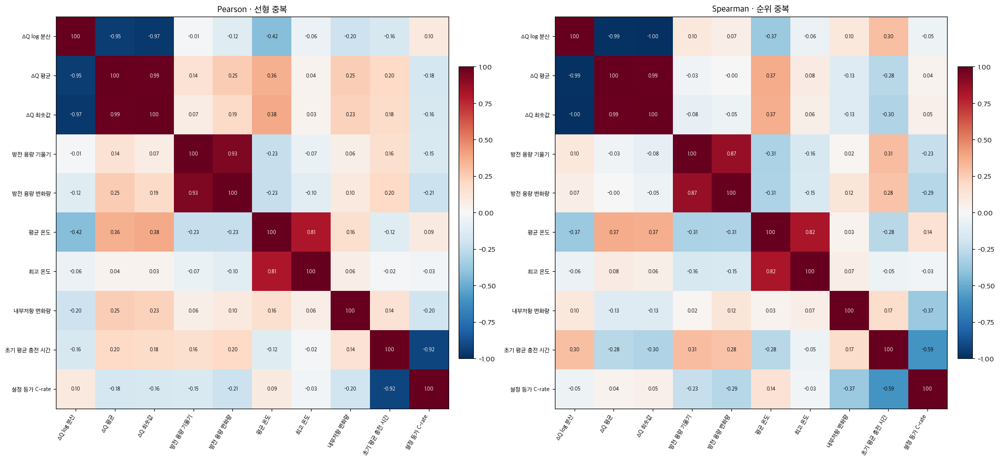

전체 10개 피처의 VIF (n=119)
logvar_dq: 22.37
dq_mean: 59.10
dq_min: 85.87
q_slope: 9.74
q_change: 10.07
t_mean: 7.23
t_max: 5.23
ir_change: 1.15
charge_mean: 8.62
c_equiv: 8.80


In [ ]:
q5_pairs=[];fig,axes=plt.subplots(1,2,figsize=(19,9))
q5_matrices=[]
for ax,rank,title in zip(axes,[False,True],['Pearson · 선형 중복','Spearman · 순위 중복']):
 matrix=np.array([[q5_corr(q5_X[:,i],q5_X[:,j],rank)[0] for j in range(10)] for i in range(10)]);q5_matrices.append(matrix)
 im=ax.imshow(matrix,vmin=-1,vmax=1,cmap='RdBu_r');ax.set_xticks(range(10),q5_names,rotation=60,ha='right',fontsize=8);ax.set_yticks(range(10),q5_names,fontsize=8);ax.set_title(title)
 for i in range(10):
  for j in range(10):ax.text(j,i,f'{matrix[i,j]:.2f}',ha='center',va='center',fontsize=7,color='white' if abs(matrix[i,j])>.6 else 'black')
 fig.colorbar(im,ax=ax,fraction=.035,pad=.025)
fig.tight_layout();fig.savefig(q5_out/'scratch_q5_feature_heatmaps.png',dpi=140,bbox_inches='tight');plt.show()
for i in range(10):
 for j in range(i+1,10):
  if max(abs(m[i,j]) for m in q5_matrices)>=.8:
   q5_pairs.append(dict(a=q5_keys[i],b=q5_keys[j],pearson=float(q5_matrices[0][i,j]),spearman=float(q5_matrices[1][i,j])))
   print(q5_names[i],'<->',q5_names[j],': Pearson',round(q5_matrices[0][i,j],3),'Spearman',round(q5_matrices[1][i,j],3))
def q5_vif(X):
 X=X[np.isfinite(X).all(axis=1)]
 if len(X)<=X.shape[1]+1 or np.any(X.std(0)==0):raise ValueError('표본 수/상수 피처 점검 필요')
 Z=(X-X.mean(0))/X.std(0);values=[]
 for j in range(Z.shape[1]):
  B=np.column_stack([np.ones(len(Z)),np.delete(Z,j,axis=1)]);coef=np.linalg.lstsq(B,Z[:,j],rcond=None)[0]
  residual=Z[:,j]-np.sum(B*coef,axis=1);sse=np.sum(residual**2);sst=np.sum(Z[:,j]**2)
  values.append(float(sst/sse) if sse>sst*1e-12 else float('inf'))
 return values,len(X)
q5_full_vif,q5_full_n=q5_vif(q5_X)
print('전체 10개 피처의 VIF (n=',q5_full_n,')')
for name,value in zip(q5_names,q5_full_vif):print(name,round(value,2))


#### 그래프 결과 해석

ΔQ 파생 통계, 용량 기울기·변화량, 평균·최고 온도, 충전 시간·등가 C-rate는 서로 겹치는 정보를 가진다. 특히 ΔQ 평균·최솟값은 거의 같은 순서로 움직여 두 피처의 높은 수명 상관을 독립적인 증거로 볼 수 없다. 히트맵은 변수 중복을 확인한 결과이며, 어떤 변수가 수명의 원인인지 판별한 그림은 아니다.


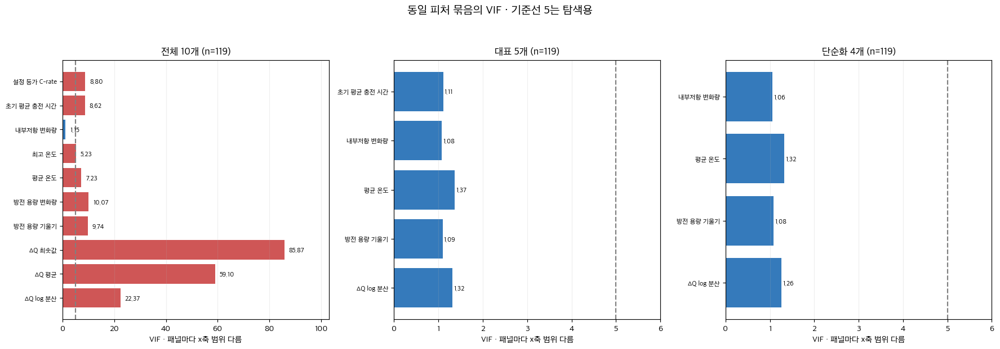

In [ ]:
q5_sets=[('전체 10개',list(range(10))),('대표 5개',[0,3,5,7,8]),('단순화 4개',[0,3,5,7])]
q5_vifs={};fig,axes=plt.subplots(1,3,figsize=(17,6))
for ax,(stage,indices) in zip(axes,q5_sets):
 values,n=q5_vif(q5_X[:,indices]);q5_vifs[stage]=dict(indices=indices,values=values,n=n)
 ax.barh(range(len(indices)),values,color=['#cf5656' if v>=5 else '#357abb' for v in values]);ax.set_yticks(range(len(indices)),[q5_names[j] for j in indices],fontsize=8)
 for k,v in enumerate(values):ax.text(v+.02*max(values),k,f'{v:.2f}',va='center',fontsize=8)
 ax.axvline(5,color='gray',ls='--');ax.set(xlabel='VIF · 패널마다 x축 범위 다름',title=f'{stage} (n={n})',xlim=(0,max(6,max(values)*1.2)));ax.grid(axis='x',alpha=.2)
 print(stage,dict(zip([q5_names[j] for j in indices],np.round(values,2))))
fig.suptitle('동일 피처 묶음의 VIF · 기준선 5는 탐색용',fontsize=14);fig.tight_layout(rect=(0,0,1,.94));fig.savefig(q5_out/'scratch_q5_vif_selection.png',dpi=140,bbox_inches='tight');plt.show()
(q5_out/'scratch_q5_results.json').write_text(json.dumps(dict(keys=q5_keys,pearson=q5_pearson.tolist(),spearman=q5_spearman.tolist(),n=q5_counts.tolist(),binary_point_biserial=q5_binary.tolist(),high_correlation_pairs=q5_pairs,vif=q5_vifs),ensure_ascii=False,indent=2))


#### 그래프 결과 해석

중복되는 변수들을 함께 넣은 10개 조합에서는 VIF가 높지만 부분집합에서는 약 1 수준으로 낮아진다. 이는 선택한 조합에서 선형 공선성이 줄었다는 정량적인 결과다. 다만 중복 감소와 예측 성능 향상은 별개의 문제이며, VIF만으로 피처의 유용성이나 최종 조합이 검증된 것은 아니다.


#### Question 5 — 상관관계 확인 결과

|초기 피처|수명 Pearson|수명 Spearman|
|---|---:|---:|
|ΔQ log 분산|−0.857|−0.888|
|ΔQ 최솟값|+0.818|+0.876|
|ΔQ 평균|+0.786|+0.861|

- 현재 초기 피처 중 **ΔQ log 분산**이 연속 수명과 가장 강한 순위 상관을 보인다.
- 초기 내부저항 변화(IR100−IR2)의 수명 Spearman은 약 **−0.001**이다. 550회 이진 라벨과의 점이연 상관은 약 **+0.230**으로, 연속 수명 상관과는 다른 통계다.
- 전체 10개에서 ΔQ 통계의 VIF는 약 **22.37~85.87**, 용량 기울기·변화량은 약 **9.74~10.07**이다. 여러 피처가 정보를 중복해서 담고 있다. 저항 변화의 전체 피처 내 VIF는 약 **1.15**다.
- 같은 셀·같은 피처라면 3그룹·2그룹으로 색을 바꾸어도 연속 수명 상관과 피처 간 공선성은 같다.

이 절은 상관관계와 중복 여부를 확인한 결과다. 관측의 종합 해석과 변수 선택은 아래에서 순서대로 다룬다.


### 5-11. 그래프별 분석 결과와 해석

앞에서 계산한 통합 EDA 결과를 **앞 결과에서 생긴 질문 → 분석 선택 이유 → 그래프·관측 수치 → 해석 → 다음 질문** 순서로 모았다. 각 그래프에서 확인한 차이와 수명과의 연관성을 설명하고, 관측 결과가 뒷받침하는 범위에서 해석한다.

- 대상은 세 배치를 합친 동일한 **119셀**이다. 수명은 데이터에 저장된 Cycle Life를 사용한다.
- **3그룹:** 단수명 <500회 / 중간 500~1,000회 / 장수명 >1,000회.
- **2그룹:** 단수명 <550회 / 장수명 ≥550회. 비교를 위해 설정한 경계이며, 데이터에서 최적 경계라고 검증한 값은 아니다.
- 두 묶음은 같은 셀의 색과 그룹 집계만 바꾼다. 연속 수명과의 상관계수는 그룹 색을 바꿔도 동일하다.
- 실제 사이클 번호와 셀별 관측 진행률(%)을 구분한다. 초기 100회는 전체 수명 중 앞부분만 확대한 구간이다.
- 추이 그림의 실선은 중앙값, 음영은 25~75% 범위다. 신뢰구간이나 개별 셀의 곡선과는 다르다.
- 아래 표는 저장된 계산 결과와 동일한 셀·집계식으로 정리했다. 반올림 때문에 표시값에 작은 차이가 있을 수 있다.
- 온도는 관측 결과로 기록하며 수명이 짧아진 원인으로 단정하지 않는다. 상관계수는 예측 정확도가 아니다.

**읽는 순서:** 수명 분포 → 전체 기록 → 관측 초기·중기·말기 → 초기 100회·5회 확대 → 용량 열화·knee → ΔQ(V) → 충전 조건 → 상관·공선성.

**전체 목적:** 초기 100사이클에서 얻을 수 있는 정보로 배터리의 총수명(Cycle Life)을 예측하는 모델 전략을 수립한다.

**EDA의 중심 질문:** “예측 시점에 확보할 수 있는 어떤 신호가 총수명과 연관되고, 중복을 줄여 어떤 입력으로 구성할 수 있는가?”

수명 분포는 목표값의 범위와 표본 구성을 확인하기 위해, 전체 열화·말기·knee 분석은 데이터의 진행 양상과 지표의 측정 시점을 이해하기 위해 수행한다. 이어 초기 100회에서 사용 가능한 신호를 찾고, 충전 조건과 상관·공선성을 점검해 모델 전략으로 연결한다. 전체 기록에서 도출한 말기 변화나 knee를 초기 예측 입력으로 사용하지 않는다. 화학적 원인 규명은 이번 EDA로 확정한 목표 달성이 아니다.


#### 01. 수명 분포와 그룹 구성

**이 분석을 선택한 이유**

초기 100사이클로 총수명을 예측하려면, 먼저 목표값인 총수명이 어느 범위에 분포하고 어떤 수명 구간의 표본이 부족한지 알아야 한다. 그래서 수명 히스토그램과 그룹별 개수를 확인했다. 수명 그룹은 예측 목표 자체가 아니라 EDA 비교를 위한 구분이다.

![01. 수명 분포와 그룹 구성 · 1](DAY1/results/scratch_pooled_composition.png)

![01. 수명 분포와 그룹 구성 · 2](DAY1/results/scratch_binary_pooled_composition.png)

**축과 표시**

왼쪽 x축은 저장 수명(회), y축은 셀 수다. 50회 간격 히스토그램이며 표시 범위는 150~2,300회다. 오른쪽은 수명 그룹별 셀 수다.

**관측 결과 · 수명과의 연관성**

통합 수명 범위는 **392~1,935회**, 중앙값은 **813회**다. 표시 축의 양 끝값이 데이터의 최솟값·최댓값은 아니다.

|구분|단수명|중간|장수명|
|---|---|---|---|
|3그룹|28셀 (23.5%)|60셀 (50.4%)|31셀 (26.1%)|
|2그룹|32셀 (26.9%)|해당 없음|87셀 (73.1%)|

550회로 나누면 기존 중간 그룹의 4셀은 단수명, 56셀은 장수명 쪽으로 이동한다. 짧은 수명 자체만으로 측정 오류나 이상치라고 판정한 결과는 아니다.

**결과 해석**

수명이 392~1,935회에 걸쳐 분포하고 중간 그룹이 절반가량을 차지한다. 따라서 단수명과 장수명 두 극단만 비교하면 중간 수명 셀의 특성이 충분히 드러나지 않는다. 550회로 나눈 결과는 동일한 연속 수명에 경계를 적용한 비교이며, 3그룹과 다른 실험 결과가 아니다. 짧은 수명이라는 이유만으로 해당 셀을 측정 이상치로 제외할 근거는 없다.

**다음 분석으로 연결**

수명 차이가 존재한다는 사실만으로 차이가 언제 발생하는지 알 수 없다. 다음에는 전체 사이클의 측정값을 비교한다.


#### 02. 전체 사이클에서 본 여섯 측정값

**이 분석을 선택한 이유**

수명이 다른 셀이 어떤 경로로 열화되는지 보기 위해, 초기 일부가 아닌 전체 기록의 여섯 지표를 먼저 펼쳐 보았다.

![02. 전체 사이클에서 본 여섯 측정값 · 1](DAY1/results/scratch_pooled_full_cycles.png)

![02. 전체 사이클에서 본 여섯 측정값 · 2](DAY1/results/scratch_binary_pooled_full_cycles.png)

**축과 표시**

x축은 실제 사이클 번호 2~1,934회다. 패널은 방전 용량, 2회 대비 용량 변화, 평균 온도, 최고 온도, 2회 대비 저항 변화, 충전 시간 순서다. 같은 사이클에 관측된 셀끼리 중앙값을 계산한다.

**관측 결과 · 수명과의 연관성**

방전 용량은 초기의 완만한 변화 뒤 감소가 커지고, 저항 변화와 충전 시간은 관측 후반에 상승하는 형태가 보인다. 단수명 그룹은 이러한 후반 변화가 더 작은 실제 사이클 번호에서 나타난다.

세 그룹의 마지막 기록 최댓값은 각각 **519 / 1,027 / 1,934회**, 2그룹은 **540 / 1,934회**다. 그룹은 저장 수명으로 나누므로 곡선이 500회나 1,000회를 조금 넘어서 끝날 수도 있다.

온도는 장수명 그룹의 평균 온도가 대체로 더 높게 나타나는 구간이 있다. 단수명 그룹이 더 뜨겁다고 읽을 수 있는 결과는 아니다. 후반 중앙값의 급격한 위아래 움직임은 아래 관측 셀 수와 함께 확인한다.

**결과 해석**

단수명 그룹은 더 이른 실제 사이클에서 용량이 감소하고 저항 변화·충전 시간이 커지는 모습을 보인다. 이는 수명 차이가 열화 진행 시점의 차이와 함께 나타난다는 결과다. 다만 후반 실선의 반등이나 급변은 남아 있는 셀 구성이 바뀐 영향도 포함하므로, 개별 배터리의 용량 회복으로 해석해서는 안 된다.

**다음 분석으로 연결**

후반 곡선에 급변이 보이지만 실제 상태 변화와 집계 대상 변화가 섞일 수 있다. 이를 구분하기 위해 같은 시점에 남은 셀 수를 확인한다.


#### 03. 전체 그래프에 기여하는 셀 수

**이 분석을 선택한 이유**

전체 곡선의 중앙값을 계산하는 셀 수가 일정한지 확인해야 후반의 급변을 과도하게 해석하지 않을 수 있다.

![03. 전체 그래프에 기여하는 셀 수 · 1](DAY1/results/scratch_pooled_full_counts.png)

![03. 전체 그래프에 기여하는 셀 수 · 2](DAY1/results/scratch_binary_pooled_full_counts.png)

**축과 표시**

x축은 실제 사이클, y축은 해당 지표·사이클에 유효 측정값이 있는 셀 수다. 지표마다 여섯 패널로 표시한다.

**관측 결과 · 수명과의 연관성**

초기에는 3그룹 **28/60/31셀**, 2그룹 **32/87셀**을 비교하지만 각 셀의 기록이 종료되면서 후반 표본이 감소한다. 3그룹 단수명 기록은 519회, 중간 기록은 1,027회 이후 남지 않는다.

따라서 전체 추이의 후반 실선은 최초의 모든 셀을 계속 추적한 고정 구성 평균이 아니다. 이 그림 자체가 수명과의 상관계수를 보여주는 것은 아니며, 전체 추이의 집계 대상을 확인하는 결과다.

**결과 해석**

후반으로 갈수록 비교에 남는 셀이 줄어들기 때문에 초기와 말기의 중앙값은 같은 셀 집합을 대표하지 않는다. 특히 소수 셀만 남은 구간의 급격한 변화는 그룹 전체의 공통 특성으로 일반화하기 어렵다. 전체 곡선의 변화는 개별 셀 곡선 및 관측 진행률 기준 결과와 함께 읽어야 한다.

**다음 분석으로 연결**

실제 사이클을 맞추면 단수명 셀이 먼저 사라진다. 다음에는 각 셀의 기록 진행률을 맞춰 초기·중기·말기의 양상을 비교한다.


#### 04. 관측 초기 (0~33.3%)

**이 분석을 선택한 이유**

셀마다 기록 길이가 다르므로 각 셀의 관측 구간을 3등분했다. 먼저 앞 1/3에서 그룹 차이가 이미 나타나는지 확인했다.

![04. 관측 초기 (0~33.3%) · 1](DAY1/results/scratch_pooled_phase_초기.png)

![04. 관측 초기 (0~33.3%) · 2](DAY1/results/scratch_binary_pooled_phase_초기.png)

**축과 표시**

x축은 각 셀의 기록을 0~100%로 바꾼 관측 진행률이다. 셀별 1% 구간 평균을 먼저 구한 후 그룹 중앙값과 사분위 범위를 표시한다. 초기·중기·말기는 관측 길이의 3등분이며 실제 사이클 번호가 같다거나 화학적 단계가 같다는 뜻은 아니다.

**관측 결과 · 수명과의 연관성**

충전 시간 중앙값은 세 그룹 모두 약 10분 수준에서 큰 변화가 없다. 평균 온도와 최고 온도는 그룹별 수준 차이가 보인다. 단수명 그룹의 용량은 이 구간에서 상대적으로 높으며, 높은 초기 용량이 곧 장수명인 것은 아니다.

**3그룹: 구간 처음 → 마지막 1% 구간의 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.097 → 1.097|1.076 → 1.070|1.070 → 1.056|
|2회 대비 용량 변화 (Ah)|0.001 → 0.002|0.002 → -0.005|0.002 → -0.010|
|사이클 평균 온도 (°C)|32.979 → 32.989|33.210 → 33.880|33.613 → 35.718|
|사이클 최고 온도 (°C)|35.960 → 37.088|36.353 → 38.045|36.511 → 39.240|
|2회 대비 저항 변화 (mΩ)|-0.115 → -0.259|-0.082 → 0.000|-0.094 → -0.110|
|충전 시간 (분)|10.175 → 10.174|10.061 → 10.128|10.044 → 10.044|

**2그룹: 구간 처음 → 마지막 1% 구간의 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.097 → 1.097|1.073 → 1.064|
|2회 대비 용량 변화 (Ah)|0.001 → 0.001|0.002 → -0.006|
|사이클 평균 온도 (°C)|32.979 → 32.989|33.303 → 34.208|
|사이클 최고 온도 (°C)|35.960 → 37.088|36.406 → 38.200|
|2회 대비 저항 변화 (mΩ)|-0.112 → -0.191|-0.084 → -0.060|
|충전 시간 (분)|10.175 → 10.174|10.044 → 10.046|

표의 용량 변화와 저항 변화는 각 셀의 2회차를 뺀 뒤 집계한 값이다. 중앙값끼리 뺀 결과와는 다를 수 있다.

**결과 해석**

관측 초기에는 단수명 그룹의 절대 용량이 오히려 높고 충전 시간은 세 그룹 모두 약 10분으로 비슷하다. 따라서 초기 용량이 크다는 사실만으로 긴 수명을 설명할 수 없다. 온도에는 그룹 간 수준 차이가 있지만 단수명 그룹이 더 높은 방향은 아니므로, 이 결과를 단수명 셀의 고온 열화 근거로 사용하지 않는다.

**다음 분석으로 연결**

초기 용량 수준만으로 수명을 설명하기 어려웠다. 다음에는 중기에서 감소 추세와 다른 지표가 어떻게 달라지는지 본다.


#### 05. 관측 중기 (33.3~66.7%)

**이 분석을 선택한 이유**

초기에 보인 수준 차이가 진행 중에도 유지되는지, 용량·저항·시간이 동시에 변하기 시작하는지 확인하기 위해 중기를 비교했다.

![05. 관측 중기 (33.3~66.7%) · 1](DAY1/results/scratch_pooled_phase_중기.png)

![05. 관측 중기 (33.3~66.7%) · 2](DAY1/results/scratch_binary_pooled_phase_중기.png)

**축과 표시**

x축은 각 셀의 기록을 0~100%로 바꾼 관측 진행률이다. 셀별 1% 구간 평균을 먼저 구한 후 그룹 중앙값과 사분위 범위를 표시한다. 초기·중기·말기는 관측 길이의 3등분이며 실제 사이클 번호가 같다거나 화학적 단계가 같다는 뜻은 아니다.

**관측 결과 · 수명과의 연관성**

세 그룹 모두 용량 중앙값이 감소한다. 단수명 그룹은 해당 구간 양 끝의 용량 감소 폭이 더 크다. 저항 변화는 구간 끝에서 양수 쪽으로 이동하지만 충전 시간 중앙값은 여전히 약 10분이다.

**3그룹: 구간 처음 → 마지막 1% 구간의 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.096 → 1.051|1.070 → 1.045|1.055 → 1.031|
|2회 대비 용량 변화 (Ah)|0.001 → -0.038|-0.005 → -0.030|-0.010 → -0.036|
|사이클 평균 온도 (°C)|33.034 → 33.267|34.071 → 34.901|35.591 → 35.403|
|사이클 최고 온도 (°C)|37.054 → 38.174|37.982 → 39.158|39.180 → 38.744|
|2회 대비 저항 변화 (mΩ)|-0.222 → 0.247|-0.001 → 0.128|-0.132 → 0.023|
|충전 시간 (분)|10.175 → 10.225|10.134 → 10.138|10.044 → 10.059|

**2그룹: 구간 처음 → 마지막 1% 구간의 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.096 → 1.051|1.064 → 1.040|
|2회 대비 용량 변화 (Ah)|0.001 → -0.040|-0.006 → -0.032|
|사이클 평균 온도 (°C)|33.034 → 33.267|34.323 → 35.001|
|사이클 최고 온도 (°C)|37.054 → 38.174|38.368 → 39.133|
|2회 대비 저항 변화 (mΩ)|-0.149 → 0.247|-0.078 → 0.037|
|충전 시간 (분)|10.175 → 10.238|10.045 → 10.124|

표의 용량 변화와 저항 변화는 각 셀의 2회차를 뺀 뒤 집계한 값이다. 중앙값끼리 뺀 결과와는 다를 수 있다.

**결과 해석**

관측 중기에는 모든 그룹의 용량이 감소하며, 단수명 그룹은 용량 감소가 커지는 동시에 저항 변화가 양수로 전환하는 모습을 보인다. 충전 시간의 큰 증가는 아직 두드러지지 않아 모든 지표가 같은 시점에 동일한 정도로 변하는 것은 아니다. 이 구간은 각 셀 기록의 중간 부분이므로 그룹 간 실제 누적 사이클 수는 다르다.

**다음 분석으로 연결**

중기에는 용량 감소가 진행되지만 충전 시간 증가는 크지 않았다. 다음에는 말기에 변화가 집중되는 지표를 확인한다.


#### 06. 관측 말기 (66.7~100%)

**이 분석을 선택한 이유**

중기까지 완만했던 지표가 종료에 가까워지면서 어떻게 달라지는지 확인하기 위해 관측 마지막 1/3을 비교했다.

![06. 관측 말기 (66.7~100%) · 1](DAY1/results/scratch_pooled_phase_말기.png)

![06. 관측 말기 (66.7~100%) · 2](DAY1/results/scratch_binary_pooled_phase_말기.png)

**축과 표시**

x축은 각 셀의 기록을 0~100%로 바꾼 관측 진행률이다. 셀별 1% 구간 평균을 먼저 구한 후 그룹 중앙값과 사분위 범위를 표시한다. 초기·중기·말기는 관측 길이의 3등분이며 실제 사이클 번호가 같다거나 화학적 단계가 같다는 뜻은 아니다.

**관측 결과 · 수명과의 연관성**

단수명 그룹에서 용량 감소와 저항 증가가 특히 크게 나타난다. 충전 시간도 세 그룹 모두 후반에 증가한다. 단수명 충전 시간은 끝부분에서 최고점 이후 내려오므로 말기 내내 단조 증가한다고 표현하지 않는다. 평균·최고 온도는 저항처럼 일관된 급상승 패턴을 보이지 않는다.

**3그룹: 구간 처음 → 마지막 1% 구간의 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.049 → 0.832|1.044 → 0.885|1.030 → 0.884|
|2회 대비 용량 변화 (Ah)|-0.041 → -0.264|-0.031 → -0.189|-0.037 → -0.184|
|사이클 평균 온도 (°C)|33.252 → 32.758|34.739 → 34.510|35.477 → 35.658|
|사이클 최고 온도 (°C)|38.017 → 37.386|39.121 → 39.306|38.821 → 38.888|
|2회 대비 저항 변화 (mΩ)|0.289 → 4.217|0.168 → 3.037|0.000 → 2.108|
|충전 시간 (분)|10.236 → 20.000|10.138 → 18.524|10.063 → 14.757|

**2그룹: 구간 처음 → 마지막 1% 구간의 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.049 → 0.832|1.039 → 0.885|
|2회 대비 용량 변화 (Ah)|-0.042 → -0.263|-0.033 → -0.186|
|사이클 평균 온도 (°C)|33.252 → 33.011|34.791 → 34.613|
|사이클 최고 온도 (°C)|38.017 → 37.631|39.047 → 39.299|
|2회 대비 저항 변화 (mΩ)|0.289 → 4.207|0.076 → 2.611|
|충전 시간 (분)|10.249 → 20.000|10.120 → 17.173|

표의 용량 변화와 저항 변화는 각 셀의 2회차를 뺀 뒤 집계한 값이다. 중앙값끼리 뺀 결과와는 다를 수 있다.

**결과 해석**

관측 말기에는 단수명 그룹에서 용량 감소와 내부저항 증가가 특히 크게 나타나며 충전 시간도 증가한다. 마지막 1% 구간의 저항 변화 중앙값은 단·중·장수명 순으로 4.217/3.037/2.108 mΩ여서, 저항은 말기의 열화 상태 차이를 설명하는 지표로 의미가 있다. 이 동반 변화는 열화가 심해진 상태와 부합하지만, 측정값만으로 활물질 균열이나 특정 부반응을 원인으로 확정할 수는 없다.

**다음 분석으로 연결**

말기의 동반 변화는 열화 상태를 설명하지만 초기 수명 추정에 그대로 쓸 수 없다. 따라서 시점을 초기 100회로 제한해 남아 있는 차이를 확인한다.


#### 07. 초기 2~100회: 셀별 지표 분포

**이 분석을 선택한 이유**

말기 정보를 쓰지 않고도 수명과 관련된 차이가 남는지 보기 위해 각 셀의 초기 100회 지표를 한 값씩 요약해 비교했다.

![07. 초기 2~100회: 셀별 지표 분포 · 1](DAY1/results/scratch_pooled_features_100.png)

![07. 초기 2~100회: 셀별 지표 분포 · 2](DAY1/results/scratch_binary_pooled_features_100.png)

**축과 표시**

x축은 수명 그룹, 점 하나는 셀 하나다. 각 셀의 2~100회 Qd·Tavg·충전 시간은 평균, Tmax는 구간 내 최댓값, 용량·저항 변화는 100회−2회 값이다. 박스는 셀 간 분포를 나타낸다.

**관측 결과 · 수명과의 연관성**

**3그룹 — 셀별 요약값의 그룹 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.0992|1.0784|1.0702|
|2회 대비 용량 변화 (Ah)|0.0030|0.0020|0.0014|
|사이클 평균 온도 (°C)|32.94|33.21|33.90|
|사이클 최고 온도 (°C)|37.27|37.47|37.97|
|2회 대비 저항 변화 (mΩ)|-0.2911|-0.0291|-0.1028|
|충전 시간 (분)|10.18|10.08|10.04|

**2그룹 — 셀별 요약값의 그룹 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.0978|1.0733|
|2회 대비 용량 변화 (Ah)|0.0028|0.0019|
|사이클 평균 온도 (°C)|32.94|33.38|
|사이클 최고 온도 (°C)|37.27|37.57|
|2회 대비 저항 변화 (mΩ)|-0.2100|-0.0496|
|충전 시간 (분)|10.17|10.05|

3그룹에서 단수명 셀의 용량 수준 중앙값은 장수명보다 높다. 초기 저항 변화 중앙값은 음수이며, 말기에 관측한 저항 급증과 방향이 다르다. 중앙값의 차이는 분포 전체가 겹치지 않는다는 뜻이 아니다. 이 그림에는 수명 상관계수를 별도로 계산하지 않았다.

**결과 해석**

초기 100회 요약값에서는 절대 용량·온도·저항 변화 등의 그룹 중앙값 차이가 나타나지만 셀별 분포도 함께 겹친다. 단수명 그룹의 초기 용량이 더 높다는 점은 초기 용량 수준과 장기 내구성이 같은 개념이 아님을 보여준다. 이 분포 차이의 크기와 연속 수명과의 관계는 별개이므로, 이후 상관계수와 함께 해석해야 한다.

**다음 분석으로 연결**

초기 100회 요약값에 차이가 보여, 더 짧은 5회 구간에서도 어떤 차이가 남는지 병렬 비교한다. 5회 결과가 100회 결과를 대체한다고 가정하지 않는다.


#### 08. 초기 2~5회: 셀별 지표 분포

**이 분석을 선택한 이유**

관측 기간을 더 줄였을 때에도 그룹별 수준 차이가 보이는지 확인하기 위해 같은 집계 방식을 2~5회에 적용했다.

![08. 초기 2~5회: 셀별 지표 분포 · 1](DAY1/results/scratch_pooled_features_5.png)

![08. 초기 2~5회: 셀별 지표 분포 · 2](DAY1/results/scratch_binary_pooled_features_5.png)

**축과 표시**

x축은 수명 그룹, 점 하나는 셀 하나다. 각 셀의 2~5회 Qd·Tavg·충전 시간은 평균, Tmax는 구간 내 최댓값, 용량·저항 변화는 5회−2회 값이다. 박스는 셀 간 분포를 나타낸다.

**관측 결과 · 수명과의 연관성**

**3그룹 — 셀별 요약값의 그룹 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.0971|1.0756|1.0684|
|2회 대비 용량 변화 (Ah)|0.0013|0.0022|0.0015|
|사이클 평균 온도 (°C)|32.99|33.23|33.76|
|사이클 최고 온도 (°C)|36.16|36.41|36.68|
|2회 대비 저항 변화 (mΩ)|-0.1429|-0.0750|-0.0742|
|충전 시간 (분)|10.18|10.06|10.04|

**2그룹 — 셀별 요약값의 그룹 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.0966|1.0722|
|2회 대비 용량 변화 (Ah)|0.0013|0.0019|
|사이클 평균 온도 (°C)|32.99|33.32|
|사이클 최고 온도 (°C)|36.16|36.53|
|2회 대비 저항 변화 (mΩ)|-0.1282|-0.0747|
|충전 시간 (분)|10.17|10.04|

3그룹에서 단수명 셀의 용량 수준 중앙값은 장수명보다 높다. 초기 저항 변화 중앙값은 음수이며, 말기에 관측한 저항 급증과 방향이 다르다. 중앙값의 차이는 분포 전체가 겹치지 않는다는 뜻이 아니다. 이 그림에는 수명 상관계수를 별도로 계산하지 않았다.

**결과 해석**

2~5회에서도 그룹별 측정값 수준 차이는 보이지만 네 사이클만으로 장기간의 감소 추세를 확인한 것은 아니다. 저항 변화 중앙값이 음수라는 사실도 모든 셀에서 저항이 처음부터 계속 증가하는 것은 아님을 보여준다. 초기 5회 분포 차이를 말기 열화의 직접적인 증거로 해석하지 않는다.

**다음 분석으로 연결**

구간 요약값만으로는 변화 시점을 알 수 없다. 다음에는 초기 100회의 사이클별 추이를 펼쳐 요약값의 배경을 확인한다.


#### 09. 초기 2~100회: 사이클별 추이 확대

**이 분석을 선택한 이유**

평균이나 시작·끝 차이만으로 가려지는 초기 증가·감소·굴곡을 확인하기 위해 100회까지의 사이클별 추이를 보았다.

![09. 초기 2~100회: 사이클별 추이 확대 · 1](DAY1/results/scratch_pooled_traces_100.png)

![09. 초기 2~100회: 사이클별 추이 확대 · 2](DAY1/results/scratch_binary_pooled_traces_100.png)

**축과 표시**

x축은 실제 사이클 번호 2~100회, y축은 각 측정값이다. 앞의 박스플롯과 달리 매 사이클의 셀 중앙값을 연결한다. Tmax도 각 사이클의 최고 온도이므로 구간 전체의 최댓값과 다르다.

**관측 결과 · 수명과의 연관성**

**3그룹 — 100회차에서의 그룹 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.1002|1.0768|1.0687|
|2회 대비 용량 변화 (Ah)|0.0030|0.0020|0.0014|
|사이클 평균 온도 (°C)|32.81|33.31|34.01|
|사이클 최고 온도 (°C)|36.38|36.89|37.20|
|2회 대비 저항 변화 (mΩ)|-0.2911|-0.0291|-0.1028|
|충전 시간 (분)|10.18|10.09|10.04|

**2그룹 — 100회차에서의 그룹 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.0999|1.0724|
|2회 대비 용량 변화 (Ah)|0.0028|0.0019|
|사이클 평균 온도 (°C)|32.81|33.47|
|사이클 최고 온도 (°C)|36.38|37.11|
|2회 대비 저항 변화 (mΩ)|-0.2100|-0.0496|
|충전 시간 (분)|10.17|10.04|

용량 변화와 저항 변화는 시작점인 2회차에서 모두 0이다. 초기 확대에서는 용량 변화가 수 mAh 수준인 반면 전체 기록에서는 수백 mAh까지 커진다. 초기 확대의 큰 시각적 굴곡과 전체 열화의 절대 크기를 같은 것으로 읽지 않는다.

**결과 해석**

100회까지의 확대에서는 작은 용량 증가나 굴곡, 초기 저항 감소를 볼 수 있다. 전체 수명에서 나타나는 큰 용량 저하와 달리 초기에는 변화 규모가 작으므로, 곡선이 완만하다고 이후 수명 차이가 없다고 볼 수는 없다. 초기의 작은 신호와 이후 수명의 관계는 ΔQ(V)와 셀별 피처 분석에서 별도로 확인된다.

**다음 분석으로 연결**

100회 안의 변화와 시작 직후의 변화는 다를 수 있다. 다음에는 첫 몇 회의 추이를 확대해 구분한다.


#### 10. 초기 2~5회: 사이클별 추이 확대

**이 분석을 선택한 이유**

2~5회 분포 차이가 처음부터 존재하는 수준 차이인지 짧은 구간의 변화인지 확인하기 위해 사이클별 네 점을 비교했다.

![10. 초기 2~5회: 사이클별 추이 확대 · 1](DAY1/results/scratch_pooled_traces_5.png)

![10. 초기 2~5회: 사이클별 추이 확대 · 2](DAY1/results/scratch_binary_pooled_traces_5.png)

**축과 표시**

x축은 실제 사이클 번호 2~5회, y축은 각 측정값이다. 앞의 박스플롯과 달리 매 사이클의 셀 중앙값을 연결한다. Tmax도 각 사이클의 최고 온도이므로 구간 전체의 최댓값과 다르다.

**관측 결과 · 수명과의 연관성**

**3그룹 — 5회차에서의 그룹 중앙값**

|지표|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|방전 용량 (Ah)|1.0976|1.0765|1.0691|
|2회 대비 용량 변화 (Ah)|0.0013|0.0022|0.0015|
|사이클 평균 온도 (°C)|32.94|33.23|33.72|
|사이클 최고 온도 (°C)|35.93|36.32|36.54|
|2회 대비 저항 변화 (mΩ)|-0.1429|-0.0750|-0.0742|
|충전 시간 (분)|10.18|10.05|10.04|

**2그룹 — 5회차에서의 그룹 중앙값**

|지표|단수명 <550|장수명 ≥550|
|---|---|---|
|방전 용량 (Ah)|1.0973|1.0732|
|2회 대비 용량 변화 (Ah)|0.0013|0.0019|
|사이클 평균 온도 (°C)|32.93|33.30|
|사이클 최고 온도 (°C)|35.93|36.35|
|2회 대비 저항 변화 (mΩ)|-0.1282|-0.0747|
|충전 시간 (분)|10.17|10.04|

용량 변화와 저항 변화는 시작점인 2회차에서 모두 0이다. 초기 확대에서는 용량 변화가 수 mAh 수준인 반면 전체 기록에서는 수백 mAh까지 커진다. 초기 확대의 큰 시각적 굴곡과 전체 열화의 절대 크기를 같은 것으로 읽지 않는다.

**결과 해석**

2~5회 그래프는 초기 측정 수준과 아주 짧은 구간의 변화를 보여준다. 네 점의 선이 벌어져 보이는 정도에는 확대된 y축도 영향을 주므로, 선 간격만으로 수명 구분 능력이 크다고 판단할 수 없다. 전체 열화 곡선과 연결해 읽되, 이 구간에서 장기 열화 속도를 관찰했다고 표현하지 않는다.

**다음 분석으로 연결**

초기 확대만으로 전체 열화 속도는 판단할 수 없다. 다음에는 셀별 전체 용량 곡선과 실제 사이클당 변화 속도로 열화 양상을 정량화한다.


#### 11. 셀 하나하나의 전체 용량 곡선

**이 분석을 선택한 이유**

그룹 중앙값의 굴곡이 개별 셀에서도 나타나는지, 초기 용량 차이를 빼도 열화 시점이 다른지 확인하기 위해 개별 Qd와 변화량을 함께 그렸다.

![11. 셀 하나하나의 전체 용량 곡선 · 1](DAY1/results/scratch_q2_individual_capacity.png)

![11. 셀 하나하나의 전체 용량 곡선 · 2](DAY1/results/scratch_binary_q2_individual_capacity.png)

**축과 표시**

선 하나는 실제 셀 하나다. x축은 실제 사이클, 왼쪽 y축은 Qd(Ah), 오른쪽은 Qd(k)−Qd(2)(Ah)다. 축 범위는 각각 0.75~1.15, −0.35~0.05 Ah다.

**관측 결과 · 수명과의 연관성**

초기의 절대 용량은 셀마다 다르다. 초기값을 뺀 오른쪽에서도 단수명 셀은 더 이른 실제 사이클에서 큰 감소를 보인다. 그룹 내에서 열화 곡선의 모양과 종료 시점은 다르다.

축 밖 삼각형은 숨겨진 관측값을 표시한다. 예를 들어 Batch 1 / 셀 18의 40회 Qd는 **2.8841 Ah**로 표시 범위 밖이다. 그래프 원본에는 보존했으며, 아래 기울기·knee 적합에서는 Qd가 유한하고 **0<Qd≤1.2 Ah**인 값만 사용했다. 축 확대가 데이터 삭제를 뜻하지 않는다.

**결과 해석**

초기 용량을 뺀 뒤에도 단수명 셀의 감소가 더 이른 실제 사이클에서 나타나므로, 그룹 차이는 초기 용량 수준만의 차이로 설명되지 않는다. 동시에 같은 수명 그룹 안에서도 곡선이 다양해 그룹 중앙값 하나가 모든 셀을 대표하지는 않는다. 축 범위 밖의 값은 이상 여부를 점검할 대상이며, 짧은 수명의 셀 자체와 측정 이상값을 구분해야 한다.

**다음 분석으로 연결**

개별 곡선에서 후반 감소가 가팔라 보여, 같은 인상을 실제 100사이클당 기울기로 확인한다.


#### 12. 초기·중기·말기의 용량 감소 속도

**이 분석을 선택한 이유**

“가파르게 감소한다”는 시각적 관찰을 수치로 확인하기 위해 각 셀의 초기·중기·말기 기울기를 같은 단위로 비교했다.

![12. 초기·중기·말기의 용량 감소 속도 · 1](DAY1/results/scratch_q2_degradation_rates.png)

![12. 초기·중기·말기의 용량 감소 속도 · 2](DAY1/results/scratch_binary_q2_degradation_rates.png)

**축과 표시**

x축은 수명 그룹, 세 패널은 관측 길이의 초기·중기·말기다. y축은 실제 100사이클당 Qd 변화(Ah/100회)이며 음수일수록 감소, 더 작은 음수일수록 가파른 감소다.

**관측 결과 · 수명과의 연관성**

|구분|셀 수|초기 기울기|중기 기울기|말기 기울기|
|---|---|---|---|---|
|3그룹 단수명 <500|28|0.00028|-0.02682|-0.14398|
|3그룹 중간 500~1,000|60|-0.00358|-0.00911|-0.05993|
|3그룹 장수명 >1,000|31|-0.00348|-0.00612|-0.04068|
|2그룹 단수명 <550|32|-0.00019|-0.02660|-0.14256|
|2그룹 장수명 ≥550|87|-0.00353|-0.00806|-0.05071|

**119셀 모두 중기와 말기의 기울기가 음수이고, 말기가 더 가파르다.** 따라서 같은 속도로 용량이 감소한 결과가 아니다. 여기의 “초기”는 관측 길이 앞 1/3이며, 뒤의 피처에서 사용하는 “2~100회 기울기”와 다르다.

**결과 해석**

119셀 모두 중기보다 말기의 용량 감소 기울기가 더 가파르므로, 이 데이터에서는 일정한 속도의 열화보다 후반 가속 형태가 공통적으로 관측된다. 실제 100사이클당 변화량으로 비교했을 때도 단수명 그룹의 말기 감소가 더 크므로, 관측 진행률을 정규화한 그림의 시각적 차이만은 아니다. 다만 말기 기울기는 수명 후반을 관측한 결과이며 초기 예측 가능성을 직접 보여주지는 않는다.

**다음 분석으로 연결**

모든 셀에서 말기 감소가 더 빠르지만, 3등분만으로 가속 시작점을 알 수는 없다. 다음에는 셀별 기울기 변화점인 knee 후보를 탐색한다.


#### 13. 대표 셀의 knee 후보 위치

**이 분석을 선택한 이유**

감소가 빨라진다는 결과를 “언제부터인가”라는 질문으로 좁히기 위해, 두 구간 직선이 만나는 위치를 knee 후보로 계산했다.

![13. 대표 셀의 knee 후보 위치 · 1](DAY1/results/scratch_q2_knee_examples.png)

![13. 대표 셀의 knee 후보 위치 · 2](DAY1/results/scratch_binary_q2_knee_examples.png)

**축과 표시**

x축은 실제 사이클, y축은 Qd다. 색 선은 측정값, 검은 점선은 두 구간 직선 적합, 세로선은 기울기 변화점 후보다. 각 그룹 수명을 정렬해 아래쪽 중앙 순위 셀을 고른 것이다.

**관측 결과 · 수명과의 연관성**

|구분|대표 셀|저장 수명(회)|knee 후보(회)|단일 직선 대비 SSE 감소|
|---|---|---|---|---|
|3그룹 단수명 <500|Batch 2 / 셀 18|449|374.0|93.8%|
|3그룹 중간 500~1,000|Batch 3 / 셀 40|796|630.4|95.0%|
|3그룹 장수명 >1,000|Batch 3 / 셀 3|1115|891.6|96.9%|
|2그룹 단수명 <550|Batch 2 / 셀 29|452|362.4|96.3%|
|2그룹 장수명 ≥550|Batch 1 / 셀 7|870|649.5|96.1%|

적합은 100회 이후 데이터에서 수행했다. 후보 범위는 전체 기록의 20~80% 안이며, 양쪽에 최소 50개 측정점과 50사이클을 확보했다. 후반 기울기가 음수이고 기울기 절댓값이 전반의 2배 이상, SSE가 25% 이상 개선되면 후보로 표시했다. 대표 셀의 지점을 모든 셀의 공통 시작점으로 쓰지 않는다.

**결과 해석**

knee는 각 셀의 곡선에서 감소 기울기가 크게 달라지는 위치를 두 직선으로 근사한 후보다. 대표 셀마다 후보 위치가 달라 모든 배터리에 공통인 하나의 시작 사이클이 있는 것은 아니다. 표시된 SSE 개선은 곡선 적합의 개선 정도이며 수명 예측 정확도가 아니다.

**다음 분석으로 연결**

대표 셀 몇 개만으로 공통 시점을 정할 수 없다. 다음에는 전체 셀의 후보 위치와 검출·경계 현황을 비교한다.


#### 14. 전체 셀의 knee 후보 분포

**이 분석을 선택한 이유**

대표 사례를 전체 셀로 확장해 시작점이 얼마나 다른지, 탐색 범위에 영향을 받는 후보가 얼마나 있는지 확인했다.

![14. 전체 셀의 knee 후보 분포 · 1](DAY1/results/scratch_q2_knee_distribution.png)

![14. 전체 셀의 knee 후보 분포 · 2](DAY1/results/scratch_binary_q2_knee_distribution.png)

**축과 표시**

x축은 수명 그룹이다. 왼쪽 y축은 후보의 실제 사이클, 오른쪽은 후보의 관측 진행률이다. 후보가 검출된 셀만 점으로 표시한다.

**관측 결과 · 수명과의 연관성**

|구분|검출/전체|후보 중앙값(회)|진행률 중앙값(%)|검색 경계 후보 수|
|---|---|---|---|---|
|3그룹 단수명 <500|28/28|361.8|77.0|4|
|3그룹 중간 500~1,000|59/60|639.1|77.7|17|
|3그룹 장수명 >1,000|31/31|891.6|79.2|12|
|2그룹 단수명 <550|32/32|364.6|77.0|5|
|2그룹 장수명 ≥550|86/87|679.6|78.5|28|

119셀 중 **118셀**에서 후보가 검출되었고, 그중 **33셀**은 탐색 범위의 경계에 걸렸다. 실제 사이클 기준 중앙값은 단수명 → 중간 → 장수명 순으로 늦어진다. SSE 개선 기준을 15%, 25%, 40%로 바꿨을 때 후보 수는 모두 118셀이었다. 이는 해당 기준에 대한 결과이며 검색 범위까지 바꿔 안정성을 확인한 것은 아니다.

“그래서 언제 시작되는가?”에는 **그룹 중앙값 약 362 / 639 / 892회, 셀마다 다름**이라고 답할 수 있다. 화학적 열화의 실제 시작점을 직접 측정한 값은 아니다.

**결과 해석**

검출된 knee 후보의 중앙값은 단·중·장수명에서 약 362/639/892회로, 수명이 긴 그룹일수록 실제 사이클 기준 후보가 늦다. 반면 관측 진행률 중앙값은 약 77~79%로 가까워 각 셀의 기록 후반에서 기울기 변화가 잡히는 경향을 보인다. 탐색 상한이 80%이고 33셀이 경계에 걸렸으므로, 이 결과를 모든 셀의 정확한 열화 시작점이 수명의 80%라는 결론으로 바꾸면 안 된다.

**다음 분석으로 연결**

knee는 후반 기록을 사용한 설명이다. 초기 예측에 사용할 정보를 찾기 위해 다음에는 10회와 100회의 방전곡선 차이로 돌아간다.


#### 15. 10회·100회 방전곡선과 ΔQ(V)

**이 분석을 선택한 이유**

초기 총용량 변화만으로 드러나지 않는 차이가 있는지 보기 위해 같은 전압에서 100회와 10회 Q(V)를 뺐다.

![15. 10회·100회 방전곡선과 ΔQ(V) · 1](DAY1/results/scratch_q3_original_and_delta.png)

![15. 10회·100회 방전곡선과 ΔQ(V) · 2](DAY1/results/scratch_binary_q3_original_and_delta.png)

**축과 표시**

x축은 전압 3.5→2.0 V로, 사이클 번호가 아니다. 위쪽 y축은 누적 방전 용량 Q(V), 아래쪽은 같은 전압의 Q100(V)−Q10(V)다. 공통 전압 1,000개 지점에서 비교했다.

**관측 결과 · 수명과의 연관성**

위 그림의 10회·100회 곡선은 가까이 겹쳐 보이지만, 차이를 계산한 아래 그림에서 변화의 전압별 모양이 드러난다. 3그룹 대표 셀의 저장 수명은 **449 / 796 / 1,115회**, 2그룹 대표 셀은 **452 / 870회**다.

대표 셀은 그룹 평균이 아니다. ΔQ가 음수인 전압에서는 100회차의 누적 방전 용량이 10회차보다 작다. 전체 방전 용량의 차이 한 개와 전압별 차이 곡선은 서로 다른 정보다.

**결과 해석**

겹쳐 보이는 10회·100회 방전곡선도 동일 전압에서 차이를 계산하면 변화의 위치와 크기가 드러난다. ΔQ(V)는 총 방전 용량 한 값으로는 드러나지 않는 곡선 형태의 변화를 나타낸다. 다만 대표 셀의 사례이므로 수명 그룹 전체의 차이는 다음 전체 셀 비교로 확인해야 한다.

**다음 분석으로 연결**

대표 셀에서 차이의 모양이 확인되어, 같은 차이가 전체 수명 그룹에서도 나타나는지 비교한다.


#### 16. 전체 ΔQ 곡선과 수명 그룹의 모양 차이

**이 분석을 선택한 이유**

대표 셀의 특이한 사례인지 판단하기 위해 119셀의 ΔQ 곡선과 그룹별 중앙값·분포를 함께 확인했다.

![16. 전체 ΔQ 곡선과 수명 그룹의 모양 차이 · 1](DAY1/results/scratch_q3_delta_groups.png)

![16. 전체 ΔQ 곡선과 수명 그룹의 모양 차이 · 2](DAY1/results/scratch_binary_q3_delta_groups.png)

**축과 표시**

x축은 전압, y축은 ΔQ(Ah)다. 왼쪽은 119셀의 개별 곡선, 오른쪽은 전압별 그룹 중앙값과 25~75% 구간이다.

**관측 결과 · 수명과의 연관성**

단수명 그룹은 장수명 그룹보다 음의 방향으로 깊어지는 구간이 두드러지고, 3그룹의 중간 그룹은 그 사이에 위치하는 경향이 보인다. 개별 곡선과 그룹의 사분위 범위에는 겹침이 있다.

차이의 모양을 한 수치로 바꾼 log 분산·평균·최솟값·IQR의 실제 그룹 중앙값과 상관계수는 바로 다음 두 결과에서 확인한다. 이 곡선의 차이만으로 특정 화학 반응을 식별한 것은 아니다.

**결과 해석**

단수명 그룹은 ΔQ가 더 깊은 음수 방향으로 나타나는 경향이 있어 초기 10~100회 사이의 방전곡선 변화와 이후 수명이 연결되어 있음을 보여준다. 중간 그룹이 대체로 그 사이에 놓인다는 점도 변화량이 수명과 연속적으로 연관될 가능성을 뒷받침한다. 개별 곡선의 겹침이 있으므로 이 모양만으로 모든 셀을 완벽히 구분한다고 볼 수는 없다.

**다음 분석으로 연결**

곡선의 깊이와 퍼짐이 수명 그룹에 따라 달라 보여, 이를 비교 가능한 셀별 통계값으로 요약한다.


#### 17. ΔQ에서 추출한 네 통계값의 그룹 분포

**이 분석을 선택한 이유**

곡선 모양의 차이를 정량화하기 위해 위치를 나타내는 평균·최솟값과 퍼짐을 나타내는 분산·IQR을 추출했다.

![17. ΔQ에서 추출한 네 통계값의 그룹 분포 · 1](DAY1/results/scratch_q3_feature_distributions.png)

![17. ΔQ에서 추출한 네 통계값의 그룹 분포 · 2](DAY1/results/scratch_binary_q3_feature_distributions.png)

**축과 표시**

x축은 수명 그룹, y축은 각 ΔQ 통계값이다. 점 하나는 셀 하나다. IQR은 같은 셀의 ΔQ 곡선에서 전압별 값의 75백분위−25백분위다.

**관측 결과 · 수명과의 연관성**

**3그룹 중앙값**

|ΔQ 통계|단수명 <500|중간 500~1,000|장수명 >1,000|
|---|---|---|---|
|log 분산|-3.44610|-3.86931|-4.27178|
|평균 (Ah)|-0.02867|-0.01557|-0.00962|
|최솟값 (Ah)|-0.05618|-0.03485|-0.02232|
|IQR (Ah)|0.03120|0.01878|0.01153|

**2그룹 중앙값**

|ΔQ 통계|단수명 <550|장수명 ≥550|
|---|---|---|
|log 분산|-3.45128|-4.09180|
|평균 (Ah)|-0.02867|-0.01177|
|최솟값 (Ah)|-0.05618|-0.02784|
|IQR (Ah)|0.03011|0.01592|

수명이 짧은 그룹은 log 분산과 IQR이 더 크고, 평균과 최솟값은 더 음수다. log 분산 −3.45는 −4.27보다 큰 값이다. 음수라는 이유로 분산이 음수인 것은 아니며, 작은 양의 분산에 log10을 적용해 음수가 된 것이다.

**결과 해석**

단수명 그룹의 큰 분산·IQR과 더 음수인 평균·최솟값은 ΔQ 곡선 변화의 크기와 전압별 불균일성이 수명과 연관되어 있다는 결과다. 같은 곡선에서 얻은 통계들이므로 네 지표에서 차이가 관측되었다고 해서 독립된 네 가지 원인이 확인된 것은 아니다. 분포의 겹침을 고려하면 각 지표는 확정적인 수명 판정 기준이 아니라 연관 신호로 해석하는 것이 적절하다.

**다음 분석으로 연결**

그룹 차이만으로 연속 수명과의 관계나 정보 중복은 알 수 없다. 다음에는 수명 상관과 ΔQ 통계끼리의 상관을 함께 확인한다.


#### 18. ΔQ 통계와 수명 상관 · 통계끼리의 중복

**이 분석을 선택한 이유**

여러 ΔQ 지표에서 차이가 보여, 어느 지표가 연속 수명과 연관되고 서로 같은 정보를 반복하는지 점검했다.

![18. ΔQ 통계와 수명 상관 · 통계끼리의 중복 · 1](DAY1/results/scratch_q3_feature_relationships.png)

![18. ΔQ 통계와 수명 상관 · 통계끼리의 중복 · 2](DAY1/results/scratch_binary_q3_feature_relationships.png)

**축과 표시**

왼쪽 x축은 ΔQ log 분산, y축은 저장 수명이다. 오른쪽 히트맵은 ΔQ 통계값끼리의 Pearson 상관이다.

**관측 결과 · 수명과의 연관성**

|ΔQ 통계|수명 Spearman|네 통계 동시 계산 VIF|
|---|---|---|
|log 분산|-0.888|21.88|
|평균 (Ah)|0.861|49.39|
|최솟값 (Ah)|0.876|87.83|
|IQR (Ah)|-0.896|18.35|

이 네 지표 중 |Spearman|가 가장 큰 것은 **IQR(0.896)**이며, log 분산(0.888)이 그다음이다. 둘의 차이는 관측 상관의 차이이며 예측 성능 차이가 아니다. 네 지표 사이에도 강한 상관과 높은 VIF가 있어 네 개의 독립적인 신호가 확인된 것으로 셀 수 없다.

**결과 해석**

ΔQ 통계는 수명과 강한 순위 상관을 보이지만 통계들끼리도 강하게 중복된다. IQR의 |상관|가 log 분산보다 조금 크다는 결과만으로 더 좋은 예측 변수라고 확정할 수는 없다. 여러 ΔQ 통계의 높은 상관을 각각 독립된 증거로 합산하기보다, 공통된 초기 곡선 변화 신호가 여러 방식으로 요약된 결과로 읽는다.

**다음 분석으로 연결**

초기 곡선 변화는 수명과 연관되지만 실험에 적용한 조건의 차이도 함께 살펴야 한다. 다음에는 충전 정책별 수명 분포를 확인한다.


#### 19. 충전 정책별 평균 수명과 셀 간 차이

**이 분석을 선택한 이유**

측정된 셀 반응뿐 아니라 적용된 충전 조건과 수명의 관계를 보기 위해 원래 정책별 평균·표준편차·개별 셀을 비교했다.

![19. 충전 정책별 평균 수명과 셀 간 차이 · 1](DAY1/results/scratch_q4_policy_life.png)

![19. 충전 정책별 평균 수명과 셀 간 차이 · 2](DAY1/results/scratch_binary_q4_policy_life.png)

**축과 표시**

x축은 저장 수명, y축은 정책 이름이다. 마름모는 평균, 가로선은 ±1 표준편차, 작은 점은 셀이다. 접미사를 포함한 원래 정책 37개를 구분했다.

**관측 결과 · 수명과의 연관성**

정책별 표본 수는 1~9셀로 다르다. 평균 수명은 약 **394.5~1,333.3회**다. 같은 정책 안에도 개별 수명 차이가 있다. 아래 표에 모든 정책 결과를 기록했다.

|원래 정책|n|평균 수명(회)|표준편차(회)|<550 셀 수|≥550 셀 수|
|---|---|---|---|---|---|
|4.8C(80%)-4.8C-newstructure|9|1333.3|419.1|0|9|
|5C(67%)-4C-newstructure|7|1105.7|402.9|0|7|
|5.3C(54%)-4C-newstructure|8|1074.4|129.7|0|8|
|4.4C(80%)-4.4C|1|1074.0|계산 불가(n=1)|0|1|
|5.4C(40%)-3.6C|1|1054.0|계산 불가(n=1)|0|1|
|6C(30%)-3.6C|1|1014.0|계산 불가(n=1)|0|1|
|8C(15%)-3.6C|2|1008.5|60.1|0|2|
|5.6C(19%)-4.6C-newstructure|8|1001.4|174.6|0|8|
|5.6C(26%)-4.5C-newstructure|3|991.3|197.6|0|3|
|5.2C(58%)-4C-newstructure|3|961.7|157.6|0|3|
|6C(40%)-3C|2|935.5|115.3|0|2|
|5.6C(36%)-4.3C-newstructure|8|930.9|135.0|0|8|
|6C(50%)-3C|2|888.5|40.3|0|2|
|5.9C(15%)-4.6C-newstructure|2|867.0|12.7|0|2|
|5.9C(60%)-3.1C-newstructure|2|866.5|191.6|0|2|
|5.4C(60%)-3.6C|2|859.5|3.5|0|2|
|6C(40%)-3.6C|2|856.0|19.8|0|2|
|5.4C(60%)-3C|2|799.5|113.8|0|2|
|6C(50%)-3.6C|2|792.5|118.1|0|2|
|5.4C(50%)-3C|1|788.0|계산 불가(n=1)|0|1|
|5.4C(70%)-3C|2|739.5|68.6|0|2|
|7C(30%)-3.6C|2|722.5|27.6|0|2|
|8C(25%)-3.6C|2|676.5|36.1|0|2|
|7C(40%)-3C|2|676.0|39.6|0|2|
|3.7C(31%)-5.9C-newstructure|3|660.0|115.7|1|2|
|7C(40%)-3.6C|2|621.0|5.7|0|2|
|8C(35%)-3.6C|2|607.5|12.0|0|2|
|6C(60%)-3C|4|572.0|199.0|2|2|
|4.8C(80%)-4.8C|7|560.6|149.9|5|2|
|5.4C(80%)-5.4C|2|546.5|17.7|1|1|
|4.65C(44%)-5C|2|482.5|23.3|2|0|
|5.2C(58%)-4C|4|477.8|18.5|4|0|
|5.2C(50%)-4.25C|5|454.0|20.9|5|0|
|4.65C(69%)-6C|2|452.0|11.3|2|0|
|5.6C(26%)-4.5C|6|448.5|29.1|6|0|
|3.6C(30%)-6C|2|421.0|7.1|2|0|
|3.6C(9%)-5C|2|394.5|2.1|2|0|

예를 들어 8C→3.6C 설정에서 전환 SOC가 15%, 25%, 35%인 정책의 평균 수명은 각각 1,008.5 / 676.5 / 607.5회다(각 n=2). 숫자 C-rate가 같아도 전환 SOC가 다르면 별도 정책이다.

**결과 해석**

충전 정책에 따라 관측 평균 수명이 다르며 같은 정책 안에서도 셀 간 차이가 있다. 따라서 정책은 수명 차이와 연관된 조건이지만 정책별 표본 수가 적고 다른 조건을 통제한 비교가 아니므로 평균 순위를 최적 정책의 확정 순위로 사용할 수는 없다. C1만 보지 않고 전환 SOC와 C2까지 함께 읽어야 같은 속도에서 다른 수명이 나타나는 결과를 이해할 수 있다.

**다음 분석으로 연결**

정책별 평균만으로는 짧은 셀이 섞이는 정도가 가려질 수 있어, 두 수명 그룹의 정책 내 구성을 확인한다.


#### 20. 정책별 550회 기준 두 그룹 구성

**이 분석을 선택한 이유**

같은 평균이라도 수명 구성은 다를 수 있으므로 정책별 단수명·장수명 비율을 함께 확인했다.

![20. 정책별 550회 기준 두 그룹 구성 · 1](DAY1/results/scratch_binary_policy_proportions.png)

**축과 표시**

x축은 해당 정책 안의 셀 비율(%), y축은 충전 정책이다. 색은 <550회 / ≥550회이고 오른쪽 n은 정책의 셀 수다.

**관측 결과 · 수명과의 연관성**

37개 정책 중 관측 셀이 모두 <550회인 정책은 **7개**, 모두 ≥550회인 정책은 **26개**, 두 그룹이 함께 있는 정책은 **4개**다. 셀별 정확한 개수는 앞의 정책 표 마지막 두 열에 있다.

100% 막대가 있는 정책도 n이 1~몇 셀인 경우가 있다. 관측 표본의 비율이며 해당 정책을 새 셀에 적용했을 때의 성공 확률을 추정한 값은 아니다.

**결과 해석**

정책별 두 그룹 구성은 평균만으로 가려지는 셀별 수명 차이를 보여준다. 다만 작은 표본의 정책에서 한 색이 100%를 차지하는 것은 관측된 몇 셀이 모두 같은 그룹이라는 뜻이다. 이를 새로운 셀에서도 같은 수명 그룹이 나올 확률이 100%라는 의미로 해석하지 않는다.

**다음 분석으로 연결**

정책 전체의 차이에서 속도라는 요소를 좁혀 보기 위해, 다음에는 첫 충전 전류가 같은 셀끼리 비교한다.


#### 21. 동일한 첫 충전 전류 C1별 수명

**이 분석을 선택한 이유**

정책별 차이가 첫 충전 전류 하나로 설명되는지 확인하기 위해 동일 C1 안의 수명 분포를 비교했다.

![21. 동일한 첫 충전 전류 C1별 수명 · 1](DAY1/results/scratch_same_speed_c1.png)

**축과 표시**

위 패널 x축은 충전 속도 묶음, y축은 수명이다. 박스는 사분위 범위, 검은 마름모는 평균, 점은 셀이다. 아래 패널은 속도 묶음 안의 수명 그룹 비율이다. 왼쪽 3그룹·오른쪽 2그룹에 동일한 셀이 표시된다.

**관측 결과 · 수명과의 연관성**

첫 전류가 정확히 4.8C인 16셀의 수명은 **437~1,836회**, 5.6C인 25셀은 **412~1,267회**다. C1이 같아도 전체 정책이 같다는 뜻은 아니다.

|속도(C)|n|평균 수명|중앙값|수명 범위|원래 정책 수|
|---|---|---|---|---|---|
|3.60|4|407.8|406.0|393~426|2|
|3.70|3|660.0|667.0|541~772|1|
|4.40|1|1074.0|1074.0|1074~1074|1|
|4.65|4|467.2|463.0|444~499|2|
|4.80|16|995.2|839.5|437~1836|2|
|5.00|7|1105.7|1009.0|813~1935|1|
|5.20|12|588.8|475.5|424~1140|3|
|5.30|8|1074.4|1051.0|935~1315|1|
|5.40|10|773.2|788.0|534~1054|6|
|5.60|25|844.9|850.0|412~1267|4|
|5.90|4|866.8|867.0|731~1002|2|
|6.00|13|788.2|854.0|392~1017|6|
|7.00|6|673.2|675.5|617~742|3|
|8.00|6|764.2|676.5|599~1051|3|

같은 속도 묶음 안에서도 수명 차이가 관측되므로, 이 결과만으로 속도 한 값이 수명을 구분한다고 정리하기 어렵다.

**결과 해석**

같은 C1에서도 수명 범위가 넓으므로 첫 충전 전류 하나로 수명을 설명하기 어렵다. C1이 같은 묶음에도 전환 SOC·C2·원래 정책 구분이 다를 수 있어, “같은 첫 전류”는 “같은 전체 실험 조건”과 구분해야 한다. 관측 결과는 고속 충전일수록 항상 단수명이라는 단순한 순서를 보여주지 않는다.

**다음 분석으로 연결**

C1이 같아도 두 번째 단계가 다를 수 있다. 다음에는 0~80% 구간의 설정을 요약한 등가 C-rate로 비교한다.


#### 22. 비슷한 등가 C-rate별 수명

**이 분석을 선택한 이유**

첫 전류만 비교하는 한계를 보완하기 위해 두 단계의 SOC 길이와 전류를 반영한 등가 속도를 묶어 보았다.

![22. 비슷한 등가 C-rate별 수명 · 1](DAY1/results/scratch_same_speed_equiv.png)

**축과 표시**

위 패널 x축은 충전 속도 묶음, y축은 수명이다. 박스는 사분위 범위, 검은 마름모는 평균, 점은 셀이다. 아래 패널은 속도 묶음 안의 수명 그룹 비율이다. 왼쪽 3그룹·오른쪽 2그룹에 동일한 셀이 표시된다.

**관측 결과 · 수명과의 연관성**

등가 C-rate를 0.1C 단위로 반올림한 비교다. 약 4.8C 묶음은 **93셀**, 실제 범위 **4.755~4.813C**, 수명 **392~1,935회**, 원래 정책 **22개**다. 반올림 묶음의 설정값이 완전히 같지는 않다.

|속도(C)|n|평균 수명|중앙값|수명 범위|원래 정책 수|
|---|---|---|---|---|---|
|4.00|4|972.0|991.5|854~1051|2|
|4.20|4|788.5|746.0|648~1014|3|
|4.30|3|802.3|702.0|651~1054|2|
|4.40|5|859.2|860.0|703~1074|3|
|4.50|4|827.8|856.0|719~880|2|
|4.70|2|607.5|607.5|599~616|1|
|4.80|93|819.7|816.0|392~1935|22|
|4.90|2|739.5|739.5|691~788|1|
|5.40|2|546.5|546.5|534~559|1|

같은 속도 묶음 안에서도 수명 차이가 관측되므로, 이 결과만으로 속도 한 값이 수명을 구분한다고 정리하기 어렵다.

**결과 해석**

약 4.8C 묶음에 서로 다른 정책 22개와 폭넓은 수명이 포함되어 등가 C-rate만으로 정책별 수명 차이를 충분히 표현하기 어렵다. 등가값이 비슷해도 충전 구간의 전류 배분은 다를 수 있다. 따라서 등가 C-rate의 약한 수명 상관을 충전 조건 전체가 수명과 무관하다는 결론으로 확대하지 않는다.

**다음 분석으로 연결**

등가 속도가 비슷해도 수명이 넓게 퍼져, 요약 과정에서 가려진 전류 전환 패턴을 직접 확인한다.


#### 23. SOC에 따른 충전 전류 패턴

**이 분석을 선택한 이유**

등가값 하나로 구분되지 않는 설정의 차이를 보기 위해 SOC에 따른 C1·C2 전환 패턴을 다시 펼쳐 보았다.

![23. SOC에 따른 충전 전류 패턴 · 1](DAY1/results/scratch_q4_current_patterns.png)

![23. SOC에 따른 충전 전류 패턴 · 2](DAY1/results/scratch_binary_q4_current_patterns.png)

**축과 표시**

왼쪽 x축은 SOC 0~80%, y축은 설정 전류(C-rate), 색은 정책별 평균 수명이다. 오른쪽 x축은 설정 기반 등가 C-rate, y축은 저장 수명이다. 실제 시간별 측정 전류를 그린 그림은 아니다.

**관측 결과 · 수명과의 연관성**

서로 다른 C1·전환 SOC·C2 조합이 비슷한 등가 C-rate로 모인다. 등가 C-rate와 수명의 Spearman은 **−0.029**로, 통합 표본에서 뚜렷한 단조 관계가 관측되지 않았다.

등가 C-rate는 `0.8 / [(Q1/100)/C1 + (0.8−Q1/100)/C2]`로 계산한 설정 요약값이다. Q1=80%면 두 번째 구간 길이는 0이다. 동일한 숫자 설정의 4.8C 정책도 원래 접미사 구분에 따라 평균 수명이 **560.6회(n=7)**와 **1,333.3회(n=9)**로 달랐다. 접미사의 차이가 원인이라는 검증 결과는 아니다.

**결과 해석**

전류 패턴을 하나의 등가값으로 압축하면 서로 다른 C1·전환 SOC·C2 조합이 겹칠 수 있다. 통합 표본에서 등가 C-rate와 수명의 순위 상관이 거의 0인 것은 이 요약값만으로 수명 순서를 잘 설명하지 못한다는 뜻이다. 충전 프로토콜의 모든 차이나 효과가 없다는 결과는 아니다.

**다음 분석으로 연결**

속도와 수명 관계만으로는 열화가 어느 구간에서 달라지는지 알 수 없어, 초기·말기 용량 감소 속도와의 상관을 비교한다.


#### 24. 충전 조건과 초기·말기 용량 감소 속도

**이 분석을 선택한 이유**

충전 조건이 수명뿐 아니라 실제 용량 감소 속도와도 연결되는지 확인하기 위해 조건별 상관을 같은 표로 비교했다.

![24. 충전 조건과 초기·말기 용량 감소 속도 · 1](DAY1/results/scratch_q4_rate_relationships.png)

![24. 충전 조건과 초기·말기 용량 감소 속도 · 2](DAY1/results/scratch_binary_q4_rate_relationships.png)

**축과 표시**

산점도 x축은 등가 C-rate, y축은 용량 감소 속도(Ah/100회)다. 여기서는 양수가 감소를 뜻하므로 앞의 Qd 기울기와 부호가 반대다. 초기=2~100회, 말기=각 셀 기록의 마지막 1/3이다.

**관측 결과 · 수명과의 연관성**

|설정 조건|수명 Spearman|초기 감소 속도|말기 감소 속도|각 상관의 n|
|---|---|---|---|---|
|C1|0.077|0.133|0.000|119|
|전환 SOC|0.085|-0.143|-0.028|119|
|유효 C2|-0.131|0.177|-0.018|100|
|등가 C-rate|-0.029|0.229|0.007|119|

등가 C-rate는 초기 용량 감소 속도와 **+0.229**, 말기 감소 속도와 **+0.007**이다. 유효 C2는 두 번째 단계 길이가 있는 100셀만 사용했다. 등가 C-rate와 2~6회 평균 충전 시간의 Spearman은 **−0.595**다. 이 수치들은 조건 간 연관성을 보여주며 원인 효과를 분리한 결과는 아니다.

**결과 해석**

설정 등가 C-rate는 초기 감소 속도와 약한 양의 상관이 있지만 말기 감소 속도와의 상관은 거의 없다. 그러므로 충전 속도가 초기·말기 열화 속도를 모두 일관되게 설명한다고 정리하기 어렵다. 충전 시간과 등가 C-rate가 서로 연관되어 있다는 결과는 두 지표의 정보 중복 가능성도 함께 보여준다.

**다음 분석으로 연결**

설정값만으로 뚜렷한 수명 순서를 설명하기 어려웠다. 다음에는 초기 측정 반응을 포함한 피처들을 같은 셀·같은 목표로 비교한다.


#### 25. 다섯 피처와 연속 수명의 산점도

**이 분석을 선택한 이유**

개별 분석에서 관측한 ΔQ·용량·온도·저항·시간을 동일한 수명 축에 놓아 관계의 방향과 흩어짐을 비교했다.

![25. 다섯 피처와 연속 수명의 산점도 · 1](DAY1/results/scratch_feature_candidates_scatter.png)

![25. 다섯 피처와 연속 수명의 산점도 · 2](DAY1/results/scratch_binary_feature_candidates_scatter.png)

**축과 표시**

각 x축은 ΔQ log 분산, 2~100회 Qd 기울기, 평균 온도, 2→100회 저항 변화, 2~6회 평균 충전 시간이다. 공통 y축은 저장 수명이고 점 하나는 셀이다.

**관측 결과 · 수명과의 연관성**

|피처|수명 Spearman|
|---|---|
|ΔQ log 분산|-0.888|
|방전 용량 기울기|-0.219|
|평균 온도|0.325|
|내부저항 변화량|-0.001|
|초기 평균 충전 시간|-0.221|

이 다섯 피처에서는 ΔQ log 분산의 수명 순위 관계가 가장 강하다. 저항 변화량의 순위 상관은 거의 0이다. 두 그룹으로 색을 바꾼 그림에서도 좌표와 연속 수명 상관계수는 그대로다. 이 그림은 모델 중요도 결과가 아니다.

**결과 해석**

비교한 다섯 지표 중 ΔQ log 분산이 수명과 가장 뚜렷한 단조 관계를 보인다. 다른 지표는 더 넓게 흩어져 있어 그룹 수준 차이가 보여도 수명을 연속적인 값으로 설명하는 정도는 다르다. 특히 저항의 초기 변화는 말기 저항 증가와 구분해야 하며, 이 산점도에서 강한 초기 수명 관계가 확인된 것은 아니다.

**다음 분석으로 연결**

산점도의 시각적 인상을 수치로 확인하고, 연속 수명과 이진 라벨의 관계를 구분하기 위해 상관계수를 비교한다.


#### 26. 연속 수명 상관과 두 그룹 라벨 상관

**이 분석을 선택한 이유**

수명을 연속값으로 볼 때와 경계로 나눌 때 무엇이 달라지는지 확인하기 위해 Spearman과 이진 라벨의 점이연 상관을 구분했다.

![26. 연속 수명 상관과 두 그룹 라벨 상관 · 1](DAY1/results/scratch_feature_life_correlations.png)

![26. 연속 수명 상관과 두 그룹 라벨 상관 · 2](DAY1/results/scratch_binary_target_correlations.png)

**축과 표시**

첫 그림은 초기 피처와 연속 수명의 Spearman이다. 두 번째는 단수명=0·장수명=1인 라벨과 피처의 점이연 상관이다. 비교 대상인 y가 서로 다르다.

**관측 결과 · 수명과의 연관성**

|초기 피처|연속 수명 Pearson|연속 수명 Spearman|550회 라벨 점이연|
|---|---|---|---|
|ΔQ log 분산|-0.857|-0.888|-0.720|
|ΔQ 평균|0.786|0.861|0.750|
|ΔQ 최솟값|0.818|0.876|0.763|
|방전 용량 기울기|-0.115|-0.219|-0.215|
|방전 용량 변화량|-0.027|-0.176|-0.037|
|평균 온도|0.351|0.325|0.291|
|최고 온도|-0.006|0.023|0.002|
|내부저항 변화량|0.164|-0.001|0.230|
|초기 평균 충전 시간|0.223|-0.221|0.216|
|설정 등가 C-rate|-0.096|-0.029|-0.257|

연속 수명의 |Spearman|는 ΔQ log 분산이 가장 크지만, 이진 라벨의 점이연 상관 절댓값은 ΔQ 최솟값이 가장 크다. 이 순위 차이만으로 회귀와 분류의 정확도를 비교할 수 없다. ΔQ IQR은 이 10개 표에 포함되지 않았으며, 앞의 4개 ΔQ 비교에서 별도로 계산했다.

**결과 해석**

연속 수명과 이진 라벨은 서로 다른 목표이므로 피처의 상관 순위가 달라질 수 있다. 550회 라벨에서는 경계 안쪽의 수명 차이가 사라지지만 연속 수명 상관에는 그 차이가 남는다. 두 상관계수의 크기를 비교해 회귀나 분류의 정확도가 더 높다고 판단할 수는 없다.

**다음 분석으로 연결**

현재 목적은 연속 수명의 관계를 확인하는 것이므로, 다음에는 Pearson과 Spearman을 함께 보며 관계의 형태를 점검한다.


#### 27. Question 5 — Pearson·Spearman 함께 확인

**이 분석을 선택한 이유**

순위가 함께 움직이는 것과 직선 관계는 다르므로, 한 종류의 계수에 의존하지 않고 Pearson·Spearman을 함께 계산했다.

![27. Question 5 — Pearson·Spearman 함께 확인 · 1](DAY1/results/scratch_q5_life_correlations.png)

**축과 표시**

y축은 초기 피처, x축은 수명과의 상관계수다. 피처마다 Pearson(선형)과 Spearman(순위) 두 막대가 있다.

**관측 결과 · 수명과의 연관성**

|초기 피처|연속 수명 Pearson|연속 수명 Spearman|550회 라벨 점이연|
|---|---|---|---|
|ΔQ log 분산|-0.857|-0.888|-0.720|
|ΔQ 평균|0.786|0.861|0.750|
|ΔQ 최솟값|0.818|0.876|0.763|
|방전 용량 기울기|-0.115|-0.219|-0.215|
|방전 용량 변화량|-0.027|-0.176|-0.037|
|평균 온도|0.351|0.325|0.291|
|최고 온도|-0.006|0.023|0.002|
|내부저항 변화량|0.164|-0.001|0.230|
|초기 평균 충전 시간|0.223|-0.221|0.216|
|설정 등가 C-rate|-0.096|-0.029|-0.257|

**정의 확인:** ΔQ 피처는 100−10회, Qd 기울기·평균 온도는 2~100회, Qd·저항 변화는 100−2회, 최고 온도는 2~100회 Tmax의 최댓값, 평균 충전 시간은 2~6회다.

충전 시간은 Pearson **+0.223**, Spearman **−0.221**로 부호가 다르다. 최고 온도는 두 계수 모두 0에 가깝다. 평균 온도의 양의 상관은 고온이 수명을 늘린다는 인과 결과가 아니다. 표의 계수만으로 통계적 유의성을 검정한 것은 아니다.

**결과 해석**

ΔQ 통계는 Pearson과 Spearman 모두에서 강한 관계를 보이는 반면, 충전 시간은 두 계수의 부호가 달라 관계를 한 방향으로 요약하기 어렵다. 평균 온도의 양의 상관도 온도를 높이면 수명이 늘어난다는 뜻은 아니다. 상관의 크기·방향·측정 구간을 함께 읽어야 하며 상관만으로 화학적 원인을 결정할 수는 없다.

**다음 분석으로 연결**

두 계수 모두에서 ΔQ 관계가 강해, 상위 피처 산점도를 다시 확인한다. 충전 시간처럼 부호가 다른 지표는 단일 방향으로 결론 내리지 않는다.


#### 28. Question 5 — 상관이 큰 세 피처

**이 분석을 선택한 이유**

수명 상관이 큰 피처가 실제로 어떤 형태로 분포하는지 확인하기 위해 ΔQ 상위 세 피처를 같은 수명 축에서 비교했다.

![28. Question 5 — 상관이 큰 세 피처 · 1](DAY1/results/scratch_q5_top_features.png)

**축과 표시**

x축은 ΔQ log 분산·최솟값·평균, y축은 저장 수명이다. 위아래 그림은 동일한 셀을 3그룹과 2그룹으로 표시한 것이다.

**관측 결과 · 수명과의 연관성**

10개 피처의 연속 수명 |Spearman| 상위는 **log 분산 0.888 / 최솟값 0.876 / 평균 0.861**이다. log 분산이 클수록 수명이 짧고, ΔQ 최솟값·평균이 덜 음수일수록 수명이 긴 방향이다.

상위 세 피처는 모두 같은 ΔQ 곡선에서 파생됐다. 각각 강한 상관이 있어도 서로 독립적인 세 가지 원인을 찾은 것으로 해석하지 않는다. IQR까지 포함한 전체 ΔQ 후보의 순위는 결과 18을 참고한다.

**결과 해석**

상위 세 피처는 모두 ΔQ 곡선의 변화를 나타내며 수명이 길어질수록 변화가 작아지는 방향이 일관된다. 동시에 이들끼리의 상관도 매우 높으므로 상위 세 개를 모두 독립적인 핵심 요인으로 표현하면 같은 신호를 반복해서 강조하게 된다. 여기서 확인된 핵심은 초기 방전곡선 변화와 수명 사이의 연관성이다.

**다음 분석으로 연결**

상관 순위만 따르면 앞서 말기에 의미 있었던 저항이 가려진다. 다음에는 초기 저항 관계와 말기 저항 변화를 구분해 정리한다.


#### 29. Question 5 — 저항의 초기 관계와 말기 변화

**이 분석을 선택한 이유**

말기 저항의 뚜렷한 차이가 초기에도 수명 신호로 남는지 확인하기 위해 IR100−IR2와 수명을 따로 비교했다.

![29. Question 5 — 저항의 초기 관계와 말기 변화 · 1](DAY1/results/scratch_q5_resistance_scatter.png)

**축과 표시**

x축은 IR100−IR2(mΩ), y축은 저장 수명이다. 두 패널은 3그룹·2그룹 구분이다. 말기 저항이 아니라 초기 100회 저항 변화다.

**관측 결과 · 수명과의 연관성**

초기 저항 변화와 수명의 **Pearson은 +0.164, Spearman은 −0.001**, 550회 라벨 점이연 상관은 **+0.230**이다. 연속 수명과의 강한 단조 관계는 관측되지 않았다.

반면 관측 마지막 1% 구간의 2회 대비 저항 변화 중앙값은 3그룹 **4.217 / 3.037 / 2.108 mΩ**다. **말기의 열화 진행 차이는 뚜렷하지만, 그 결과를 초기 저항의 예측력으로 옮겨 말할 수는 없다.** 전체 10피처 VIF에서 저항은 약 **1.15**로 중복이 작은 편이다. 중복 정도와 수명 연관성은 다른 점검 항목이다.

**결과 해석**

저항은 말기에는 그룹 간 열화 정도를 구분하는 의미 있는 관측 지표지만, 초기 100회 변화량에서는 연속 수명과의 단조 관계가 거의 없다. 또한 낮은 VIF는 다른 초기 피처와의 중복이 작다는 뜻이지 수명 설명력이 크다는 뜻은 아니다. 따라서 “말기 저항 증가가 단수명 셀에서 크다”와 “초기 저항의 수명 연관성은 약하다”를 함께 기록하는 것이 현재 결과에 맞다.

**다음 분석으로 연결**

저항처럼 수명 상관과 정보 중복이 다른 지표가 있으므로, 다음에는 수명 관계와 별개로 피처끼리의 중복을 점검한다.


#### 30. 피처 간 상관 히트맵

**이 분석을 선택한 이유**

수명과 연관된 피처를 여러 개 찾았더라도 같은 신호를 반복할 수 있어 피처 간 상관행렬을 확인했다.

![30. 피처 간 상관 히트맵 · 1](DAY1/results/scratch_feature_collinearity.png)

![30. 피처 간 상관 히트맵 · 2](DAY1/results/scratch_q5_feature_heatmaps.png)

**축과 표시**

두 축은 모두 피처다. 색과 숫자는 수명과의 관계가 아니라 피처끼리의 상관이다. 첫 그림은 전체 10개·4개 부분집합의 Pearson, 다음 그림은 전체 10개의 Pearson·Spearman이다.

**관측 결과 · 수명과의 연관성**

|피처 쌍|Pearson|Spearman|
|---|---|---|
|ΔQ log 분산 ↔ ΔQ 평균|-0.948|-0.985|
|ΔQ log 분산 ↔ ΔQ 최솟값|-0.968|-0.996|
|ΔQ 평균 ↔ ΔQ 최솟값|0.988|0.988|
|방전 용량 기울기 ↔ 방전 용량 변화량|0.935|0.868|
|평균 온도 ↔ 최고 온도|0.810|0.820|
|초기 평균 충전 시간 ↔ 설정 등가 C-rate|-0.921|-0.595|

ΔQ 평균·최솟값, Qd 기울기·변화량, 평균·최고 온도, 충전 시간·등가 C-rate에서 중복이 관측됐다. 상관이 높은 두 변수가 서로 같은 측정값이라는 뜻은 아니지만, 이 표본 안에서 함께 움직인다. 그룹 색만 바꾸는 2그룹 비교에서는 피처 간 상관행렬도 동일하다.

**결과 해석**

ΔQ 파생 통계, 용량 기울기·변화량, 평균·최고 온도, 충전 시간·등가 C-rate는 서로 겹치는 정보를 가진다. 특히 ΔQ 평균·최솟값은 거의 같은 순서로 움직여 두 피처의 높은 수명 상관을 독립적인 증거로 볼 수 없다. 히트맵은 변수 중복을 확인한 결과이며, 어떤 변수가 수명의 원인인지 판별한 그림은 아니다.

**다음 분석으로 연결**

쌍별 상관만으로 여러 변수 조합의 중복을 다 설명할 수 없어, 다음에는 조합별 VIF로 공선성을 확인한다.


#### 31. 피처 조합별 VIF 변화

**이 분석을 선택한 이유**

히트맵에서 확인한 중복이 변수 조합을 줄였을 때 실제로 완화되는지 VIF로 비교했다.

![31. 피처 조합별 VIF 변화 · 1](DAY1/results/scratch_feature_vif.png)

![31. 피처 조합별 VIF 변화 · 2](DAY1/results/scratch_q5_vif_selection.png)

**축과 표시**

x축은 피처, y축은 VIF다. 기존 그래프의 10개·5개·4개 조합을 비교한다. VIF는 한 피처가 다른 피처들의 선형 조합과 얼마나 중복되는지 나타낸다.

**관측 결과 · 수명과의 연관성**

|피처|전체 10개|대표 5개|단순화 4개|
|---|---|---|---|
|ΔQ log 분산|22.37|1.32|1.26|
|ΔQ 평균|59.10|포함 안 됨|포함 안 됨|
|ΔQ 최솟값|85.87|포함 안 됨|포함 안 됨|
|방전 용량 기울기|9.74|1.09|1.08|
|방전 용량 변화량|10.07|포함 안 됨|포함 안 됨|
|평균 온도|7.23|1.37|1.32|
|최고 온도|5.23|포함 안 됨|포함 안 됨|
|내부저항 변화량|1.15|1.08|1.06|
|초기 평균 충전 시간|8.62|1.11|포함 안 됨|
|설정 등가 C-rate|8.80|포함 안 됨|포함 안 됨|

10개를 함께 계산하면 ΔQ 통계의 VIF가 **22.37~85.87**이며, 용량 변화량도 **10.07**이다. 그림에 있는 5개 부분집합에서는 **1.08~1.37**, 4개 부분집합에서는 **1.06~1.32**로 낮아진다.

이는 해당 조합의 선형 중복이 감소했다는 결과다. VIF가 낮아진 것만으로 예측 성능이 좋아졌거나 피처 선택이 완료됐다고 결론 내리지는 않는다.

**결과 해석**

중복되는 변수들을 함께 넣은 10개 조합에서는 VIF가 높지만 부분집합에서는 약 1 수준으로 낮아진다. 이는 선택한 조합에서 선형 공선성이 줄었다는 정량적인 결과다. 다만 중복 감소와 예측 성능 향상은 별개의 문제이며, VIF만으로 피처의 유용성이나 최종 조합이 검증된 것은 아니다.

**다음 분석으로 연결**

여기까지의 관측을 종합해 목표 유형과 모델 후보를 결정한다. 강한 초기 연관성과 낮은 중복은 설계 근거이며, 실제 예측 성능 확인은 이후 검증 과제로 남는다.


### 5-12. EDA 결과 종합

**목적과 분석의 역할:** 총수명을 조기에 예측하기 위한 모델 전략이 목적이다. 수명 차이 확인은 목표값을 이해하는 첫 단계이고, 전체 열화 분석은 신호의 의미·관측 시점을 이해하는 단계다. 실제 입력 후보의 근거는 초기 100회에 확보 가능한 피처와 총수명의 관계에서 찾는다.

#### 관측에서 다음 질문으로 이어진 근거

|앞에서 확인한 결과|남은 질문|선택한 분석|확인한 범위|
|---|---|---|---|
|수명 392~1,935회, 그룹별 구성 차이|수명이 다른 셀의 열화 과정도 다른가?|전체 Qd·저항·시간 추이|후반 동반 변화가 관측됨|
|전체 곡선의 후반 변화|실제 가속인가, 집계 대상 변화인가?|관측 셀 수·개별 곡선·기울기|모든 119셀에서 말기 기울기가 중기보다 가파름|
|말기 감소가 가팔라짐|언제부터 달라지는가?|셀별 knee 후보|후보 시점은 셀마다 다르며 33개 경계 후보 존재|
|후반 차이는 명확하지만 초기에는 용량 변화가 작음|초기에 더 세밀한 신호가 있는가?|10회·100회 ΔQ(V)|ΔQ 통계와 연속 수명에 강한 연관성|
|초기 신호와 수명에 연관성|충전 속도만으로 설명할 수 있는가?|정책·같은 속도·전류 패턴 비교|약 4.8C에서도 수명 392~1,935회로 넓음|
|여러 지표에서 차이가 보임|초기에도 연관되고 서로 독립적인가?|Pearson·Spearman·히트맵·VIF|초기 저항 순위 상관은 약함; ΔQ 피처끼리 강하게 중복|
|초기 신호는 있으나 중복·표본 한계도 존재|어떤 목표와 복잡도로 모델을 시작할까?|마지막 절의 목표·피처·모델 전략|총수명 회귀를 우선 설계하되 실제 성능은 후속 검증|

질문별 결과를 종합해 무엇을 관찰했고 어떻게 이해할 수 있는지 정리한다.

|분석|관찰한 내용|해석|
|---|---|---|
|수명 분포|통합 119셀: 3그룹 28/60/31셀, 550회 기준 2그룹 32/87셀|그룹 경계에 따라 구성과 요약값이 달라짐|
|열화 곡선·knee|후반 용량 감소가 가팔라지고 셀마다 knee 후보가 다름|모든 셀에 같은 열화 시작점을 적용하기 어려움. 적합 경계에 걸린 후보는 추가 확인 필요|
|초기 ΔQ(V)|ΔQ100−10(V) 통계가 연속 수명과 강하게 연관됨|총 방전 용량의 평균만으로 드러나지 않는 곡선 변화에 정보가 있음|
|충전 조건|비슷한 등가 C-rate에서도 수명이 넓게 분포함|속도 하나만으로 수명 차이를 설명하기 어려움. 전류 전환 패턴과 실험 조건도 고려|
|상관·공선성|강한 수명 상관을 보이는 ΔQ 통계끼리 높은 중복이 있음|서로 다른 독립적인 원인을 여러 개 발견한 것은 아님|

#### 초기·중기·말기 비교에서 본 저항의 의미

각 셀의 관측 기간을 3등분한 분석에서 특히 **말기(관측 진행률 약 66.7~100%)에 세 지표의 차이**가 함께 두드러졌다.

|지표|단수명 그룹에서 관찰한 말기 경향|
|---|---|
|방전 용량|감소가 더 가팔라짐|
|2회차 대비 내부저항 변화|증가가 더 크게 나타남|
|충전 시간|증가가 더 크게 나타남|

내부저항은 **말기에 용량 감소·충전 시간 증가와 함께 나타난 열화 신호**로 해석할 수 있다. 초기 저항 변화와 연속 수명의 상관이 약하다는 결과와 모순되지 않는다. 측정한 시점과 질문이 다르기 때문이다.

말기는 각 셀의 마지막 기록을 기준으로 나눈 상대 구간이므로 같은 진행률도 실제 사이클 수는 다르다. 그룹 곡선의 관찰을 통계적 유의성이나 화학적 원인의 확정으로 해석하지 않는다. 온도는 이번 원인 설명에서 제외한다.

**종합:** 초기에는 ΔQ(V) 변화에서 수명과의 강한 연관성을 확인했고, 말기에는 방전 용량·내부저항·충전 시간의 변화가 함께 두드러졌다. 초기의 예측 가능성과 말기의 열화 상태 설명을 구분해 이해한다.


### 5-13. 결론 — 회귀·분류 비교와 모델 설계 전략

위 EDA 해석을 바탕으로 **변수 구성 → 과제 유형과 목표값 → 데이터 처리와 모델 선택 이유** 순서로 정리한다. 예측 목표는 초기 100사이클로 총수명을 추정하는 회귀로 정했다. 아래는 EDA에 근거한 설계이며 아직 학습 성능을 측정한 결과는 아니다.

#### 1. Feature Engineering — EDA 근거로 변수 구성

현재 비교한 초기 100회 피처의 중복을 줄이는 방향은 다음과 같다.

|후보 묶음|선택한 대표 후보|선정·중복 검토 근거|
|---|---|---|
|ΔQ log 분산·평균·최솟값|ΔQ log 분산|같은 방전곡선에서 나온 강한 중복 신호. 평균·최솟값·IQR은 대체 후보로 비교; IQR의 수명 순위 상관 절댓값은 0.896으로 log 분산 0.888보다 조금 크지만 우열은 검증 전|
|용량 기울기·QD100−QD2|용량 기울기|같은 초기 용량 변화를 요약. 기울기는 구간 전체의 추세를 사용|
|평균 온도·최고 온도|평균 온도|온도 수준의 중복을 줄임. 온도는 원인으로 확정하지 않음|
|충전 시간·등가 C-rate|초기 평균 충전 시간|설정 속도와 실제 초기 소요 시간의 정보 중복을 고려. 등가 속도는 대체 후보|
|내부저항 변화량|내부저항 변화량|초기 수명 상관은 약하고 5개 조합 VIF는 약 1.08. 말기 상태 설명과 구분하여, 초기 입력의 추가 기여는 포함·제외 비교로 확인|

- 전체 10개를 동시에 넣으면 높은 VIF가 나타난다. 강한 수명 상관만 보고 ΔQ 통계를 전부 채택하는 것은 적절하지 않다.
- 대표 5개(ΔQ log 분산·용량 기울기·평균 온도·IR 변화·충전 시간)의 VIF는 **1.08~1.37**로 낮아졌다.
- 충전 시간을 제외한 4개 대안의 VIF는 **1.06~1.32**다. 5개에서 이미 낮으므로 공선성만을 이유로 충전 시간을 반드시 제거할 필요는 없다.
- VIF가 낮다는 것은 선형 중복이 작다는 뜻이다. 유용성·인과성·일반화 성능을 보장하지 않는다. 예측 기여도는 이후 검증이 필요하다.

변수 조합별 VIF 비교는 앞 Question 5에서 확인했다. 이 결과는 중복을 줄일 근거이며, 다음의 회귀·분류 선택은 예측 목적을 기준으로 판단한다.


#### 회귀와 분류의 선택 근거 — 목적 적합성과 검증 성능을 구분

**현재 결론:** 초기 100회로 총수명을 수치로 추정하는 목적에 맞춰 회귀를 우선 설계한다. 회귀가 더 쉽거나 분류보다 정확하다고 확인한 것은 아니다. 현재까지 모델 학습과 독립적인 예측 성능 비교는 수행하지 않았다.

|EDA 근거|수치·관측 결과|선택에 주는 의미|현재 확인하지 못한 것|
|---|---|---|---|
|수명이 연속적으로 넓게 분포|119셀, 392~1,935회|수명 차이를 숫자로 보존하는 회귀가 목표에 맞음|연속값 예측 오차가 충분히 작을지|
|초기 곡선 변화와 연속 수명의 관계|ΔQ log 분산의 Pearson −0.857, Spearman −0.888|초기 100회에 수명 추정에 활용할 신호가 있다는 근거|미관측 셀에서의 MAE·R²|
|2그룹과 피처의 관계도 존재|ΔQ log 분산과 550회 이진 라벨의 점이연 상관 −0.720|분류도 검토 가능한 과제임|회귀보다 우수하거나 열등한지|
|정보 중복을 줄일 수 있음|전체 피처 VIF 최대 85.87 → 5개 조합 1.08~1.37|소수 피처와 규제로 모델 복잡도를 제한할 근거|VIF 감소가 실제 오차를 얼마나 줄이는지|
|말기 변화가 뚜렷|용량 감소·저항 증가·충전 시간 증가 동반|열화 양상의 해석 근거|말기 차이를 초기 예측력으로 전환할 수 있는지|

상관계수 −0.888은 **정확도 88.8%가 아니다.** 순위 상관의 크기는 수명 순서와의 연관성을 나타내며, 몇 사이클을 틀리는지 말해주지 않는다. 연속 목표의 상관과 이진 목표의 점이연 상관을 비교하여 회귀가 더 정확하다고 판단할 수도 없다.

##### 회귀가 더 어려울 수 있는 이유

- 정확한 사이클 수를 맞혀야 하므로, 경계값의 어느 쪽인지만 맞히는 분류보다 요구하는 정보가 많다.
- 전체 표본은 119셀이다. 이후 Batch 1만 학습에 사용하면 현재 유효 표본은 36셀로 더 작아진다.
- 수명 그룹의 피처 분포는 겹치고, 초기 저항 변화의 Spearman은 약 −0.001이다. 모든 신호가 강한 초기 예측력을 보인 것은 아니다.
- 단수명 <500회 28셀은 모두 한 파일에 포함된다. 통합 상관에는 파일·조건 구성의 차이가 섞일 수 있다.
- Batch 1 수명 범위 534~1,074회와 Batch 2 범위 392~1,186회가 달라 범위 밖 예측과 일반화가 어렵다.

##### 수치적으로 비교할 수 있는 것과 아직 없는 것

550회 기준 분류는 단수명 32셀·장수명 87셀이다. 현재 119셀 모두를 장수명이라고 답해도 **87/119 = 73.1%**가 맞는다. 이는 모델 성능이 아니라 전체 자료의 **다수 클래스 상수 기준**이다. 이 경우 단수명 재현율은 **0%**, 균형 정확도는 **50%**다. 따라서 향후 정확도가 73.1%를 조금 넘는다는 사실만으로 유용한 분류기라고 주장할 수 없다. 실제 검증에서는 해당 훈련 자료로 기준 모델을 정하고 평가 자료에서 다시 계산한다.

|항목|현재 상태|실제 검증 시 보고할 값|
|---|---|---|
|회귀 총수명 예측|미측정|MAE(사이클), RMSE, R², 수명 구간별 MAE|
|분류 예측|미측정|균형 정확도, 단수명 재현율, F1, 혼동행렬|
|회귀와 분류의 성능 차이|아직 산출 불가|같은 평가 질문과 평가 셀에서 계산한 차이|

MAE와 분류 정확도는 단위와 목표가 달라 직접 대소 비교하지 않는다. **수명 구분 능력**을 비교하려면 동일한 초기 100회 피처·같은 셀 분할로 두 모델을 평가하고, 회귀 예측값도 550회에서 나눠 공통 지표를 계산한다. 균형 정확도 차이는 퍼센트포인트(%p), 단수명 재현율 차이도 함께 제시한다. 이는 수명 그룹 구분 성능의 비교이며 총수명 수치 예측 정확도와는 별개다.

**총수명 추정의 유용성**은 훈련 수명 중앙값을 답하는 기준 모델과 회귀 모델의 MAE를 비교한다. MAE 개선율은 `(기준 MAE−회귀 MAE)/기준 MAE×100`으로 계산한다. 반복 검증의 변동과 구간별 오차도 함께 보고, 평균 개선만으로 우수성을 확정하지 않는다. 이 비교는 후속 검증 계획이며 현재 성능 수치를 대신하지 않는다.

##### 보고서 결론

> 총수명을 연속적인 숫자로 추정하려는 목적과 초기 ΔQ(V)에서 확인한 강한 연관성을 근거로 회귀를 우선 설계한다. 분류보다 정확도가 높다고 판단한 것은 아니다. 표본 수, 그룹 간 중첩, 조건 구성 차이 때문에 예측의 불확실성이 크며, 최종 타당성은 기준 모델 대비 검증 MAE와 구간별 오차로 판단한다. 분류는 경계값 통과 여부가 목적일 때 적합한 대안으로 둔다.


#### 2. Regression vs Classification — 총수명 회귀 선택

- **목표:** 초기 100사이클의 측정값으로 배터리의 총수명 Cycle Life를 예측한다.
- **분석 단위:** 배터리 셀 하나당 한 행. 입력은 100회 이내 자료, 정답은 저장된 총수명(사이클)이다.
- **선택 이유:** 현재 목표가 기준 통과 여부가 아니라 총수명 수치이므로 연속적인 수명 차이를 유지하는 회귀를 선택한다. 초기 100회 피처는 회귀와 분류 모두에 사용할 수 있어, 입력 구간 자체가 회귀만의 장점은 아니다.
- 단·중·장수명 및 550회 이진 구분은 EDA와 오차 구간별 비교에만 사용한다. 분류 라벨은 입력으로 넣지 않는다.
- 전체 기록 길이·말기 저항·knee 등 예측 시점 이후의 정보는 회귀 입력에 사용하지 않는다.

##### 회귀와 분류의 장단점 비교

|방법|답하려는 질문|장점|단점·주의점|이번 분석에서의 판단|
|---|---|---|---|---|
|**회귀**|이 셀의 총수명은 몇 사이클인가?|수명 차이를 연속값으로 보존하고, 오차를 사이클 단위로 설명할 수 있음. 예측값을 필요에 따라 수명 그룹으로 나눌 수도 있음|정확한 수치를 맞혀야 하므로 오차 관리가 어려움. 작은 표본과 학습 범위 밖 수명에서 불확실성이 큼|**현재 목표에 맞춰 우선 설계.** 초기 ΔQ와 수명의 강한 연관성이 시도할 근거이며 성능 우위는 미확인|
|**분류**|이 셀은 550회 이상 사용할 수 있는가?|지정한 수명 기준을 통과하는지 직접 판단할 수 있음. 단수명 탐지 목적에 맞춰 재현율을 평가할 수 있음|경계값에 따라 라벨이 바뀌고 같은 그룹 안의 수명 차이가 사라짐. 32:87의 불균형 때문에 단순 정확도가 과대평가될 수 있음|기준 통과 여부가 목적이라면 적합한 대안. 현재 총수명 수치 예측을 대신하지는 못함|

**선택을 한 문장으로 정리하면:** 수명이 392~1,935회로 다양하고 초기 ΔQ(V)에 연속 수명과 관련된 신호가 있어, 총수명을 숫자로 추정하는 회귀를 우선 설계한다. 분류보다 쉽거나 더 정확하다는 판단은 아니다.

#### 3. Modeling Strategy — EDA와 연결한 회귀 모델 후보

|후보|EDA 근거와 검토 목적|설정 방향|
|---|---|---|
|중앙값 예측 기준 모델|표본 수가 작아 복잡한 모델의 실제 개선 여부를 비교할 기준 필요|훈련 셀 총수명의 중앙값을 예측|
|Ridge 회귀|소수의 수치형 피처, 선형 중복 존재|표준화 후 L2 규제 강도 검토|
|Elastic Net 회귀|같은 ΔQ 통계 등의 중복과 변수 선택 필요|표준화, alpha와 l1_ratio를 제한된 범위에서 검토|
|RBF SVR|피처와 수명의 비선형 관계 가능성|표준화 후 C·gamma·epsilon을 작은 탐색 범위에서 비교|
|Random Forest 회귀|충전 조건과 셀 반응의 상호작용 가능성|max_depth·min_samples_leaf로 복잡도 제한. 학습 수명 범위 밖 외삽 한계 확인|

##### 후보 모델별 장점·단점과 우리 데이터에서의 역할

|모델|장점|단점·주의점|우리 데이터에 적용하는 이유와 확인할 점|
|---|---|---|---|
|**중앙값 예측 기준 모델**|계산이 단순하고 피처에 의존하지 않아 비교 기준이 명확함. 훈련 표본에서 상수 예측의 절대오차를 최소화함|셀별 상태를 반영하지 못해 짧은·긴 수명을 구분할 수 없음|다른 모델이 실제로 유용한지 MAE 개선 폭을 확인하는 출발점|
|**Ridge 회귀**|L2 규제로 계수의 크기를 줄여 추정을 안정화할 수 있음. 표준화한 계수를 통해 관계의 방향을 살펴보기 쉬움|기본적으로 가산적인 선형 관계를 표현함. 비선형·상호작용은 따로 구성해야 함. 계수가 원인 효과를 뜻하지 않음|표본이 작고 수치 피처가 적으므로 우선 비교. VIF가 낮아졌어도 규제의 검증 효과는 별도로 확인. 잔차에 곡선 패턴이 남는지 점검|
|**Elastic Net 회귀**|L1·L2 규제를 함께 사용해 일부 계수를 0으로 줄이고 중복 변수의 영향을 제어할 수 있음|alpha·l1_ratio에 따라 선택 변수가 달라질 수 있음. 작은 표본에서는 선택 결과가 불안정할 수 있고 기본 선형 관계의 한계가 있음|ΔQ 통계 등의 대체 조합을 비교할 때 검토. 현재 5개 조합은 VIF가 낮으므로 Ridge보다 좋아질 것이라고 미리 가정하지 않음. 검증마다 변수 선택이 유지되는지 확인|
|**RBF SVR**|명시적으로 곡선 항을 만들지 않아도 부드러운 비선형 관계를 표현할 수 있음|표준화와 C·gamma·epsilon 설정에 민감함. 예측 이유를 계수 하나로 설명하기 어렵고 학습 범위 밖 예측이 불안정할 수 있음|강한 순위 상관이 정확한 직선 관계를 보장하지 않으므로 비선형 비교 후보로 사용. 같은 평가에서 Ridge 대비 오차가 줄어드는지 확인|
|**Random Forest 회귀**|비선형 관계와 변수 간 상호작용을 자동으로 표현함. 입력의 단위 차이 때문에 표준화가 필수인 모델은 아님|작은 표본에서 분할이 불안정하거나 과적합할 수 있음. 나무 예측의 평균이어서 학습 목표값 범위 밖으로 외삽하지 못함. 중복 변수는 중요도 해석을 어렵게 함|충전 조건과 셀 반응의 조합을 비교하는 후보. 깊이와 잎의 최소 표본 수를 제한하고, 학습 범위 밖 수명 오차와 분할별 성능 변동을 특히 점검|

##### 비교 순서와 최종 선택 원칙

1. **중앙값 기준 → Ridge:** 피처를 사용했을 때 총수명 오차가 실제로 줄어드는지 먼저 확인한다.
2. **Elastic Net:** 규제와 변수 축소가 오차 및 계수 안정성에 도움이 되는지 비교한다.
3. **RBF SVR·Random Forest:** 비선형 관계를 표현하는 추가 복잡도가 실제 검증 개선으로 이어지는지 확인한다.
4. 동일한 평가 셀에서 **MAE·RMSE·수명 구간별 오차·검증 간 변동**을 함께 비교한다. 성능이 비슷하면 더 단순하고 설명하기 쉬운 모델을 선택한다.
5. 저항 피처는 넣고 뺀 조합을 동일한 평가 조건에서 비교한다. 말기 저항 증가의 의미와 초기 저항 피처의 예측 기여를 구분한다.

위 순서는 검토 계획이다. 아직 모델을 학습하지 않았으므로 모델별 예측 정확도·오차 수치나 최종 우승 모델을 기입하지 않는다.

모델 선택의 근거는 가설이며 우수한 성능이 확인된 것은 아니다. MAE(사이클)를 주요 지표로 두고 RMSE·구간별 오차를 함께 확인한다. 작은 표본에서는 대규모 탐색이나 깊은 모델보다 규제된 기준 모델부터 비교한다.

정규화·결측 처리·변수 선택·설정값 결정은 훈련 구간 안에서 수행한다. 동일 셀의 기록이 평가 양쪽에 섞이지 않게 한다. 원래 정책별 표본 수가 적으므로, 동일 정책이 반복된 경우 정책을 묶은 검증도 보조적으로 비교한다. 이미 통합 EDA에서 관찰한 자료이므로 이후 평가를 완전히 미관측 자료의 검증으로 부르지 않는다.

저장 수명 라벨과 각 셀의 기록 종료 상태는 모델링 전에 다시 확인한다. 본 절은 모델 전략 수립까지이며 학습·평가 결과는 보고하지 않는다.

##### 최종 연결 — EDA 결과가 모델 전략으로 이어지는 이유

1. **초기 100사이클의 정보로 총수명을 사이클 수로 예측하려는 목표**에 맞춰 회귀를 우선 선택한다. 분류도 가능하지만 550회 기준을 적용하면 같은 그룹 안의 수명 차이는 사라진다.
2. **초기 ΔQ(V)와 연속 수명의 강한 연관성**이 있으므로 초기 자료로 수명을 추정하는 모델을 시도할 근거가 있다. 상관계수가 예측 정확도를 보장하는 것은 아니다.
3. **ΔQ 통계끼리의 높은 중복과 작은 셀 표본**을 확인했으므로, 소수 피처·규제를 사용하는 Ridge부터 비교한다. 피처 중복을 줄인 이후에도 규제의 효과는 검증으로 확인한다.
4. **강한 순위 관계가 정확한 직선 관계를 뜻하지 않기 때문에** RBF SVR을 비교 후보로 둔다. 조건과 셀 반응의 상호작용은 아직 검증되지 않았으므로 Random Forest는 이를 시험할 후보이지 EDA로 성능 우위가 확정된 모델은 아니다.
5. **말기 저항 증가는 뚜렷하지만 초기 관계는 약하다**는 결과에 따라, 말기 값을 입력에 넣지 않고 초기 저항을 포함·제외한 조합의 실제 차이를 비교한다.
6. **회귀는 정확한 사이클 수를 맞혀야 하고 표본·범위의 한계가 있다.** 따라서 분류보다 쉽거나 정확하다고 결론 내리지 않는다. 최종 판단은 기준 모델 대비 MAE, 수명 구간별 오차와 검증 변동으로 한다.

**결론:** 전체 열화 과정의 차이를 확인한 뒤 초기에도 관찰되는 신호를 찾고, 충전 조건과 피처 중복을 점검한 결과를 바탕으로 초기 100회 → 총수명 회귀를 설계한다. 현재 확보한 것은 모델을 시도할 데이터 근거이며, 정확도 우위나 화학적 원인의 확정은 아니다.
